In [39]:
# Libraries
import re
import datetime
import os
import joblib
# For data manipulation
import numpy as np
import pandas as pd
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from linearmodels.panel import PanelOLS
from scipy.stats import zscore

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

## Table of Contents
- [Section 1 - Exploratory Data Analysis using Major City and Largely Urban CoCs](#section-1)
  - [1.1 Loading the CSV File into a DataFrame](#section-1_1)
  - [1.2 Filtering for Major City and Largely Urban CoCs](#section-1_2)
  - [1.3 General overview of the filtered dataset](#section-1_3)
  - [1.4 Do I have any missing data?](#section-1_4)
  - [1.5 Taking a look at the categorical variables](#section-1_5)
  - [1.6 Taking a look at the numerical variables](#section-1_6)
  - [1.7 Looking for correlations](#section-1_7)
  - [1.8 Pairplot Analysis](#section-1_8)
- [Section 2 - Models to predict annual homelessness rates using total_homeless_per_10k](#section-2)
  - [2.1 Loading dataset for filtered major city and urban dataset](#section-2_1)
  - [2.2 Loading full Dataset with One-Hot Encoded CoC Category](#section-2_2)
  - [2.3 Getting basic information from the dataset](#section-2_3)
  - [2.4 Handling missing values](#section-2_4)
  - [2.5 Saving the task 2 dataframes to a file](#section-2_5)
  - [2.6 Randomly splitting the dataset and analysis](#section-2_6)
  - [2.7 Temporal splitting of the dataset and analysis](#section-2_7)
- [Section 3 - Models to predict annual homelessness rates using the percentage change in total_homeless_per_10k](#section-3)
  - [3.1 Loading the full dataset into a dataframe](#section-3_1)
  - [3.2 Filtering for Major City and Largely Urban CoCs task3 model](#section-3_2)
  - [3.3 Sorting by CoC and year](#section-3_3)
  - [3.4 Calculating the percentage change in total_homeless_per_10k](#section-3_4)
  - [3.5 Dropping missing values from the first year](#section-3_5)
  - [3.6 Heatmap to highlight only correlations with pct_change_total_homeless_per_10k](#section-3_6)
  - [3.7 Saving correlations with pct_change_total_homeless_per_10k to CSV](#section-3_7)
  - [3.8 Using the demographic and socioeconomic features for the task3 model](#section-3_8)
  - [3.9 Handling missing values for task3 model](#section-3_9)
  - [3.10 Saving the task3 dataframe to a file](#section-3_10)
  - [3.11 Regression tests](#section-3_11)
  - [3.12 Classification tests](#section-3_12)
- [Section 4 - Lagged Feature Engineering](#section-4)
  - [4.1 Filtered dataset for Major City and Largely Urban CoCs](#section-4_1)
  - [4.2 One-hot encoded CoC version of dataset](#section-4_2)
  - [4.3 Random splitting of the filtered imputed lagged dataset](#section-4_3)
  - [4.4 Cross-sectional temporal splitting: Regression models](#section-4_4)
  - [4.5 Cross-sectional stratified temporal splitting: Classification models](#section-4_5)
- [Section 5 - Fixed Effects and Random Effects](#section-5)
  - [5.1 Fixed Effects regression](#section-5_1)

In [2]:
# Functions
# Imputing missing values with median
def impute_missing_with_median(df, low_thresh=0.2, high_thresh=0.5, add_indicator=True, drop_high_missing=False):
    """
    Imputes missing values in numeric columns using the median.

    Parameters:
    - df: pandas DataFrame
    - low_thresh: max % missingness to apply direct median fill
    - high_thresh: min % missingness to consider as high
    - add_indicator: add binary *_missing flag for high-missing columns
    - drop_high_missing: drop high-missing columns instead of imputing

    Returns:
    - df: DataFrame with imputed values and optional indicators
    """
    df = df.copy()
    total_rows = len(df)

    # Only apply to numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    missing_summary = df[numeric_cols].isnull().sum() / total_rows

    # Columns with low missingness (<= low_thresh): direct median fill
    cols_low_missing = missing_summary[(missing_summary > 0) & (missing_summary <= low_thresh)].index
    df[cols_low_missing] = df[cols_low_missing].fillna(df[cols_low_missing].median())
    print(f"Median-imputed {len(cols_low_missing)} numeric column(s) with ≤ {int(low_thresh*100)}% missing values")

    # Columns with moderate missingness (> low_thresh and ≤ high_thresh): median fill
    cols_moderate_missing = missing_summary[(missing_summary > low_thresh) & (missing_summary <= high_thresh)].index
    df[cols_moderate_missing] = df[cols_moderate_missing].fillna(df[cols_moderate_missing].median())
    print(f"Median-imputed {len(cols_moderate_missing)} numeric column(s) with {int(low_thresh*100)}%–{int(high_thresh*100)}% missing values")

    # Columns with high missingness (> high_thresh)
    high_missing_cols = missing_summary[missing_summary > high_thresh].index
    for col in high_missing_cols:
        if add_indicator:
            df[f"{col}_missing"] = df[col].isnull().astype(int)
        if not drop_high_missing:
            df[col] = df[col].fillna(df[col].median())
        else:
            df.drop(columns=col, inplace=True)

    if len(high_missing_cols) > 0:
        action = "dropped" if drop_high_missing else "median-imputed with flag"
        print(f"{action} {len(high_missing_cols)} high-missing numeric column(s) with > {int(high_thresh*100)}% missing values")

    return df

# Checking for missing values
def check_missing_values(df, name="DataFrame"):
    print(f"\nChecking for missing values in: {name}")
    display(df.isnull().sum().to_frame().T)

    total_missing = df.isna().sum().sum()

    if total_missing == 0:
        print("No missing values remain.")
    else:
        print(f"Still {total_missing} missing values detected. Investigating further:")
        remaining = df.isna().sum()
        print(remaining[remaining > 0].sort_values(ascending=False))

# Final clean-up
def final_cleanup_median_impute(df, verbose=True):
    """
    Fills any remaining missing values in numeric columns using median imputation.
    This is a final pass to clean up after primary imputation routines.

    Parameters:
    - df (pd.DataFrame): DataFrame to clean (assumed already partially imputed).
    - verbose (bool): Whether to print column count and summary.

    Returns:
    - pd.DataFrame: Copy of the DataFrame with all numeric missing values filled.
    """
    df = df.copy()
    numeric_cols_with_missing = df.select_dtypes(include=['number']).columns[
        df.select_dtypes(include=['number']).isnull().any()
    ]

    if verbose:
        print(f"Final cleanup: {len(numeric_cols_with_missing)} numeric column(s) with missing values found.")
        if len(numeric_cols_with_missing) > 0:
            print("Imputing these columns with median values:")
            print(numeric_cols_with_missing.tolist())

    df[numeric_cols_with_missing] = df[numeric_cols_with_missing].fillna(
        df[numeric_cols_with_missing].median()
    )

    return df

# Summarizing the columns of a dataframe
def summarize_columns(df, name="DataFrame", round_digits=2, top_n=None):
    """
    Returns a summary of column-level stats:
    - Data type
    - Missing count and %
    - Numeric or not
    - Possibly imputed (based on presence of missing values)

    Parameters:
        df (pd.DataFrame): The DataFrame to summarize
        name (str): Optional label for display
        round_digits (int): Decimal precision for missing %
        top_n (int): Show only top N columns with most missing

    Returns:
        pd.DataFrame: Summary DataFrame
    """
    total_rows = len(df)
    summary = pd.DataFrame({
        "Data Type": df.dtypes,
        "Missing Count": df.isnull().sum(),
    })
    summary["Missing %"] = (summary["Missing Count"] / total_rows * 100).round(round_digits)
    summary["Is Numeric"] = summary["Data Type"].apply(lambda dt: pd.api.types.is_numeric_dtype(dt))
    summary["Likely Imputed"] = summary["Missing Count"].apply(lambda x: x > 0)

    if top_n is not None:
        summary = summary.sort_values(by="Missing Count", ascending=False).head(top_n)
    else:
        summary = summary.sort_values(by="Missing Count", ascending=False)

    print(f"\nColumn Summary for {name} (Top {top_n if top_n else 'All'})")
    return summary

def cross_sectional_temporal_split(
    df,
    selected_features,
    target_column,
    year_column="Year",
    id_columns=["CoC Number", "County", "Year"],
    train_year_max=2016,
    val_year=2017,
    test_year_min=2018,
    random_state=42
):
    """
    Perform a cross-sectional split based on counties and apply temporal filtering,
    using stratified splitting based on target_column values from the validation year.

    Parameters:
        df (pd.DataFrame): Full dataset (filtered or full).
        selected_features (list): List of feature column names.
        target_column (str): Name of target column (should be binary for classification).
        year_column (str): Year column name.
        id_columns (list): Columns to retain for identification.
        train_year_max (int): Max year for training data (inclusive).
        val_year (int): Year for validation data.
        test_year_min (int): Min year for test data (inclusive).
        random_state (int): Seed for reproducibility.

    Returns:
        dict: Splits for X/y/ids and the county splits (train/val/test).
    """
    # Sorting for consistency
    df = df.sort_values(by=[id_columns[0], year_column]).reset_index(drop=True)

    # Extracting identifiers, features, and target
    ids_df = df[id_columns].reset_index(drop=True)
    X = df[selected_features].reset_index(drop=True)
    y = df[target_column].reset_index(drop=True)

    # Identifying unique counties
    all_cocs = ids_df[id_columns[0]].unique()

    # Stratifying based on target class from validation year
    val_rows = df[df[year_column] == val_year]
    stratify_map = val_rows.groupby("CoC Number")[target_column].first()

    # Aligning stratify labels with all_cocs (fill NaNs with majority class or 0)
    stratify_labels = pd.Series(index=all_cocs, dtype=int)
    stratify_labels.loc[stratify_map.index] = stratify_map.astype(int)
    stratify_labels = stratify_labels.fillna(0).astype(int)

    # Stratified split: train vs (val + test)
    train_cocs, temp_cocs, train_strat, temp_strat = train_test_split(
        all_cocs,
        stratify_labels.loc[all_cocs],
        test_size=0.4,
        stratify=stratify_labels.loc[all_cocs],
        random_state=random_state
    )

    # Stratified split: val vs test (within temp)
    val_cocs, test_cocs = train_test_split(
        temp_cocs,
        test_size=0.5,
        stratify=temp_strat,
        random_state=random_state
    )

    # Defining subsetting function
    def subset(data_X, data_ids, cocs, year_cond):
        mask = data_ids[id_columns[0]].isin(cocs) & year_cond
        return (
            data_X[mask].reset_index(drop=True),
            y[mask].reset_index(drop=True),
            data_ids[mask].reset_index(drop=True)
        )

    # Temporal conditions
    train_cond = ids_df[year_column] <= train_year_max
    val_cond = ids_df[year_column] == val_year
    test_cond = ids_df[year_column] >= test_year_min

    # Creating splits
    X_train, y_train, ids_train = subset(X, ids_df, train_cocs, train_cond)
    X_val, y_val, ids_val = subset(X, ids_df, val_cocs, val_cond)
    X_test, y_test, ids_test = subset(X, ids_df, test_cocs, test_cond)

    # Reporting
    print(f"\nDataset split summary:")
    print(f"Train set: {X_train.shape[0]} rows, {ids_train[id_columns[0]].nunique()} counties")
    print(f"Val set:   {X_val.shape[0]} rows, {ids_val[id_columns[0]].nunique()} counties")
    print(f"Test set:  {X_test.shape[0]} rows, {ids_test[id_columns[0]].nunique()} counties")

    print("\nYear distributions:")
    print("Train years:", sorted(ids_train[year_column].unique()))
    print("Val years:  ", sorted(ids_val[year_column].unique()))
    print("Test years: ", sorted(ids_test[year_column].unique()))

    return {
        "X_train": X_train, "y_train": y_train, "ids_train": ids_train,
        "X_val": X_val, "y_val": y_val, "ids_val": ids_val,
        "X_test": X_test, "y_test": y_test, "ids_test": ids_test,
        "train_cocs": train_cocs,
        "val_cocs": val_cocs,
        "test_cocs": test_cocs
    }

# Checkin for missing values in splits
def check_missing_in_splits(splits_dict):
    for name, df in splits_dict.items():
        n_missing = df.isna().sum().sum()
        print(f"{name}: {n_missing} missing values")

def prepare_scaled_and_unscaled_inputs(X_train, X_val, X_test):
    """
    Prepare both scaled and unscaled versions of the input features for modeling.
    
    Parameters:
        X_train (pd.DataFrame): Training feature set
        X_val (pd.DataFrame): Validation feature set
        X_test (pd.DataFrame): Test feature set
        
    Returns:
        dict: Dictionary with scaled and unscaled versions
    """
    # Initialize scaler and fit only on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        "scaled": {
            "X_train": X_train_scaled,
            "X_val": X_val_scaled,
            "X_test": X_test_scaled
        },
        "unscaled": {
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test
        },
        "scaler": scaler
    }

In [ ]:
# Older functions not used
# cross sectional temporal split of the dataset (no stratification)
def cross_sectional_temporal_split_old(
    df,
    selected_features,
    target_column,
    year_column="Year",
    id_columns=["CoC Number", "County", "Year"],
    train_year_max=2016,
    val_year=2017,
    test_year_min=2018,
    random_state=42
):
    """
    Perform a cross-sectional split based on counties and apply temporal filtering.

    Parameters:
        df (pd.DataFrame): Full dataset (filtered or full).
        selected_features (list): List of feature column names.
        target_column (str): Name of target column.
        year_column (str): Year column name.
        id_columns (list): Columns to retain for identification.
        train_year_max (int): Max year for training data (inclusive).
        val_year (int): Year for validation data.
        test_year_min (int): Min year for test data (inclusive).
        random_state (int): Seed for reproducibility.

    Returns:
        dict: Splits for X/y/ids and the county splits (train/val/test).
    """
    
    # Sorting for consistency
    df = df.sort_values(by=[id_columns[0], year_column]).reset_index(drop=True)

    # Extracting identifiers, features, and target
    ids_df = df[id_columns].reset_index(drop=True)
    X = df[selected_features].reset_index(drop=True)
    y = df[target_column].reset_index(drop=True)

    # Cross-sectional split on counties
    all_cocs = ids_df[id_columns[0]].unique()
    train_cocs, temp_cocs = train_test_split(all_cocs, test_size=0.4, random_state=random_state)
    val_cocs, test_cocs = train_test_split(temp_cocs, test_size=0.5, random_state=random_state)

    # Subsetting function
    def subset(data_X, data_ids, cocs, year_cond):
        mask = data_ids[id_columns[0]].isin(cocs) & year_cond
        return (
            data_X[mask].reset_index(drop=True),
            y[mask].reset_index(drop=True),
            data_ids[mask].reset_index(drop=True)
        )

    # Applying temporal masks
    train_cond = ids_df[year_column] <= train_year_max
    val_cond = ids_df[year_column] == val_year
    test_cond = ids_df[year_column] >= test_year_min

    X_train, y_train, ids_train = subset(X, ids_df, train_cocs, train_cond)
    X_val, y_val, ids_val = subset(X, ids_df, val_cocs, val_cond)
    X_test, y_test, ids_test = subset(X, ids_df, test_cocs, test_cond)

    # Printing summaries
    print(f"\nDataset split summary:")
    print(f"Train set: {X_train.shape[0]} rows, {ids_train[id_columns[0]].nunique()} counties")
    print(f"Val set:   {X_val.shape[0]} rows, {ids_val[id_columns[0]].nunique()} counties")
    print(f"Test set:  {X_test.shape[0]} rows, {ids_test[id_columns[0]].nunique()} counties")

    print("\nYear distributions:")
    print("Train years:", sorted(ids_train[year_column].unique()))
    print("Val years:  ", sorted(ids_val[year_column].unique()))
    print("Test years: ", sorted(ids_test[year_column].unique()))

    return {
        "X_train": X_train, "y_train": y_train, "ids_train": ids_train,
        "X_val": X_val, "y_val": y_val, "ids_val": ids_val,
        "X_test": X_test, "y_test": y_test, "ids_test": ids_test,
        "train_cocs": train_cocs,
        "val_cocs": val_cocs,
        "test_cocs": test_cocs
    }

<a id="section-1"></a>
## Section 1 - Exploratory Data Analysis using Major City and Largely Urban CoCs

<a id="section-1_1"></a>
### 1.1 Loading the CSV File into a DataFrame

In [3]:
current_date = datetime.datetime.now().strftime("%m_%d_%Y")

# Loading the homeless dataset into a DataFrame
file_path = f"./data/homeless_dataset_full.csv"
df_homeless_csv = pd.read_csv(file_path, encoding="utf-8")

# Displaying 5 random rows
df_homeless_csv.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
846,OK-501,tulsa county,2013,1008,886,122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['OK-501'],['Tulsa City & County CoC'],Major City CoC,oklahoma,136100.0,0.422550,608.0,836.0,0.41,81.0,274279.0,0.006336,0.0,228.0,134100,0.441534,599,857.0,0.39,8.9,270608,0.005254,0.0,258.0,0500000US40143,40143.0,1.04,354.67,176.12,123.44,CN4014300000000,40.0,143.0,310617.0,295245.0,15372.0,4.9,622409.0,0.119662,0.71,0.10,0.04,0.03,0.00,0.03,0.09,NaN,NaN,0.071051,0.039853,0.024447,0.014029,0.012577,0.043581,0.073066,0.072380,0.064748,0.064051,0.061882,0.069980,0.067183,0.065136,0.023231,0.031683,0.021492,0.022265,0.027382,0.022564,0.016083,0.017472,0.073863,0.51

<a id="section-1_2"></a>
### 1.2 Filtering for Major City and Largely Urban CoCs

In [4]:
# Filtering dataset for Major City and Largely Urban CoCs
df_filtered = df_homeless_csv[df_homeless_csv["CoC Category"].isin(["Major City CoC", "Other Largely Urban CoC"])]

# Displaying 5 random rows
#df_filtered.head()
df_filtered.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
324,GA-504,richmond county,2016,287,266,21,56,15,216,118,169,5,80,0,0,0,0,9,191,5,2,['GA-504'],['Augusta-Richmond County CoC'],Other Largely Urban CoC,georgia,101600.0,0.453284,646.0,800.0,0.47,78.0,88171.0,0.005599,0.00,154.0,100600,0.497440,613,804.0,0.47,89.0,87290,0.006113,0.00,191.0,0500000US13245,13245.0,0.58,332.00,155.22,119.75,CN1324500000000,13.0,245.0,84842.0,79035.0,5807.0,6.8,201647.0,0.116263,0.38,0.57,0.00,0.02,0.00,0.01,0.01,NaN,NaN,0.056177,0.036673,0.031570,0.018726,0.017278,0.047395,0.092295,0.073019,0.056634,0.057368,0.052076,0.071174,0.062322,0.060313,0.028014,0.037219,0.022277,0.023536,0.034957,0.021553,0.017754,

<a id="section-1_3"></a>
### 1.3 General overview of the filtered dataset

Dataset Overview

The dataset consists of 342 entries and 121 columns (predictor variables). Most columns contain numeric data, while 8 columns are of type "object" (categorical or text-based).

Key Summary Statistics:
1. The dataset now includes 38 unique CoCs (Continuums of Care).
2. There are 38 unique counties represented.
3. The most frequent CoC is AL-501, located in Mobile, Alabama (Mobile City & County/Baldwin County).
4. There are several columns with missing values, and need to determine if I should drop, fill, or impute? Also, it looks like there are no values for the predictor variables 'Estimate Total Some Other Race Alone' and 'Estimate Total Two or More Races.'

In [5]:
# Looking at structure and basic information
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 1158
Columns: 121 entries, CoC Number to unsheltered_homeless_per_10k
dtypes: float64(91), int64(22), object(8)
memory usage: 326.0+ KB


In [6]:
# Looking at column names
print("Column Names:\n", df_filtered.columns)
#print("\nNumber of Unique Values per Column:\n", df_homeless_csv.nunique())

Column Names:
 Index(['CoC Number', 'County', 'Year', 'Overall Homeless',
       'Sheltered Total Homeless', 'Unsheltered Homeless',
       'Overall Homeless - Under 18', 'Overall Homeless - Age 18 to 24',
       'Overall Homeless - Over 24', 'Overall Homeless - Female',
       ...
       'Total',
       'Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over',
       'With a Disability Estimate Population Age 16 and Over', 'Aged',
       'Blind and disabled', 'SSI Participation Rate (Percent)',
       'SSDI Participation Rate (Percent)', 'total_homeless_per_10k',
       'total_sheltered_homeless_per_10k', 'unsheltered_homeless_per_10k'],
      dtype='object', length=121)


In [7]:
# Displaying unique value counts for all columns
display(df_filtered.nunique().to_frame().T)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
0,38,38,9,329,329,265,170,162,186,146,150,129,147,1,1,1,60,110,148,63,94,38,38,2,17,320,342,273,274,32,111,342,337,22,172,312,342,266,234,29,168,342,342,20,173,38,38,321,341,338,335,38,17,30,266,266,265,82,342,342,54,37,6,29,2,25,9,0,0,342,342,342,342,342,342,342,342,342,342,342,342,342,341,342,342,342,342,342,342,342,342,342,7,255,340,275,156,264,332,198,224,321,342,235,236,236,225,20,225,13,165,168,168,168,165,168,168,168,342,342,342


In [8]:
# Looking at basic summary statistics
df_filtered.describe(include="all")

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
count,342,342,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.0,342.0,342.0,342.000000,342.000000,342.000000,342.000000,342.000000,342,342,342,342,3.420000e+02,342.000000,342.000000,342.000000,342.000000,342.000000,3.420000e+02,337.000000,342.000000,342.000000,342.000000,342.000000,342.000000,304.000000,342.000000,342.000000,3.420000e+02,342.000000,342.000000,304.000000,342,342.000000,342.000000,342.000000,342.000000,342.000000,266,266.000000,266.000000,2.660000e+02,2.660000e+02,266.000000,266.000000,3.420000e+02,342.000000,342.000000,342.000000,342.000000,34

In [9]:
# Checking the data type of columns
df_filtered_dtypes = df_filtered.dtypes.to_frame().T
df_filtered_dtypes.index = ["Data Type"]  # Renaming the index for clarity
display(df_filtered_dtypes)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
Data Type,object,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,float64,int64,float64,float64,float64,object,float64,float64,float64,float64,float64,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,floa

<a id="section-1_4"></a>
### 1.4 Do I have any missing data?

There are several columns with missing values, and need to determine if I should drop, fill, or impute? Also, it looks like there are no values for the predictor variables 'Estimate Total Some Other Race Alone' and 'Estimate Total Two or More Races.'

In [10]:
#df_homeless_csv.isnull().sum()
display(df_filtered.isnull().sum().to_frame().T)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,38,0,0,0,0,0,38,0,0,0,0,0,0,76,76,76,76,76,76,76,0,0,0,0,0,0,0,0,0,342,342,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,38,0,0,0,0,0,0,0,21,0,106,106,106,114,114,114,114,174,174,174,174,174,174,174,174,0,0,0


<a id="section-1_5"></a>
### 1.5 Taking a look at the categorical variables

Visualizing Categorical Distributions

To avoid overcrowded plots, I focused on the top 20 categories when visualizing categorical distributions. When plotting all rows, some graphs became too cluttered.

Key Observations:
1. The 38 CoCs all have a count of 9.
2. There are 17 states represented in the dataset with California, North Carolina and Texas taking the top 3 spots.
3. There are 198 Major City CoCs and 144 Other Largely Urban CoCs

In [11]:
# Checking the value counts for the categorical columns
categorical_cols = df_filtered.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    #print(df_homeless_csv[col].value_counts(), "\n")
    display(df_filtered[col].value_counts().to_frame().T)

CoC Number,AL-501,OR-501,NC-507,NC-511,NC-513,NV-500,NV-501,OH-503,OK-501,TN-501,AZ-501,TX-500,TX-600,TX-601,VA-600,WA-500,WA-502,WI-501,NC-502,NC-500,MN-501,MN-500,AZ-502,CA-500,CA-502,CA-503,CA-504,CA-514,CA-600,CA-601,CA-604,CA-611,FL-502,FL-600,GA-503,GA-504,IL-503,WI-503
count,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


County,mobile county,multnomah county,wake county,cumberland county,orange county,clark county,washoe county,franklin county,tulsa county,shelby county,pima county,bexar county,dallas county,tarrant county,arlington county,king county,spokane county,milwaukee county,durham county,forsyth county,ramsey county,hennepin county,maricopa county,santa clara county,alameda county,sacramento county,sonoma county,fresno county,los angeles county,san diego county,kern county,ventura county,pinellas county,miami-dade county,clarke county,richmond county,champaign county,dane county
count,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


CoC Number Original,['AL-501'],['OR-501'],['NC-507'],['NC-511'],['NC-513'],['NV-500'],['NV-501'],['OH-503'],['OK-501'],['TN-501'],['AZ-501'],['TX-500'],['TX-600'],['TX-601'],['VA-600'],['WA-500'],['WA-502'],['WI-501'],['NC-502'],['NC-500'],['MN-501'],['MN-500'],['AZ-502'],['CA-500'],['CA-502'],['CA-503'],['CA-504'],['CA-514'],['CA-600'],['CA-601'],['CA-604'],['CA-611'],['FL-502'],['FL-600'],['GA-503'],['GA-504'],['IL-503'],['WI-503']
count,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


CoC Name,['Mobile City & County/Baldwin County CoC'],"['Portland, Gresham/Multnomah County CoC']",['Raleigh/Wake County CoC'],['Fayetteville/Cumberland County CoC'],['Chapel Hill/Orange County CoC'],['Las Vegas/Clark County CoC'],"['Reno, Sparks/Washoe County CoC']",['Columbus/Franklin County CoC'],['Tulsa City & County CoC'],['Memphis/Shelby County CoC'],['Tucson/Pima County CoC'],['San Antonio/Bexar County CoC'],"['Dallas City & County, Irving CoC']","['Fort Worth, Arlington/Tarrant County CoC']",['Arlington County CoC'],['Seattle/King County CoC'],['Spokane City & County CoC'],['Milwaukee City & County CoC'],['Durham City & County CoC'],['Winston-Salem/Forsyth County CoC'],['Saint Paul/Ramsey County CoC'],['Minneapolis/Hennepin County CoC'],"['Phoenix, Mesa/Maricopa County CoC']",['San Jose/Santa Clara City & County CoC'],"['Oakland, Berkeley/Alameda County CoC']",['Sacramento City & County CoC'],"['Santa Rosa, Petaluma/Sonoma County CoC']",['Fresno City & County/Madera County CoC'],['Los Angeles City & County CoC'],['San Diego City and County CoC'],['Bakersfield/Kern County CoC'],"['Oxnard, San Buenaventura/Ventura County CoC']","['St. Petersburg, Clearwater, Largo/Pinellas County CoC']",['Miami-Dade County CoC'],['Athens-Clarke County CoC'],['Augusta-Richmond County CoC'],"['Champaign, Urbana, Rantoul/Champaign County CoC']",['Madison/Dane County CoC']
count,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


CoC Category,Major City CoC,Other Largely Urban CoC
count,198,144


State,california,north carolina,texas,nevada,washington,arizona,wisconsin,minnesota,georgia,florida,illinois,ohio,oklahoma,oregon,tennessee,virginia,alabama
count,81,45,27,18,18,18,18,18,18,18,9,9,9,9,9,9,9


Geography,0500000US01097,0500000US41051,0500000US37183,0500000US37051,0500000US37135,0500000US32003,0500000US32031,0500000US39049,0500000US40143,0500000US47157,0500000US04019,0500000US48029,0500000US48113,0500000US48439,0500000US51013,0500000US53033,0500000US53063,0500000US55079,0500000US37063,0500000US37067,0500000US27123,0500000US27053,0500000US04013,0500000US06085,0500000US06001,0500000US06067,0500000US06097,0500000US06019,0500000US06037,0500000US06073,0500000US06029,0500000US06111,0500000US12103,0500000US12086,0500000US13059,0500000US13245,0500000US17019,0500000US55025
count,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


LAUS Code,CN0109700000000,CN4105100000000,CN3718300000000,CN3705100000000,CN3713500000000,CN3200300000000,CN3203100000000,CN3904900000000,CN4014300000000,CN4715700000000,CN0401900000000,CN4802900000000,CN4811300000000,CN4843900000000,CN5101300000000,CN5303300000000,CN5306300000000,CN5507900000000,CN3706300000000,CN3706700000000,CN2712300000000,CN2705300000000,CN0401300000000,CN0608500000000,CN0600100000000,CN0606700000000,CN0609700000000,CN0601900000000,CN0603700000000,CN0607300000000,CN0602900000000,CN0611100000000,CN1210300000000,CN1208600000000,CN1305900000000,CN1324500000000,CN1701900000000,CN5502500000000
count,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


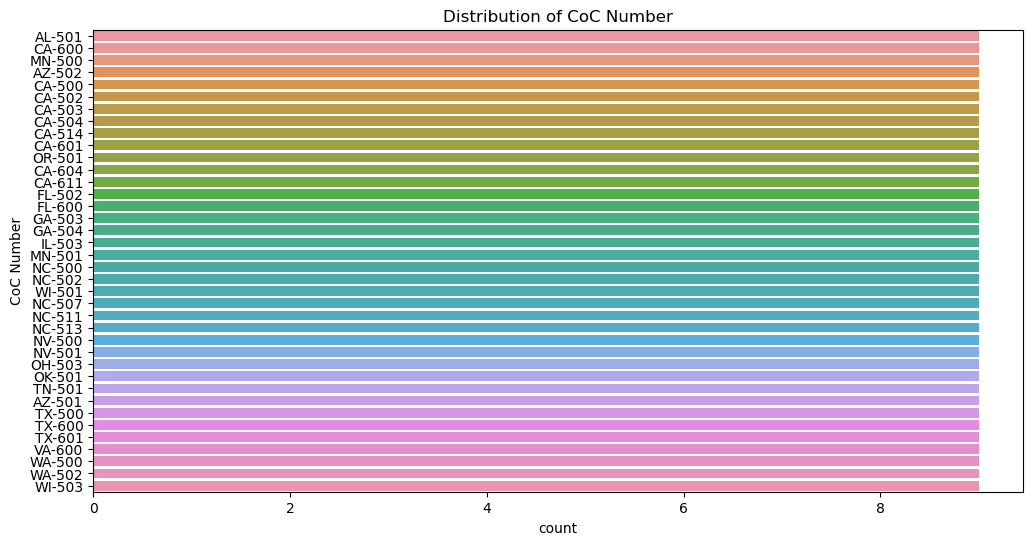

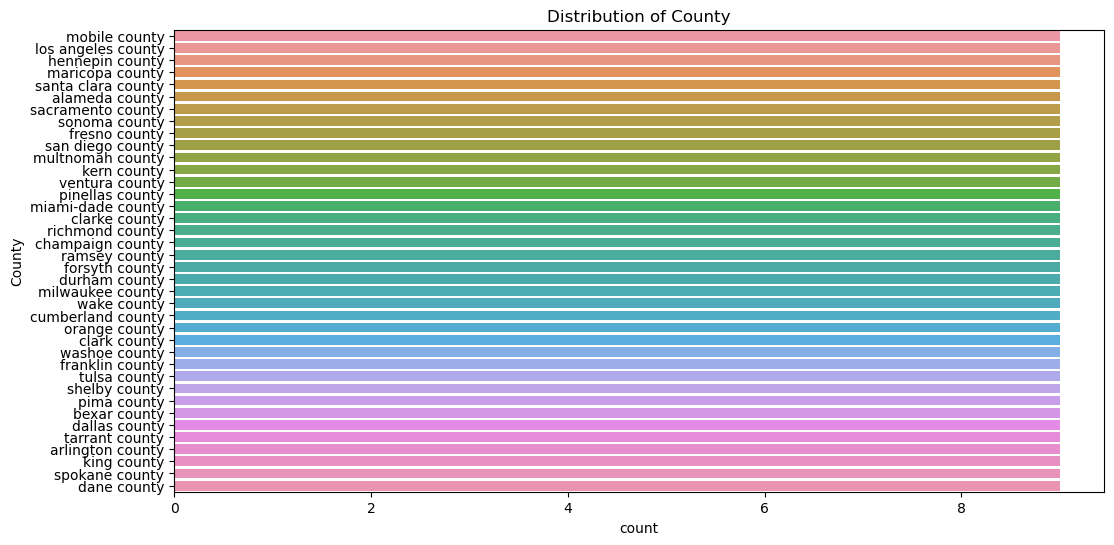

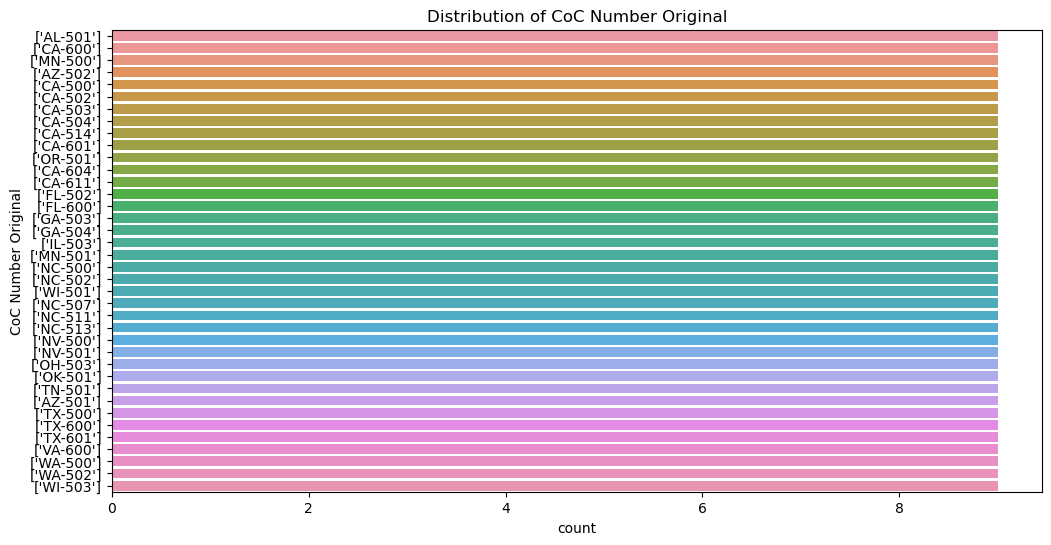

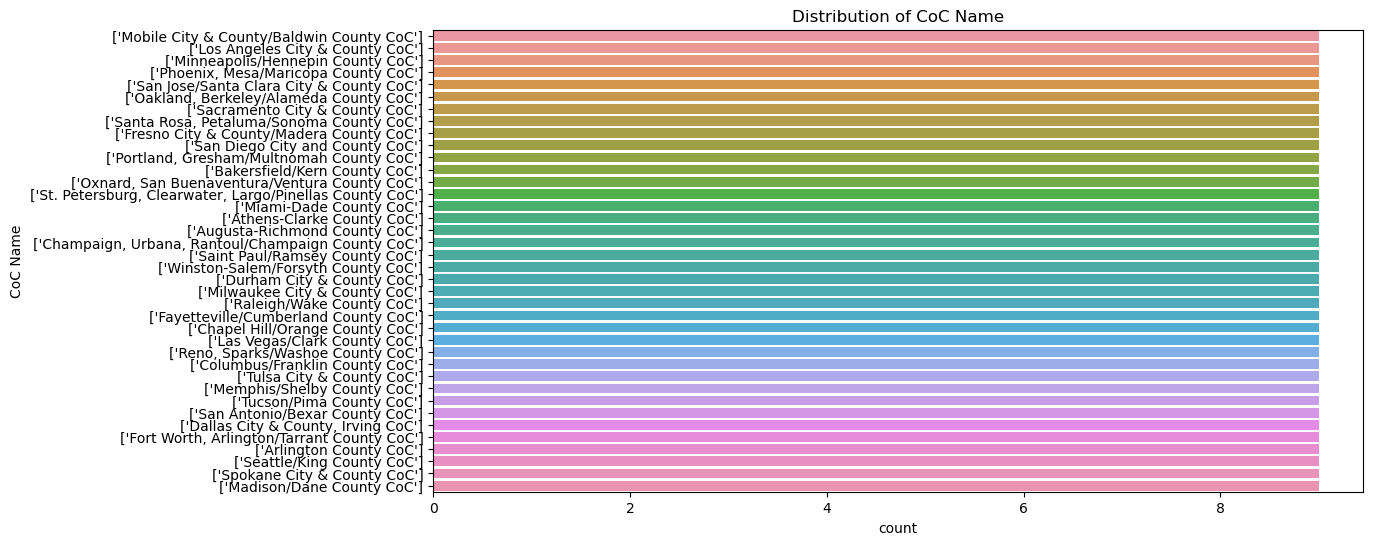

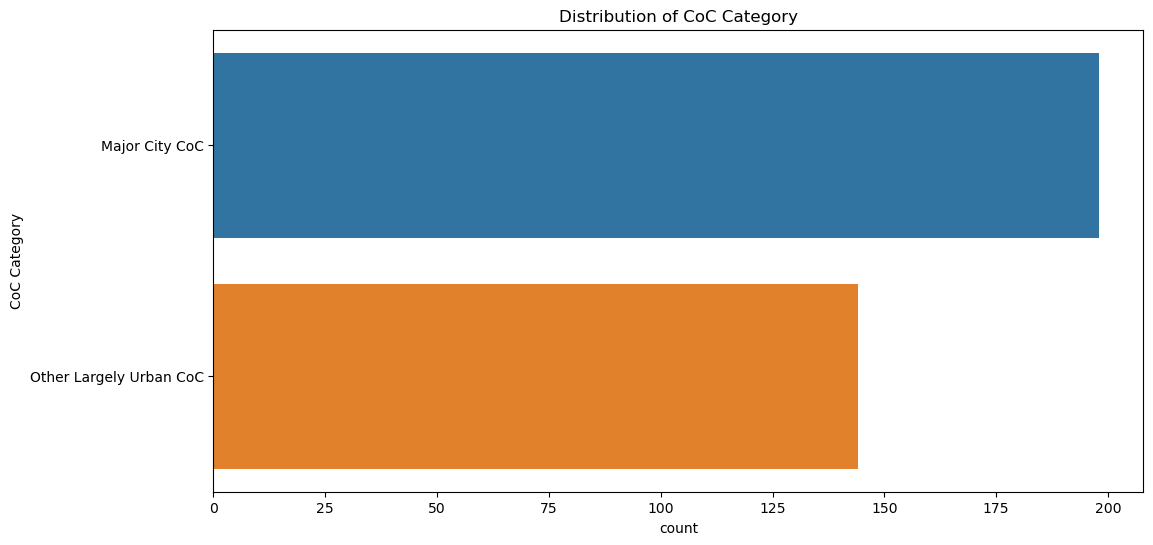

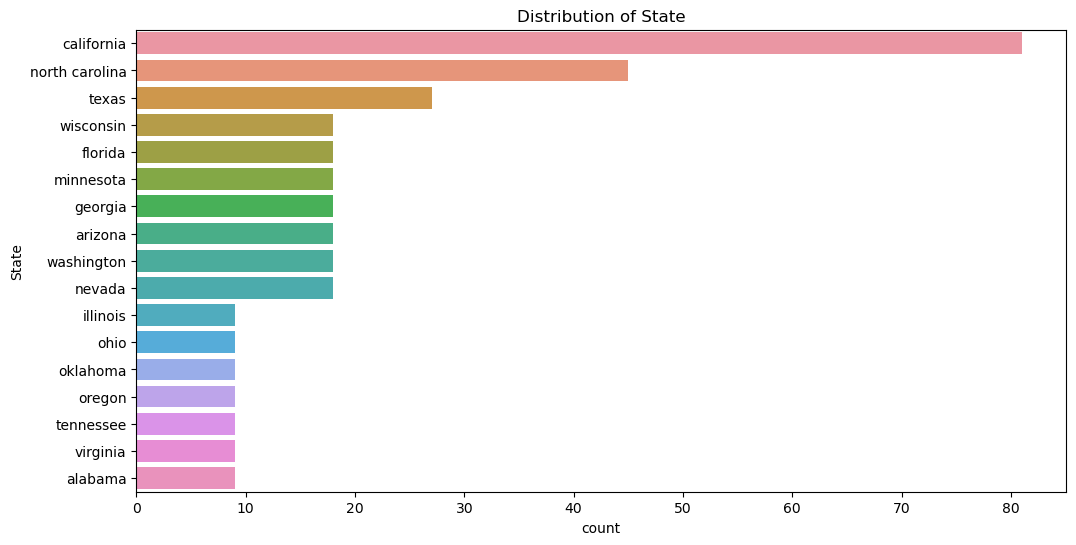

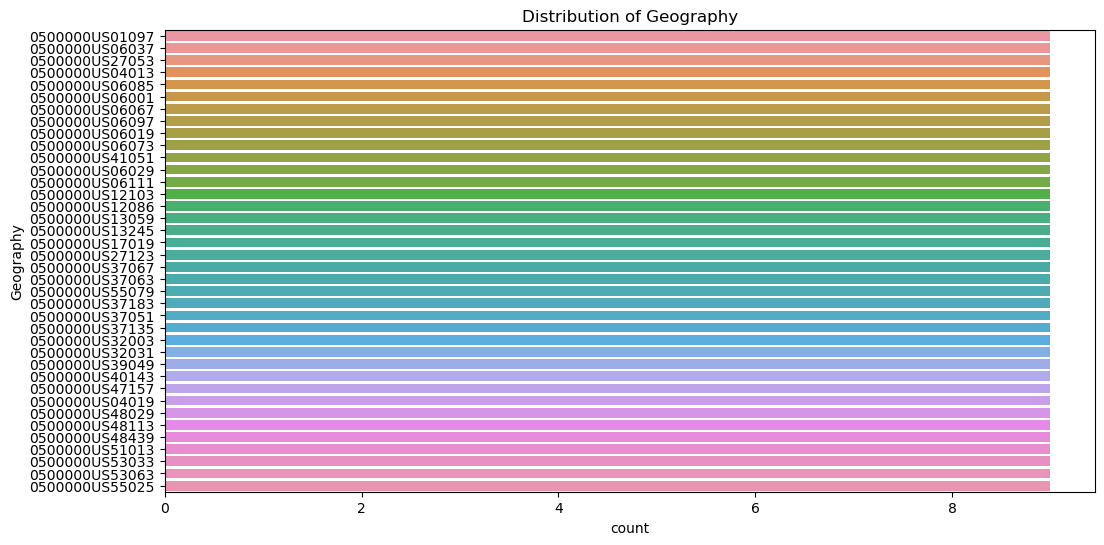

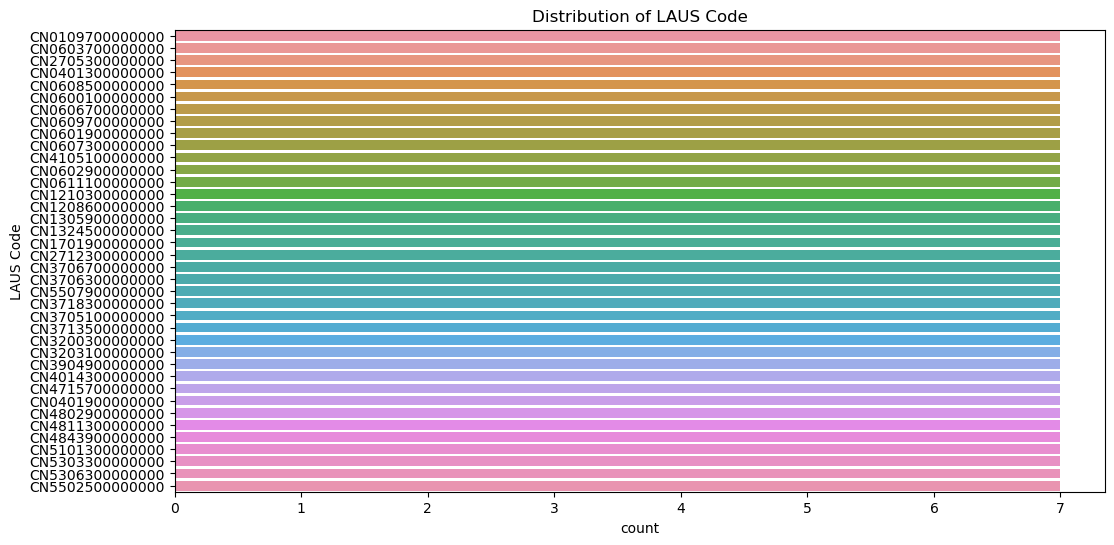

In [12]:
# Visualizing the categorical distribution
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    coc_cnt = df_filtered[col].value_counts().nlargest(40).index  # Looking at the top 20
    sns.countplot(y=df_filtered[col], order=coc_cnt)
    plt.title(f"Distribution of {col}")
    plt.show()

<a id="section-1_6"></a>
### 1.6 Taking a look at the numerical variables

Visualizing Histograms

To enhance visibility, the histograms were plotted in batches. Here are some key observations from a quick scan:

1. The data spans the years 2010 to 2018.
2. Many histograms exhibit right-skewed distributions.
3. The histograms for total homeless, total sheltered homeless, and unsheltered homeless per 10k also show right-skewed distributions. This suggests:
    - Most CoCs have a relatively low number of homeless individuals.
    - A small number of CoCs have significantly higher homeless counts, creating the skewed pattern.

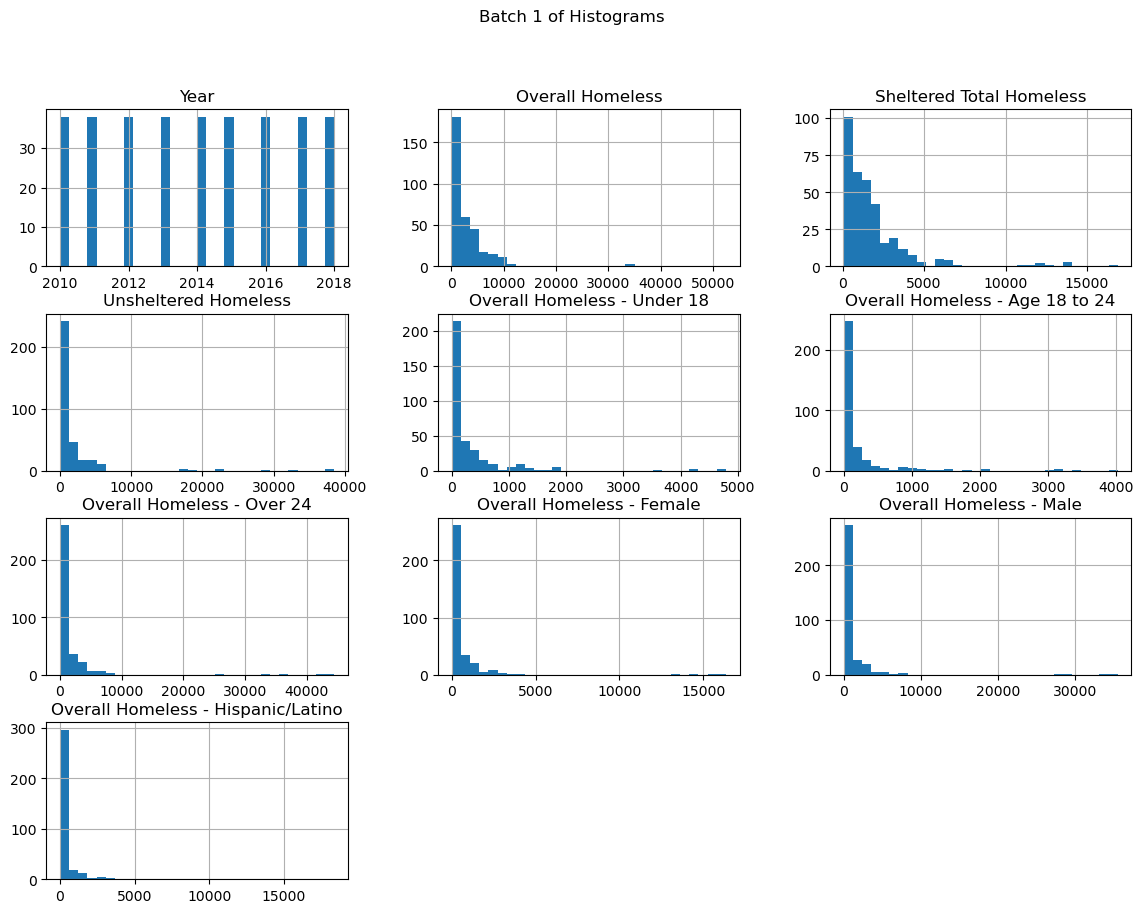

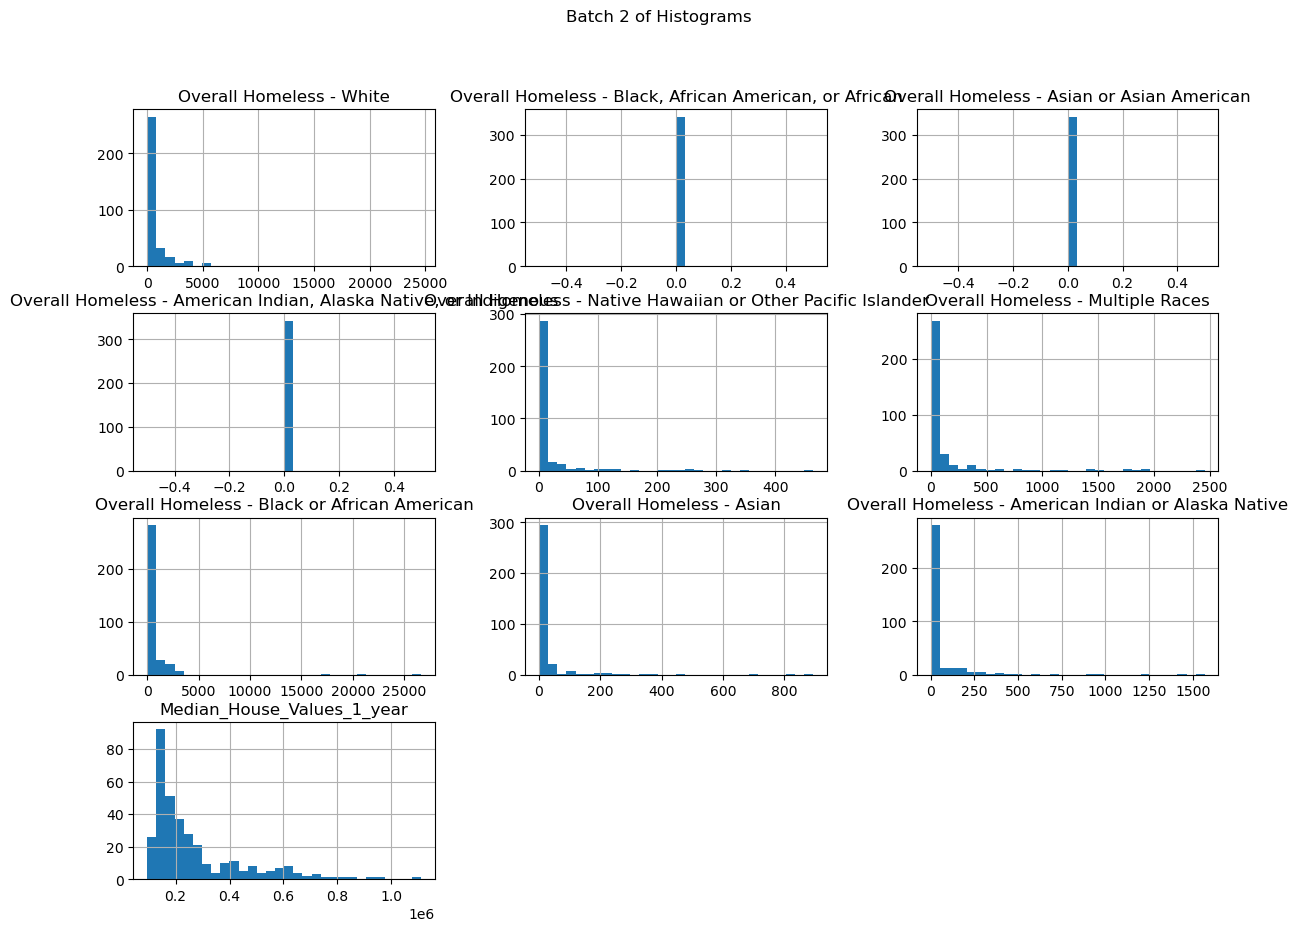

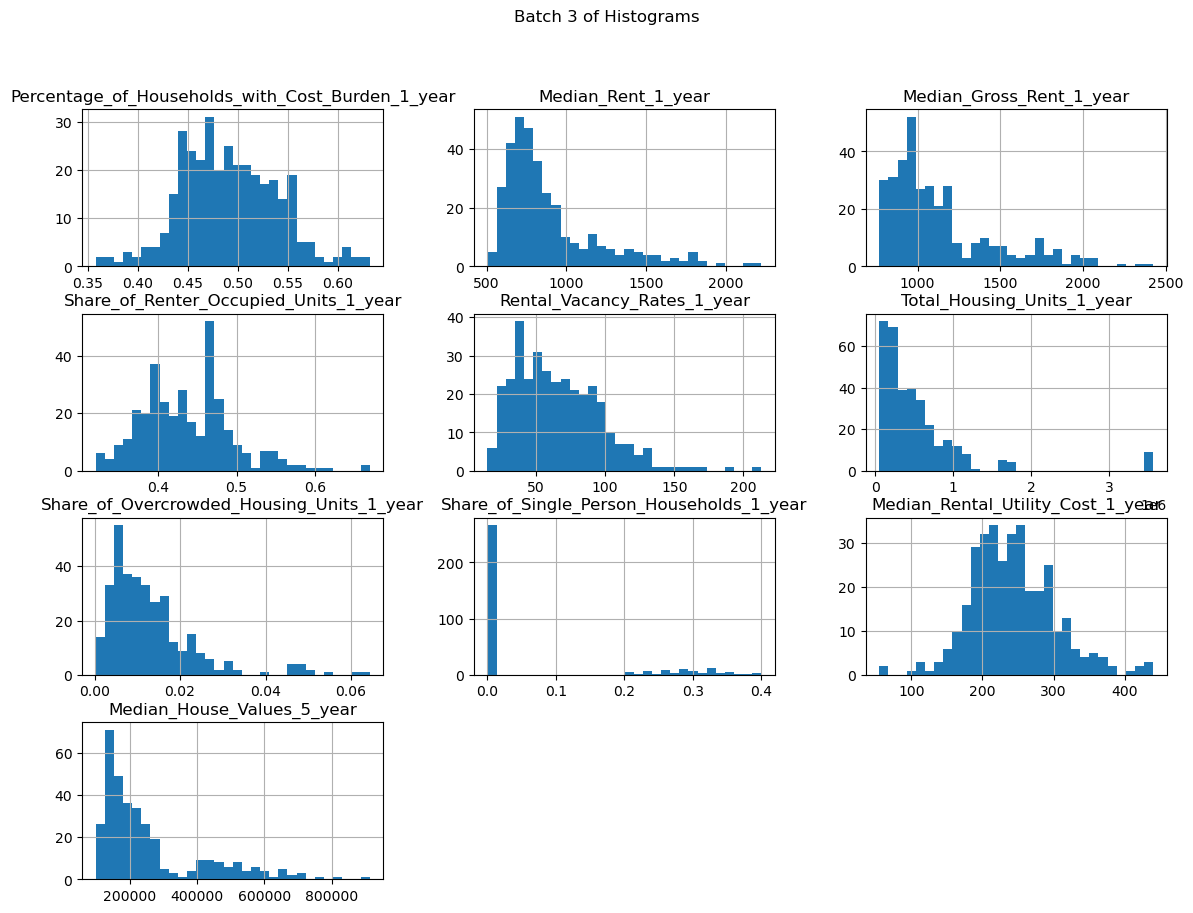

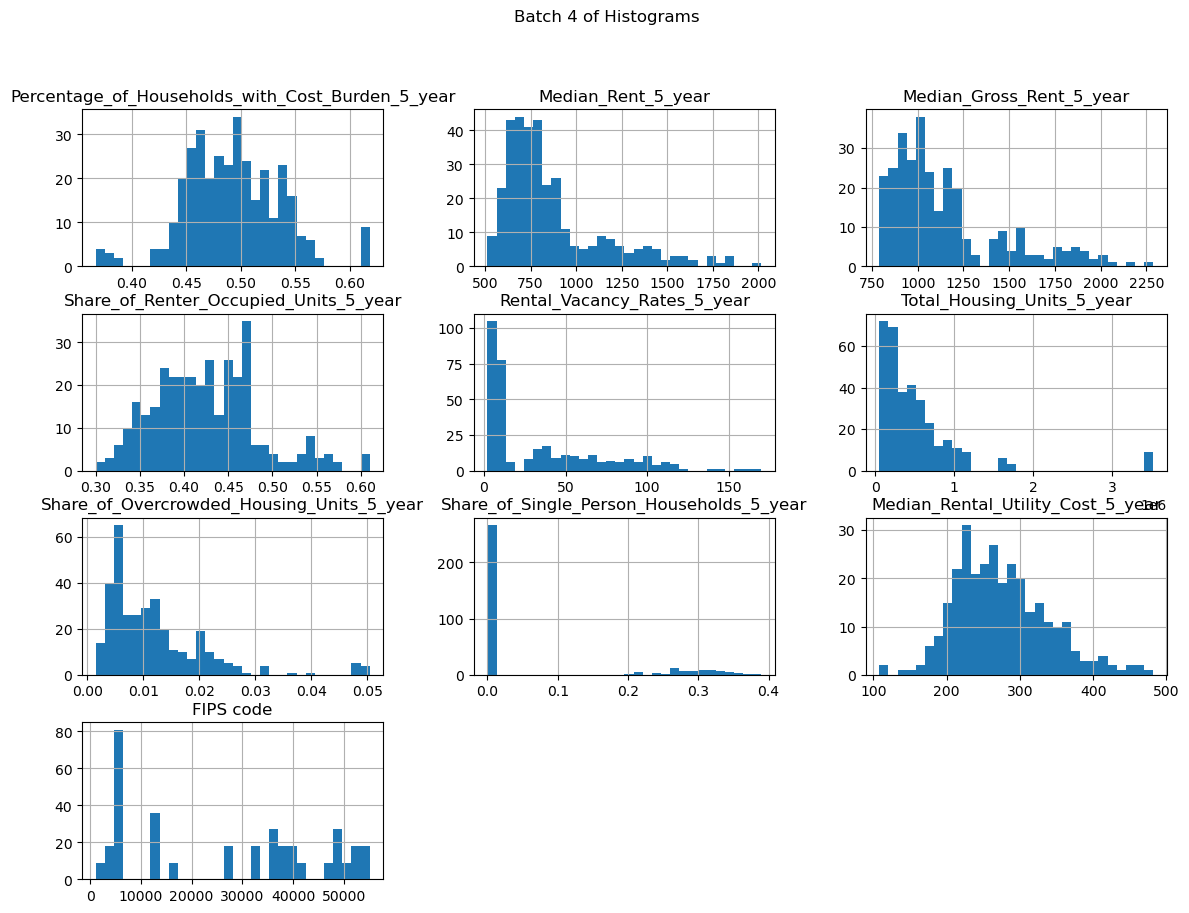

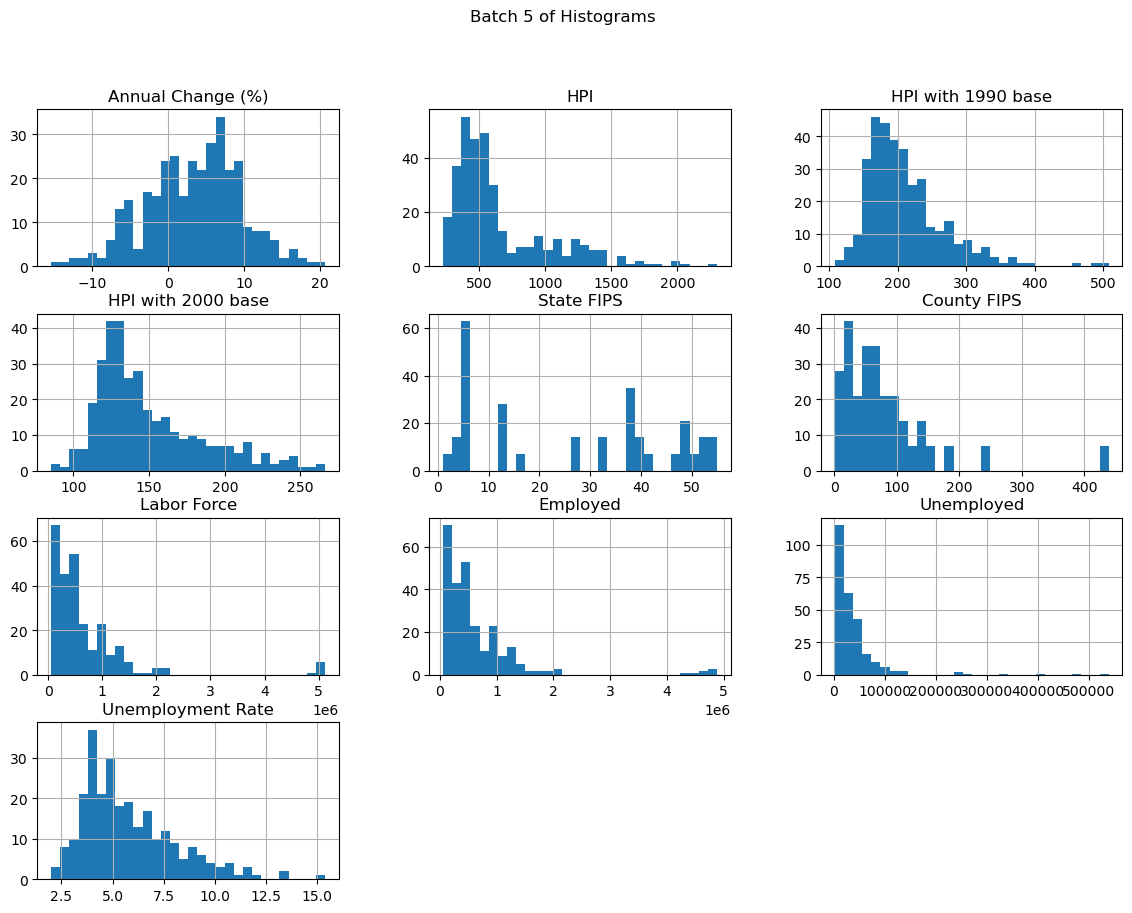

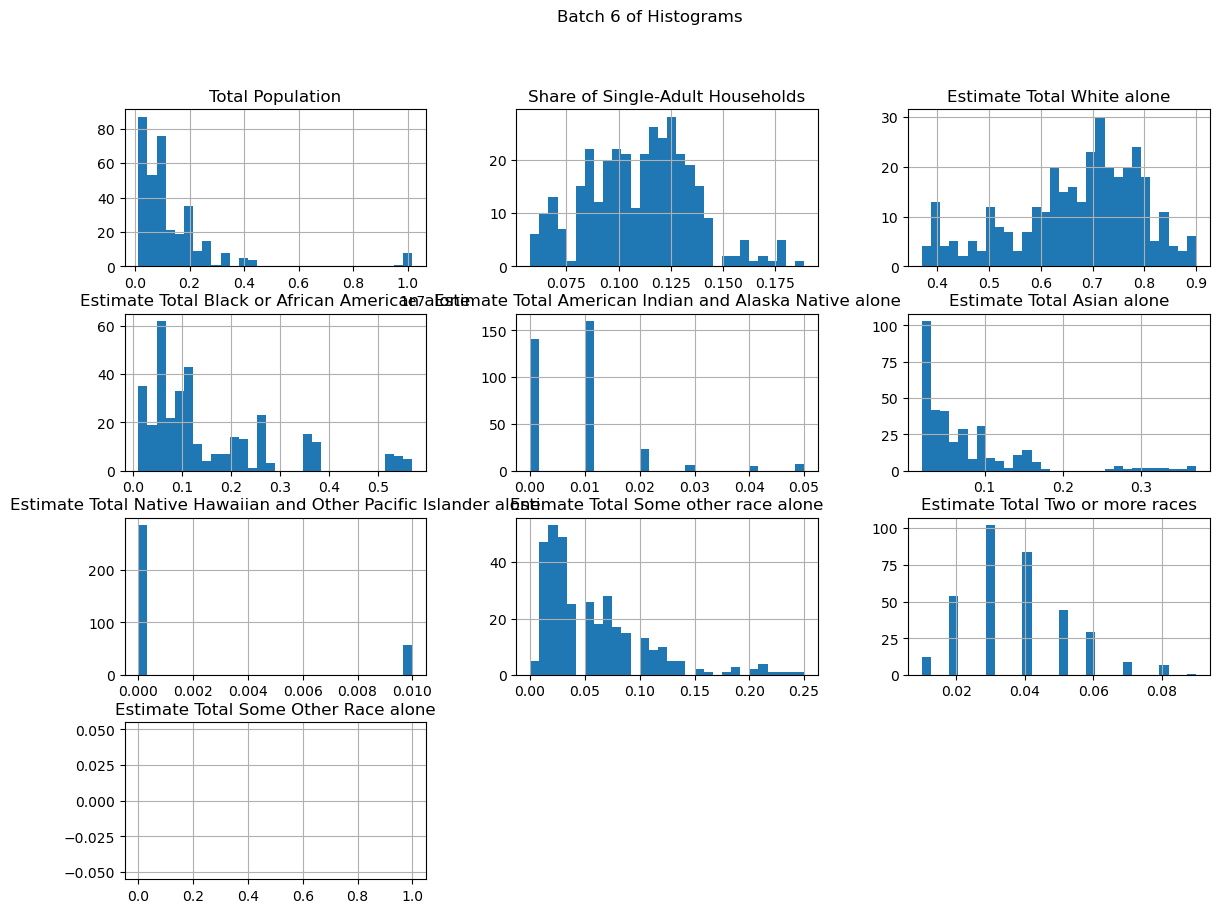

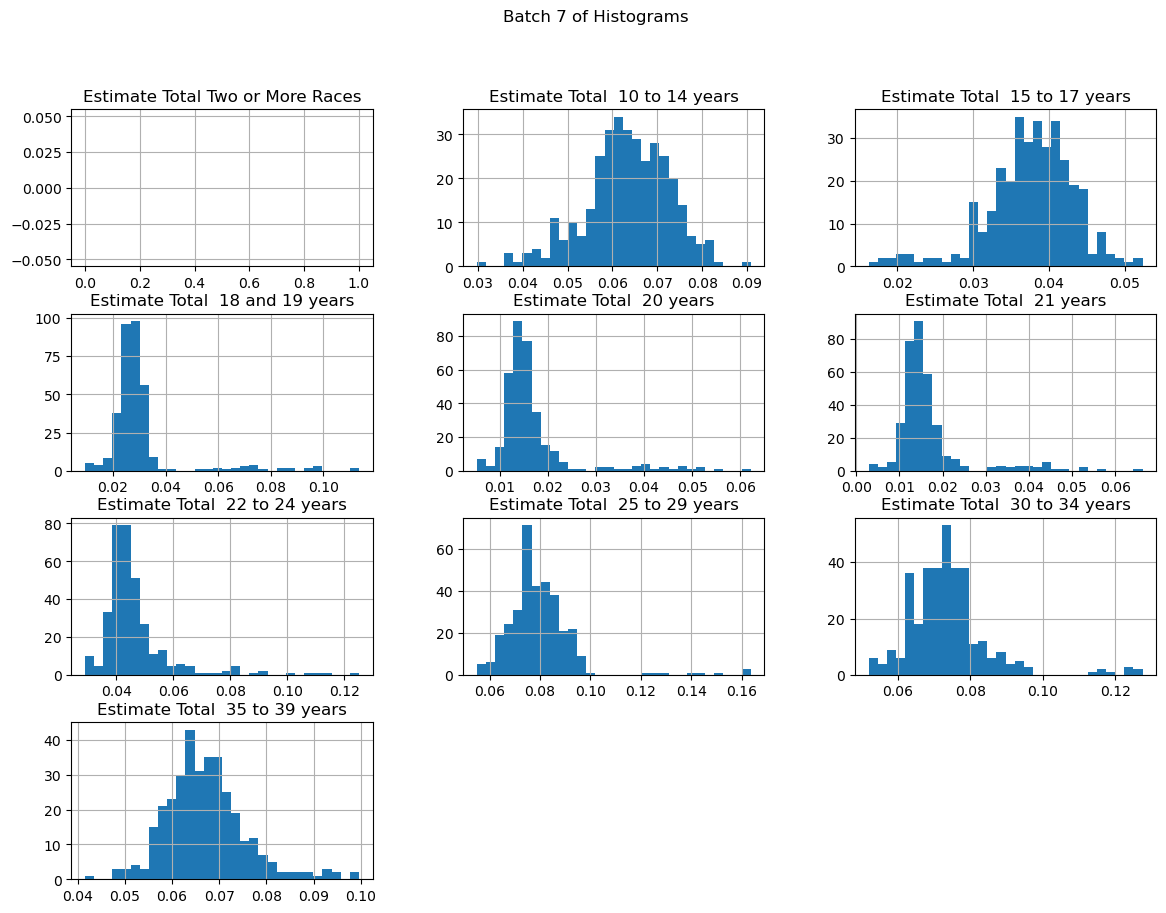

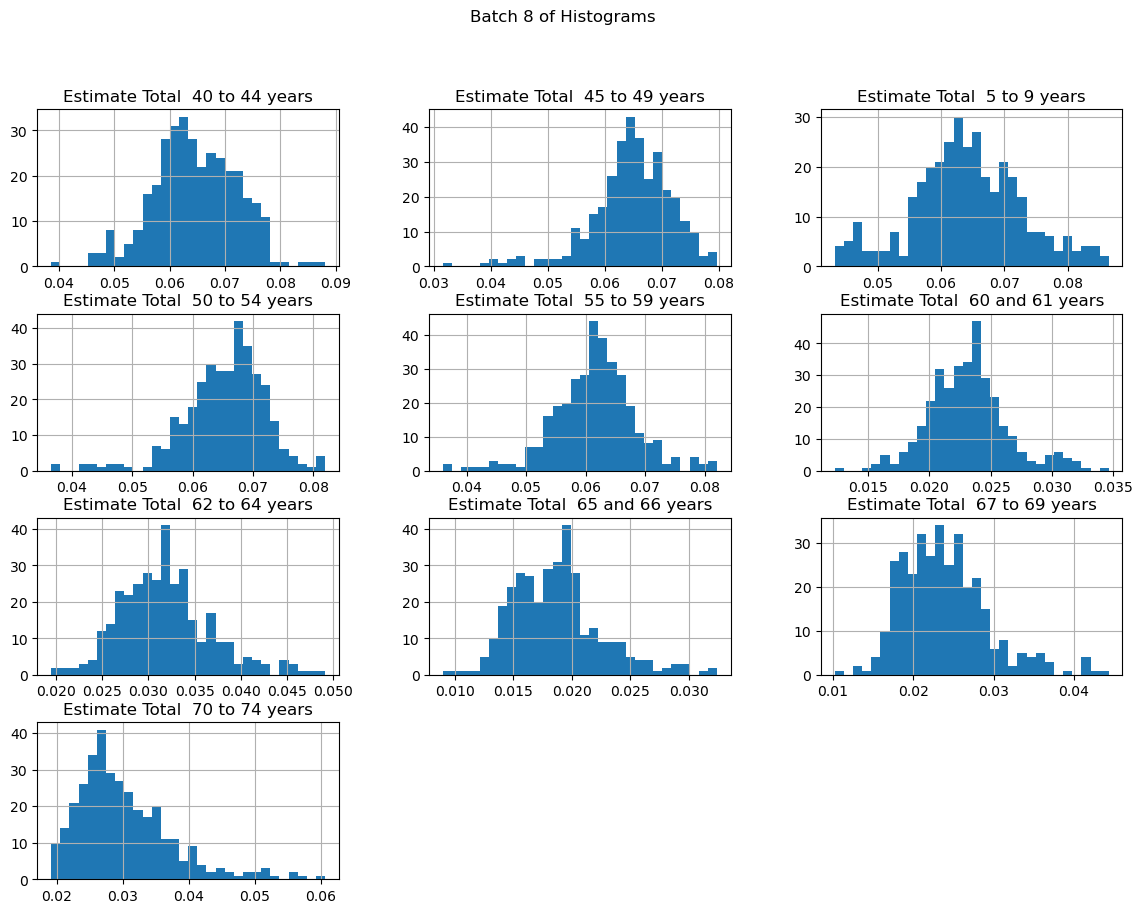

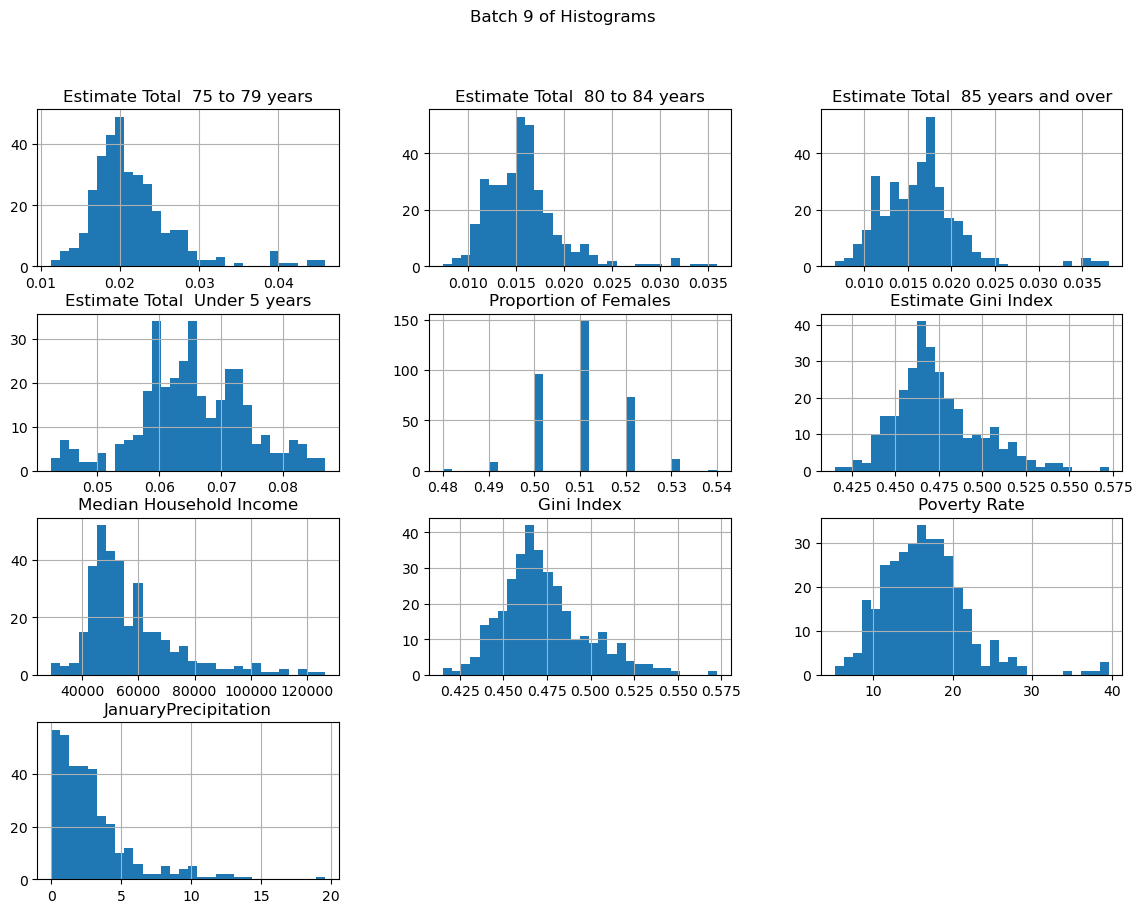

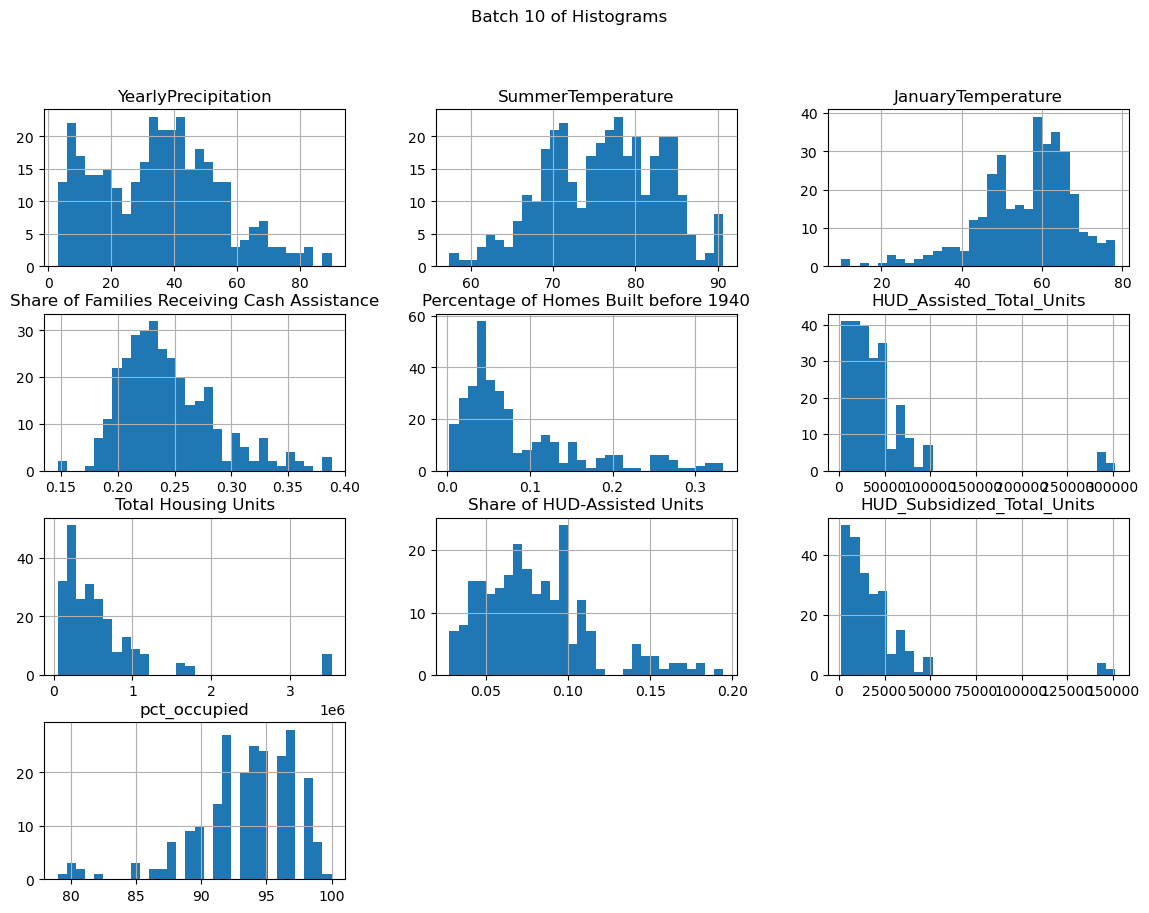

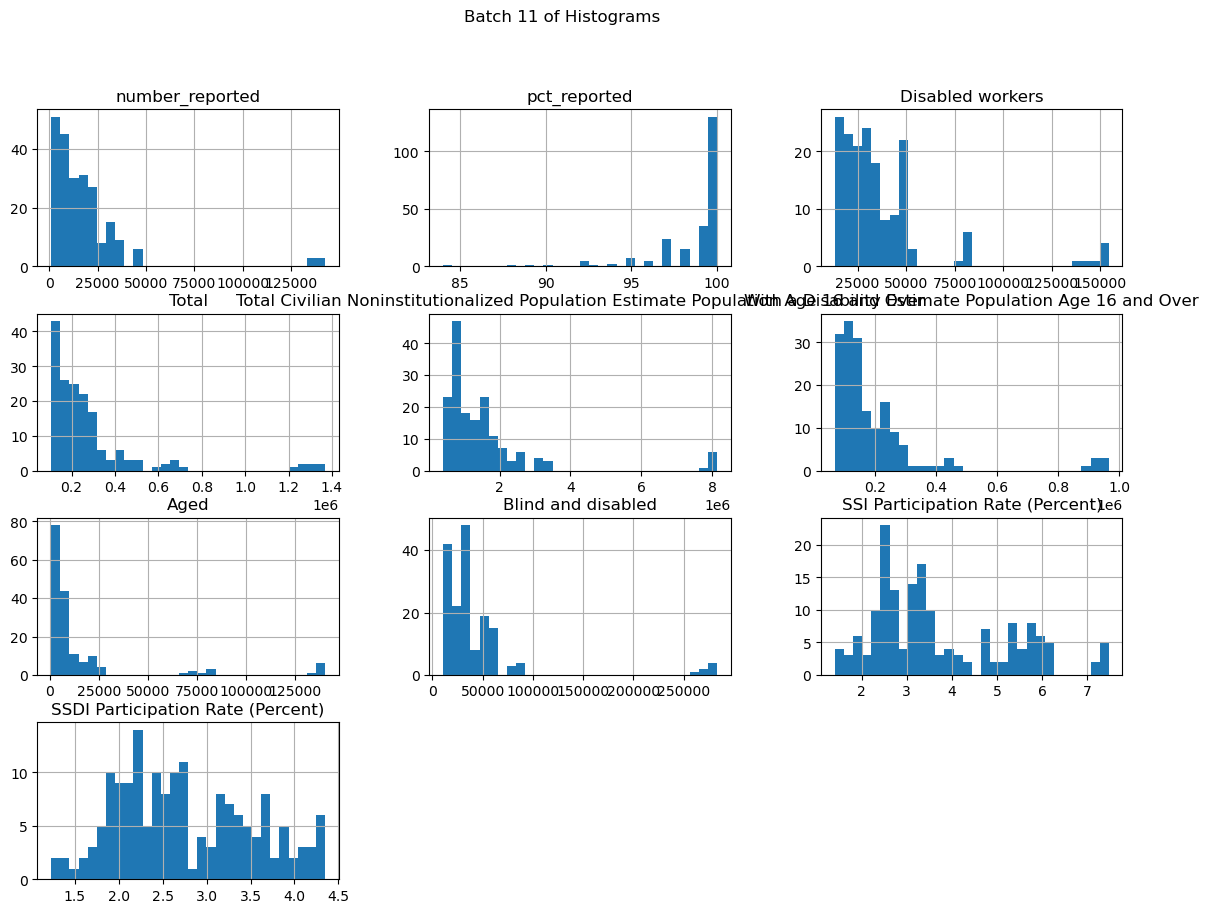

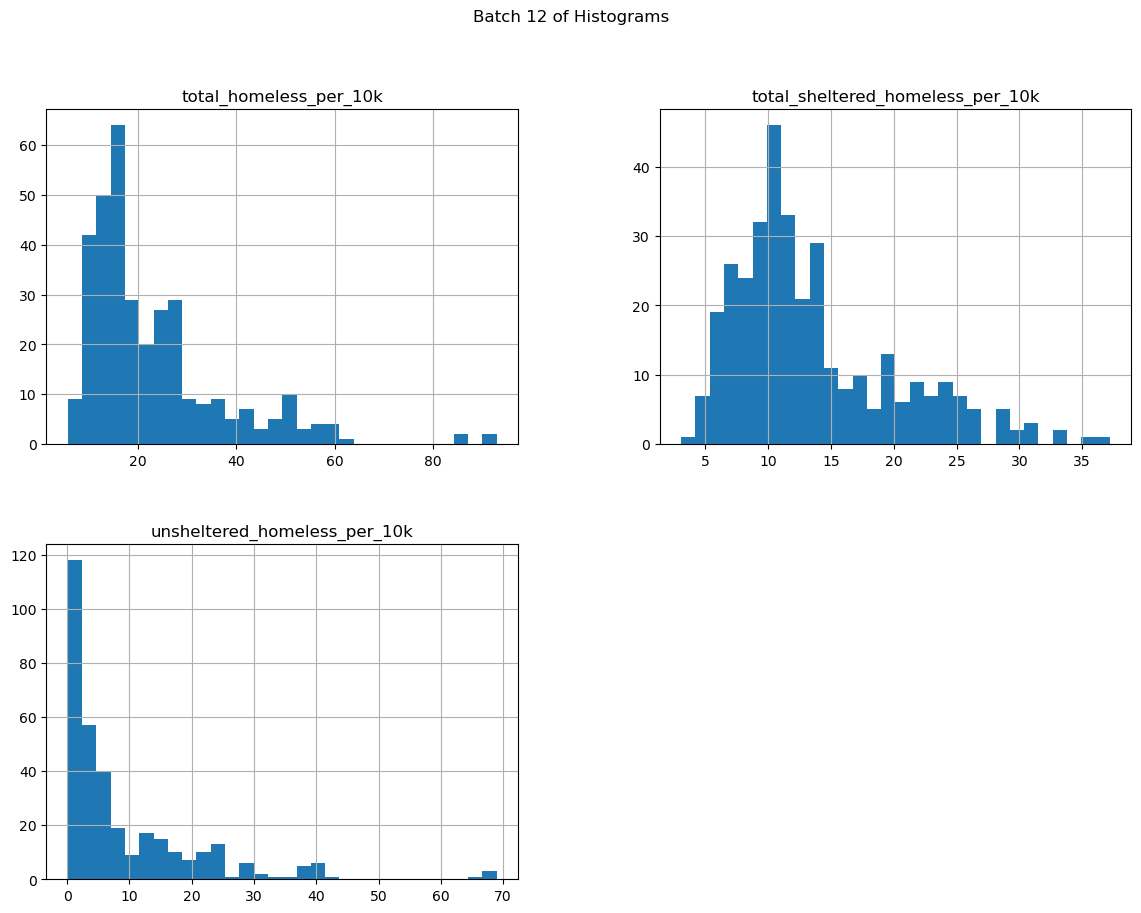

In [13]:
# Histogram of numerical columns
num_cols = df_filtered.select_dtypes(include=['number']).columns

batch_size = 10  # Number of histograms per batch
num_batches = int(np.ceil(len(num_cols) / batch_size))  # Calculating the number of batches

for i in range(num_batches):
    batch_cols = num_cols[i * batch_size:(i + 1) * batch_size]
    df_filtered[batch_cols].hist(figsize=(14, 10), bins=30)
    plt.suptitle(f'Batch {i + 1} of Histograms')
    plt.show()

<a id="section-1_7"></a>
### 1.7 Looking for correlations

Correlation Matrix Analysis

The full correlation matrix was too cluttered, so I filtered it to display only correlations above 0.7 (strong correlations). Here are some key observations:

1. Several predictor variables exhibit strong positive correlations, indicating potential multicollinearity among related features.
2. Some predictors show strong negative correlations, suggesting inverse relationships between certain variables.
3. Highly correlated predictors might indicate redundancy, which could impact model performance. Feature selection or dimensionality reduction techniques (e.g. PCA) might be useful.
4. Groups of strongly correlated variables may represent similar underlying factors, such as economic conditions, population density, or regional policies affecting homelessness rates.

d:\anaconda3\envs\class210\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


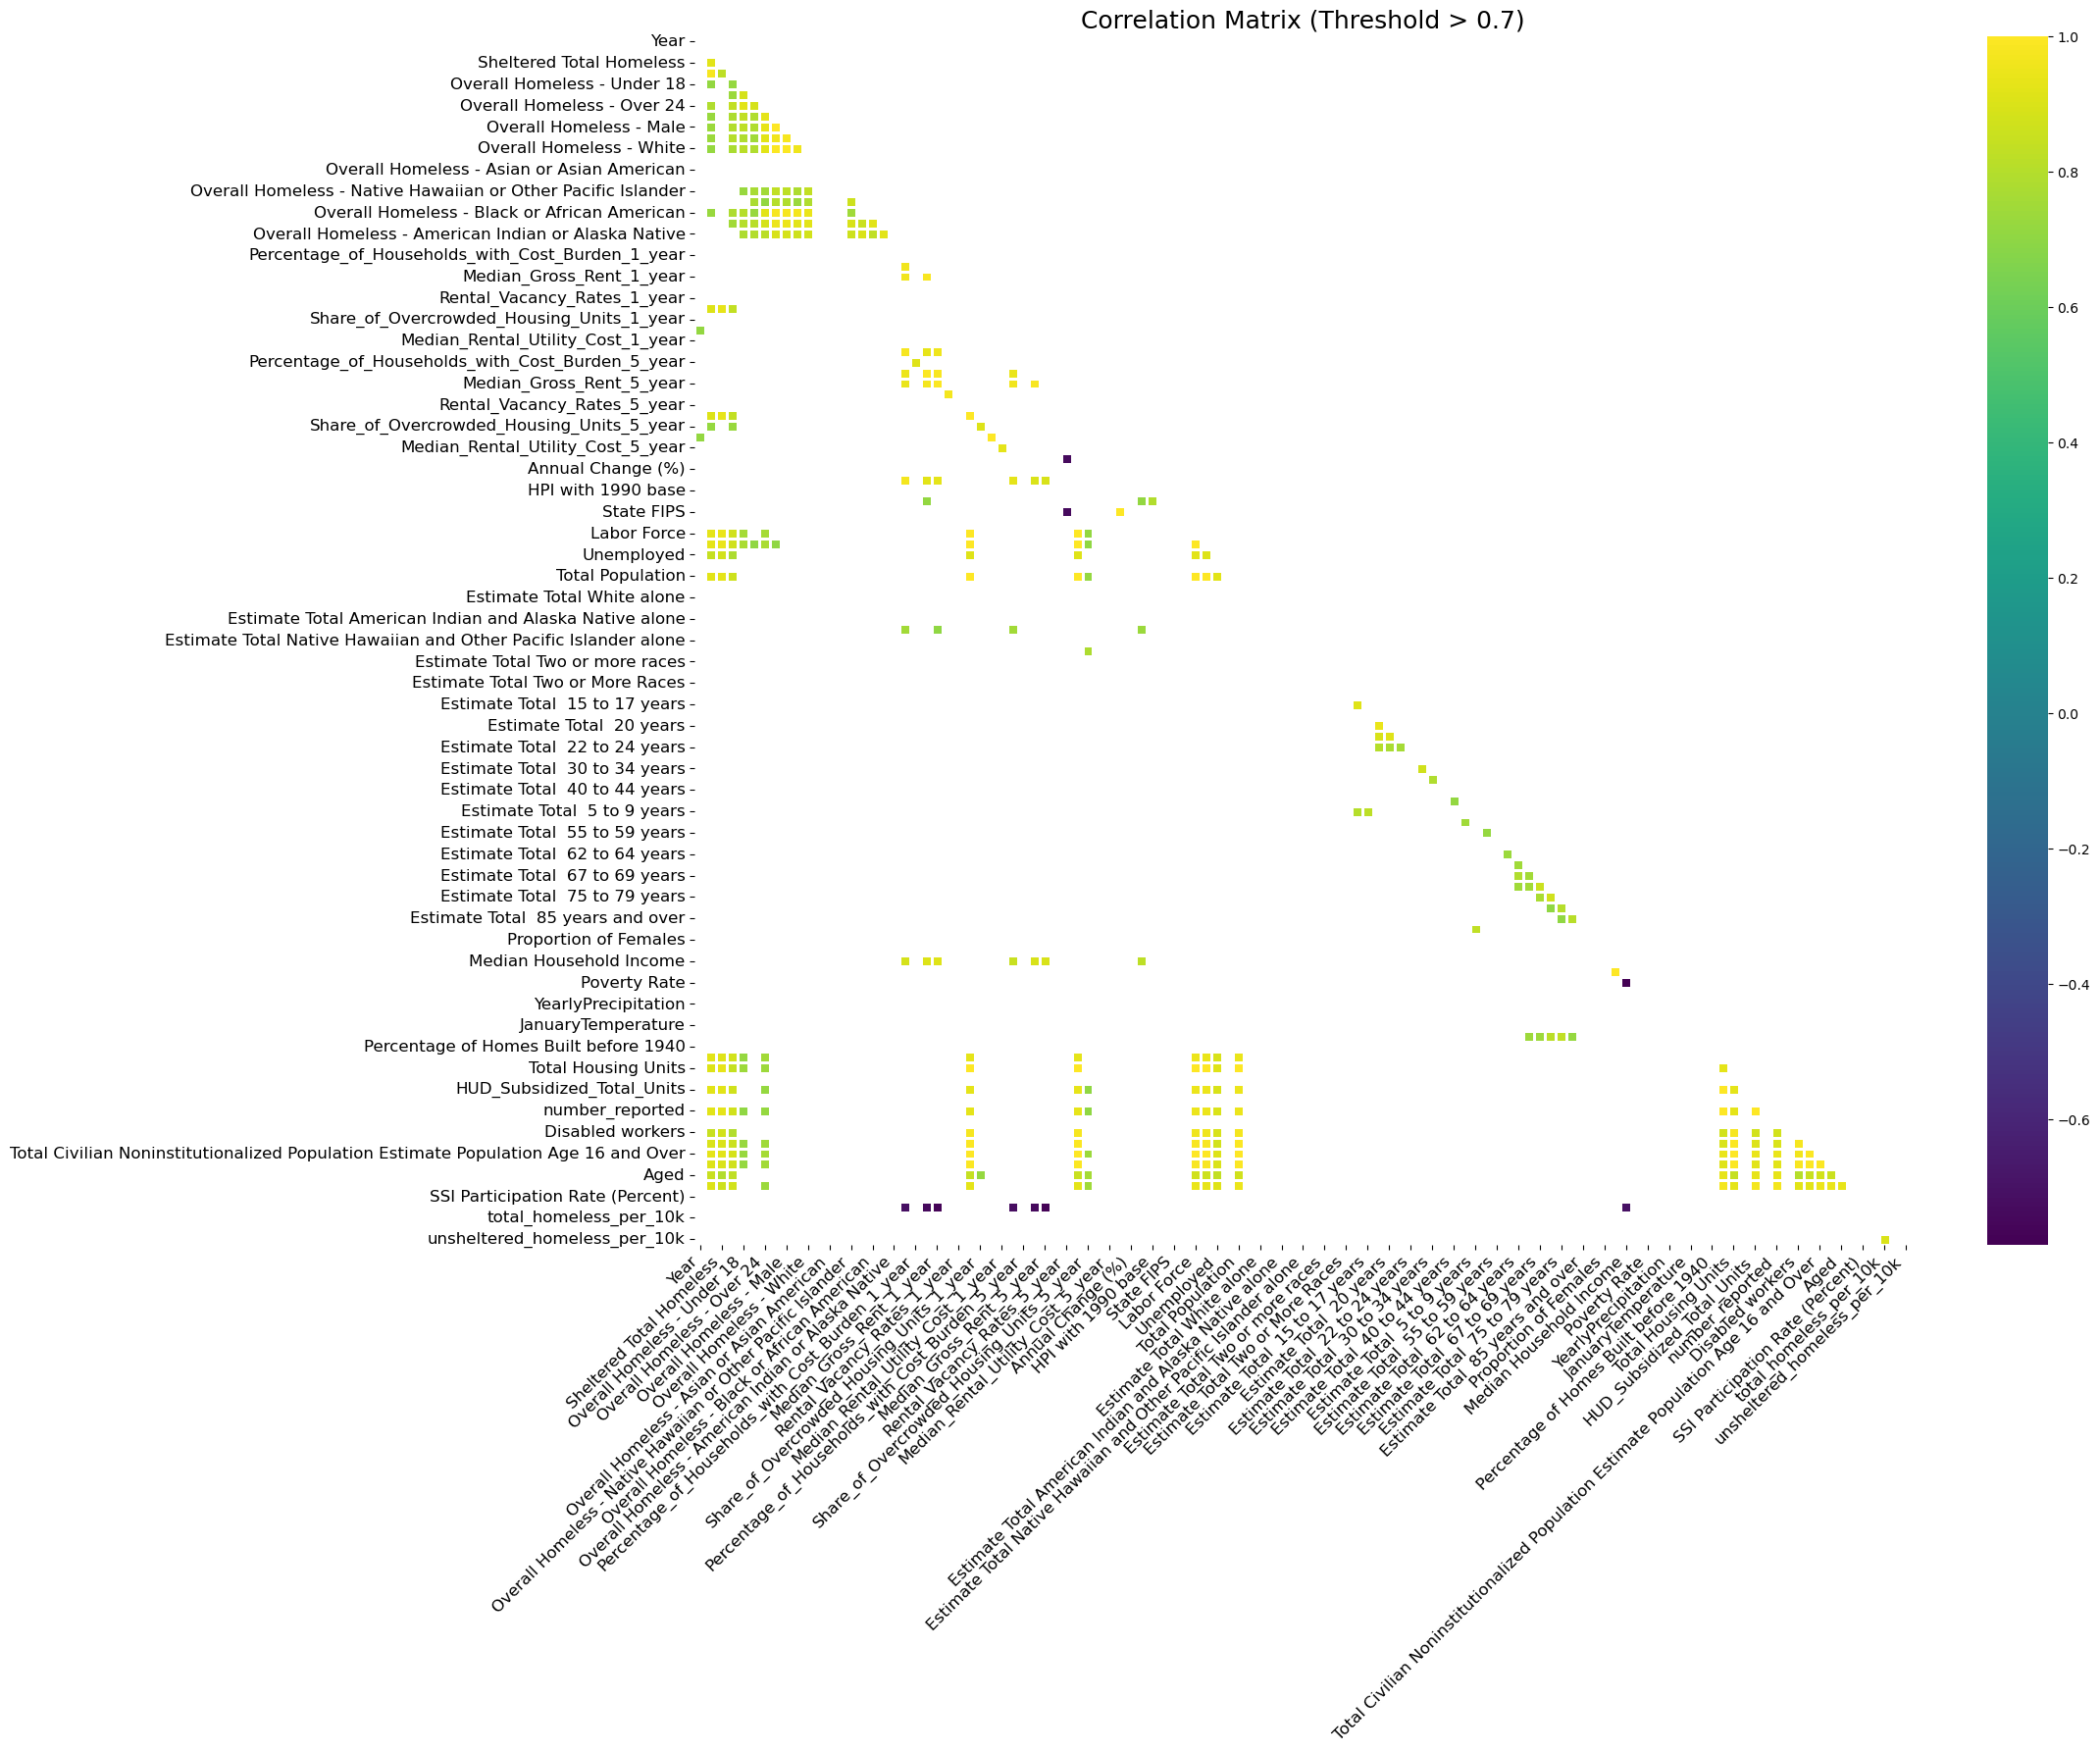

In [14]:
# Heatmap of numerical correlations
# setting the figure size
plt.figure(figsize=(20, 16))

corr_matrix_task2 = df_filtered.select_dtypes(include=['number']).corr()

# Set correlation threshold
threshold = 0.7

# Fill NaNs with 0 to avoid warnings
corr_matrix_task2 = corr_matrix_task2.fillna(0)

# Create a mask to hide weak correlations
mask = np.triu(np.ones_like(corr_matrix_task2, dtype=bool))
#mask = abs(corr_matrix) < threshold
weak_corr_mask = abs(corr_matrix_task2) < threshold

# Combining masks to hide both weak correlations and NaNs
combined_mask = mask | weak_corr_mask

sns.heatmap(
    corr_matrix_task2, 
    annot=True, 
    cmap="viridis", 
    fmt=".1f", 
    linewidths=0.75, 
    mask=combined_mask,
    annot_kws={"size": 12}
)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.title(f"Correlation Matrix (Threshold > {threshold})", fontsize=18)

plt.show()

#### 1.7.1 Heatmap to highlight only correlations with total_homeless_per_10k

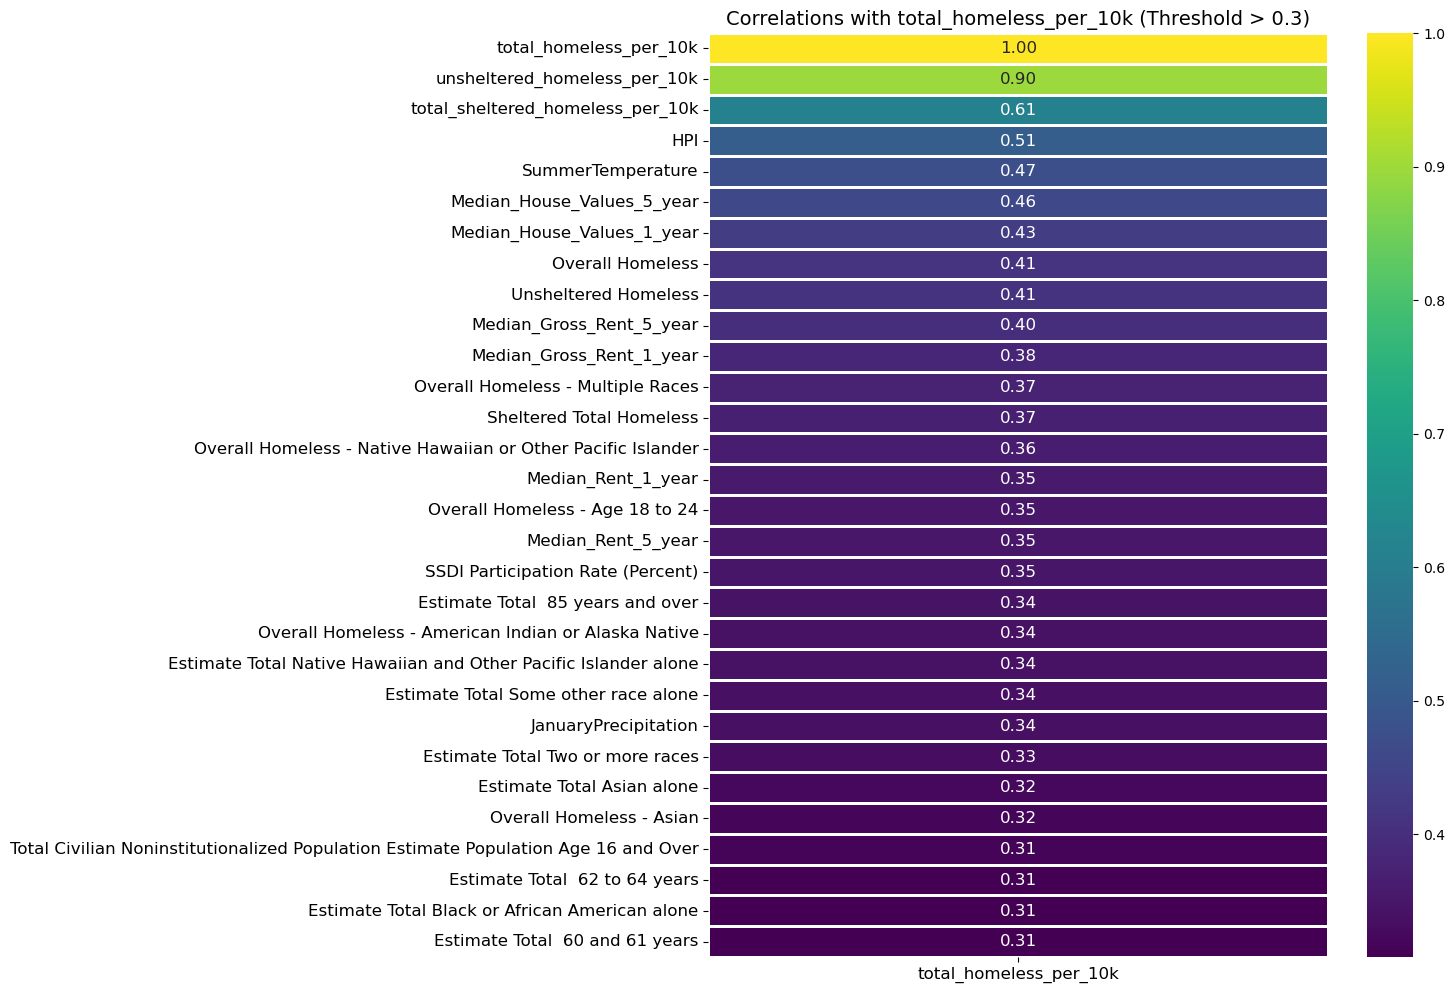

In [15]:
# Heatmap to highlight only correlations with total_homeless_per_10k
# Setting the figure size
plt.figure(figsize=(10, 12))  # Adjusted for a single column visualization

corr_matrix = df_filtered.select_dtypes(include=['number']).corr()

# Extracting correlations only for the target variable
target_corr_task2 = corr_matrix[['total_homeless_per_10k']].copy()

# Setting correlation threshold
threshold = 0.3

# Masking weak correlations
target_corr_task2 = target_corr_task2[abs(target_corr_task2) > threshold].dropna()

# Sorting by absolute correlation values and placing strongest at the top)
target_corr_task2 = target_corr_task2.abs().sort_values(by='total_homeless_per_10k', ascending=False)

# Plot heatmap
sns.heatmap(
    target_corr_task2, 
    annot=True, 
    cmap="viridis", 
    fmt=".2f", 
    linewidths=0.75, 
    annot_kws={"size": 12}
)

# Improve label readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.title(f"Correlations with total_homeless_per_10k (Threshold > {threshold})", fontsize=14)

plt.show()

#### 1.7.2 Saving correlations with total_homeless_per_10k to CSV

In [ ]:
# Saving correlations with total_homeless_per_10k to CSV

# Getting current date in the format YYYYMMDD
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Defining the output CSV file path
output_dir = "./data/"

# Setting output filename with date
#correlation_csv_path = os.path.join(output_dir, "total_homeless_per_10k_correlations.csv")
correlation_csv_path = os.path.join(output_dir, f"total_homeless_per_10k_correlations_{current_date}.csv")

# Saving correlations to a CSV file
target_corr_task2.to_csv(correlation_csv_path, encoding="utf-8")

print(f"Correlations saved to: {correlation_csv_path}")

Correlations saved to: ./data/total_homeless_per_10k_correlations_20250330.csv


<a id="section-1_8"></a>
### 1.8 Pairplot Analysis

Pairplot Analysis

From the correlations matrix, I selected the following columns for the pairplots to explore the relationships:

1. HPI
2. SummerTemperature
3. Median_House_Values_5_year
4. Median_House_Values_1_year
5. Overall Homeless
6. Unsheltered Homeless

Observations:

- Most plots show a dense grouping of values near the lower end, indicating that the majority of data points fall within a smaller range.
- A few outliers or extreme values appear near the upper end, suggesting that a small number of CoCs have significantly higher counts for these variables.
- There may be nonlinear relationships between certain variables, which could suggest further investigation using transformations or different statistical techniques.
- Some variables may show strong collinearity, particularly between population-related metrics and homelessness counts.

d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

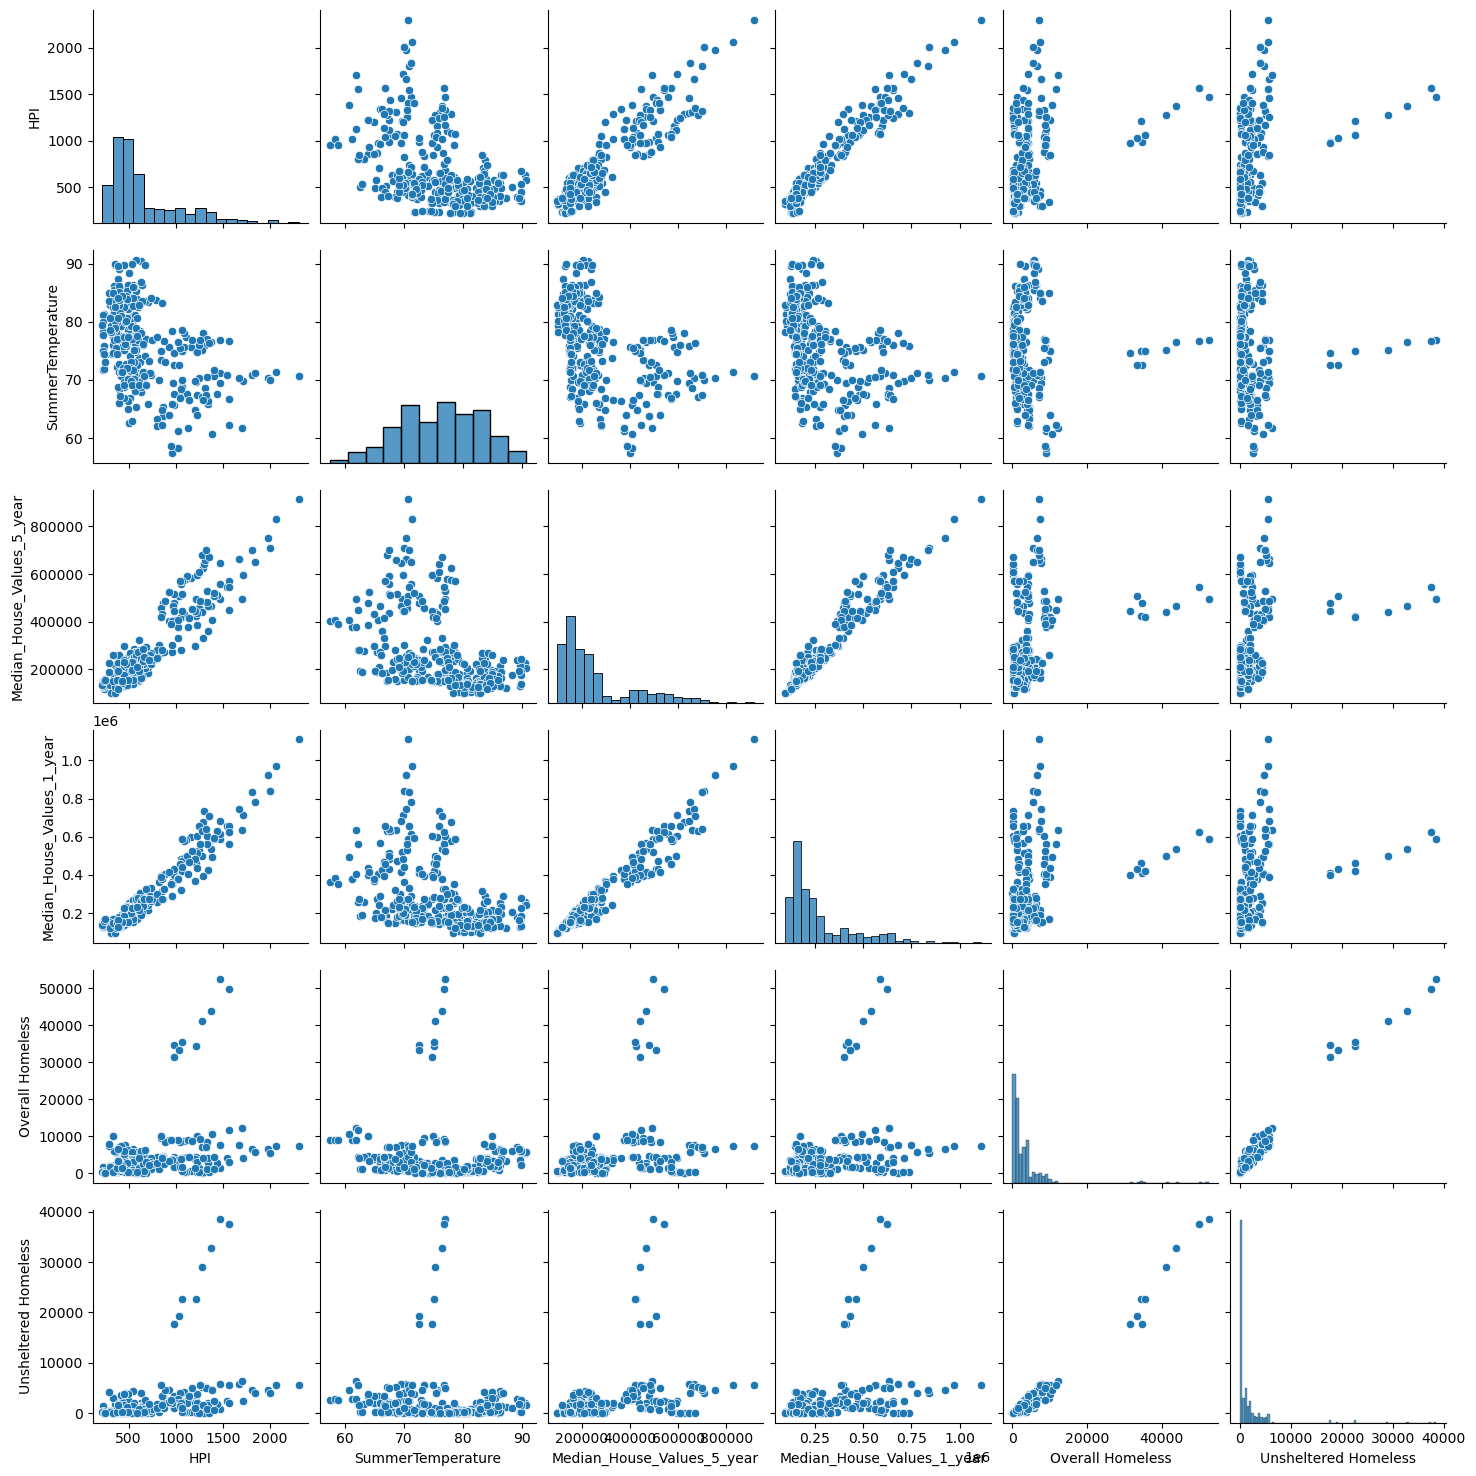

In [16]:
# Sampling the dataset
sample_size = min(1000, len(df_filtered))
df_sampled = df_filtered.sample(sample_size, random_state=42)

# Replacing infinite values with NaN to remove a warning
df_sampled = df_sampled.replace([np.inf, -np.inf], np.nan)

# Renaming the Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over column
df_shortened = df_sampled.rename(columns={
    "Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over": "Total Pop (16+)"
})

# Using the following columns for the pairplots
sns.pairplot(df_shortened[["HPI", 
                         "SummerTemperature",
                         "Median_House_Values_5_year",
                         "Median_House_Values_1_year", 
                         "Overall Homeless", 
                         "Unsheltered Homeless"]],
             kind="scatter")

plt.show()

#### 1.8.1 Highlighting trends with a color-coded visualization

d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\envs\class210\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

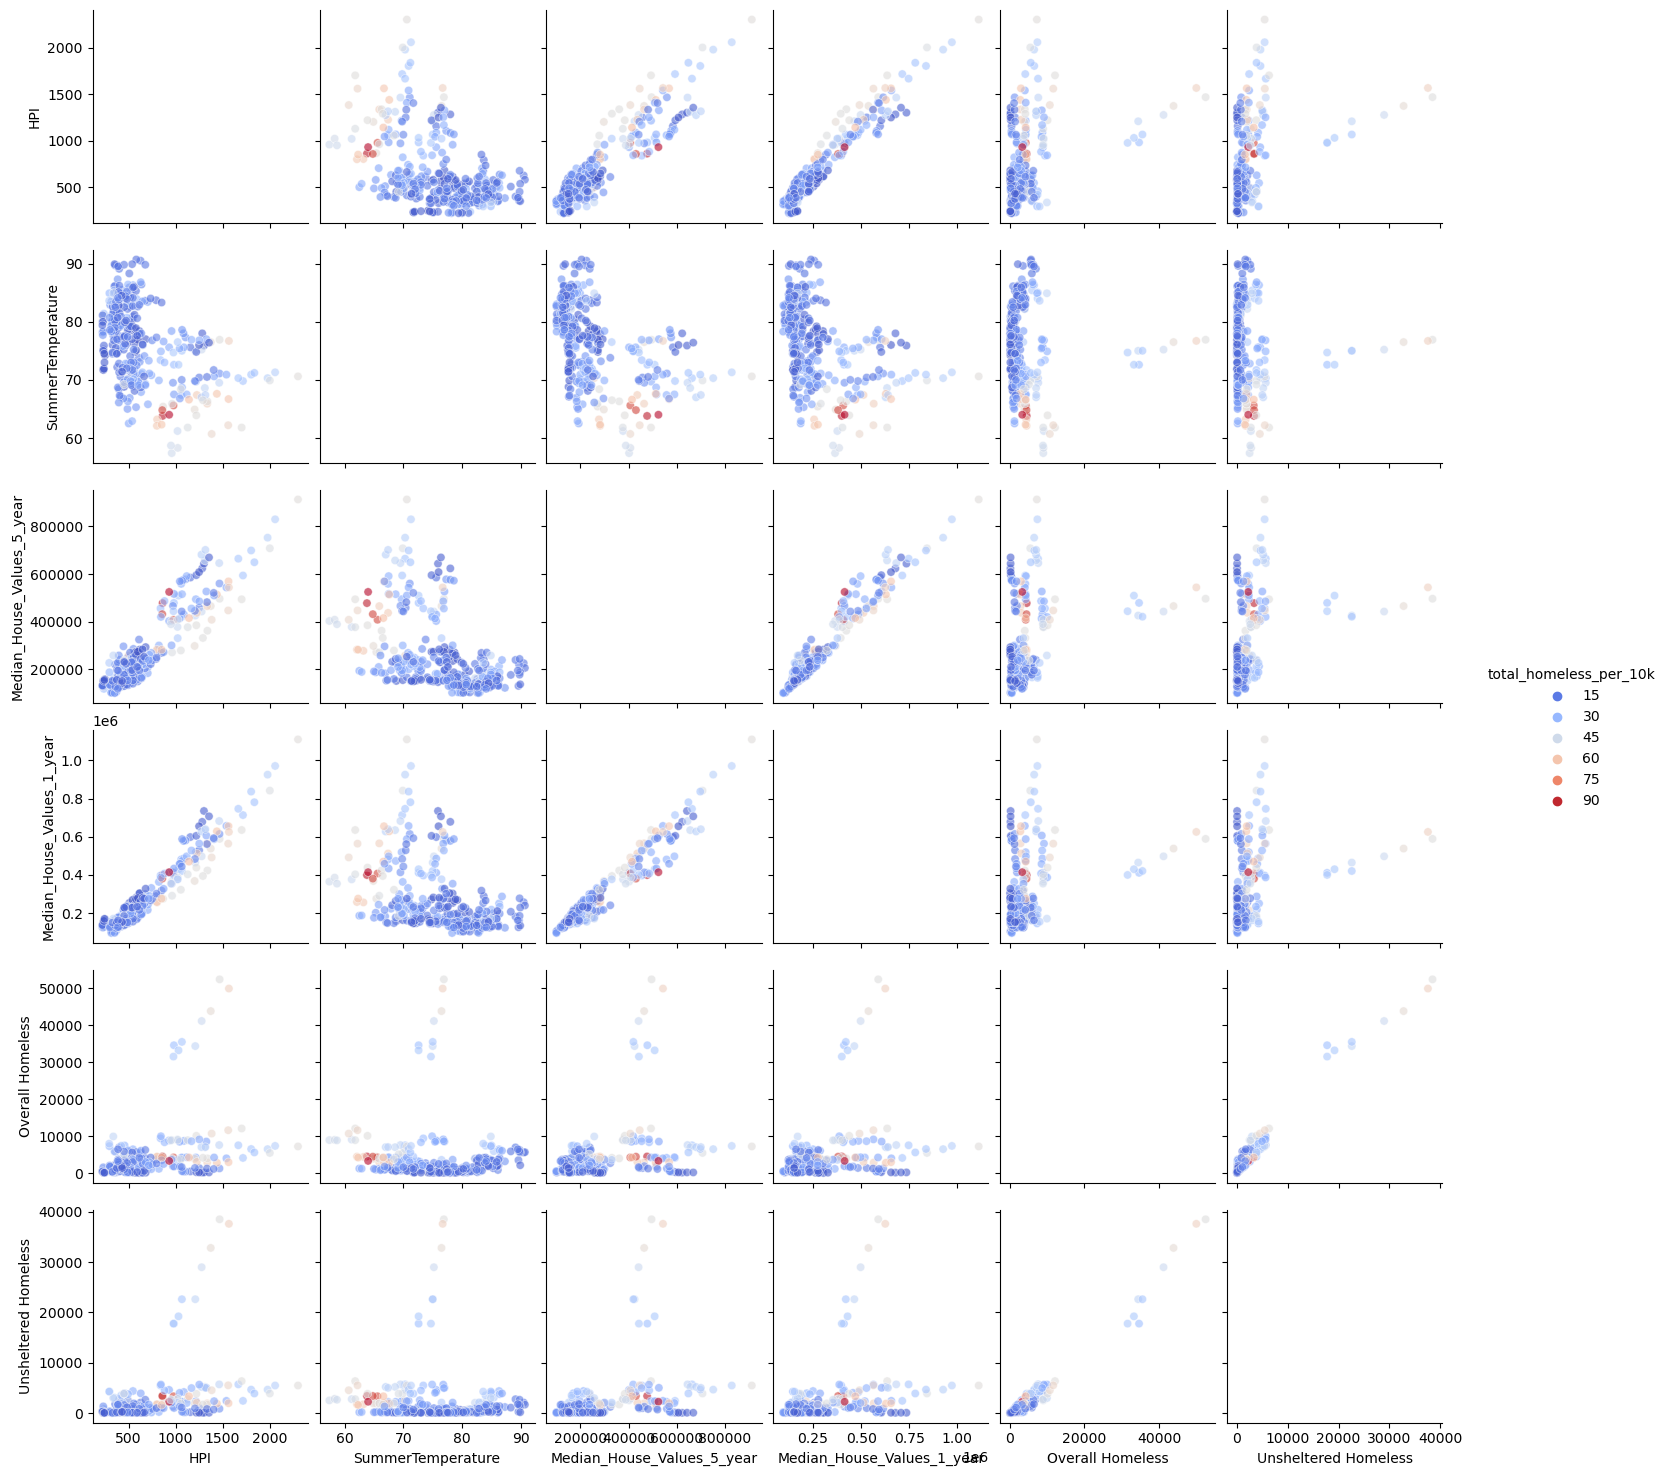

In [17]:
# Highlighting trends with color-coded visualization
# Sampling the dataset
sample_size = min(1000, len(df_filtered))
df_sampled = df_filtered.sample(sample_size, random_state=42)

# Replacing infinite values with NaN to remove a warning
df_sampled = df_sampled.replace([np.inf, -np.inf], np.nan)

# Renaming the Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over column
df_shortened = df_sampled.rename(columns={
    "Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over": "Total Pop (16+)"
})

# Creating a pairplot with color-coded visualization
sns.pairplot(
    df_shortened, 
    vars=[
        "HPI", 
        "SummerTemperature", 
        "Median_House_Values_5_year",
        "Median_House_Values_1_year", 
        "Overall Homeless", 
        "Unsheltered Homeless"
    ],
    hue="total_homeless_per_10k",  # Color based on homelessness rate per 10k
    palette="coolwarm",  # Color scheme to highlight trends
    diag_kind="kde",  # Using KDE plots for better distribution visualization
    plot_kws={"alpha": 0.6},  
    height=2.5  
)

plt.show()

#### 1.8.2 Looking for NaN values per column

In [18]:
# Checking how many NaN values exist per column
missing_counts = df_sampled[["HPI",
                             "SummerTemperature", 
                             "Median_House_Values_5_year", 
                             "Median_House_Values_1_year", 
                             "Overall Homeless", 
                             "Unsheltered Homeless"]].isnull().sum()

print("Missing values per column:\n", missing_counts)

# Checking how many rows contain any NaN values
print("\nTotal rows before dropping NaNs:", len(df_sampled))
print("Rows with NaNs:", df_sampled.isnull().any(axis=1).sum())

Missing values per column:
 HPI                           0
SummerTemperature             0
Median_House_Values_5_year    0
Median_House_Values_1_year    0
Overall Homeless              0
Unsheltered Homeless          0
dtype: int64

Total rows before dropping NaNs: 342
Rows with NaNs: 342


<a id="section-2"></a>
## Section 2 - Models to predict annual homelessness rates using total_homeless_per_10k

<a id="section-2_1"></a>
### 2.1 Loading dataset for filtered major city and urban dataset

In [2]:
# Loading the homeless dataset into a DataFrame
file_path = f"./data/homeless_dataset_full.csv"
df_homeless_csv = pd.read_csv(file_path, encoding="utf-8")

# Filtering dataset for Major City and Largely Urban CoCs
df_filtered = df_homeless_csv[df_homeless_csv["CoC Category"].isin(["Major City CoC", "Other Largely Urban CoC"])]

# Displaying 5 random rows
#df_filtered.head()
df_filtered.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
324,GA-504,richmond county,2016,287,266,21,56,15,216,118,169,5,80,0,0,0,0,9,191,5,2,['GA-504'],['Augusta-Richmond County CoC'],Other Largely Urban CoC,georgia,101600.0,0.453284,646.0,800.0,0.47,78.0,88171.0,0.005599,0.00,154.0,100600,0.497440,613,804.0,0.47,89.0,87290,0.006113,0.00,191.0,0500000US13245,13245.0,0.58,332.00,155.22,119.75,CN1324500000000,13.0,245.0,84842.0,79035.0,5807.0,6.8,201647.0,0.116263,0.38,0.57,0.00,0.02,0.00,0.01,0.01,NaN,NaN,0.056177,0.036673,0.031570,0.018726,0.017278,0.047395,0.092295,0.073019,0.056634,0.057368,0.052076,0.071174,0.062322,0.060313,0.028014,0.037219,0.022277,0.023536,0.034957,0.021553,0.017754,

In [3]:
# Loading the correlation file to identify the strongest predictors
correlation_file_path = "./data/total_homeless_per_10k_correlations_20250330.csv"
df_correlations = pd.read_csv(correlation_file_path, index_col=0)

# Selecting the strongest predictors based on correlation values
threshold = 0.3
strong_predictors = df_correlations[abs(df_correlations['total_homeless_per_10k']) > threshold].index.tolist()

# Define target variable
target_task2 = "total_homeless_per_10k"

# Ensuring selected features exist in the dataset
#selected_features = [feature for feature in strong_predictors if feature in df_filtered.columns]
#selected_features = [feature for feature in strong_predictors if feature in df_filtered.columns and feature != target]

# Excluding the target variable and highly collinear features
features_to_exclude = [target_task2, "total_sheltered_homeless_per_10k", "unsheltered_homeless_per_10k"]

selected_features_task2 = [feature for feature in strong_predictors if feature in df_filtered.columns and feature not in features_to_exclude]

# Creating a new DataFrame with selected features and target variable
#df_model_task2 = df_filtered[selected_features_task2 + [target_task2]].copy()
id_columns = ["CoC Number", "County", "Year"]  # Needed to bring in CoC number, County, and Year for identification purposes
df_model_task2 = df_filtered[id_columns + selected_features_task2 + [target_task2]].copy()

# Display the first few rows to verify
#df_model.head()
# Displaying 5 random rows
df_model_task2.sample(5, random_state=45)

,CoC Number,County,Year,HPI,SummerTemperature,Median_House_Values_5_year,Median_House_Values_1_year,Overall Homeless,Unsheltered Homeless,Median_Gross_Rent_5_year,Median_Gross_Rent_1_year,Overall Homeless - Multiple Races,Sheltered Total Homeless,Overall Homeless - Native Hawaiian or Other Pacific Islander,Median_Rent_1_year,Overall Homeless - Age 18 to 24,Median_Rent_5_year,SSDI Participation Rate (Percent),Estimate Total 85 years and over,Overall Homeless - American Indian or Alaska Native,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,JanuaryPrecipitation,Estimate Total Two or more races,Estimate Total Asian alone,Overall Homeless - Asian,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Estimate Total 62 to 64 years,Estimate Total Black or African American alone,Estimate Total 60 and 61 years,total_homeless_per_10k
324,GA-504,richmond county,2016,332.00,82.6,100600,101600.0,287,21,804.0,800.0,9,266,0,646.0,15,613,NaN,0.013236,2,0.00,0.01,10.04,0.01,0.02,5,NaN,0.037219,0.57,0.028014,12.190287
808,OH-503,franklin county,2011,375.84,74.5,155200,150400.0,1418,144,971.0,936.0,0,1274,0,634.0,0,635,NaN,0.013549,0,0.00,0.02,2.98,0.03,0.04,0,NaN,0.031443,0.21,0.017611,11.994610
1097,WA-500,king county,2011,958.93,57.4,402300,364300.0,8972,2492,1425.0,1387.0,0,6480,0,948.0,0,943,NaN,0.017456,0,0.01,0.03,10.62,0.05,0.15,0,NaN,0.032525,0.06,0.024431,44.330092
38,CA-502,alameda county,2012,1068.46,68.7,514900,472900.0,4257,2212,1565.0,1501.0,0,2045,0,1182.0,0,1189,2.257375,0.016189,0,0.01,0.08,0.81,0.06,0.27,0,1237721.0,0.031348,0.12,0.022909,27.006297
61,CA-504,sonoma county,2017,1438.44,67.6,513300,628400.0,2835,1847,1577.0,1717.0,396,988,28,1453.0,431,1327,NaN,0.021749,173,0.00,0.15,7.92,0.06,0.04,29,NaN,0.045966,0.02,0.030891,59.926952


<a id="section-2_2"></a>
### 2.2 Loading full Dataset with One-Hot Encoded CoC Category

In [4]:
# Starting with the full dataset
df_onehot = df_homeless_csv.copy()

# One-hot encode CoC Category
df_onehot = pd.get_dummies(df_onehot, columns=["CoC Category"], prefix="CoC_Category")

# Identifying the newly added one-hot encoded columns
one_hot_cols = [col for col in df_onehot.columns if col.startswith("CoC_Category_")]

# Target variable
target_task2_onehot = target_task2

# Recomputing selected features
selected_features_task2_onehot = [
    feature for feature in strong_predictors if feature in df_onehot.columns and feature not in features_to_exclude
] + one_hot_cols

# Buildin the new modeling DataFrame
df_model_task2_onehot = df_onehot[id_columns + selected_features_task2_onehot + [target_task2_onehot]].copy()

# Displaying 5 sample rows
df_model_task2_onehot.sample(5, random_state=42)

,CoC Number,County,Year,HPI,SummerTemperature,Median_House_Values_5_year,Median_House_Values_1_year,Overall Homeless,Unsheltered Homeless,Median_Gross_Rent_5_year,Median_Gross_Rent_1_year,Overall Homeless - Multiple Races,Sheltered Total Homeless,Overall Homeless - Native Hawaiian or Other Pacific Islander,Median_Rent_1_year,Overall Homeless - Age 18 to 24,Median_Rent_5_year,SSDI Participation Rate (Percent),Estimate Total 85 years and over,Overall Homeless - American Indian or Alaska Native,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,JanuaryPrecipitation,Estimate Total Two or more races,Estimate Total Asian alone,Overall Homeless - Asian,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Estimate Total 62 to 64 years,Estimate Total Black or African American alone,Estimate Total 60 and 61 years,CoC_Category_Largely Rural CoC,CoC_Category_Largely Suburban CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,total_homeless_per_10k
1048,UT-500,salt lake county,2015,685.22,71.2,234700,256800.0,2176,90,1116.0,1110.0,103,2086,69,855.0,121,820,2.254866,0.011261,90,0.01,0.08,2.69,0.03,0.04,31,820226.0,0.028471,0.02,0.021745,False,True,False,False,16.863542
265,FL-601,broward county,2014,402.46,82.5,177300,200900.0,2766,879,1255.0,1203.0,0,1887,0,1062.0,230,1044,2.497432,0.024370,0,0.00,0.02,1.86,0.03,0.04,0,1501142.0,0.032520,0.28,0.025692,False,True,False,False,13.789103
109,CA-514,fresno county,2011,452.60,69.2,236400,184300.0,5135,3822,1013.0,985.0,0,1313,0,730.0,0,725,NaN,0.014012,0,0.00,0.25,2.39,0.04,0.10,0,NaN,0.026690,0.05,0.019238,False,False,True,False,47.389215
299,GA-500,dekalb county,2015,NaN,78.9,163000,176800.0,684,197,1105.0,1126.0,22,487,1,849.0,47,806,2.846335,0.012306,2,0.00,0.02,5.13,0.02,0.06,1,572315.0,0.030656,0.54,0.024516,False,True,False,False,6.389120
753,NY-601,dutchess county,2010,618.33,72.1,323300,299100.0,476,40,NaN,1373.0,0,436,0,898.0,0,896,NaN,0.017431,0,0.00,0.04,2.55,0.02,0.04,0,NaN,0.029784,0.10,0.025509,False,True,False,False,14.597364


<a id="section-2_3"></a>
### 2.3 Getting basic information from the dataset

#### 2.3.1 Available years

In [5]:
# Inspecting the available years
print("Available years Filtering dataset for Major City and Largely Urban CoCs:", sorted(df_model_task2["Year"].unique()))
print("Available years One-Hot encoded CoCs:", sorted(df_model_task2_onehot["Year"].unique()))

Available years Filtering dataset for Major City and Largely Urban CoCs: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
Available years One-Hot encoded CoCs: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


#### 2.3.2 Structure and basic information

In [6]:
# Inspection function
def inspect_dataframe(df, name="DataFrame", feature_cols=None, prefix_filter=None):
    print(f"\nInspecting: {name}")
    print("-" * 50)
    
    # Shape and column info
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print("\nColumn Types:")
    print(df.dtypes.value_counts())
    
    # Quick info summary
    print("\n.info() summary:")
    df.info(verbose=False)

    # Preview column names
    print("\nColumn sample:")
    print(df.columns[:10].tolist(), "...")

    # Unique CoCs and CoC categories
    if "CoC Number" in df.columns:
        print(f"\nUnique CoC Numbers: {df['CoC Number'].nunique()}")

    if "CoC Category" in df.columns:
        print(f"Unique CoC Categories: {df['CoC Category'].nunique()}")
        print(df["CoC Category"].value_counts())

In [7]:
# Looking at structure at basic information for filtered major city and urban dataset
#df_model_task2.info()
inspect_dataframe(df_model_task2, name="Major city and Urban Dataset", feature_cols=selected_features_task2)


Inspecting: Major city and Urban Dataset
--------------------------------------------------
Shape: 342 rows × 31 columns

Column Types:
float64    18
int64      11
object      2
Name: count, dtype: int64

.info() summary:
<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 1158
Columns: 31 entries, CoC Number to total_homeless_per_10k
dtypes: float64(18), int64(11), object(2)
memory usage: 85.5+ KB

Column sample:
['CoC Number', 'County', 'Year', 'HPI', 'SummerTemperature', 'Median_House_Values_5_year', 'Median_House_Values_1_year', 'Overall Homeless', 'Unsheltered Homeless', 'Median_Gross_Rent_5_year'] ...

Unique CoC Numbers: 38


In [8]:
# Looking at structure at basic information for one-hot encoded CoC category
inspect_dataframe(df_model_task2_onehot, name="One-Hot Encoded Dataset", 
                  feature_cols=selected_features_task2_onehot, prefix_filter="CoC_Category_")


Inspecting: One-Hot Encoded Dataset
--------------------------------------------------
Shape: 1159 rows × 35 columns

Column Types:
float64    18
int64      11
bool        4
object      2
Name: count, dtype: int64

.info() summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159 entries, 0 to 1158
Columns: 35 entries, CoC Number to total_homeless_per_10k
dtypes: bool(4), float64(18), int64(11), object(2)
memory usage: 285.4+ KB

Column sample:
['CoC Number', 'County', 'Year', 'HPI', 'SummerTemperature', 'Median_House_Values_5_year', 'Median_House_Values_1_year', 'Overall Homeless', 'Unsheltered Homeless', 'Median_Gross_Rent_5_year'] ...

Unique CoC Numbers: 123


<a id="section-2_4"></a>
### 2.4 Handling missing values

Three columns have missing values:
- Median_Gross_Rent_5_year: 38
- Social Security Disability Insurance (SSDI) Participation Rate (Percent): 174
- Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over: 174

#### 2.4.1 Checking for missing values

In [9]:
def summarize_missing(df, name="DataFrame", show_zero=False):
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0] if not show_zero else null_counts
    percent_missing = (null_counts / len(df)) * 100
    missing_df = pd.DataFrame({
        "Missing Count": null_counts,
        "Missing %": percent_missing.round(2)
    }).sort_values(by="Missing Count", ascending=False)

    print(f"\nMissing Value Summary for: {name}")
    display(missing_df)

In [10]:
# Check for missing values for filtered major city and urban dataset
summarize_missing(df_model_task2, name="Major city and Urban Dataset")


Missing Value Summary for: Major city and Urban Dataset


,Missing Count,Missing %
SSDI Participation Rate (Percent),174,50.88
Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,174,50.88
Median_Gross_Rent_5_year,38,11.11


In [11]:
# Check for missing values for one-hot encoded dataset
summarize_missing(df_model_task2_onehot, name="One-Hot Encoded Dataset")


Missing Value Summary for: One-Hot Encoded Dataset


,Missing Count,Missing %
SSDI Participation Rate (Percent),701,60.48
Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,701,60.48
Median_Gross_Rent_5_year,123,10.61
HPI,15,1.29
Estimate Total Native Hawaiian and Other Pacific Islander alone,2,0.17
Estimate Total Some other race alone,2,0.17
Estimate Total Two or more races,2,0.17
Estimate Total Asian alone,2,0.17
Estimate Total Black or African American alone,2,0.17
Median_House_Values_1_year,1,0.09


#### 2.4.2 Deciding what to do with missing values

In [12]:
def impute_missing_with_median(df, low_thresh=0.2, high_thresh=0.5, add_indicator=True, drop_high_missing=False):
    """
    Imputes missing values in numeric columns using the median.
    
    Parameters:
    - df: pandas DataFrame
    - low_thresh: max % missingness to apply direct median fill
    - high_thresh: min % missingness to consider as high
    - add_indicator: add binary *_missing flag for high-missing columns
    - drop_high_missing: drop high-missing columns instead of imputing

    Returns:
    - df: DataFrame with imputed values and optional indicators
    """
    df = df.copy()
    total_rows = len(df)

    # Only apply to numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    missing_summary = df[numeric_cols].isnull().sum() / total_rows

    # Columns with moderate missingness will have median fill
    cols_to_fill = missing_summary[(missing_summary > 0) & (missing_summary <= low_thresh)].index
    df[cols_to_fill] = df[cols_to_fill].fillna(df[cols_to_fill].median())
    print(f"Median-imputed {len(cols_to_fill)} numeric column(s) with ≤ {int(low_thresh*100)}% missing values")

    # Handling high-missingness columns
    high_missing_cols = missing_summary[missing_summary > high_thresh].index
    for col in high_missing_cols:
        if add_indicator:
            df[f"{col}_missing"] = df[col].isnull().astype(int)
        if not drop_high_missing:
            df[col] = df[col].fillna(df[col].median())
        else:
            df.drop(columns=col, inplace=True)
    
    if len(high_missing_cols) > 0:
        action = "dropped" if drop_high_missing else "median-imputed with flag"
        print(f"{action} {len(high_missing_cols)} high-missing numeric column(s) with > {int(high_thresh*100)}% missing values")

    return df

In [14]:
# Filling missing values for filtered major city and urban dataset
df_model_task2_imputed = impute_missing_with_median(
    df_model_task2,
    low_thresh=0.2,
    high_thresh=0.5,
    add_indicator=True,
    drop_high_missing=False
)

Median-imputed 1 numeric column(s) with ≤ 20% missing values
median-imputed with flag 2 high-missing numeric column(s) with > 50% missing values


In [ ]:
# Filling missing values for one-hot encoded dataset
df_model_task2_onehot_imputed = impute_missing_with_median(
    df_model_task2_onehot,
    low_thresh=0.2,
    high_thresh=0.5,
    add_indicator=True,
    drop_high_missing=False
)

Median-imputed 13 numeric column(s) with ≤ 20% missing values
median-imputed with flag 2 high-missing numeric column(s) with > 50% missing values


#### 2.4.3 Sanity Check for missing values

In [15]:
def check_missing_values(df, name="DataFrame"):
    print(f"\nChecking for missing values in: {name}")
    display(df.isnull().sum().to_frame().T)

    total_missing = df.isna().sum().sum()

    if total_missing == 0:
        print("No missing values remain.")
    else:
        print(f"Still {total_missing} missing values detected. Investigating further:")
        remaining = df.isna().sum()
        print(remaining[remaining > 0].sort_values(ascending=False))

In [17]:
# Sanity check for missing values in filtered major city and urban dataset
check_missing_values(df_model_task2_imputed, name="Major city and Urban Dataset")


Checking for missing values in: Major city and Urban Dataset


,CoC Number,County,Year,HPI,SummerTemperature,Median_House_Values_5_year,Median_House_Values_1_year,Overall Homeless,Unsheltered Homeless,Median_Gross_Rent_5_year,Median_Gross_Rent_1_year,Overall Homeless - Multiple Races,Sheltered Total Homeless,Overall Homeless - Native Hawaiian or Other Pacific Islander,Median_Rent_1_year,Overall Homeless - Age 18 to 24,Median_Rent_5_year,SSDI Participation Rate (Percent),Estimate Total 85 years and over,Overall Homeless - American Indian or Alaska Native,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,JanuaryPrecipitation,Estimate Total Two or more races,Estimate Total Asian alone,Overall Homeless - Asian,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Estimate Total 62 to 64 years,Estimate Total Black or African American alone,Estimate Total 60 and 61 years,total_homeless_per_10k,SSDI Participation Rate (Percent)_missing,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over_missing
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


No missing values remain.


In [18]:
# Sanity check for missing values in one-hot encoded dataset
check_missing_values(df_model_task2_onehot_imputed, name="One-Hot Encoded Dataset")


Checking for missing values in: One-Hot Encoded Dataset


,CoC Number,County,Year,HPI,SummerTemperature,Median_House_Values_5_year,Median_House_Values_1_year,Overall Homeless,Unsheltered Homeless,Median_Gross_Rent_5_year,Median_Gross_Rent_1_year,Overall Homeless - Multiple Races,Sheltered Total Homeless,Overall Homeless - Native Hawaiian or Other Pacific Islander,Median_Rent_1_year,Overall Homeless - Age 18 to 24,Median_Rent_5_year,SSDI Participation Rate (Percent),Estimate Total 85 years and over,Overall Homeless - American Indian or Alaska Native,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,JanuaryPrecipitation,Estimate Total Two or more races,Estimate Total Asian alone,Overall Homeless - Asian,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Estimate Total 62 to 64 years,Estimate Total Black or African American alone,Estimate Total 60 and 61 years,CoC_Category_Largely Rural CoC,CoC_Category_Largely Suburban CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,total_homeless_per_10k,SSDI Participation Rate (Percent)_missing,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over_missing
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


No missing values remain.


<a id="section-2_5"></a>
### 2.5 Saving the task 2 dataframes to a file

In [19]:
# Defining the output directory
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)

# Getting the current date
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Saving filtered (Major city and Urban Dataset) dataset
filtered_file_path = os.path.join(output_dir, f"df_model_task2_filtered_{current_date}.csv")
df_model_task2_imputed.to_csv(filtered_file_path, index=False, encoding="utf-8")
print(f"Filtered Task 2 DataFrame saved to: {filtered_file_path}")

# Saving one-hot encoded + imputed full dataset
onehot_file_path = os.path.join(output_dir, f"df_model_task2_onehot_{current_date}.csv")
df_model_task2_onehot_imputed.to_csv(onehot_file_path, index=False, encoding="utf-8")
print(f"One-hot encoded Task 2 DataFrame saved to: {onehot_file_path}")

Filtered Task 2 DataFrame saved to: ./data/df_model_task2_filtered_20250507.csv
One-hot encoded Task 2 DataFrame saved to: ./data/df_model_task2_onehot_20250507.csv


<a id="section-2_6"></a>
### 2.6 Randomly splitting the dataset and analysis

#### 2.6.1 Randomly splitting the data into training, validation and testing

In [24]:
# Loading the model file
model_file_path = "./data/df_model_task2_20250402.csv"
df_model_task2 = pd.read_csv(model_file_path)

# Defining the features and y target
df_model_task2_ids = df_model_task2[["CoC Number", "County"]]
X_task2 = df_model_task2[selected_features_task2]
y_task2 = df_model_task2[target_task2]

# Resetting index for all before splitting
X_task2 = X_task2.reset_index(drop=True)
y_task2 = y_task2.reset_index(drop=True)
df_model_task2_ids = df_model_task2_ids.reset_index(drop=True)

# To get a validation set, Ffirst, split into training (70%) and temp (30%) datasets
X_train_task2, X_temp_task2, y_train_task2, y_temp_task2 = train_test_split(X_task2, y_task2, test_size=0.3, random_state=42)
X_train_task2, X_temp_task2, y_train_task2, y_temp_task2, ids_train_task2, ids_temp_task2 = train_test_split(
    X_task2, y_task2, df_model_task2_ids, test_size=0.3, random_state=42
)

# Now split temp into validation (15%) and test (15%) datasets
#X_val_task2, X_test_task2, y_val_task2, y_test_task2 = train_test_split(X_temp_task2, y_temp_task2, test_size=0.5, random_state=42)
X_val_task2, X_test_task2, y_val_task2, y_test_task2, val_ids_task2, test_ids_task2 = train_test_split(
    X_temp_task2, y_temp_task2, ids_temp_task2, test_size=0.5, random_state=42
)

# Aligning validation set indices
#df_model_task2_ids = df_model_task2_ids.reset_index(drop=True)
#X_val_task2 = X_val_task2.reset_index(drop=True)
#val_indices = X_val_task2.index
#val_ids_task2 = df_model_task2_ids.loc[val_indices].copy()

# Final reset to ensure alignment
X_val_task2 = X_val_task2.reset_index(drop=True)
y_val_task2 = y_val_task2.reset_index(drop=True)
val_ids_task2 = val_ids_task2.reset_index(drop=True)

# Display dataset sizes
print(f"Training set: {X_train_task2.shape[0]} rows")
print(f"Validation set: {X_val_task2.shape[0]} rows")
print(f"Testing set: {X_test_task2.shape[0]} rows")

Training set: 239 rows
Validation set: 51 rows
Testing set: 52 rows


#### 2.6.2 Train a regression model

In [ ]:
# Initializing and training the model
model_ols_task2 = LinearRegression()
model_ols_task2.fit(X_train_task2, y_train_task2)

# Displaying the coefficients
coefficients = pd.DataFrame({"Feature": selected_features_task2, "Coefficient": model_ols_task2.coef_})
print(coefficients.sort_values(by="Coefficient", ascending=False))

                                              Feature  Coefficient
24                     Estimate Total  62 to 64 years   326.945655
17  Estimate Total Native Hawaiian and Other Pacif...   299.082775
15                  Estimate Total  85 years and over   290.002233
20                   Estimate Total Two or more races    68.776639
18               Estimate Total Some other race alone    43.355991
25     Estimate Total Black or African American alone    10.824781
19                               JanuaryPrecipitation     0.140895
11                                 Median_Rent_1_year     0.020018
0                                                 HPI     0.019863
12                    Overall Homeless - Age 18 to 24     0.009723
8                   Overall Homeless - Multiple Races     0.008012
6                            Median_Gross_Rent_5_year     0.004729
16  Overall Homeless - American Indian or Alaska N...     0.003305
4                                    Overall Homeless     0.00

#### 2.6.3 Evaluating the regression model

In [ ]:
# Predicting using the validation set
y_pred_ols_task2 = model_ols_task2.predict(X_val_task2)

# Computing metrics
r2_ols_task2 = r2_score(y_val_task2, y_pred_ols_task2)
rmse_ols_task2 = np.sqrt(mean_squared_error(y_val_task2, y_pred_ols_task2))

print(f"R² Score on Validation Set: {r2_ols_task2:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set: {rmse_ols_task2:.4f}")

R² Score on Validation Set: 0.1285
Root Mean Squared Error (RMSE) on Validation Set: 15.6150


Notes: The regression model may be too simplistic and the dataset is too small for training a predictive model. The model only explains 12.85% of the variance in total_homeless_per_10k. The model is not capturing enough meaningful patterns. In addition the high RMSE suggests that the model is not accurate enough for reliable predictions. My next step is to try a different model like Random Forest.

#### 2.6.4 Train Random Forest model

In [28]:
# Initializing and training the model
model_rf_task2 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_rf_task2.fit(X_train_task2, y_train_task2)

# Extracting feature importances
feature_importances = pd.DataFrame({
    "Feature": selected_features_task2,
    "Importance": model_rf_task2.feature_importances_
})

# Sorting features by importance
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Displaying feature importances
print(feature_importances)

                                              Feature  Importance
5                                Unsheltered Homeless    0.565547
1                                   SummerTemperature    0.143842
26                    Estimate Total  60 and 61 years    0.037594
15                  Estimate Total  85 years and over    0.035569
24                     Estimate Total  62 to 64 years    0.034234
25     Estimate Total Black or African American alone    0.031309
19                               JanuaryPrecipitation    0.030333
9                            Sheltered Total Homeless    0.016637
21                         Estimate Total Asian alone    0.015548
18               Estimate Total Some other race alone    0.010147
4                                    Overall Homeless    0.008393
0                                                 HPI    0.008010
20                   Estimate Total Two or more races    0.007264
2                          Median_House_Values_5_year    0.007107
12        

#### 2.6.5 Evaluating the random forest model

In [29]:
# Predicting using the validation set
y_pred_rf_task2 = model_rf_task2.predict(X_val_task2)

# Computing metrics
r2_rf_task2 = r2_score(y_val_task2, y_pred_rf_task2)
rmse_rf_task2 = np.sqrt(mean_squared_error(y_val_task2, y_pred_rf_task2))

# Display results
print(f"R² Score on Validation Set (Random Forest): {r2_rf_task2:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set (Random Forest): {rmse_rf_task2:.4f}")

R² Score on Validation Set (Random Forest): 0.8728
Root Mean Squared Error (RMSE) on Validation Set (Random Forest): 5.9647


Notes: The model explains 87.29% of the variance in total_homeless_per_10k on the validation set, and on average, the model’s predictions deviate by 5.96 homeless people per 10,000. This is an improvement over the baseline (OLS regression) model.

#### 2.6.6 Hyperparameter tuning the random forest model

In [31]:
# Grid search to find the best parameters
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [4, 5, 6, 7, 8]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_task2, y_train_task2)

# Best parameters
print(grid_search.best_params_)

{'max_depth': 8, 'n_estimators': 200}


#### 2.6.7 Train Random Forest model with tuned parameters

In [32]:
# Extracting the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_

# Initializing and training the model with best parameters
model_rf_task2 = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    random_state=42
)

# Training the model
model_rf_task2.fit(X_train_task2, y_train_task2)

# Extracting feature importances
feature_importances = pd.DataFrame({
    "Feature": selected_features_task2,
    "Importance": model_rf_task2.feature_importances_
})

# Sorting features by importance
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Displaying feature importances
print(feature_importances)

                                              Feature  Importance
5                                Unsheltered Homeless    0.552302
1                                   SummerTemperature    0.139911
15                  Estimate Total  85 years and over    0.043227
24                     Estimate Total  62 to 64 years    0.033201
26                    Estimate Total  60 and 61 years    0.032057
25     Estimate Total Black or African American alone    0.029789
19                               JanuaryPrecipitation    0.027069
21                         Estimate Total Asian alone    0.017636
9                            Sheltered Total Homeless    0.016876
18               Estimate Total Some other race alone    0.013065
20                   Estimate Total Two or more races    0.010876
4                                    Overall Homeless    0.009906
0                                                 HPI    0.008710
2                          Median_House_Values_5_year    0.008324
12        

#### 2.6.8 Evaluating the random forest model with tuned paramters

In [33]:
# Predicting using the validation set
y_pred_rf_task2 = model_rf_task2.predict(X_val_task2)

# Computing metrics
r2_rf_task2 = r2_score(y_val_task2, y_pred_rf_task2)
rmse_rf_task2 = np.sqrt(mean_squared_error(y_val_task2, y_pred_rf_task2))

# Display results
print(f"R² Score on Validation Set (Random Forest): {r2_rf_task2:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set (Random Forest): {rmse_rf_task2:.4f}")

R² Score on Validation Set (Random Forest): 0.8750
Root Mean Squared Error (RMSE) on Validation Set (Random Forest): 5.9127


Note: hyperparameter tuning did not really improve the model

#### 2.6.9 Prediction vs Actual plot for the validation set

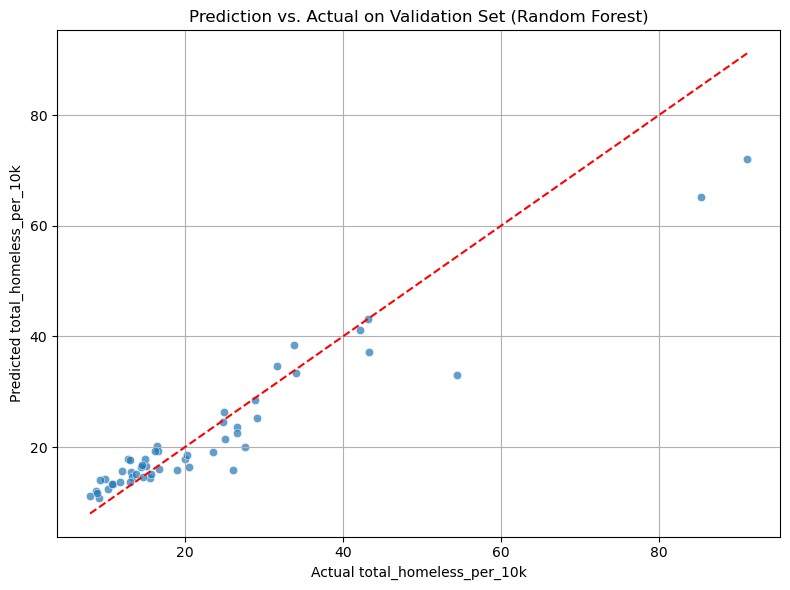

In [34]:
# Creating the plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val_task2, y=y_pred_rf_task2, alpha=0.7)

# Adding a reference line
plt.plot([y_val_task2.min(), y_val_task2.max()], [y_val_task2.min(), y_val_task2.max()], color='red', linestyle='--')

# Labeling the plot
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("Prediction vs. Actual on Validation Set (Random Forest)")
plt.grid(True)
plt.tight_layout()

plt.show()

Note: the model is underpredicting homelessness rates for the high need areas. This is common in models that are trained on small or skewed datasets. In our case, the dataset is small and is skewed.

#### 2.6.10 Saving the trained random forest model

In [ ]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generating a filename with the current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"random_forest_model_task2_{current_date}.pkl")

# Saving the model
joblib.dump(model_rf_task2, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ./models/random_forest_model_task2_20250403.pkl


#### 2.6.11 Train XGBoost model

In [25]:
# Initializing and training the model
model_xgb_task2 = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)

model_xgb_task2.fit(X_train_task2, y_train_task2)

# Extracting feature importances from XGBoost
feature_importances_xgb_task2 = pd.DataFrame({
    "Feature": selected_features_task2,
    "Importance": model_xgb_task2.feature_importances_
})

# Sorting by importance
feature_importances_xgb_task2 = feature_importances_xgb_task2.sort_values(by="Importance", ascending=False)

# Display results
print(feature_importances_xgb_task2)

                                              Feature  Importance
5                                Unsheltered Homeless    0.514484
1                                   SummerTemperature    0.074853
21                         Estimate Total Asian alone    0.060032
24                     Estimate Total  62 to 64 years    0.039452
10  Overall Homeless - Native Hawaiian or Other Pa...    0.032299
22                           Overall Homeless - Asian    0.030900
25     Estimate Total Black or African American alone    0.029964
15                  Estimate Total  85 years and over    0.027364
9                            Sheltered Total Homeless    0.022195
8                   Overall Homeless - Multiple Races    0.021078
14                  SSDI Participation Rate (Percent)    0.019148
16  Overall Homeless - American Indian or Alaska N...    0.018705
23  Total Civilian Noninstitutionalized Population...    0.016100
2                          Median_House_Values_5_year    0.013753
19        

#### 2.6.12 Evaluating the XGBoost model

In [26]:
# Predicting using the validation set
y_pred_xgb_task2 = model_xgb_task2.predict(X_val_task2)

# Computing metrics
r2_xgb_task2 = r2_score(y_val_task2, y_pred_xgb_task2)
rmse_xgb_task2 = np.sqrt(mean_squared_error(y_val_task2, y_pred_xgb_task2))

print(f"XGBoost R² on Validation Set (Task 2): {r2_xgb_task2:.4f}")
print(f"XGBoost RMSE on Validation Set (Task 2): {rmse_xgb_task2:.4f}")

XGBoost R² on Validation Set (Task 2): 0.8862
XGBoost RMSE on Validation Set (Task 2): 5.6428


#### 2.6.13 XGBoost Prediction vs Actual plot for the validation set

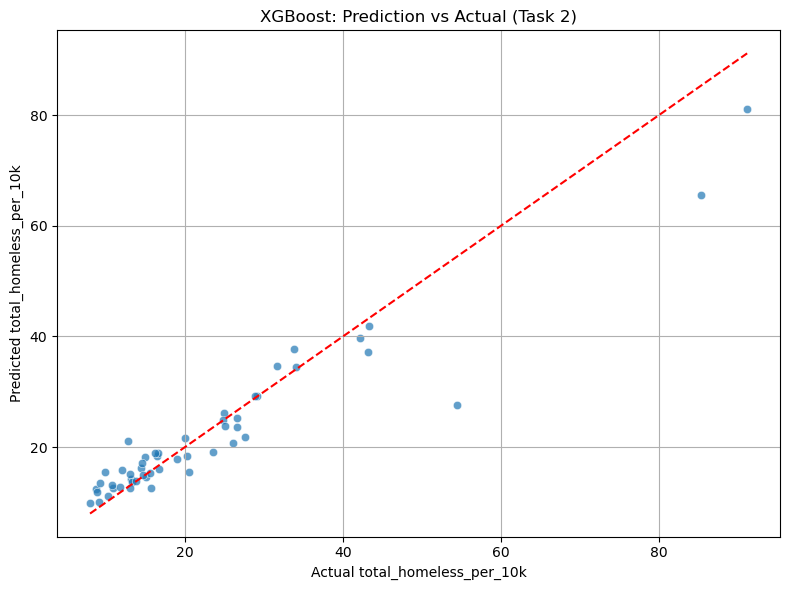

In [27]:
# Creating the plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val_task2, y=y_pred_xgb_task2, alpha=0.7)

# Adding a reference line
plt.plot([y_val_task2.min(), y_val_task2.max()],
         [y_val_task2.min(), y_val_task2.max()],
         color='red', linestyle='--')

# Labeling the plot
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("XGBoost: Prediction vs Actual (Task 2)")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2.6.14 Identifying underestimated high homelessness areas in Task2

##### 2.6.14.1 Predicting using validation set and creating the residual dataframe

In [35]:
# Random Forest
y_pred_rf_task2 = model_rf_task2.predict(X_val_task2)

# XGBoost
y_pred_xgb_task2 = model_xgb_task2.predict(X_val_task2)

# Creating the residual dataframe
df_residuals_task2 = X_val_task2.copy()
df_residuals_task2["actual"] = y_val_task2
df_residuals_task2["pred_rf"] = y_pred_rf_task2
df_residuals_task2["pred_xgb"] = y_pred_xgb_task2

# The Residuals (error)
df_residuals_task2["residual_rf"] = df_residuals_task2["actual"] - df_residuals_task2["pred_rf"]
df_residuals_task2["residual_xgb"] = df_residuals_task2["actual"] - df_residuals_task2["pred_xgb"]

# Adding CoC Number and County
df_residuals_task2["CoC Number"] = val_ids_task2["CoC Number"]
df_residuals_task2["County"] = val_ids_task2["County"]

# Looking at residual dataframe
df_residuals_task2.head()

,HPI,SummerTemperature,Median_House_Values_5_year,Median_House_Values_1_year,Overall Homeless,Unsheltered Homeless,Median_Gross_Rent_5_year,Median_Gross_Rent_1_year,Overall Homeless - Multiple Races,Sheltered Total Homeless,Overall Homeless - Native Hawaiian or Other Pacific Islander,Median_Rent_1_year,Overall Homeless - Age 18 to 24,Median_Rent_5_year,SSDI Participation Rate (Percent),Estimate Total 85 years and over,Overall Homeless - American Indian or Alaska Native,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,JanuaryPrecipitation,Estimate Total Two or more races,Estimate Total Asian alone,Overall Homeless - Asian,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Estimate Total 62 to 64 years,Estimate Total Black or African American alone,Estimate Total 60 and 61 years,actual,pred_rf,pred_xgb,residual_rf,residual_xgb,CoC Number,County
0,362.47,78.8,135700,148600.0,1426,79,960.0,940.0,41,1347,1,700.0,62,678,3.786207,0.013711,3,0.00,0.03,4.04,0.02,0.03,5,716020.0,0.037618,0.54,0.025242,13.101594,15.496916,14.204394,-2.395322,-1.102800,TN-501,shelby county
1,233.62,75.2,147800,149600.0,231,26,874.0,871.0,0,205,0,661.0,0,627,2.631752,0.016635,0,0.00,0.00,2.68,0.02,0.10,0,1073690.0,0.028579,0.13,0.018291,10.281588,12.426145,11.081613,-2.144558,-0.800025,IL-503,champaign county
2,1715.62,69.8,593500,713600.0,4145,2397,1673.0,1838.0,372,1748,30,1535.0,399,1344,1.923411,0.017668,121,0.01,0.10,9.38,0.06,0.29,107,1328629.0,0.032507,0.11,0.024231,33.844600,38.445314,37.701714,-4.600714,-3.857114,CA-502,alameda county
3,230.59,71.8,149500,147300.0,214,43,888.0,832.0,0,171,0,670.0,0,658,2.631752,0.016921,0,0.00,0.01,1.68,0.03,0.09,0,1073690.0,0.028717,0.12,0.021059,9.897023,14.147634,15.427662,-4.250611,-5.530639,IL-503,champaign county
4,401.22,82.2,161600,142200.0,3971,2020,988.0,918.0,0,1951,0,757.0,0,787,4.272722,0.038049,0,0.00,0.01,0.83,0.02,0.03,0,770703.0,0.044635,0.10,0.027674,42.118384,41.235297,39.630478,0.883087,2.487906,FL-502,pinellas county


##### 2.6.14.2 Checking for NaNs

In [36]:
# Checkin for NaNs
df_residuals_task2[["actual", "pred_rf", "pred_xgb", "residual_rf", "residual_xgb"]].isna().sum()

actual          0
pred_rf         0
pred_xgb        0
residual_rf     0
residual_xgb    0
dtype: int64

##### 2.6.14.3 Plotting the residuals for random forest

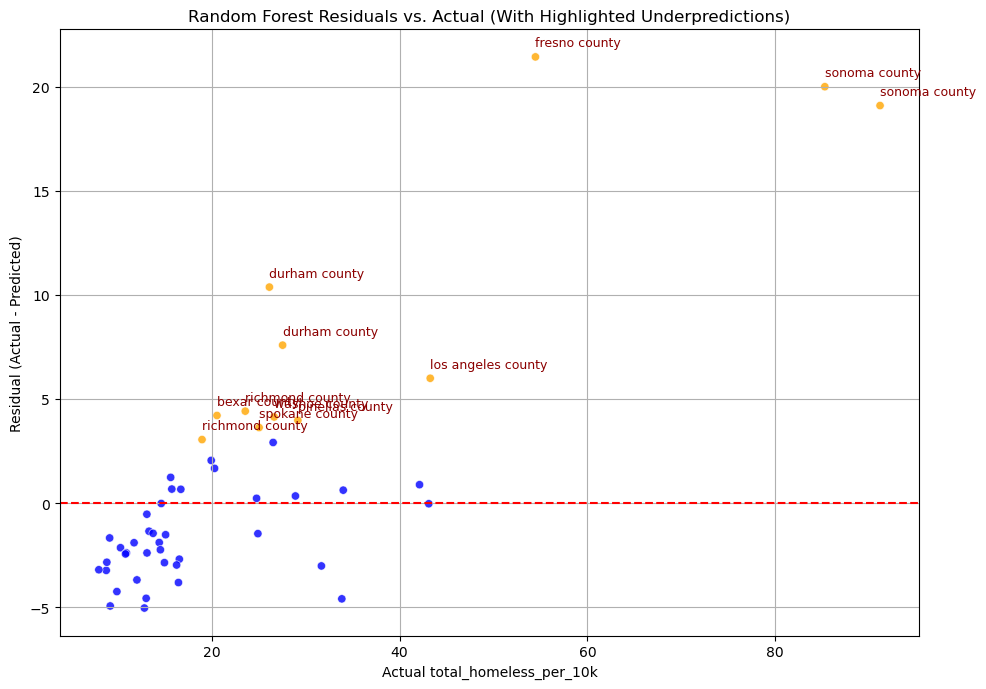

In [43]:
# Plotting Random Forest residuals vs. actual values
plt.figure(figsize=(10, 7))

# Highlighting the points where the model underpredicts significantly
sns.scatterplot(
    x="actual",
    y="residual_rf",
    data=df_residuals_task2,
    hue=df_residuals_task2["residual_rf"] > 3,
    palette={True: "orange", False: "blue"},
    legend=False,
    alpha=0.8
)

# Horizontal line at residual = 0
plt.axhline(y=0, color="red", linestyle="--")

# Adding annotations for the top 6 underpredicted counties
#top3 = df_residuals_task2.sort_values(by="residual_rf").head(6)
underpredicted = df_residuals_task2[df_residuals_task2["residual_rf"] > 3]
for _, row in underpredicted.iterrows():
    plt.text(
        row["actual"],
        row["residual_rf"] + 0.5,
        f"{row['County']}",
        fontsize=9,
        color='darkred'
    )

# Labels and title
plt.title("Random Forest Residuals vs. Actual (With Highlighted Underpredictions)")
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 2.6.14.4 Identifying the underestimated high rate area for Random Forest

In [44]:
# Selecting all counties where the residual is greater than 3
underestimated_rf = df_residuals_task2[
    df_residuals_task2["residual_rf"] > 3
].copy()

# Sorting for easier review
underestimated_rf = underestimated_rf.sort_values(by="residual_rf", ascending=False)

# Displaying the most underestimated counties
display(underestimated_rf[["County", "CoC Number", "actual", "pred_rf", "residual_rf"]].head(len(underestimated_rf)))

print(f"Count of Counties that are underestimated: {len(underestimated_rf)}")

,County,CoC Number,actual,pred_rf,residual_rf
13,fresno county,CA-514,54.459415,33.027561,21.431853
11,sonoma county,CA-504,85.270202,65.270406,19.999796
36,sonoma county,CA-504,91.149566,72.056016,19.093550
7,durham county,NC-502,26.133765,15.759531,10.374233
49,durham county,NC-502,27.541941,19.956573,7.585368
26,los angeles county,CA-600,43.257415,37.262269,5.995146
46,richmond county,GA-504,23.564006,19.148317,4.415690
14,bexar county,TX-500,20.552118,16.345345,4.206773
35,washoe county,NV-501,26.637315,22.502800,4.134515
15,pinellas county,FL-502,29.166413,25.193689,3.972725


Count of Counties that are underestimated: 12


##### 2.6.14.5 Comparing underpredicted and overpredicted for Random Forest

In [45]:
# Adding flags for underprediction and overprediction
df_residuals_task2["underestimated_rf"] = df_residuals_task2["residual_rf"] > 0
df_residuals_task2["overestimated_rf"] = df_residuals_task2["residual_rf"] < 0

# Computing mean residuals
mean_under_rf = df_residuals_task2[df_residuals_task2["underestimated_rf"]]["residual_rf"].mean()
mean_over_rf = df_residuals_task2[df_residuals_task2["overestimated_rf"]]["residual_rf"].mean()

# Display comparison
print(f"Mean residual for underestimated Random Forest counties: {mean_under_rf:.2f}")
print(f"Mean residual for overestimated Random Forest counties: {mean_over_rf:.2f}")

# Displaying how many counties fall into each group
print(f"Underestimated count: {df_residuals_task2['underestimated_rf'].sum()}")
print(f"Overestimated count: {df_residuals_task2['overestimated_rf'].sum()}")

Mean residual for underestimated Random Forest counties: 5.42
Mean residual for overestimated Random Forest counties: -2.59
Underestimated count: 22
Overestimated count: 29


Notes: The model underpredicts the high-rate counties by ~5.4 units on average and overpredicts the lower-rate counties by ~2.6 units on average. The model has a systematic bias:
- In high-homelessness counties:
  - Model predictions are too low
  - Counties like Fresno and Sonoma in California really drive this up
- In low-homelessness counties:
  - Model may be too aggressive

##### 2.6.14.6 Plotting the residual distribution for Random Forest

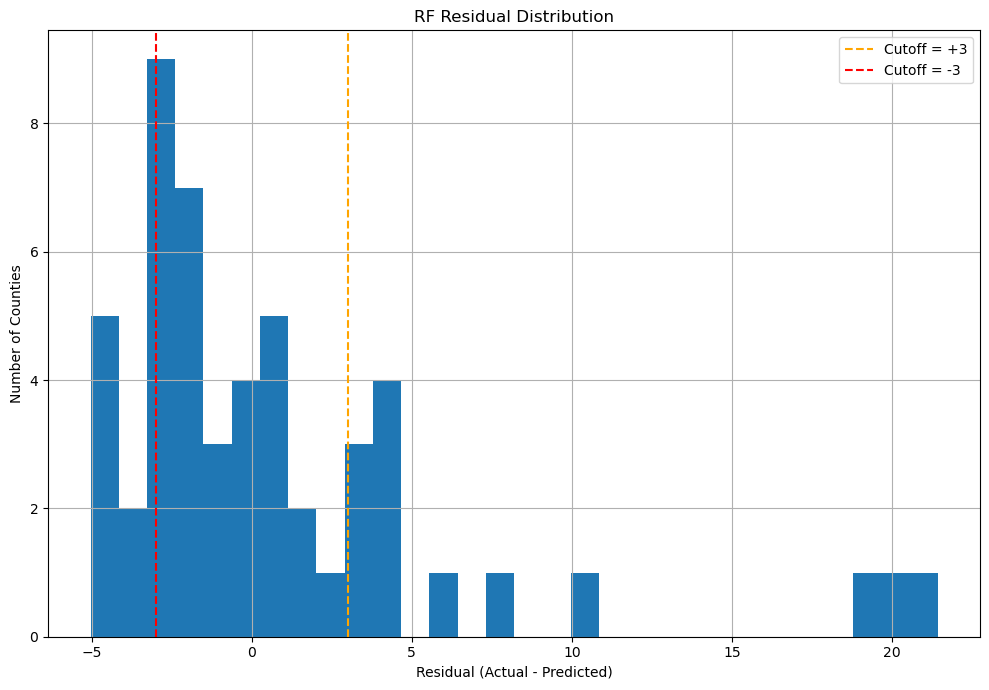

In [46]:
# Plotting Residual distribution for random forest
plt.figure(figsize=(10, 7))

df_residuals_task2["residual_rf"].hist(bins=30)
plt.title("RF Residual Distribution")
plt.axvline(3, color="orange", linestyle="--", label="Cutoff = +3")
plt.axvline(-3, color="red", linestyle="--", label="Cutoff = -3")
plt.legend()
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Counties")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 2.6.14.7 Plotting the residuals for xgboost

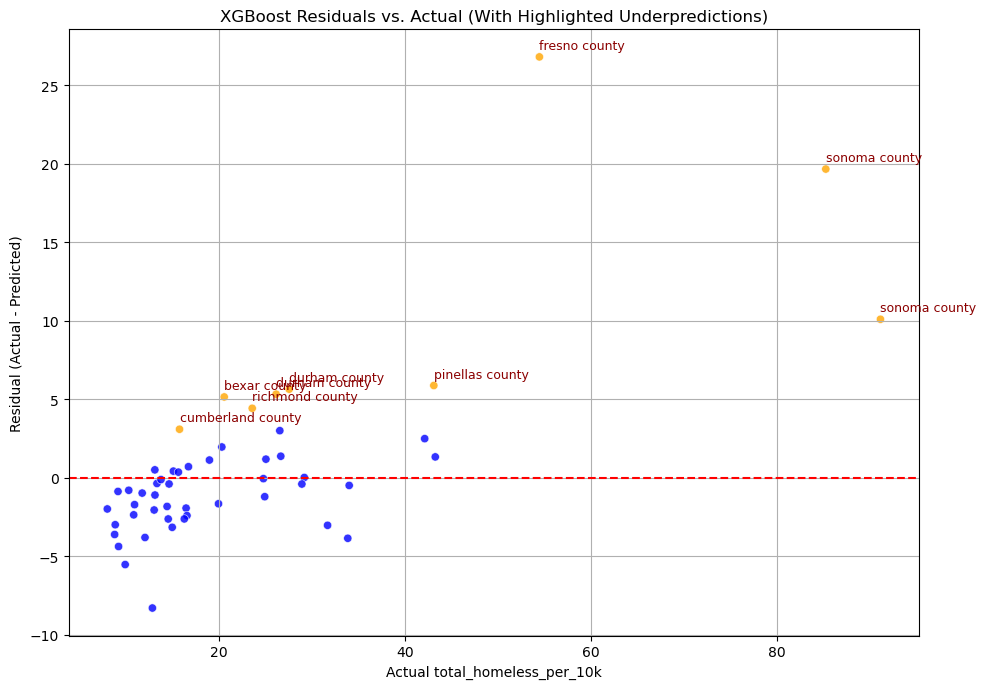

In [37]:
# Plotting XGBoost residuals vs. actual values
plt.figure(figsize=(10, 7))

# Highlighting the points where the model underpredicts significantly (residual_xgb > 3)
sns.scatterplot(
    x="actual",
    y="residual_xgb",
    data=df_residuals_task2,
    hue=df_residuals_task2["residual_xgb"] > 3,
    palette={True: "orange", False: "blue"},
    legend=False,
    alpha=0.8
)

# Horizontal line at residual = 0
plt.axhline(y=0, color="red", linestyle="--")

# Annotate all significantly underpredicted counties (residual_xgb > 3)
underpredicted_xgb = df_residuals_task2[df_residuals_task2["residual_xgb"] > 3]
for _, row in underpredicted_xgb.iterrows():
    plt.text(
        row["actual"],
        row["residual_xgb"] + 0.5,
        f"{row['County']}",
        fontsize=9,
        color='darkred'
    )

# Labels and title
plt.title("XGBoost Residuals vs. Actual (With Highlighted Underpredictions)")
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 2.6.14.8 Identifying the underestimated high rate areas for XGBoost

In [40]:
# Selecting all counties where the residual is greater than 3
underestimated_xgb = df_residuals_task2[
    df_residuals_task2["residual_xgb"] > 3
].copy()

# Sorting for easier review
underestimated_xgb = underestimated_xgb.sort_values(by="residual_xgb", ascending=False)

# Displaying the most underestimated counties
display(underestimated_xgb[["County", "CoC Number", "actual", "pred_xgb", "residual_xgb"]].head(len(underestimated_xgb)))

print(f"Count of Counties that are underestimated: {len(underestimated_xgb)}")

,County,CoC Number,actual,pred_xgb,residual_xgb
13,fresno county,CA-514,54.459415,27.660492,26.798923
11,sonoma county,CA-504,85.270202,65.613892,19.656311
36,sonoma county,CA-504,91.149566,81.059647,10.089920
47,pinellas county,FL-502,43.101249,37.229256,5.871994
49,durham county,NC-502,27.541941,21.902845,5.639096
7,durham county,NC-502,26.133765,20.813879,5.319886
14,bexar county,TX-500,20.552118,15.408708,5.143411
46,richmond county,GA-504,23.564006,19.142954,4.421053
44,cumberland county,NC-511,15.743121,12.656410,3.086711


Count of Counties that are underestimated: 9


##### 2.6.14.9 Comparing underpredicted and overpredicted for XGBoost

In [41]:
# Adding flags for underprediction and overprediction
df_residuals_task2["underestimated_xgb"] = df_residuals_task2["residual_xgb"] > 0
df_residuals_task2["overestimated_xgb"] = df_residuals_task2["residual_xgb"] < 0

# Computing mean residuals
mean_under_xgb = df_residuals_task2[df_residuals_task2["underestimated_xgb"]]["residual_xgb"].mean()
mean_over_xgb = df_residuals_task2[df_residuals_task2["overestimated_xgb"]]["residual_xgb"].mean()

# Display comparison
print(f"Mean residual for underestimated XGBoost counties: {mean_under_xgb:.2f}")
print(f"Mean residual for overestimated XGBoost counties: {mean_over_xgb:.2f}")

# Displaying how many counties fall into each group
print(f"Underestimated count: {df_residuals_task2['underestimated_xgb'].sum()}")
print(f"Overestimated count: {df_residuals_task2['overestimated_xgb'].sum()}")

Mean residual for underestimated XGBoost counties: 4.78
Mean residual for overestimated XGBoost counties: -2.22
Underestimated count: 21
Overestimated count: 30


##### 2.6.14.10 Plotting the residual distribution for XGBoost

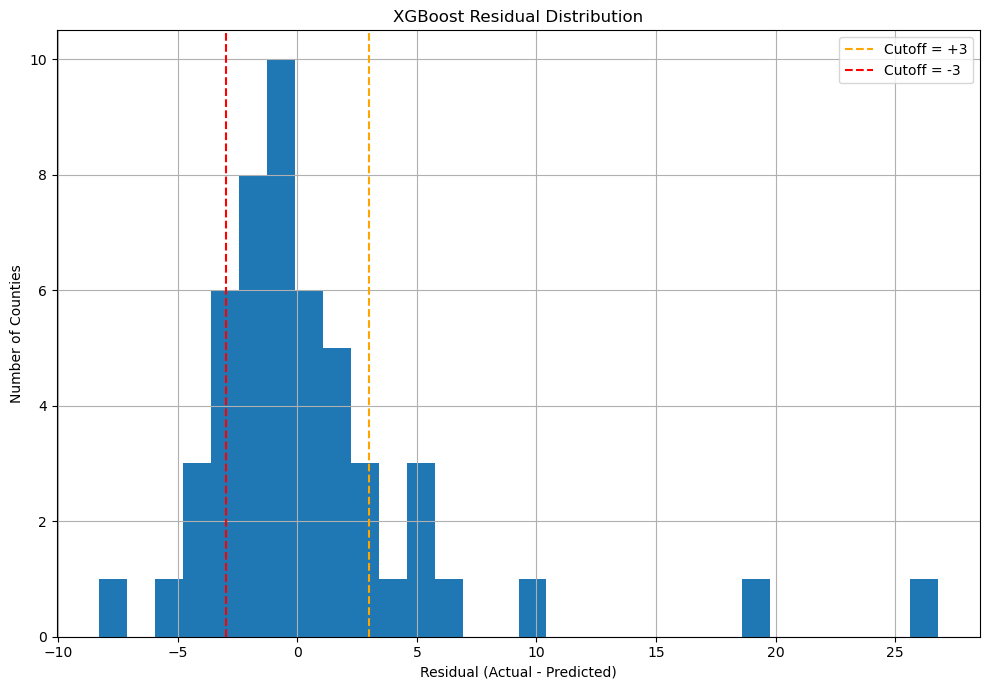

In [42]:
# Plotting Residual distribution for XGBoost
plt.figure(figsize=(10, 7))

df_residuals_task2["residual_xgb"].hist(bins=30)
plt.title("XGBoost Residual Distribution")
plt.axvline(3, color="orange", linestyle="--", label="Cutoff = +3")
plt.axvline(-3, color="red", linestyle="--", label="Cutoff = -3")
plt.legend()
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Counties")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 2.6.14.11 Side by side plot of Residual vs Actual

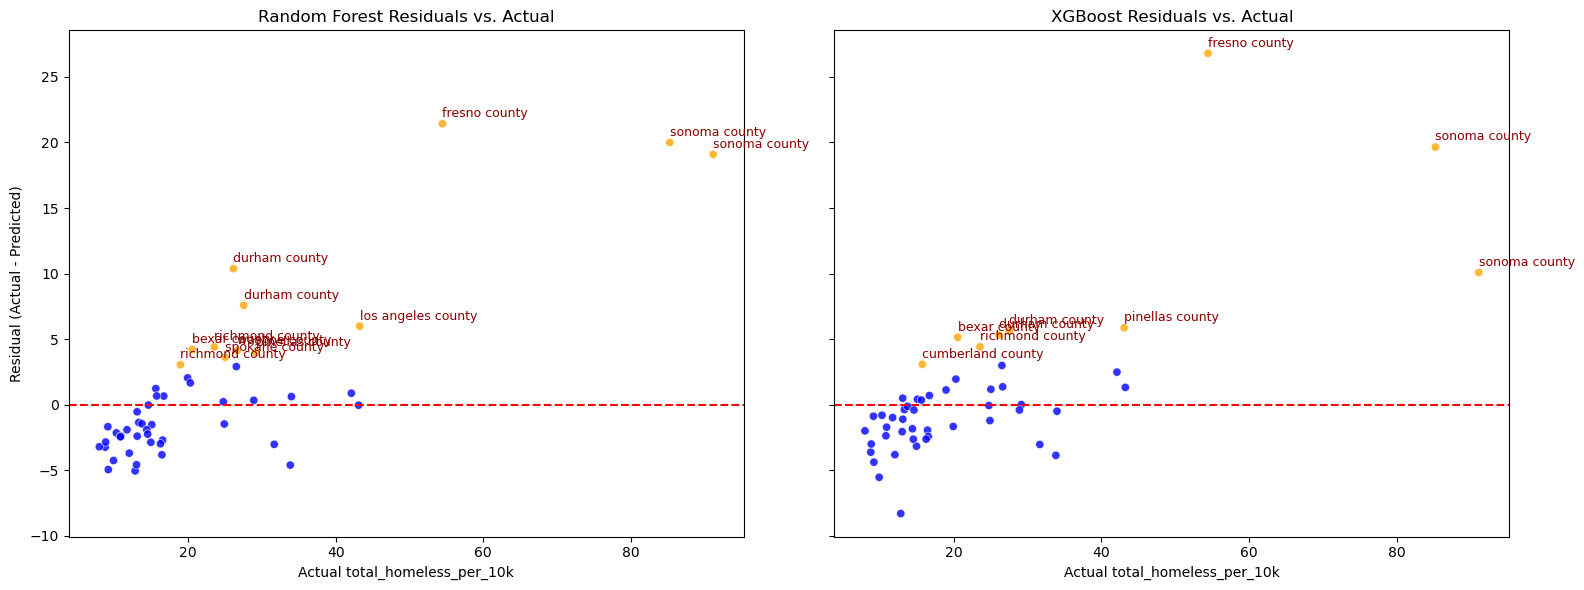

In [47]:
# Setting up for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# === 1. RANDOM FOREST ===
sns.scatterplot(
    ax=axes[0],
    x="actual",
    y="residual_rf",
    data=df_residuals_task2,
    hue=df_residuals_task2["residual_rf"] > 3,
    palette={True: "orange", False: "blue"},
    legend=False,
    alpha=0.8
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Random Forest Residuals vs. Actual")
axes[0].set_xlabel("Actual total_homeless_per_10k")
axes[0].set_ylabel("Residual (Actual - Predicted)")

# Displaying RF underpredicted counties
for _, row in df_residuals_task2[df_residuals_task2["residual_rf"] > 3].iterrows():
    axes[0].text(row["actual"], row["residual_rf"] + 0.5, row["County"], fontsize=9, color="darkred")

# === 2. XGBOOST ===
sns.scatterplot(
    ax=axes[1],
    x="actual",
    y="residual_xgb",
    data=df_residuals_task2,
    hue=df_residuals_task2["residual_xgb"] > 3,
    palette={True: "orange", False: "blue"},
    legend=False,
    alpha=0.8
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("XGBoost Residuals vs. Actual")
axes[1].set_xlabel("Actual total_homeless_per_10k")
axes[1].set_ylabel("")  # No y-label on right side

# Displaying XGB underpredicted counties
for _, row in df_residuals_task2[df_residuals_task2["residual_xgb"] > 3].iterrows():
    axes[1].text(row["actual"], row["residual_xgb"] + 0.5, row["County"], fontsize=9, color="darkred")

plt.tight_layout()
plt.show()

<a id="section-2_7"></a>
### 2.7 Temporal splitting of the dataset and analysis

#### 2.7.1 Cross-sectional temporal splitting of the data into training, validation and testing

In [20]:
def cross_sectional_temporal_split(
    df,
    selected_features,
    target_column,
    year_column="Year",
    id_columns=["CoC Number", "County", "Year"],
    train_year_max=2016,
    val_year=2017,
    test_year_min=2018,
    random_state=42
):
    """
    Perform a cross-sectional split based on counties and apply temporal filtering.

    Parameters:
        df (pd.DataFrame): Full dataset (filtered or full).
        selected_features (list): List of feature column names.
        target_column (str): Name of target column.
        year_column (str): Year column name.
        id_columns (list): Columns to retain for identification.
        train_year_max (int): Max year for training data (inclusive).
        val_year (int): Year for validation data.
        test_year_min (int): Min year for test data (inclusive).
        random_state (int): Seed for reproducibility.

    Returns:
        dict: Splits for X/y/ids and the county splits (train/val/test).
    """
    
    # Sorting for consistency
    df = df.sort_values(by=[id_columns[0], year_column]).reset_index(drop=True)

    # Extracting identifiers, features, and target
    ids_df = df[id_columns].reset_index(drop=True)
    X = df[selected_features].reset_index(drop=True)
    y = df[target_column].reset_index(drop=True)

    # Cross-sectional split on counties
    all_cocs = ids_df[id_columns[0]].unique()
    train_cocs, temp_cocs = train_test_split(all_cocs, test_size=0.4, random_state=random_state)
    val_cocs, test_cocs = train_test_split(temp_cocs, test_size=0.5, random_state=random_state)

    # Subsetting function
    def subset(data_X, data_ids, cocs, year_cond):
        mask = data_ids[id_columns[0]].isin(cocs) & year_cond
        return (
            data_X[mask].reset_index(drop=True),
            y[mask].reset_index(drop=True),
            data_ids[mask].reset_index(drop=True)
        )

    # Applying temporal masks
    train_cond = ids_df[year_column] <= train_year_max
    val_cond = ids_df[year_column] == val_year
    test_cond = ids_df[year_column] >= test_year_min

    X_train, y_train, ids_train = subset(X, ids_df, train_cocs, train_cond)
    X_val, y_val, ids_val = subset(X, ids_df, val_cocs, val_cond)
    X_test, y_test, ids_test = subset(X, ids_df, test_cocs, test_cond)

    # Printing summaries
    print(f"\nDataset split summary:")
    print(f"Train set: {X_train.shape[0]} rows, {ids_train[id_columns[0]].nunique()} counties")
    print(f"Val set:   {X_val.shape[0]} rows, {ids_val[id_columns[0]].nunique()} counties")
    print(f"Test set:  {X_test.shape[0]} rows, {ids_test[id_columns[0]].nunique()} counties")

    print("\nYear distributions:")
    print("Train years:", sorted(ids_train[year_column].unique()))
    print("Val years:  ", sorted(ids_val[year_column].unique()))
    print("Test years: ", sorted(ids_test[year_column].unique()))

    return {
        "X_train": X_train, "y_train": y_train, "ids_train": ids_train,
        "X_val": X_val, "y_val": y_val, "ids_val": ids_val,
        "X_test": X_test, "y_test": y_test, "ids_test": ids_test,
        "train_cocs": train_cocs,
        "val_cocs": val_cocs,
        "test_cocs": test_cocs
    }

#### 2.7.2 Filtered dataset results

In [15]:
# Loading the dataset
model_file_path = "./data/df_model_task2_20250429.csv"
df_model_task2_temporal = pd.read_csv(model_file_path)

# Running cross-sectional temporal split
splits_task2_temporal = cross_sectional_temporal_split(
    df=df_model_task2_temporal,
    selected_features=selected_features_task2,
    target_column=target_task2
)

# Unpack with task2_temporal naming convention
X_train_task2_temporal = splits_task2_temporal["X_train"]
y_train_task2_temporal = splits_task2_temporal["y_train"]
ids_train_task2_temporal = splits_task2_temporal["ids_train"]

X_val_task2_temporal = splits_task2_temporal["X_val"]
y_val_task2_temporal = splits_task2_temporal["y_val"]
val_ids_task2_temporal = splits_task2_temporal["ids_val"]

X_test_task2_temporal = splits_task2_temporal["X_test"]
y_test_task2_temporal = splits_task2_temporal["y_test"]
test_ids_task2_temporal = splits_task2_temporal["ids_test"]

# Display split sizes
print(f"Training set: {X_train_task2_temporal.shape[0]} rows")
print(f"Validation set: {X_val_task2_temporal.shape[0]} rows")
print(f"Testing set: {X_test_task2_temporal.shape[0]} rows")

# Year distributions
print("Train years:", ids_train_task2_temporal["Year"].unique())
print("Val years:", val_ids_task2_temporal["Year"].unique())
print("Test years:", test_ids_task2_temporal["Year"].unique())

# Unique counties per split
print("Train counties:", ids_train_task2_temporal["CoC Number"].nunique())
print("Val counties:", val_ids_task2_temporal["CoC Number"].nunique())
print("Test counties:", test_ids_task2_temporal["CoC Number"].nunique())


Training set: 154 rows
Validation set: 8 rows
Testing set: 8 rows
Train years: [2010 2011 2012 2013 2014 2015 2016]
Val years: [2017]
Test years: [2018]
Train counties: 22
Val counties: 8
Test counties: 8


##### 2.7.2.1 Checking for NaNs in Training, Validation and Test

In [22]:
def check_missing_in_splits(splits_dict):
    for name, df in splits_dict.items():
        n_missing = df.isna().sum().sum()
        print(f"{name}: {n_missing} missing values")

In [18]:
# Checking for missing values in each split
check_missing_in_splits({
    "X_train": X_train_task2_temporal,
    "X_val": X_val_task2_temporal,
    "X_test": X_test_task2_temporal,
    "y_train": y_train_task2_temporal,
    "y_val": y_val_task2_temporal,
    "y_test": y_test_task2_temporal,
})

X_train: 0 missing values
X_val: 0 missing values
X_test: 0 missing values
y_train: 0 missing values
y_val: 0 missing values
y_test: 0 missing values


##### 2.7.2.2 Train a regression model

In [19]:
# Initializing and fitting the OLS model using the temporal cross-sectional training data
model_ols_task2_temporal = LinearRegression()
model_ols_task2_temporal.fit(X_train_task2_temporal, y_train_task2_temporal)

# Displaying the coefficients
coefficients_task2_temporal = pd.DataFrame({
    "Feature": selected_features_task2,
    "Coefficient": model_ols_task2_temporal.coef_
})

print(coefficients_task2_temporal.sort_values(by="Coefficient", ascending=False))

                                              Feature   Coefficient
15                  Estimate Total  85 years and over  3.019377e+02
20                   Estimate Total Two or more races  1.862896e+02
25     Estimate Total Black or African American alone  2.673146e+01
18               Estimate Total Some other race alone  1.215187e+01
17  Estimate Total Native Hawaiian and Other Pacif...  6.164847e+00
0                                                 HPI  4.578611e-02
8                   Overall Homeless - Multiple Races  1.077810e-02
6                            Median_Gross_Rent_5_year  7.836126e-03
5                                Unsheltered Homeless  3.236002e-03
16  Overall Homeless - American Indian or Alaska N...  2.718535e-03
4                                    Overall Homeless  2.073868e-03
2                          Median_House_Values_5_year  2.836233e-05
23  Total Civilian Noninstitutionalized Population... -3.275021e-07
3                          Median_House_Values_1

##### 2.7.2.3 Evaluating the regression model

In [20]:
# Predicting using the cross-sectional temporal validation set
y_pred_ols_task2_temporal = model_ols_task2_temporal.predict(X_val_task2_temporal)

# Computing the evaluation metrics
r2_ols_task2_temporal = r2_score(y_val_task2_temporal, y_pred_ols_task2_temporal)
rmse_ols_task2_temporal = np.sqrt(mean_squared_error(y_val_task2_temporal, y_pred_ols_task2_temporal))

# Displaying results
print(f"R² Score on Validation Set: {r2_ols_task2_temporal:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set: {rmse_ols_task2_temporal:.4f}")

R² Score on Validation Set: 0.4531
Root Mean Squared Error (RMSE) on Validation Set: 11.2505


##### 2.7.2.4 Predicted vs Actual plot for validation set

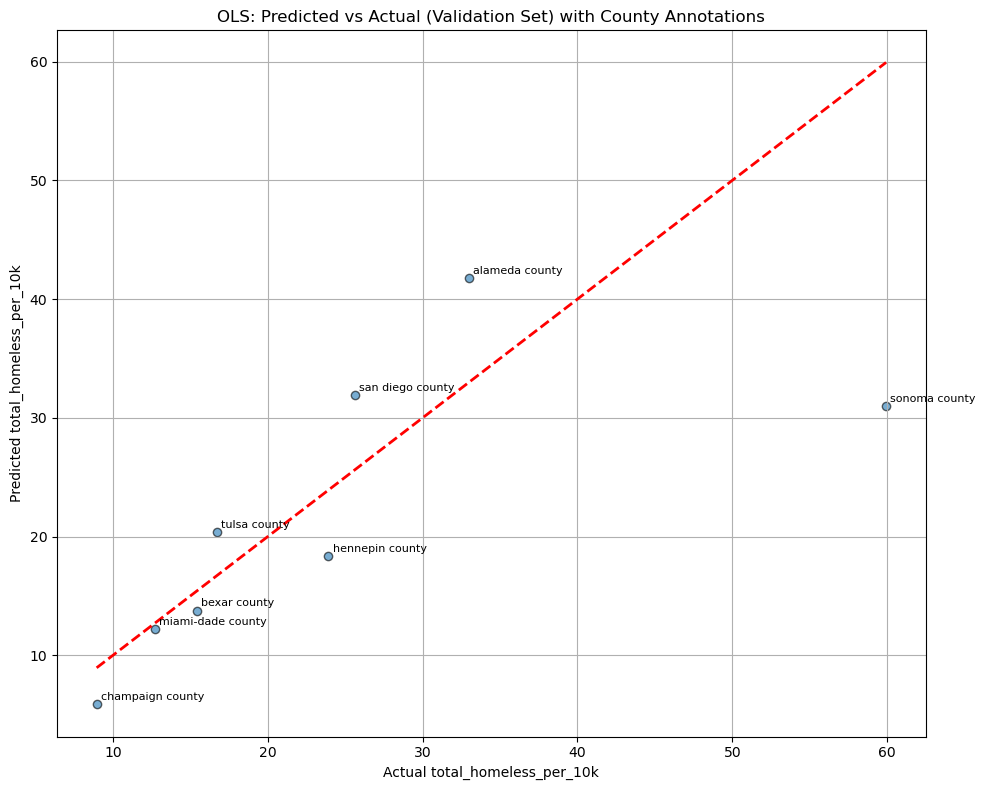

In [28]:
# Creating the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_temporal, y_pred_ols_task2_temporal, alpha=0.6, edgecolors='k')

# Reference line
plt.plot(
    [y_val_task2_temporal.min(), y_val_task2_temporal.max()],
    [y_val_task2_temporal.min(), y_val_task2_temporal.max()],
    color='red', linestyle='--', linewidth=2
)

# Adding annotations for counties
for i, county in enumerate(val_ids_task2_temporal["County"]):
    plt.annotate(county, (y_val_task2_temporal.iloc[i], y_pred_ols_task2_temporal[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("OLS: Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: this model has moderate predictive power and a reasonable baseline performance.
- the model explains ~45.3% of the variance in total_homeless_per_10k across the validation set.
- however, ~54.7% of the variation is still unexplained.
- RMSE = 11.25 which means the model's prediction is off by 11.25 homeless individuals per 10k population

##### 2.7.2.5 Saving the OLS Regression Model

In [23]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generating filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"ols_model_task2_temporal_{current_date}.pkl")

# Saving the OLS model
joblib.dump(model_ols_task2_temporal, model_path)

print(f"OLS model saved to: {model_path}")

OLS model saved to: ./models/ols_model_task2_temporal_20250430.pkl


##### 2.7.2.6 Train Random Forest model

In [ ]:
# Defining the Random Forest model
rf_model_task2_temporal = RandomForestRegressor(random_state=42)

# Defining hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf_model_task2_temporal,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Fitting the model
random_search.fit(X_train_task2_temporal, y_train_task2_temporal)

# The best model
best_rf_model_task2_temporal = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

# Displaying feature importances
importances = best_rf_model_task2_temporal.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": selected_features_task2,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances:")
print(feature_importance_df)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}

Top Feature Importances:
                                              Feature  Importance
5                                Unsheltered Homeless    0.176663
1                                   SummerTemperature    0.129085
4                                    Overall Homeless    0.112712
0                                                 HPI    0.097235
20                   Estimate Total Two or more races    0.053959
21                         Estimate Total Asian alone    0.052894
2                          Median_House_Values_5_year    0.049659
3                          Median_House_Values_1_year    0.041184
9                            Sheltered Total Homeless    0.038391
7                            Median_Gross_Rent_1_year    0.029368
19                               Janua

##### 2.7.2.7 Evaluating the Random Forest Model

In [26]:
# Evaluating Random Forest model on validation set
y_pred_rf_val_task2_temporal = best_rf_model_task2_temporal.predict(X_val_task2_temporal)

r2_rf_val_task2_temporal = r2_score(y_val_task2_temporal, y_pred_rf_val_task2_temporal)
rmse_rf_val_task2_temporal = np.sqrt(mean_squared_error(y_val_task2_temporal, y_pred_rf_val_task2_temporal))

print(f"\n[Random Forest on Validation Set]")
print(f"R² Score: {r2_rf_val_task2_temporal:.4f}")
print(f"RMSE: {rmse_rf_val_task2_temporal:.4f}")


[Random Forest on Validation Set]
R² Score: 0.3274
RMSE: 12.4772


##### 2.7.2.8 Predicted vs Actual plot for validation set

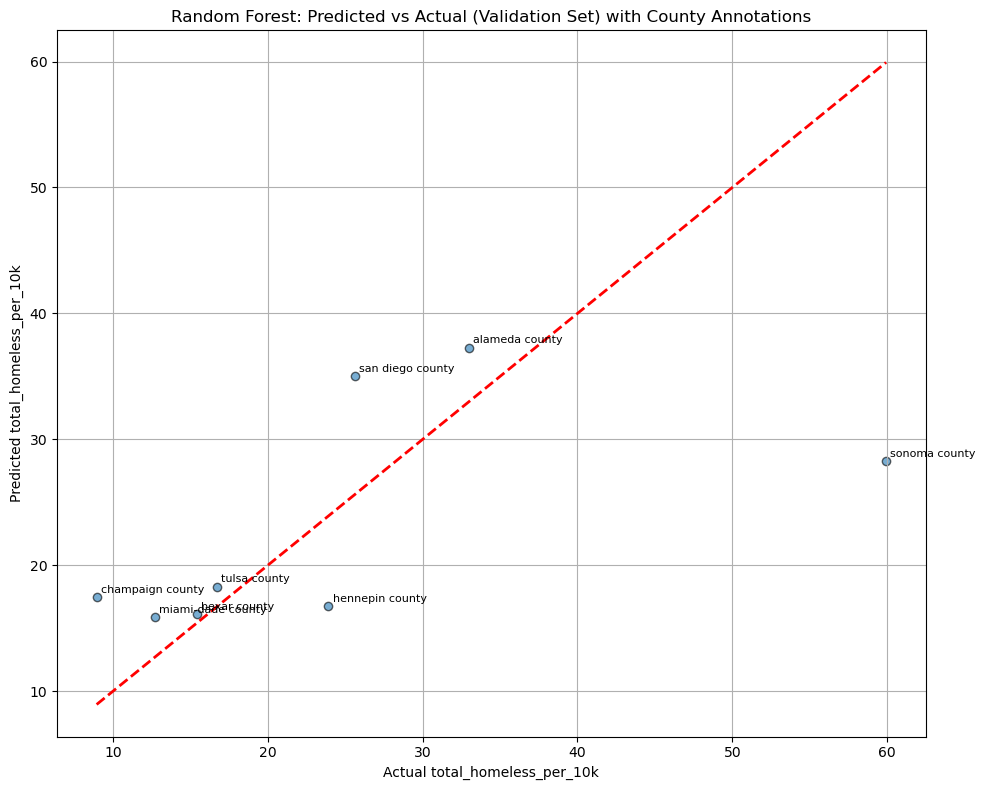

In [27]:
# Creating scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_temporal, y_pred_rf_val_task2_temporal, alpha=0.6, edgecolors='k')

# Reference line
plt.plot([y_val_task2_temporal.min(), y_val_task2_temporal.max()],
         [y_val_task2_temporal.min(), y_val_task2_temporal.max()],
         color='red', linestyle='--', linewidth=2)

# Annotating the counties
for i, county in enumerate(val_ids_task2_temporal["County"]):
    plt.annotate(county, 
                 (y_val_task2_temporal.iloc[i], y_pred_rf_val_task2_temporal[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("Random Forest: Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: the OLS model outperforms the Random Forest on both R² and RMSE. The Random Forest model struggles to generalize across the diversity of counties.
- the model explains ~32.7% of the variance in total_homeless_per_10k across the validation set. The Random Forest model struggles more to generalize to unseen counties.
- RMSE = 12.48 which means the model's prediction is off by 12.48 homeless individuals per 10k population
- Sonoma County is underpredicted significantly. The model fails to capture something structural or unique about Sonoma's homelessness rate.

##### 2.7.2.9 Saving the Random Forest model

In [29]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generating the filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"random_forest_model_task2_temporal_{current_date}.pkl")

# Saving the Random Forest model
joblib.dump(best_rf_model_task2_temporal, model_path)

print(f"Random Forest model saved to: {model_path}")

Random Forest model saved to: ./models/random_forest_model_task2_temporal_20250501.pkl


##### 2.7.2.10 Train XGBoost model

In [30]:
# Defining XGBoost Model
xgb_model_task2_temporal = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Defining parameter grid
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
    'reg_alpha': [0, 0.1, 0.5]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_task2_temporal,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Fitting the model
random_search_xgb.fit(X_train_task2_temporal, y_train_task2_temporal)

# Getting best model and feature importance
best_xgb_model_task2_temporal = random_search_xgb.best_estimator_
print("Best parameters:", random_search_xgb.best_params_)

# Feature importance
importances_xgb = best_xgb_model_task2_temporal.feature_importances_
feature_importance_df_xgb = pd.DataFrame({
    "Feature": selected_features_task2,
    "Importance": importances_xgb
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (XGBoost):")
print(feature_importance_df_xgb)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Top Feature Importances (XGBoost):
                                              Feature  Importance
5                                Unsheltered Homeless    0.200380
4                                    Overall Homeless    0.112221
9                            Sheltered Total Homeless    0.071905
1                                   SummerTemperature    0.065512
0                                                 HPI    0.064937
20                   Estimate Total Two or more races    0.048268
21                         Estimate Total Asian alone    0.044129
19                               JanuaryPrecipitation    0.039376
10  Overall Homeless - Native Hawaiian or Other Pa...    0.036946
18               Estimate Total Some other race alone    0.033245
26                 

##### 2.7.2.11 Evaluating the XGBoost model

In [31]:
# Evaluating on the validation set
y_pred_xgb_val_task2_temporal = best_xgb_model_task2_temporal.predict(X_val_task2_temporal)

r2_xgb_val_task2_temporal = r2_score(y_val_task2_temporal, y_pred_xgb_val_task2_temporal)
rmse_xgb_val_task2_temporal = np.sqrt(mean_squared_error(y_val_task2_temporal, y_pred_xgb_val_task2_temporal))

print(f"\n[XGBoost on Validation Set]")
print(f"R² Score: {r2_xgb_val_task2_temporal:.4f}")
print(f"RMSE: {rmse_xgb_val_task2_temporal:.4f}")


[XGBoost on Validation Set]
R² Score: 0.3581
RMSE: 12.1888


##### 2.7.2.12 Predicted vs Actual plot for validation set

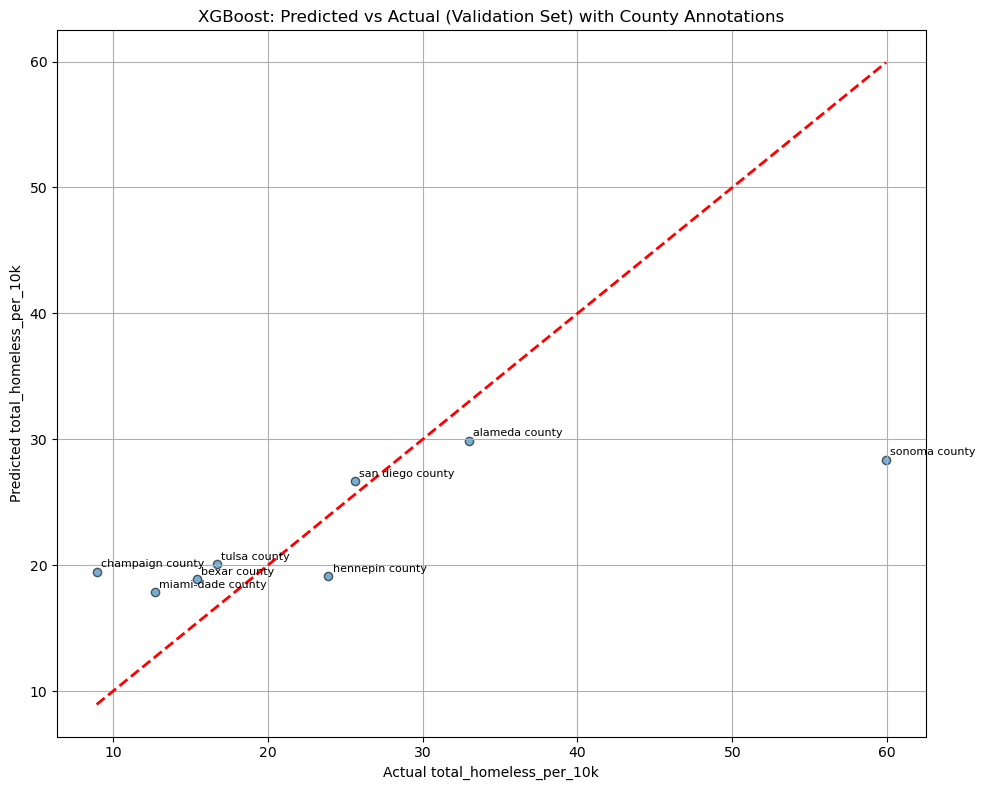

In [32]:
# Creating the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_temporal, y_pred_xgb_val_task2_temporal, alpha=0.6, edgecolors='k')

# Adding reference line
plt.plot(
    [y_val_task2_temporal.min(), y_val_task2_temporal.max()],
    [y_val_task2_temporal.min(), y_val_task2_temporal.max()],
    color='red', linestyle='--', linewidth=2
)

# Annotating each point with the corresponding county
for i, county in enumerate(val_ids_task2_temporal["County"]):
    plt.annotate(county,
                 (y_val_task2_temporal.iloc[i], y_pred_xgb_val_task2_temporal[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("XGBoost: Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: the XGBoost model generalizes better than the Random Forest but still struggles to generalize across the diversity of counties.
- the model explains ~35.8% of the variance in total_homeless_per_10k across the validation set. XGBoost is better than Random Forest but still worse than OLS.
- RMSE = 12.19 which means the model's prediction is off by 12.19 homeless individuals per 10k population. This error magnitude is still substantial.
- Sonoma County is again strongly underpredicted. The model fails to capture something structural or unique about Sonoma's homelessness rate.
- It is possible that all models are lacking key temporal or county features.

##### 2.7.2.13 Saving the XGBoost model

In [33]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generating the filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"xgboost_model_task2_temporal_{current_date}.pkl")

# Saving the XGBoost model
joblib.dump(best_xgb_model_task2_temporal, model_path)

print(f"XGBoost model saved to: {model_path}")

XGBoost model saved to: ./models/xgboost_model_task2_temporal_20250501.pkl


#### 2.7.3 One-hot encoded dataset results

In [32]:
# One-hot encoded + imputed dataset
# Loading the dataset
model_file_path = "./data/df_model_task2_onehot_20250507.csv"
df_model_task2_onehot_imputed = pd.read_csv(model_file_path)

# Running cross-sectional temporal split
splits_task2_onehot = cross_sectional_temporal_split(
    df=df_model_task2_onehot_imputed,
    selected_features=selected_features_task2_onehot,
    target_column=target_task2
)

# Unpacking with task2_onehot naming convention
X_train_task2_onehot = splits_task2_onehot["X_train"]
y_train_task2_onehot = splits_task2_onehot["y_train"]
ids_train_task2_onehot = splits_task2_onehot["ids_train"]

X_val_task2_onehot = splits_task2_onehot["X_val"]
y_val_task2_onehot = splits_task2_onehot["y_val"]
val_ids_task2_onehot = splits_task2_onehot["ids_val"]

X_test_task2_onehot = splits_task2_onehot["X_test"]
y_test_task2_onehot = splits_task2_onehot["y_test"]
test_ids_task2_onehot = splits_task2_onehot["ids_test"]


Dataset split summary:
Train set: 546 rows, 73 counties
Val set:   25 rows, 25 counties
Test set:  26 rows, 25 counties

Year distributions:
Train years: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val years:   [2017]
Test years:  [2018]


##### 2.7.3.1 Checking for NaNs in Training, Validation and Test

In [33]:
check_missing_in_splits({
    "X_train": X_train_task2_onehot,
    "X_val": X_val_task2_onehot,
    "X_test": X_test_task2_onehot,
    "y_train": y_train_task2_onehot,
    "y_val": y_val_task2_onehot,
    "y_test": y_test_task2_onehot,
})

X_train: 0 missing values
X_val: 0 missing values
X_test: 0 missing values
y_train: 0 missing values
y_val: 0 missing values
y_test: 0 missing values


##### 2.7.3.2 Train a regression model

In [34]:
# Fitting the OLS model on the one-hot encoded temporal training data
model_ols_task2_onehot = LinearRegression()
model_ols_task2_onehot.fit(X_train_task2_onehot, y_train_task2_onehot)

# Checking alignment between feature list and training columns
if list(X_train_task2_onehot.columns) == selected_features_task2_onehot:
    # Aligned: use provided feature list
    coefficients_task2_onehot = pd.DataFrame({
        "Feature": selected_features_task2_onehot,
        "Coefficient": model_ols_task2_onehot.coef_
    })
    print("Feature list is aligned with X_train_task2_onehot columns.")
else:
    # Fallback to X_train column names
    coefficients_task2_onehot = pd.DataFrame({
        "Feature": X_train_task2_onehot.columns,
        "Coefficient": model_ols_task2_onehot.coef_
    })
    print("Feature list misaligned — using X_train_task2_onehot.columns instead.")

# Displaying sorted coefficients
print(coefficients_task2_onehot.sort_values(by="Coefficient", ascending=False))

Feature list is aligned with X_train_task2_onehot columns.
                                              Feature  Coefficient
15                  Estimate Total  85 years and over   457.261759
17  Estimate Total Native Hawaiian and Other Pacif...   304.821036
20                   Estimate Total Two or more races   296.842075
27                     CoC_Category_Largely Rural CoC    52.033250
25     Estimate Total Black or African American alone    12.290362
1                                   SummerTemperature     0.358869
19                               JanuaryPrecipitation     0.105279
11                                 Median_Rent_1_year     0.035060
0                                                 HPI     0.023709
16  Overall Homeless - American Indian or Alaska N...     0.017428
8                   Overall Homeless - Multiple Races     0.011100
6                            Median_Gross_Rent_5_year     0.004712
5                                Unsheltered Homeless     0.003382
4  

##### 2.7.3.3 Evaluating the regression model

In [35]:
# Predicting using the cross-sectional temporal validation set
y_pred_ols_task2_onehot = model_ols_task2_onehot.predict(X_val_task2_onehot)

# Computing evaluation metrics
r2_ols_task2_onehot = r2_score(y_val_task2_onehot, y_pred_ols_task2_onehot)
rmse_ols_task2_onehot = np.sqrt(mean_squared_error(y_val_task2_onehot, y_pred_ols_task2_onehot))

# Displaying results
print(f"R² Score on Validation Set (One-Hot): {r2_ols_task2_onehot:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set (One-Hot): {rmse_ols_task2_onehot:.4f}")

R² Score on Validation Set (One-Hot): 0.3566
Root Mean Squared Error (RMSE) on Validation Set (One-Hot): 7.9965


##### 2.7.3.4 Predicted vs Actual plot for validation set

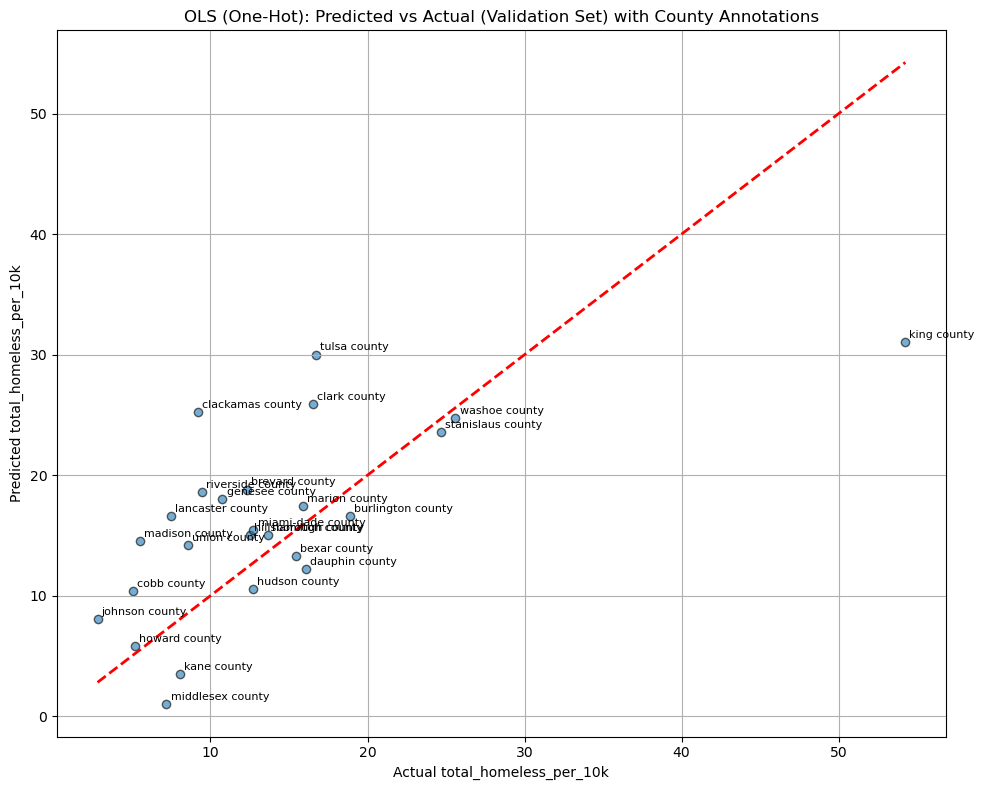

In [36]:
# Creating the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_onehot, y_pred_ols_task2_onehot, alpha=0.6, edgecolors='k')

# Reference line (perfect prediction)
plt.plot(
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    color='red', linestyle='--', linewidth=2
)

# Adding county annotations
for i, county in enumerate(val_ids_task2_onehot["County"]):
    plt.annotate(county,
                 (y_val_task2_onehot.iloc[i], y_pred_ols_task2_onehot[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("OLS (One-Hot): Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: OLS Evaluation (One-Hot Encoded + Temporal Split)

- **R² Score**: 0.36 – The model explains about 36% of the variation in homelessness rates across counties.
- **RMSE**: 7.99 – On average, predictions are off by 8 individuals per 10,000.
- This baseline model captures some meaningful signal but struggles with high-homelessness counties. This suggests possible underfitting.
- As a next step, I am going to try the Random Forest model.

##### 2.7.3.5 Saving the OLS Regression Model

In [37]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generating the filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"ols_model_task2_onehot_{current_date}.pkl")

# Saving the OLS one-hot encoded model
joblib.dump(model_ols_task2_onehot, model_path)

print(f"OLS model (One-Hot) saved to: {model_path}")

OLS model (One-Hot) saved to: ./models/ols_model_task2_onehot_20250507.pkl


##### 2.7.3.6 Train Random Forest model

In [38]:
# Defining the Random Forest model
rf_model_task2_onehot = RandomForestRegressor(random_state=42)

# Defining hyperparameter grid
param_dist_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized search with cross-validation
random_search_rf = RandomizedSearchCV(
    estimator=rf_model_task2_onehot,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Fitting the model on one-hot encoded training data
random_search_rf.fit(X_train_task2_onehot, y_train_task2_onehot)

# Retrieve the best model
best_rf_model_task2_onehot = random_search_rf.best_estimator_
print("Best parameters found:")
print(random_search_rf.best_params_)

# Displaying feature importances
importances_rf = best_rf_model_task2_onehot.feature_importances_
feature_importance_df_rf = pd.DataFrame({
    "Feature": selected_features_task2_onehot,
    "Importance": importances_rf
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (Random Forest - One-Hot):")
print(feature_importance_df_rf)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

Top Feature Importances (Random Forest - One-Hot):
                                              Feature  Importance
0                                                 HPI    0.164088
5                                Unsheltered Homeless    0.139465
4                                    Overall Homeless    0.094031
6                            Median_Gross_Rent_5_year    0.065527
27                     CoC_Category_Largely Rural CoC    0.049782
24                     Estimate Total  62 to 64 years    0.046207
13                                 Median_Rent_5_year    0.044676
2                          Median_House_Values_5_year    0.042403
7                            Median_Gross_Rent_1_year    0.040899
25     Estimate Total Black or African American alone    0.032787
9       

##### 2.7.3.7 Evaluating the Random Forest Model

In [39]:
# Predicting on the validation set (one-hot)
y_pred_rf_val_task2_onehot = best_rf_model_task2_onehot.predict(X_val_task2_onehot)

# Computing evaluation metrics
r2_rf_val_task2_onehot = r2_score(y_val_task2_onehot, y_pred_rf_val_task2_onehot)
rmse_rf_val_task2_onehot = np.sqrt(mean_squared_error(y_val_task2_onehot, y_pred_rf_val_task2_onehot))

# Displaying results
print(f"\n[Random Forest on Validation Set (One-Hot Encoded)]")
print(f"R² Score: {r2_rf_val_task2_onehot:.4f}")
print(f"RMSE: {rmse_rf_val_task2_onehot:.4f}")


[Random Forest on Validation Set (One-Hot Encoded)]
R² Score: 0.4668
RMSE: 7.2799


##### 2.7.3.8 Predicted vs Actual plot for validation set

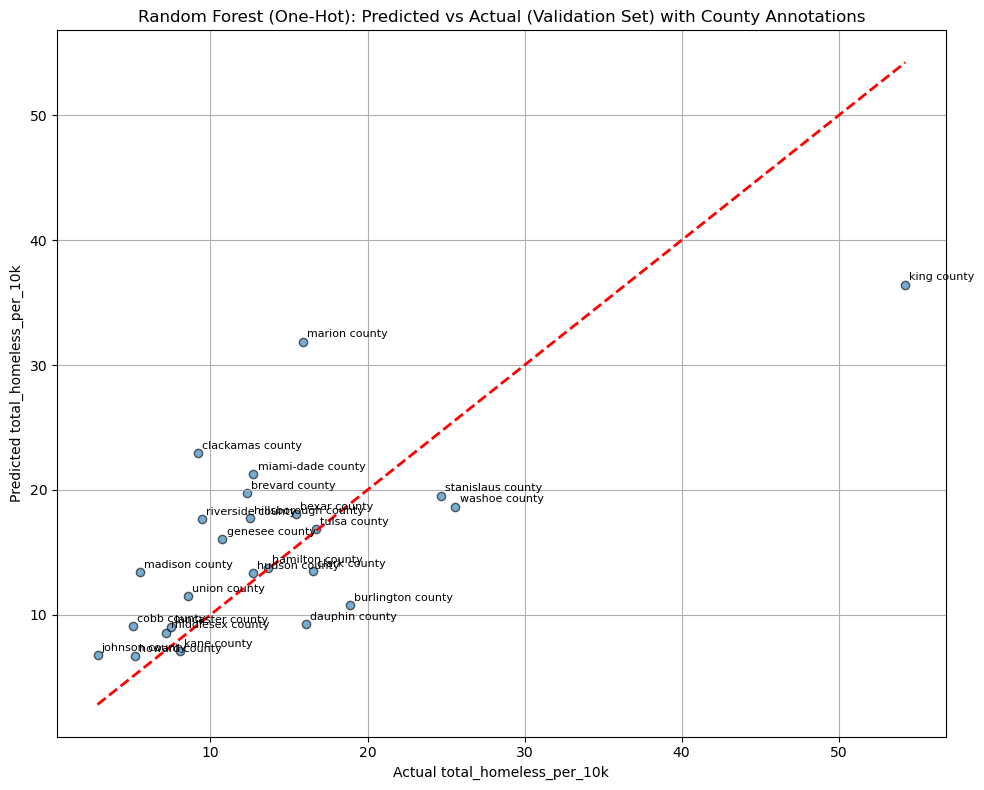

In [40]:
# Creating the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_onehot, y_pred_rf_val_task2_onehot, alpha=0.6, edgecolors='k')

# Add reference line (perfect prediction)
plt.plot(
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    color='red', linestyle='--', linewidth=2
)

# Annotating with counties
for i, county in enumerate(val_ids_task2_onehot["County"]):
    plt.annotate(county,
                 (y_val_task2_onehot.iloc[i], y_pred_rf_val_task2_onehot[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("Random Forest (One-Hot): Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: Random Forest Evaluation (One-Hot Encoded + Cross-Sectional Temporal Split)

- **R² Score**: 0.467 — explains ~47% of variance in homelessness rates.
- **RMSE**: 7.28 — lower error than OLS, improving predictive accuracy.
- **Compared to OLS**:
  - +11% increase in explained variance.
  - ~0.7 unit reduction in prediction error per 10k people.
- **Strengths**:
  - Better performance at middle ranges of homelessness (10–30 per 10k).
- **Limitations**:
  - Still underpredicts extreme cases (King County).
  - Tendency to overpredict for some moderate counties (Marion County).
- **Next Steps**:
  - Will try XGBoost for improved performance.

##### 2.7.3.9 Saving the Random Forest model

In [41]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generate filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"random_forest_model_task2_onehot_{current_date}.pkl")

# Saving the Random Forest model
joblib.dump(best_rf_model_task2_onehot, model_path)

print(f"Random Forest model (One-Hot) saved to: {model_path}")

Random Forest model (One-Hot) saved to: ./models/random_forest_model_task2_onehot_20250508.pkl


##### 2.7.3.10 Train XGBoost model

In [42]:
# Defining XGBoost model
xgb_model_task2_onehot = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define parameter grid
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
    'reg_alpha': [0, 0.1, 0.5]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_task2_onehot,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Fitting the model using the one-hot encoded training data
random_search_xgb.fit(X_train_task2_onehot, y_train_task2_onehot)

# Best model and feature importances
best_xgb_model_task2_onehot = random_search_xgb.best_estimator_
print("Best parameters (XGBoost - One-Hot):")
print(random_search_xgb.best_params_)

# Extracting and displaying feature importances
importances_xgb = best_xgb_model_task2_onehot.feature_importances_
feature_importance_df_xgb = pd.DataFrame({
    "Feature": selected_features_task2_onehot,
    "Importance": importances_xgb
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (XGBoost - One-Hot):")
print(feature_importance_df_xgb)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters (XGBoost - One-Hot):
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Top Feature Importances (XGBoost - One-Hot):
                                              Feature  Importance
27                     CoC_Category_Largely Rural CoC    0.222049
0                                                 HPI    0.135645
5                                Unsheltered Homeless    0.123341
4                                    Overall Homeless    0.049386
24                     Estimate Total  62 to 64 years    0.043577
6                            Median_Gross_Rent_5_year    0.040268
2                          Median_House_Values_5_year    0.034345
13                                 Median_Rent_5_year    0.034012
26                    Estimate Total  60 and 61 years    0.030427
9                            Sheltered Total Homeless  

##### 2.7.3.11 Evaluating the XGBoost model

In [43]:
# Predicting on the validation set (one-hot)
y_pred_xgb_val_task2_onehot = best_xgb_model_task2_onehot.predict(X_val_task2_onehot)

# Computing evaluation metrics
r2_xgb_val_task2_onehot = r2_score(y_val_task2_onehot, y_pred_xgb_val_task2_onehot)
rmse_xgb_val_task2_onehot = np.sqrt(mean_squared_error(y_val_task2_onehot, y_pred_xgb_val_task2_onehot))

# Displaying results
print(f"\n[XGBoost on Validation Set (One-Hot Encoded)]")
print(f"R² Score: {r2_xgb_val_task2_onehot:.4f}")
print(f"RMSE: {rmse_xgb_val_task2_onehot:.4f}")


[XGBoost on Validation Set (One-Hot Encoded)]
R² Score: 0.5289
RMSE: 6.8424


##### 2.7.3.12 Predicted vs Actual plot for validation set

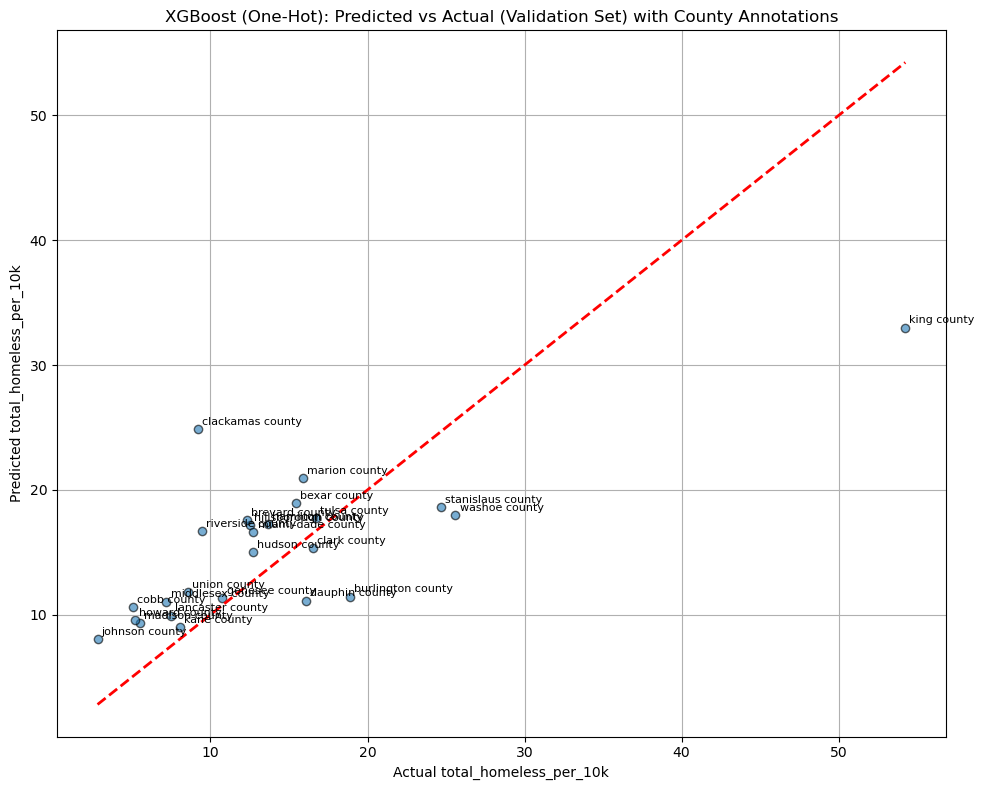

In [44]:
# Creating the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task2_onehot, y_pred_xgb_val_task2_onehot, alpha=0.6, edgecolors='k')

# Add reference line (perfect prediction)
plt.plot(
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    [y_val_task2_onehot.min(), y_val_task2_onehot.max()],
    color='red', linestyle='--', linewidth=2
)

# Annotating counties
for i, county in enumerate(val_ids_task2_onehot["County"]):
    plt.annotate(county,
                 (y_val_task2_onehot.iloc[i], y_pred_xgb_val_task2_onehot[i]),
                 textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8)

# Labels and title
plt.xlabel("Actual total_homeless_per_10k")
plt.ylabel("Predicted total_homeless_per_10k")
plt.title("XGBoost (One-Hot): Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

Notes: XGBoost Evaluation (One-Hot Encoded + Cross-Sectional Temporal Split)

- **R² Score**: 0.53 – Explains over half of the variance in homelessness rates.
- **RMSE**: 6.84 – Lowest prediction error among all tested models.
- **Compared to OLS and Random Forest**:
  - +17% and +7% higher R² respectively.
  - Improved fit across both mid-range and high-range homelessness values.
- **Strengths**:
  - Best model so far in terms of both accuracy and generalization.
- **Remaining limitations**:
  - Slight underprediction in counties with extreme homelessness (King County).
- **Next steps**:
  - Add lagged variables and year-over-year changes.


##### 2.7.3.13 Saving the XGBoost model

In [45]:
# Creating the output directory
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Generate the filename with current date
current_date = datetime.datetime.now().strftime("%Y%m%d")
model_path = os.path.join(output_dir, f"xgboost_model_task2_onehot_{current_date}.pkl")

# Saving the XGBoost model
joblib.dump(best_xgb_model_task2_onehot, model_path)

print(f"XGBoost model (One-Hot) saved to: {model_path}")

XGBoost model (One-Hot) saved to: ./models/xgboost_model_task2_onehot_20250508.pkl


<a id="section-3"></a>
## Section 3 - Models to predict annual homelessness rates using the percentage change in total_homeless_per_10k

<a id="section-3_1"></a>
### 3.1 Loading the full dataset into a dataframe

In [3]:
current_date = datetime.datetime.now().strftime("%m_%d_%Y")

# Loading the full dataset
file_path = "./data/homeless_dataset_full.csv"
df_homeless_full = pd.read_csv(file_path, encoding="utf-8")

# Displaying a sample to verify
df_homeless_full.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
846,OK-501,tulsa county,2013,1008,886,122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['OK-501'],['Tulsa City & County CoC'],Major City CoC,oklahoma,136100.0,0.422550,608.0,836.0,0.41,81.0,274279.0,0.006336,0.0,228.0,134100,0.441534,599,857.0,0.39,8.9,270608,0.005254,0.0,258.0,0500000US40143,40143.0,1.04,354.67,176.12,123.44,CN4014300000000,40.0,143.0,310617.0,295245.0,15372.0,4.9,622409.0,0.119662,0.71,0.10,0.04,0.03,0.00,0.03,0.09,NaN,NaN,0.071051,0.039853,0.024447,0.014029,0.012577,0.043581,0.073066,0.072380,0.064748,0.064051,0.061882,0.069980,0.067183,0.065136,0.023231,0.031683,0.021492,0.022265,0.027382,0.022564,0.016083,0.017472,0.073863,0.51

<a id="section-3_2"></a>
### 3.2 Filtering for Major City and Largely Urban CoCs task3 model

In [4]:
# Filtering for Major City and Largely Urban CoC Categories
df_filtered_task3 = df_homeless_full[df_homeless_full["CoC Category"].isin(["Major City CoC", "Other Largely Urban CoC"])].copy()

# Displaying 5 random rows
df_filtered_task3.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
324,GA-504,richmond county,2016,287,266,21,56,15,216,118,169,5,80,0,0,0,0,9,191,5,2,['GA-504'],['Augusta-Richmond County CoC'],Other Largely Urban CoC,georgia,101600.0,0.453284,646.0,800.0,0.47,78.0,88171.0,0.005599,0.00,154.0,100600,0.497440,613,804.0,0.47,89.0,87290,0.006113,0.00,191.0,0500000US13245,13245.0,0.58,332.00,155.22,119.75,CN1324500000000,13.0,245.0,84842.0,79035.0,5807.0,6.8,201647.0,0.116263,0.38,0.57,0.00,0.02,0.00,0.01,0.01,NaN,NaN,0.056177,0.036673,0.031570,0.018726,0.017278,0.047395,0.092295,0.073019,0.056634,0.057368,0.052076,0.071174,0.062322,0.060313,0.028014,0.037219,0.022277,0.023536,0.034957,0.021553,0.017754,

<a id="section-3_3"></a>
### 3.3 Sorting by CoC and year

In [5]:
# Sorting by CoC Number and Year in preparation for percent change calculation
df_filtered_task3.sort_values(by=["CoC Number", "Year"], inplace=True)

# Displaying 5 rows
df_filtered_task3.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-501'],['Mobile City & County/Baldwin County CoC'],Other Largely Urban CoC,alabama,131800.0,0.494913,506.0,785.0,0.33,123.0,178726.0,0.008180,0.0,279.0,120700,0.472663,513,NaN,0.32,97.0,175753,0.005029,0.0,NaN,0500000US01097,1097.0,-7.22,389.86,194.62,132.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413277.0,0.111552,0.61,0.35,0.01,0.02,0.0,0.00,0.01,NaN,NaN,0.073454,0.044416,0.028521,0.012885,0.019733,0.038183,0.067594,0.062682,0.062425,0.062152,0.072535,0.062849,0.073041,0.066703,0.023367,0.030941,0.015145,0.025039,0.033171,0.024577,0.017226,0.014293,0.069070,0.52,NaN,39998

<a id="section-3_4"></a>
### 3.4 Calculating the percentage change in total_homeless_per_10k

In [6]:
# Calculating the percentage change in total_homeless_per_10k
df_filtered_task3["pct_change_total_homeless_per_10k"] = (df_filtered_task3.groupby("CoC Number")["total_homeless_per_10k"].pct_change())

# Displaying 5 rows
df_filtered_task3.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-501'],['Mobile City & County/Baldwin County CoC'],Other Largely Urban CoC,alabama,131800.0,0.494913,506.0,785.0,0.33,123.0,178726.0,0.008180,0.0,279.0,120700,0.472663,513,NaN,0.32,97.0,175753,0.005029,0.0,NaN,0500000US01097,1097.0,-7.22,389.86,194.62,132.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413277.0,0.111552,0.61,0.35,0.01,0.02,0.0,0.00,0.01,NaN,NaN,0.073454,0.044416,0.028521,0.012885,0.019733,0.038183,0.067594,0.062682,0.062425,0.062152,0.072535,0.062849,0.073041,0.066703,0.023367,0.030941,0.015145,0.025039,0.033171,0.024577,0.01722

<a id="section-3_5"></a>
### 3.5 Dropping missing values from the first year

In [7]:
# Dropping rows where the percentage change is NaN
df_filtered_task3.dropna(subset=["pct_change_total_homeless_per_10k"], inplace=True)

<a id="section-3_6"></a>
### 3.6 Heatmap to highlight only correlations with pct_change_total_homeless_per_10k

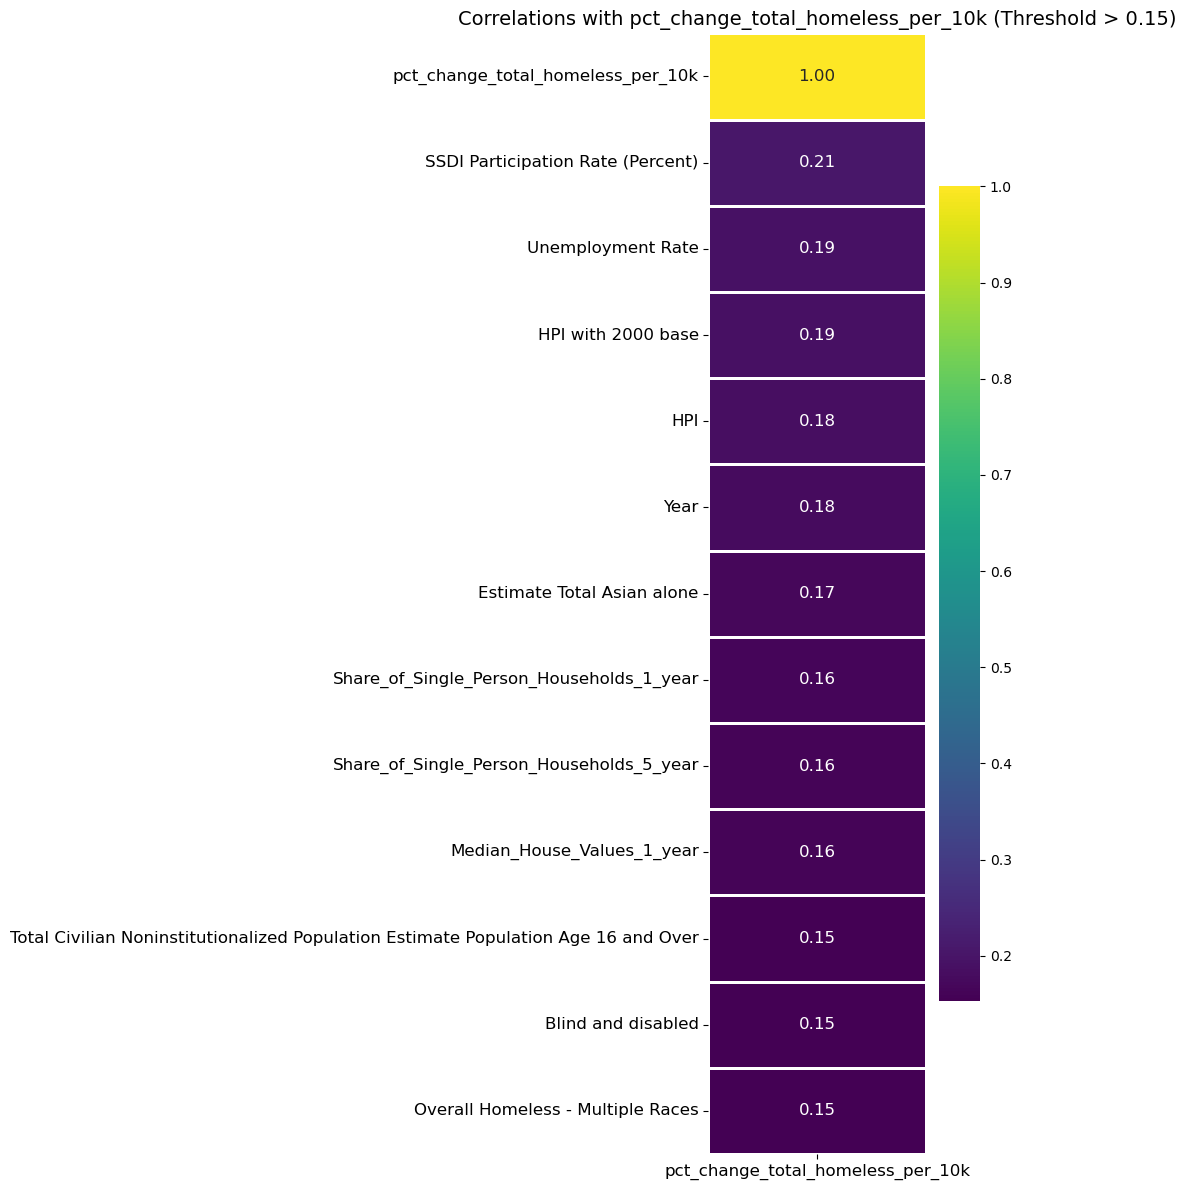

In [8]:
# Correlation heatmap for pct_change_total_homeless_per_10k (Task 3)
plt.figure(figsize=(10, 12))

# Correlation matrix from task 3 modeling dataset
corr_matrix_task3 = df_filtered_task3.select_dtypes(include=['number']).corr()

# Extracting correlations with Task 3 target
target_corr_task3 = corr_matrix_task3[['pct_change_total_homeless_per_10k']].copy()

# Setting threshold
threshold = 0.15  

# Filter and sort
target_corr_task3 = target_corr_task3[abs(target_corr_task3) > threshold].dropna()
target_corr_task3 = target_corr_task3.abs().sort_values(by='pct_change_total_homeless_per_10k', ascending=False)

# Plot
sns.heatmap(
    target_corr_task3,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.75,
    annot_kws={"size": 12}
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.title(f"Correlations with pct_change_total_homeless_per_10k (Threshold > {threshold})", fontsize=14)
plt.tight_layout()
plt.show()

<a id="section-3_7"></a>
### 3.7 Saving correlations with pct_change_total_homeless_per_10k to CSV

In [54]:
# Saving correlations with pct_change_total_homeless_per_10k to CSV
# Getting current date in the format YYYYMMDD
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Defining the output CSV file path
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)  # Ensure directory exists

# Construct output filename with task 3 indicator
correlation_csv_path_task3 = os.path.join(
    output_dir, f"pct_change_total_homeless_per_10k_correlations_{current_date}.csv"
)

# Saving Task 3 correlations to a CSV file
target_corr_task3.to_csv(correlation_csv_path_task3, encoding="utf-8")

print(f"Task 3 correlations saved to: {correlation_csv_path_task3}")

Task 3 correlations saved to: ./data/pct_change_total_homeless_per_10k_correlations_20250407.csv


<a id="section-3_8"></a>
### 3.8 Using the demographic and socioeconomic features for the task3 model

In [9]:
# Loading the correlation file to identify the strongest predictors
correlation_file_path = "./data/pct_change_total_homeless_per_10k_correlations_20250330.csv"
df_correlations_task3 = pd.read_csv(correlation_file_path, index_col=0)

# Selecting the strongest predictors based on correlation values
threshold = 0.15
strong_predictors = df_correlations_task3[
    abs(df_correlations_task3["pct_change_total_homeless_per_10k"]) > threshold
].index.tolist()

# Define target variable
target_task3 = "pct_change_total_homeless_per_10k"

# Exclude the target and highly collinear features
features_to_exclude = [
    target_task3,
    "total_homeless_per_10k",
    "total_sheltered_homeless_per_10k",
    "unsheltered_homeless_per_10k"
]

# Final selected features (after exclusions)
selected_features_task3 = [
    feature for feature in strong_predictors
    if feature in df_filtered_task3.columns and feature not in features_to_exclude
]

# Columns to preserve for identification
id_columns = ["CoC Number", "County"]
available_ids = [col for col in id_columns if col in df_filtered_task3.columns]

# Final modeling DataFrame for Task 3
df_model_task3 = df_filtered_task3[
    available_ids + selected_features_task3 + [target_task3]
].copy()

# Adding binary classification target: 1 = increase, 0 = decrease or no change
df_model_task3["target_class"] = (df_model_task3["pct_change_total_homeless_per_10k"] > 0).astype(int)

# Display sample rows to verify
df_model_task3.sample(5, random_state=45)

,CoC Number,County,SSDI Participation Rate (Percent),Unemployment Rate,HPI with 2000 base,HPI,Year,Estimate Total Asian alone,Share_of_Single_Person_Households_1_year,Share_of_Single_Person_Households_5_year,Median_House_Values_1_year,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Blind and disabled,Overall Homeless - Multiple Races,pct_change_total_homeless_per_10k,target_class
253,FL-600,miami-dade county,NaN,NaN,141.88,486.97,2011,0.02,0.0,0.0,174700.0,NaN,NaN,0,0.027075,1
212,FL-502,pinellas county,4.235792,5.0,168.53,529.07,2015,0.03,0.0,0.0,170500.0,798670.0,19278.0,99,-0.189405,0
1111,WA-502,spokane county,NaN,6.0,165.41,579.96,2016,0.02,0.0,0.0,201300.0,NaN,NaN,77,0.095569,1
123,CA-600,los angeles county,1.840622,5.3,232.25,1373.51,2016,0.15,0.0,0.0,537900.0,8088028.0,274143.0,1822,0.192820,1
157,CA-604,kern county,3.244271,10.5,167.74,502.79,2014,0.05,0.0,0.0,183100.0,616163.0,28698.0,0,-0.046577,0


#### 3.8.1 Looking at structure and basic information

In [10]:
# Looking at structure and basic information
df_model_task3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 1 to 1158
Data columns (total 16 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   CoC Number                                                                          304 non-null    object 
 1   County                                                                              304 non-null    object 
 2   SSDI Participation Rate (Percent)                                                   168 non-null    float64
 3   Unemployment Rate                                                                   266 non-null    float64
 4   HPI with 2000 base                                                                  304 non-null    float64
 5   HPI                                                                                 304 non-null    flo

<a id="section-3_9"></a>
### 3.9 Handling missing values for task3 model

Two of the columns have missing values:
- Social Security Disability Insurance (SSDI) Participation Rate (Percent): 136
- Unemployment rate: 38
- Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over: 136
- Blind and disabled: 136

#### 3.9.1 Checking for missing values

In [11]:
# Checking for missing values
display(df_model_task3.isnull().sum().to_frame().T)

,CoC Number,County,SSDI Participation Rate (Percent),Unemployment Rate,HPI with 2000 base,HPI,Year,Estimate Total Asian alone,Share_of_Single_Person_Households_1_year,Share_of_Single_Person_Households_5_year,Median_House_Values_1_year,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Blind and disabled,Overall Homeless - Multiple Races,pct_change_total_homeless_per_10k,target_class
0,0,0,136,38,0,0,0,0,0,0,0,136,136,0,0,0


#### 3.9.2 Filling missing values with the median of each column

In [12]:
# Filling the missing values with median
#df_model_task3.fillna(df_model_task3.median(), inplace=True)
numeric_cols_task3 = df_model_task3.select_dtypes(include=['number']).columns
df_model_task3[numeric_cols_task3] = df_model_task3[numeric_cols_task3].fillna(df_model_task3[numeric_cols_task3].median())

# Making sure that missing values are handled
df_model_task3[numeric_cols_task3].isna().sum().sum()

0

#### 3.9.3 Checking for missing values after filling with median

In [13]:
# Checking for missing values after filling with median
display(df_model_task3.isnull().sum().to_frame().T)

,CoC Number,County,SSDI Participation Rate (Percent),Unemployment Rate,HPI with 2000 base,HPI,Year,Estimate Total Asian alone,Share_of_Single_Person_Households_1_year,Share_of_Single_Person_Households_5_year,Median_House_Values_1_year,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,Blind and disabled,Overall Homeless - Multiple Races,pct_change_total_homeless_per_10k,target_class
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<a id="section-3_10"></a>
### 3.10 Saving the task3 dataframe to a file

In [62]:
# Defining the output directory
output_dir = "./data/"

# Making sure the directory exists
os.makedirs(output_dir, exist_ok=True)  

# Getting the current date
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Defining the output file path with the date
df_model_task3_file_path = os.path.join(output_dir, f"df_model_task3_{current_date}.csv")

# Saving the task3 model DataFrame to a CSV file
df_model_task3.to_csv(df_model_task3_file_path, index=False, encoding="utf-8")

# Printing confirmation message
print(f"Task3 model DataFrame saved to: {df_model_task3_file_path}")

Task3 model DataFrame saved to: ./data/df_model_task3_20250407.csv


<a id="section-3_11"></a>
### 3.11 Regression tests

#### 3.11.1 Splitting the data for task3 model into training validation and testing for regression

In [48]:
# Loading the task3 model file
model_task3_file_path = "./data/df_model_task3_20250407.csv"
df_model_task3_reg = pd.read_csv(model_task3_file_path)

# Define features and regression target
X_task3_reg = df_model_task3_reg[selected_features_task3]
y_task3_reg = df_model_task3_reg["pct_change_total_homeless_per_10k"]  # regression target

# Extract identifiers
df_model_task3_ids_reg = df_model_task3_reg[["CoC Number", "County"]]

# Reset index for all before splitting
X_task3_reg = X_task3_reg.reset_index(drop=True)
y_task3_reg = y_task3_reg.reset_index(drop=True)
df_model_task3_ids_reg = df_model_task3_ids_reg.reset_index(drop=True)

# First split into training (70%) and temp (30%)
X_train_task3_reg, X_temp_task3_reg, y_train_task3_reg, y_temp_task3_reg, ids_train_task3_reg, ids_temp_task3_reg = train_test_split(
    X_task3_reg, y_task3_reg, df_model_task3_ids_reg, test_size=0.3, random_state=42
)

# Then split temp into validation (15%) and test (15%)
X_val_task3_reg, X_test_task3_reg, y_val_task3_reg, y_test_task3_reg, val_ids_task3_reg, test_ids_task3_reg = train_test_split(
    X_temp_task3_reg, y_temp_task3_reg, ids_temp_task3_reg, test_size=0.5, random_state=42
)

# Final reset to ensure alignment
X_val_task3_reg = X_val_task3_reg.reset_index(drop=True)
y_val_task3_reg = y_val_task3_reg.reset_index(drop=True)
val_ids_task3_reg = val_ids_task3_reg.reset_index(drop=True)

# Display dataset sizes
print(f"Training set: {X_train_task3_reg.shape[0]} rows")
print(f"Validation set: {X_val_task3_reg.shape[0]} rows")
print(f"Testing set: {X_test_task3_reg.shape[0]} rows")

Training set: 212 rows
Validation set: 46 rows
Testing set: 46 rows


#### 3.11.2 Checking for NaNs in Training, Validation and Test for regression

In [49]:
# Checking for NaNs in features
print("NaNs in X_train_task3_reg:", X_train_task3_reg.isna().sum().sum())
print("NaNs in X_val_task3_reg:", X_val_task3_reg.isna().sum().sum())
print("NaNs in X_test_task3_reg:", X_test_task3_reg.isna().sum().sum())

# Checking for NaNs in targets
print("NaNs in y_train_task3_reg:", y_train_task3_reg.isna().sum())
print("NaNs in y_val_task3_reg:", y_val_task3_reg.isna().sum())
print("NaNs in y_test_task3_reg:", y_test_task3_reg.isna().sum())

NaNs in X_train_task3_reg: 0
NaNs in X_val_task3_reg: 0
NaNs in X_test_task3_reg: 0
NaNs in y_train_task3_reg: 0
NaNs in y_val_task3_reg: 0
NaNs in y_test_task3_reg: 0


#### 3.11.3 Hyperparameter tuning the random forest task3 regression model

In [54]:
# Defining the parameter grid to search over
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [4, 5, 6, 7, 8]
}

# Setting up the grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=1
)

# Running the grid search on the training set
grid_search.fit(X_train_task3_reg, y_train_task3_reg)

# Print the best parameters found
print("Best Parameters for Task3 Model:")
print(grid_search.best_params_)
print(f"Best R² score: {grid_search.best_score_:.4f}")

Best Parameters for Task3 Model:
{'max_depth': 6, 'n_estimators': 200}
Best R² score: -0.0291


#### 3.11.4 Train Random Forest task3 model with tuned parameters

In [56]:
# Extracting the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_

# Initializing and training the model with best parameters
model_rf_reg_task3 = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    random_state=42
)

# Training the model
model_rf_reg_task3.fit(X_train_task3_reg, y_train_task3_reg)

# Extracting feature importances
feature_importances = pd.DataFrame({
    "Feature": selected_features_task3,
    "Importance": model_rf_reg_task3.feature_importances_
})

# Sorting features by importance
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Displaying feature importances
print(feature_importances)

                                              Feature  Importance
2                                  HPI with 2000 base    0.144915
3                                                 HPI    0.140506
11                  Overall Homeless - Multiple Races    0.122989
1                                   Unemployment Rate    0.109080
8                          Median_House_Values_1_year    0.106997
4                                                Year    0.103099
10                                 Blind and disabled    0.053003
5                          Estimate Total Asian alone    0.050114
0                   SSDI Participation Rate (Percent)    0.049472
6            Share_of_Single_Person_Households_1_year    0.042742
9   Total Civilian Noninstitutionalized Population...    0.039296
7            Share_of_Single_Person_Households_5_year    0.037787


#### 3.11.5 Evaluating the random forest task3 model with tuned paramters

In [58]:
# Predicting using the validation set
y_pred_rf_reg_task3 = model_rf_reg_task3.predict(X_val_task3_reg)

# Computing metrics
r2_rf_reg_task3 = r2_score(y_val_task3_reg, y_pred_rf_reg_task3)
rmse_rf_reg_task3 = np.sqrt(mean_squared_error(y_val_task3_reg, y_pred_rf_reg_task3))

# Display results
print(f"R² Score on Validation Set (Random Forest task3 model): {r2_rf_reg_task3:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set (Random Forest task3 model): {rmse_rf_reg_task3:.4f}")

R² Score on Validation Set (Random Forest task3 model): -0.1383
Root Mean Squared Error (RMSE) on Validation Set (Random Forest task3 model): 0.1544


Notes: This model is performing worse than simply predicting the mean of y_val. The negative R² means that the model is not capturing the pattern in the data at all. The 0.15 RMSE means that the model's predictions are, on avergae, 15 percentage points off. The model may be overfitting the training data and failing to generalize.
Thoughts on what to try next:
- Simplify the task. Maybe try a binary classification (did homelessness increase or decrease?)
- Maybe try to engineer other features
- Try another model like XGBoost

#### 3.11.6 Prediction vs Actual plot for the task3 model validation set

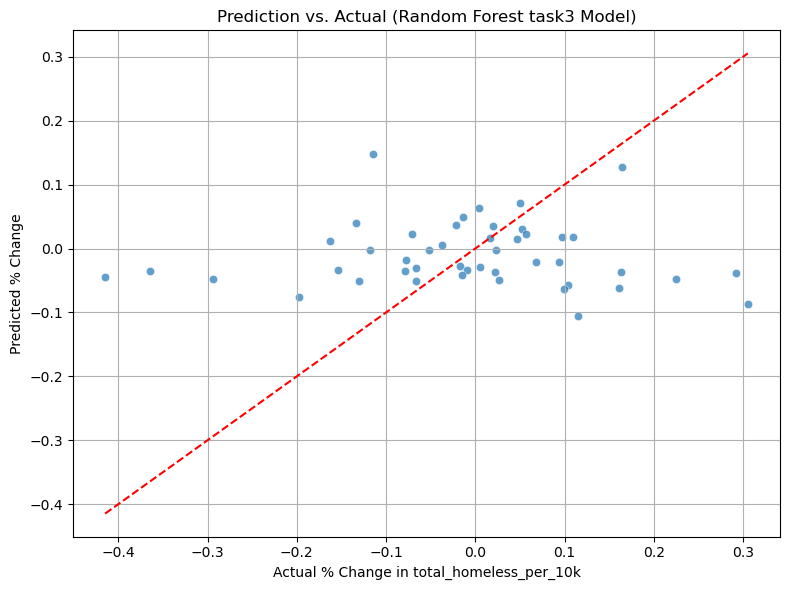

In [59]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val_task3_reg, y=y_pred_rf_reg_task3, alpha=0.7)

# Adding the 45-degree reference line
plt.plot([y_val_task3_reg.min(), y_val_task3_reg.max()], [y_val_task3_reg.min(), y_val_task3_reg.max()], color='red', linestyle='--')

# Labeling
plt.xlabel("Actual % Change in total_homeless_per_10k")
plt.ylabel("Predicted % Change")
plt.title("Prediction vs. Actual (Random Forest task3 Model)")
plt.grid(True)
plt.tight_layout()

plt.show()

Notes:
- Looks like the model is underfitting because most predictions cluster near 0.
- The model is underpredicting increases and overpredicting decreases.
- When actual homelessness increases, the model often underestimates how much.
- There is no strong linear trend between actual and predicted values

#### 3.11.7 Train OLS regression task3 model

In [ ]:
#51
# Training OLS regression
model_ols_task3_reg = LinearRegression()
model_ols_task3_reg.fit(X_train_task3_reg, y_train_task3_reg)

# Displaying the coefficients
coefficients = pd.DataFrame({"Feature": selected_features_task3, "Coefficient": model_ols_task3_reg.coef_})
print(coefficients.sort_values(by="Coefficient", ascending=False))

                                              Feature   Coefficient
6            Share_of_Single_Person_Households_1_year  1.063664e+00
5                          Estimate Total Asian alone  3.299453e-01
4                                                Year  6.483636e-03
3                                                 HPI  2.491952e-04
10                                 Blind and disabled  1.409469e-06
9   Total Civilian Noninstitutionalized Population... -3.679677e-08
8                          Median_House_Values_1_year -5.230850e-07
11                  Overall Homeless - Multiple Races -1.374372e-05
2                                  HPI with 2000 base -3.607479e-04
1                                   Unemployment Rate -4.098564e-03
0                   SSDI Participation Rate (Percent) -3.504231e-02
7            Share_of_Single_Person_Households_5_year -9.473530e-01


#### 3.11.8 Evaluating the OLS regression task3 model

In [ ]:
#52
# Predicting and evaluating the OLS growth model
y_val_pred_ols_task3_reg = model_ols_task3_reg.predict(X_val_task3_reg)

r2_ols_task3_reg = r2_score(y_val_task3_reg, y_val_pred_ols_task3_reg)
rmse_ols_task3_reg = np.sqrt(mean_squared_error(y_val_task3_reg, y_val_pred_ols_task3_reg))

print(f"OLS R² Score on Validation Set: {r2_ols_task3_reg:.4f}")
print(f"OLS RMSE on Validation Set: {rmse_ols_task3_reg:.4f}")

OLS R² Score on Validation Set: -0.1088
OLS RMSE on Validation Set: 0.1524


Notes: this model is performing as poorly as the random forest model.

<a id="section-3_12"></a>
### 3.12 Classification tests

#### 3.12.1 Splitting the data for task3 model into training, validation and testing for classification

In [ ]:
# Loading the task3 dataset file
model_task3_file_path = "./data/df_model_task3_20250407.csv"
df_model_task3 = pd.read_csv(model_task3_file_path)

# Define the features and classification target
X_task3 = df_model_task3[selected_features_task3]
y_task3 = df_model_task3["target_class"]

# Extract identifiers
df_model_task3_ids = df_model_task3[["CoC Number", "County"]]

# Reset index for all before splitting
X_task3 = X_task3.reset_index(drop=True)
y_task3 = y_task3.reset_index(drop=True)
df_model_task3_ids = df_model_task3_ids.reset_index(drop=True)

# First split into training (70%) and temp (30%)
X_train_task3, X_temp_task3, y_train_task3, y_temp_task3, ids_train_task3, ids_temp_task3 = train_test_split(
    X_task3, y_task3, df_model_task3_ids, test_size=0.3, random_state=42
)

# Then split temp into validation (15%) and test (15%)
X_val_task3, X_test_task3, y_val_task3, y_test_task3, val_ids_task3, test_ids_task3 = train_test_split(
    X_temp_task3, y_temp_task3, ids_temp_task3, test_size=0.5, random_state=42
)

# Final reset to ensure alignment
X_val_task3 = X_val_task3.reset_index(drop=True)
y_val_task3 = y_val_task3.reset_index(drop=True)
val_ids_task3 = val_ids_task3.reset_index(drop=True)

# Display dataset sizes
print(f"Training set: {X_train_task3.shape[0]} rows")
print(f"Validation set: {X_val_task3.shape[0]} rows")
print(f"Testing set: {X_test_task3.shape[0]} rows")

Training set: 212 rows
Validation set: 46 rows
Testing set: 46 rows


#### 3.12.2 Checking for NaNs in Training, Validation and Test for classification

In [15]:
# Checking for NaNs in features
print("NaNs in X_train_task3:", X_train_task3.isna().sum().sum())
print("NaNs in X_val_task3:", X_val_task3.isna().sum().sum())
print("NaNs in X_test_task3:", X_test_task3.isna().sum().sum())

# Checking for NaNs in targets
print("NaNs in y_train_task3:", y_train_task3.isna().sum())
print("NaNs in y_val_task3:", y_val_task3.isna().sum())
print("NaNs in y_test_task3:", y_test_task3.isna().sum())

NaNs in X_train_task3: 0
NaNs in X_val_task3: 0
NaNs in X_test_task3: 0
NaNs in y_train_task3: 0
NaNs in y_val_task3: 0
NaNs in y_test_task3: 0


#### 3.12.3 Initializing and fitting a Random Forest Classifier

In [16]:
# Initializing the model
model_rf_class_task3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # added to help if the classes are imbalanced
)

# Training on the training set
model_rf_class_task3.fit(X_train_task3, y_train_task3)

# Extracting feature importances from classification model
feature_importances_task3 = pd.DataFrame({
    "Feature": selected_features_task3,
    "Importance": model_rf_class_task3.feature_importances_
})

# Sorting by most important features
feature_importances_task3 = feature_importances_task3.sort_values(by="Importance", ascending=False)

# Display the result
print(feature_importances_task3)

                                              Feature  Importance
2                                  HPI with 2000 base    0.175859
8                          Median_House_Values_1_year    0.109131
3                                                 HPI    0.099540
1                                   Unemployment Rate    0.096634
10                                 Blind and disabled    0.091716
0                   SSDI Participation Rate (Percent)    0.089306
9   Total Civilian Noninstitutionalized Population...    0.077024
11                  Overall Homeless - Multiple Races    0.064968
4                                                Year    0.055501
5                          Estimate Total Asian alone    0.053325
7            Share_of_Single_Person_Households_5_year    0.046157
6            Share_of_Single_Person_Households_1_year    0.040840


#### 3.12.4 Evaluating the Random Forest Classifier model

In [41]:
# Predicting classes for validation set using Random Forest Classifier
y_pred_class_rf_task3 = model_rf_class_task3.predict(X_val_task3)

# Basic performance metrics
accuracy_rf = accuracy_score(y_val_task3, y_pred_class_rf_task3)
precision_rf = precision_score(y_val_task3, y_pred_class_rf_task3)
recall_rf = recall_score(y_val_task3, y_pred_class_rf_task3)
conf_matrix = confusion_matrix(y_val_task3, y_pred_class_rf_task3)

print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print("Confusion Matrix:")
print(conf_matrix)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3, y_pred_class_rf_task3))

Accuracy: 0.50
Precision: 0.53
Recall: 0.38
Confusion Matrix:
[[14  8]
 [15  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.64      0.55        22
           1       0.53      0.38      0.44        24

    accuracy                           0.50        46
   macro avg       0.51      0.51      0.49        46
weighted avg       0.51      0.50      0.49        46



#### 3.12.5 Plotting the Random Forest classification confusion matrix for validation set

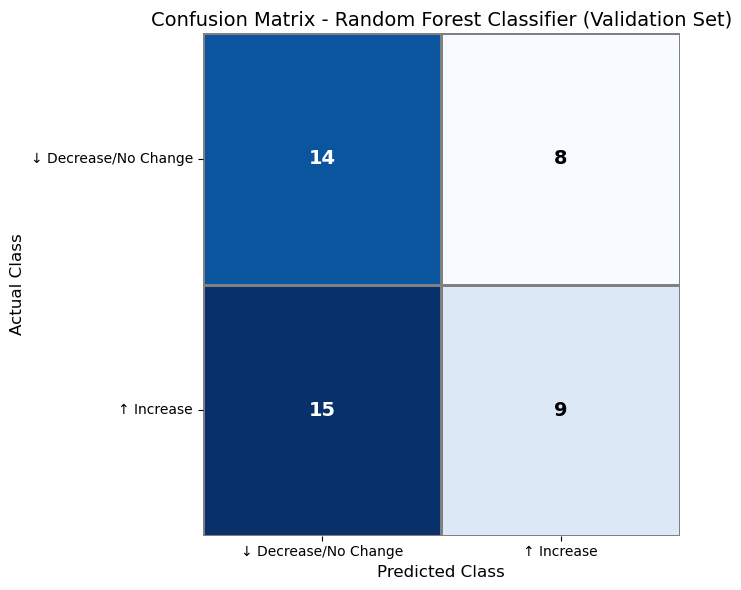

In [42]:
# Computing the confusion matrix
conf_matrix = confusion_matrix(y_val_task3, y_pred_class_rf_task3, labels=[0, 1])

# Setting up labels
labels = ["↓ Decrease/No Change", "↑ Increase"]

# Plotting the heatmap
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    conf_matrix,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    linewidths=1,
    linecolor="gray"
)

# Setting the color for the values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        value = conf_matrix[i, j]
        text_color = "white" if value > 10 else "black"
        ax.text(
            j + 0.5, i + 0.5, str(value),
            ha="center", va="center",
            color=text_color,
            fontsize=14,
            fontweight="bold"
        )

# Labels and title
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Confusion Matrix - Random Forest Classifier (Validation Set)", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Notes: 
- For actual decrease in homelessness, 14 are correctly classified and 8 misclassified.
- For actual increase in homelessness, 9 are correctly classified and 15 misclassified.
- accuracy: the model only gets 50% of the cases right. No better than flipping a coin.
- precision: of all the predicted increases in homelessness, only 53% are truly increases. Many false positives.
- recall: of all the actual increases in homelessness, only 38% are caught. Many false negatives.
- model has weak performance. Really struggles with predicting increases in homelessness.
- I think model struggles because of the small dataset.

#### 3.12.6 Initializing and fitting the XGBoost Classifier

In [19]:
# Initializing the XGBoost classifier
model_xgb_class_task3 = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  
)

# Fitting the model
model_xgb_class_task3.fit(X_train_task3, y_train_task3)

# Extracting feature importances
feature_importances_xgb_task3 = pd.DataFrame({
    "Feature": selected_features_task3,
    "Importance": model_xgb_class_task3.feature_importances_
})

# Sort by most important
feature_importances_xgb_task3 = feature_importances_xgb_task3.sort_values(by="Importance", ascending=False)

# Display the result
print("Feature Importances (XGBoost Classifier - Task 3):")
print(feature_importances_xgb_task3)

Feature Importances (XGBoost Classifier - Task 3):
                                              Feature  Importance
7            Share_of_Single_Person_Households_5_year    0.110157
6            Share_of_Single_Person_Households_1_year    0.107079
2                                  HPI with 2000 base    0.104153
8                          Median_House_Values_1_year    0.096592
11                  Overall Homeless - Multiple Races    0.093101
10                                 Blind and disabled    0.084126
3                                                 HPI    0.075938
9   Total Civilian Noninstitutionalized Population...    0.074481
4                                                Year    0.066329
1                                   Unemployment Rate    0.064409
0                   SSDI Participation Rate (Percent)    0.062418
5                          Estimate Total Asian alone    0.061217


#### 3.12.7 Evaluating the XGBoost Classifier model

In [20]:
# Predicting  classes  validation set using XGBoost Classifier
y_pred_class_xgb_task3 = model_xgb_class_task3.predict(X_val_task3)

# Basic performance metrics
accuracy_xgb = accuracy_score(y_val_task3, y_pred_class_xgb_task3)
precision_xgb = precision_score(y_val_task3, y_pred_class_xgb_task3)
recall_xgb = recall_score(y_val_task3, y_pred_class_xgb_task3)
conf_matrix_xgb = confusion_matrix(y_val_task3, y_pred_class_xgb_task3)

print(f"XGBoost Classifier - Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print("Confusion Matrix:")
print(conf_matrix_xgb)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3, y_pred_class_xgb_task3))

XGBoost Classifier - Accuracy: 0.48
Precision: 0.50
Recall: 0.29
Confusion Matrix:
[[15  7]
 [17  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.68      0.56        22
           1       0.50      0.29      0.37        24

    accuracy                           0.48        46
   macro avg       0.48      0.49      0.46        46
weighted avg       0.49      0.48      0.46        46



#### 3.12.8 Plotting the XGBoost classification confusion matrix for validation set

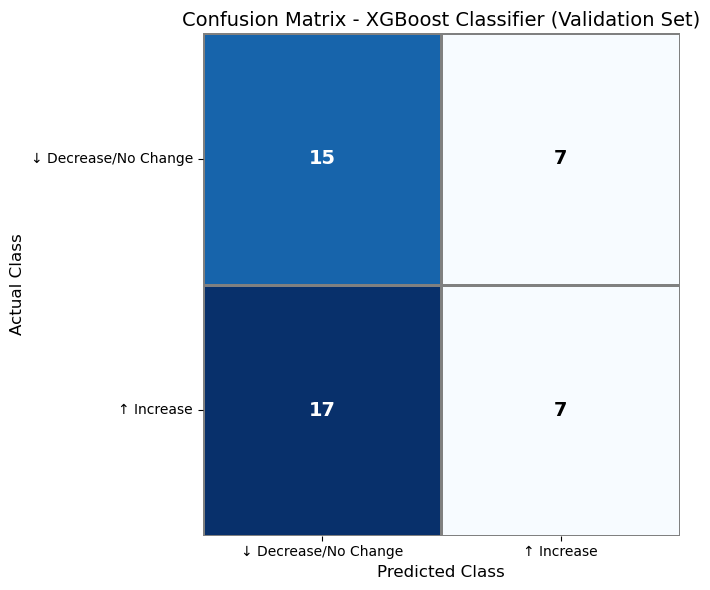

In [21]:
# Computing the confusion matrix
conf_matrix_xgb = confusion_matrix(y_val_task3, y_pred_class_xgb_task3, labels=[0, 1])

# Setting up labels
labels = ["↓ Decrease/No Change", "↑ Increase"]

# Plotting the heatmap
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    conf_matrix_xgb,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    linewidths=1,
    linecolor="gray"
)

# Setting the color for the values
for i in range(conf_matrix_xgb.shape[0]):
    for j in range(conf_matrix_xgb.shape[1]):
        value = conf_matrix_xgb[i, j]
        text_color = "white" if value > 10 else "black"
        ax.text(
            j + 0.5, i + 0.5, str(value),
            ha="center", va="center",
            color=text_color,
            fontsize=14,
            fontweight="bold"
        )

# Labels and title
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Confusion Matrix - XGBoost Classifier (Validation Set)", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Notes: 
- For actual decrease in homelessness, 15 are correctly classified and 7 misclassified.
- For actual increase in homelessness, 7 are correctly classified and 17 misclassified.
- accuracy: the model only gets 48% of the cases right. Slightly worse than random guessing.
- precision: of all the predicted increases in homelessness, only 50% are truly increases. Many false positives.
- recall: of all the actual increases in homelessness, only 29% are caught. Many false negatives.
- model also has weak performance. It misses most of the real increases in homelessness.
- I think model struggles because of the small dataset and class imbalance.

#### 3.12.9 Initializing and fitting an OLS regression Classifier

In [27]:
# Adding the constant for intercept
X_train_ols = sm.add_constant(X_train_task3)
X_val_ols = sm.add_constant(X_val_task3)

# Fitting logistic regression model
model_ols_class_task3 = sm.Logit(y_train_task3, X_train_ols).fit(disp=False)

# Printing model summary
print(model_ols_class_task3.summary())

# Predicting class probabilities and convert to class labels
y_pred_probs_ols = model_ols_class_task3.predict(X_val_ols)
y_pred_class_ols_task3 = (y_pred_probs_ols >= 0.5).astype(int)

# Feature importance
feature_importances_ols = pd.DataFrame({
    "Feature": X_train_ols.columns,
    "Coefficient": model_ols_class_task3.params,
    "Abs_Coefficient": model_ols_class_task3.params.abs()
}).sort_values(by="Abs_Coefficient", ascending=False)

print("Feature Importances (OLS-style Logistic Regression - Task 3):")
print(feature_importances_ols[["Feature", "Coefficient"]])

                           Logit Regression Results                           
Dep. Variable:           target_class   No. Observations:                  212
Model:                          Logit   Df Residuals:                      199
Method:                           MLE   Df Model:                           12
Date:                Sun, 20 Apr 2025   Pseudo R-squ.:                 0.06104
Time:                        14:06:15   Log-Likelihood:                -134.41
converged:                       True   LL-Null:                       -143.15
Covariance Type:            nonrobust   LLR p-value:                    0.1325
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                             

#### 3.12.10 Evaluating the Logistic regression model

In [28]:
# Basic performance metrics
accuracy_ols = accuracy_score(y_val_task3, y_pred_class_ols_task3)
precision_ols = precision_score(y_val_task3, y_pred_class_ols_task3)
recall_ols = recall_score(y_val_task3, y_pred_class_ols_task3)
conf_matrix_ols = confusion_matrix(y_val_task3, y_pred_class_ols_task3)

print(f"OLS Logistic Regression - Accuracy: {accuracy_ols:.2f}")
print(f"Precision: {precision_ols:.2f}")
print(f"Recall: {recall_ols:.2f}")
print("Confusion Matrix:")
print(conf_matrix_ols)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3, y_pred_class_ols_task3))

OLS Logistic Regression - Accuracy: 0.52
Precision: 0.62
Recall: 0.21
Confusion Matrix:
[[19  3]
 [19  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.86      0.63        22
           1       0.62      0.21      0.31        24

    accuracy                           0.52        46
   macro avg       0.56      0.54      0.47        46
weighted avg       0.57      0.52      0.47        46



#### 3.12.11 Plotting the confusion matrix for OLS logistic regression

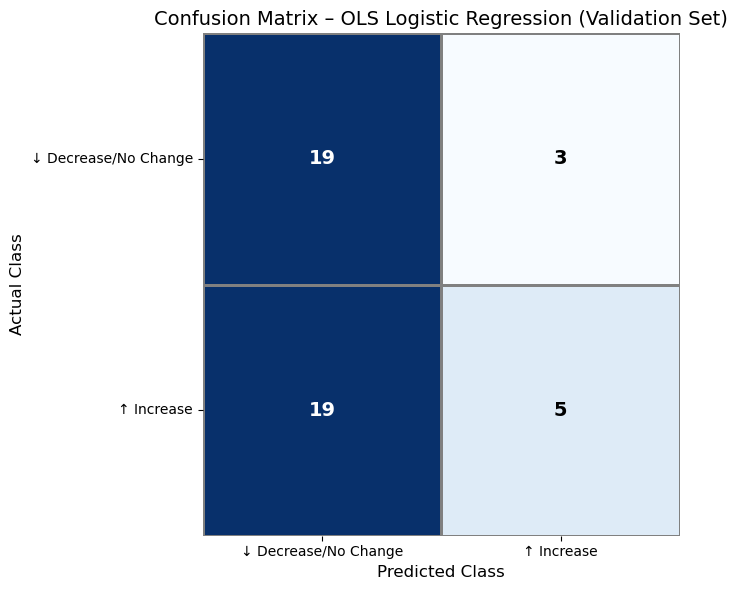

In [29]:
# Computing confusion matrix for OLS predictions
conf_matrix_ols = confusion_matrix(y_val_task3, y_pred_class_ols_task3, labels=[0, 1])

# Setting up labels
labels = ["↓ Decrease/No Change", "↑ Increase"]

# Plotting the heatmap
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    conf_matrix_ols,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    linewidths=1,
    linecolor="gray"
)

# Setting the color for the values
for i in range(conf_matrix_ols.shape[0]):
    for j in range(conf_matrix_ols.shape[1]):
        value = conf_matrix_ols[i, j]
        text_color = "white" if value > 10 else "black"
        ax.text(
            j + 0.5, i + 0.5, str(value),
            ha="center", va="center",
            color=text_color,
            fontsize=14,
            fontweight="bold"
        )

# Labels and title
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Confusion Matrix – OLS Logistic Regression (Validation Set)", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Notes: 
- For actual decrease in homelessness, 19 are correctly classified and 3 misclassified.
- For actual increase in homelessness, 5 are correctly classified and 19 misclassified.
- accuracy: the model predicts 52% of the cases right.
- precision: of all the predicted increases in homelessness, 62% actually did.
- recall: of all the actual increases in homelessness, only 21% are caught. Many false negatives.
- F1-Score: is at 31%. There is a low balance between precision and recall.
- model is good at predicting a decrease/no change in homelessness but struggles to predict increases.
- I think model struggles because of the small dataset and class imbalance. The model leans towards predicting decreases more often.

#### 3.12.12 Analyzing the misclassified counties for the task 3 classifiers

##### 3.12.12.1 Creating prediction columns and adding misclassification flags

In [30]:
# Creating the prediction columns
val_ids_task3["actual"] = y_val_task3.reset_index(drop=True)
val_ids_task3["pred_rf"] = y_pred_class_rf_task3
val_ids_task3["pred_xgb"] = y_pred_class_xgb_task3
val_ids_task3["pred_ols"] = y_pred_class_ols_task3 

# Adding flag misclassifications
val_ids_task3["misclassified_rf"] = val_ids_task3["actual"] != val_ids_task3["pred_rf"]
val_ids_task3["misclassified_xgb"] = val_ids_task3["actual"] != val_ids_task3["pred_xgb"]
val_ids_task3["misclassified_ols"] = val_ids_task3["actual"] != val_ids_task3["pred_ols"] 

##### 3.12.9.2 Looking at the misclassified counties for Random Forest

In [36]:
misclassified_rf = val_ids_task3[val_ids_task3["misclassified_rf"]]
print("Random Forest - Misclassified Counties")
display(misclassified_rf[["CoC Number", "County", "actual", "pred_rf"]])

# How many counties were misclassified
print(f"Total misclassified counties (Random Forest): {len(misclassified_rf)}")

Random Forest - Misclassified Counties


,CoC Number,County,actual,pred_rf
1,TX-500,bexar county,0,1
4,NC-502,durham county,1,0
7,MN-501,ramsey county,0,1
8,CA-601,san diego county,0,1
14,TX-600,dallas county,0,1
15,GA-503,clarke county,1,0
16,WA-502,spokane county,1,0
18,VA-600,arlington county,1,0
24,TX-600,dallas county,1,0
25,FL-600,miami-dade county,1,0


Total misclassified counties (Random Forest): 23


##### 3.12.9.3 Looking at the misclassified counties for XGBoost

In [35]:
misclassified_xgb = val_ids_task3[val_ids_task3["misclassified_xgb"]]
print("XGBoost - Misclassified Counties")
display(misclassified_xgb[["CoC Number", "County", "actual", "pred_xgb"]])

# How many counties were misclassified
print(f"Total misclassified counties (XGBoost): {len(misclassified_xgb)}")

XGBoost - Misclassified Counties


,CoC Number,County,actual,pred_xgb
0,MN-501,ramsey county,0,1
1,TX-500,bexar county,0,1
4,NC-502,durham county,1,0
7,MN-501,ramsey county,0,1
8,CA-601,san diego county,0,1
15,GA-503,clarke county,1,0
16,WA-502,spokane county,1,0
17,CA-601,san diego county,1,0
18,VA-600,arlington county,1,0
24,TX-600,dallas county,1,0


Total misclassified counties (XGBoost): 24


##### 3.12.9.4 Looking at the misclassified counties for OLS Logisitc Regression

In [34]:
misclassified_ols = val_ids_task3[val_ids_task3["misclassified_ols"]]
print("OLS Logistic Regression - Misclassified Counties")
display(misclassified_ols[["CoC Number", "County", "actual", "pred_ols"]])

# How many counties were misclassified
print(f"Total misclassified counties (OLS): {len(misclassified_ols)}")

OLS Logistic Regression - Misclassified Counties


,CoC Number,County,actual,pred_ols
0,MN-501,ramsey county,0,1
9,MN-501,ramsey county,1,0
15,GA-503,clarke county,1,0
16,WA-502,spokane county,1,0
17,CA-601,san diego county,1,0
18,VA-600,arlington county,1,0
21,CA-601,san diego county,1,0
24,TX-600,dallas county,1,0
25,FL-600,miami-dade county,1,0
26,OH-503,franklin county,1,0


Total misclassified counties (OLS): 22


##### 3.12.9.5 Counties misclassified by all models

In [37]:
# Counties misclassified by all models
misclassified_all = val_ids_task3[
    val_ids_task3["misclassified_rf"] & val_ids_task3["misclassified_xgb"] & val_ids_task3["misclassified_ols"]
]

print("Misclassified by all models:")
display(misclassified_all[["CoC Number", "County", "actual", "pred_rf", "pred_xgb", "pred_ols"]])

# How many counties were misclassified
print(f"Total misclassified counties: {len(misclassified_all)}")

Misclassified by all models:


,CoC Number,County,actual,pred_rf,pred_xgb,pred_ols
15,GA-503,clarke county,1,0,0,0
16,WA-502,spokane county,1,0,0,0
18,VA-600,arlington county,1,0,0,0
24,TX-600,dallas county,1,0,0,0
25,FL-600,miami-dade county,1,0,0,0
28,NV-500,clark county,1,0,0,0
29,NV-500,clark county,1,0,0,0
30,NV-501,washoe county,1,0,0,0
32,FL-600,miami-dade county,0,1,1,1
33,NC-500,forsyth county,1,0,0,0


Total misclassified counties: 14


##### 3.12.9.6 Classifier comparison table

In [43]:
# Counting misclassified counties
num_misclassified_rf = val_ids_task3["misclassified_rf"].sum()
num_misclassified_xgb = val_ids_task3["misclassified_xgb"].sum()
num_misclassified_ols = val_ids_task3["misclassified_ols"].sum()

# Creating comparison table
classifier_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "OLS Logistic Regression"],
    "Accuracy": [accuracy_rf, accuracy_xgb, accuracy_ols],
    "Precision": [precision_rf, precision_xgb, precision_ols],
    "Recall": [recall_rf, recall_xgb, recall_ols],
    "Misclassified Counties": [num_misclassified_rf, num_misclassified_xgb, num_misclassified_ols]
})

# Formating for readability
classifier_results = classifier_results.round(2)

# Display the table
print("Classifier Comparison Table")
display(classifier_results)

Classifier Comparison Table


,Model,Accuracy,Precision,Recall,Misclassified Counties
0,Random Forest,0.50,0.53,0.38,23
1,XGBoost,0.48,0.50,0.29,24
2,OLS Logistic Regression,0.52,0.62,0.21,22


##### 3.12.9.7 Charts looking at class distribution

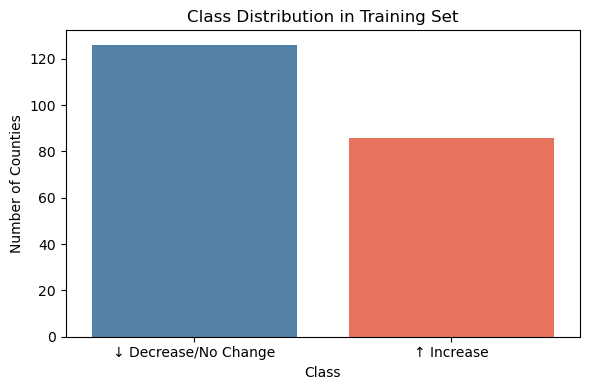

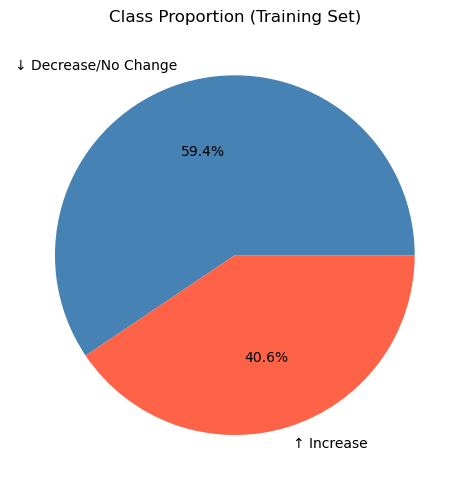

In [40]:
# Class counts and labels
class_counts = y_train_task3.value_counts().sort_index()
class_labels = ["↓ Decrease/No Change", "↑ Increase"]

# Creating a DataFrame for the class distribution
class_dist_df = pd.DataFrame({
    "Class": ["↓ Decrease/No Change", "↑ Increase"],
    "Count": y_train_task3.value_counts().sort_index().values
})

# My color palette
custom_palette = {
    "↓ Decrease/No Change": "steelblue",
    "↑ Increase": "tomato"
}

# Plot using custom colors
plt.figure(figsize=(6, 4))
sns.barplot(
    data=class_dist_df,
    x="Class",
    y="Count",
    hue="Class",
    palette=custom_palette,
    legend=False
)

plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Counties")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

# Pie Chart
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=class_labels, autopct="%1.1f%%", colors=["steelblue", "tomato"])
plt.title("Class Proportion (Training Set)")
plt.tight_layout()
plt.show()

<a id="section-4"></a>
## Section 4 - Lagged Feature Engineering

<a id="section-4_1"></a>
### 4.1 Filtered dataset for Major City and Largely Urban CoCs

#### 4.1.1 Loading the full dataset for filtered dataset

In [2]:
current_date = datetime.datetime.now().strftime("%m_%d_%Y")

# Loading the full dataset
file_path = "./data/homeless_dataset_full.csv"
df_homeless_full = pd.read_csv(file_path, encoding="utf-8")

# Displaying a sample to verify
df_homeless_full.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
846,OK-501,tulsa county,2013,1008,886,122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['OK-501'],['Tulsa City & County CoC'],Major City CoC,oklahoma,136100.0,0.422550,608.0,836.0,0.41,81.0,274279.0,0.006336,0.0,228.0,134100,0.441534,599,857.0,0.39,8.9,270608,0.005254,0.0,258.0,0500000US40143,40143.0,1.04,354.67,176.12,123.44,CN4014300000000,40.0,143.0,310617.0,295245.0,15372.0,4.9,622409.0,0.119662,0.71,0.10,0.04,0.03,0.00,0.03,0.09,NaN,NaN,0.071051,0.039853,0.024447,0.014029,0.012577,0.043581,0.073066,0.072380,0.064748,0.064051,0.061882,0.069980,0.067183,0.065136,0.023231,0.031683,0.021492,0.022265,0.027382,0.022564,0.016083,0.017472,0.073863,0.51

#### 4.1.2 Creating Filtered dataset for Major City and Largely Urban CoCs task3 model

In [3]:
# Filtering for Major City and Largely Urban CoC Categories
df_filtered_task3 = df_homeless_full[df_homeless_full["CoC Category"].isin(["Major City CoC", "Other Largely Urban CoC"])].copy()

# Displaying 5 random rows
df_filtered_task3.sample(5, random_state=45)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
324,GA-504,richmond county,2016,287,266,21,56,15,216,118,169,5,80,0,0,0,0,9,191,5,2,['GA-504'],['Augusta-Richmond County CoC'],Other Largely Urban CoC,georgia,101600.0,0.453284,646.0,800.0,0.47,78.0,88171.0,0.005599,0.00,154.0,100600,0.497440,613,804.0,0.47,89.0,87290,0.006113,0.00,191.0,0500000US13245,13245.0,0.58,332.00,155.22,119.75,CN1324500000000,13.0,245.0,84842.0,79035.0,5807.0,6.8,201647.0,0.116263,0.38,0.57,0.00,0.02,0.00,0.01,0.01,NaN,NaN,0.056177,0.036673,0.031570,0.018726,0.017278,0.047395,0.092295,0.073019,0.056634,0.057368,0.052076,0.071174,0.062322,0.060313,0.028014,0.037219,0.022277,0.023536,0.034957,0.021553,0.017754,

#### 4.1.3 Sorting by CoC and year

In [4]:
# Sorting by CoC Number and Year in preparation for percent change calculation
df_filtered_task3.sort_values(by=["CoC Number", "Year"], inplace=True)

# Displaying 5 rows
df_filtered_task3.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-501'],['Mobile City & County/Baldwin County CoC'],Other Largely Urban CoC,alabama,131800.0,0.494913,506.0,785.0,0.33,123.0,178726.0,0.008180,0.0,279.0,120700,0.472663,513,NaN,0.32,97.0,175753,0.005029,0.0,NaN,0500000US01097,1097.0,-7.22,389.86,194.62,132.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413277.0,0.111552,0.61,0.35,0.01,0.02,0.0,0.00,0.01,NaN,NaN,0.073454,0.044416,0.028521,0.012885,0.019733,0.038183,0.067594,0.062682,0.062425,0.062152,0.072535,0.062849,0.073041,0.066703,0.023367,0.030941,0.015145,0.025039,0.033171,0.024577,0.017226,0.014293,0.069070,0.52,NaN,39998

#### 4.1.4 Calculating the percentage change in total_homeless_per_10k

In [5]:
# Calculating the percentage change in total_homeless_per_10k
df_filtered_task3["pct_change_total_homeless_per_10k"] = (df_filtered_task3.groupby("CoC Number")["total_homeless_per_10k"].pct_change())

# Displaying 5 rows
df_filtered_task3.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-501'],['Mobile City & County/Baldwin County CoC'],Other Largely Urban CoC,alabama,131800.0,0.494913,506.0,785.0,0.33,123.0,178726.0,0.008180,0.0,279.0,120700,0.472663,513,NaN,0.32,97.0,175753,0.005029,0.0,NaN,0500000US01097,1097.0,-7.22,389.86,194.62,132.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413277.0,0.111552,0.61,0.35,0.01,0.02,0.0,0.00,0.01,NaN,NaN,0.073454,0.044416,0.028521,0.012885,0.019733,0.038183,0.067594,0.062682,0.062425,0.062152,0.072535,0.062849,0.073041,0.066703,0.023367,0.030941,0.015145,0.025039,0.033171,0.024577,0.01722

#### 4.1.5 Choosing the columns to lag

In [8]:
# Homelessness related
homeless_lag = [
    "total_homeless_per_10k",
    "total_sheltered_homeless_per_10k",
    "unsheltered_homeless_per_10k"
]

# Housing market related
housing_lag = [
    "Median_House_Values_5_year",
    "Median_Rent_5_year",
    "Median_Gross_Rent_5_year",
    "Percentage_of_Households_with_Cost_Burden_5_year",
    "Rental_Vacancy_Rates_5_year",
    "Share_of_Single_Person_Households_5_year",
    "Share_of_Renter_Occupied_Units_5_year"
]

# Economic related
economic_lag = [
    "Unemployment Rate",
    "Median Household Income",
    "Poverty Rate",
    "Labor Force"
]

# The full list
columns_to_lag = (
    homeless_lag +
    housing_lag +
    economic_lag
)

#### 4.1.6 Creating and inspecting the Lagged features

In [7]:
# Generating lagged features
for col in columns_to_lag:
    df_filtered_task3[f"{col}_lag1"] = df_filtered_task3.groupby("CoC Number")[col].shift(1)

# Inspecting a few of the lagged features
lagged_cols = [f"{col}_lag1" for col in columns_to_lag]
df_filtered_task3[["CoC Number", "Year"] + lagged_cols].sample(10, random_state=42)

,CoC Number,Year,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1
810,OH-503,2013,12.274564,10.261800,2.012765,153600.0,647.0,974.0,0.463468,9.5,0.00,0.44,6.4,50074.0,17.9,630411.0
215,FL-502,2018,26.782052,16.887458,9.894594,167100.0,851.0,970.0,0.501958,75.0,0.37,0.35,3.9,51512.0,12.0,480350.0
212,FL-502,2015,35.659125,23.320036,12.339089,146500.0,795.0,964.0,0.523034,88.0,0.00,0.35,5.9,45152.0,15.1,470895.0
42,CA-502,2016,25.156217,10.608702,14.547516,543100.0,1272.0,1614.0,0.500036,32.0,0.00,0.47,4.8,81717.0,11.4,819008.0
309,GA-503,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1021,TX-500,2015,15.233805,9.131852,6.101953,126100.0,714.0,928.0,0.456428,7.6,0.00,0.41,4.7,50760.0,18.4,865150.0
566,NC-502,2012,24.960574,22.707686,2.252889,178400.0,686.0,985.0,0.484350,9.2,0.00,0.45,NaN,46231.0,20.4,NaN
554,NC-500,2018,11.606467,10.735982,0.870485,151400.0,622.0,842.0,0.472677,10.2,0.32,0.38,4.4,50185.0,16.7,182173.0
1156,WI-503,2016,11.839487,10.521897,1.317590,230800.0,826.0,1141.0,0.477300,2.3,0.00,0.42,3.1,65202.0,11.4,310088.0
25,AZ-502,2017,13.013599,8.233046,4.780553,204900.0,830.0,1053.0,0.459883,78.0,0.00,0.40,4.7,58737.0,15.0,2088551.0


#### 4.1.7 Dropping NaN values introduced by lagging

In [8]:
# Dropping NaN values
df_filtered_task3 = df_filtered_task3.dropna(subset=lagged_cols + ["pct_change_total_homeless_per_10k"]).reset_index(drop=True)

# Reporting any remaining missing values
total_missing = df_filtered_task3.isna().sum().sum()
print(f"Total remaining NaN values: {total_missing}")

# Taking a look at the dataframe
df_filtered_task3.sample(5, random_state=45)

Total remaining NaN values: 1364


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1
170,OR-501,multnomah county,2015,3801,1914,1887,378,315,3108,1351,2430,425,2664,0,0,0,56,256,573,38,214,['OR-501'],"['Portland, Gresham/Multnomah County CoC']"

#### 4.1.8 Checking for remaining missing values after dropping NaN introduced by lagging

In [9]:
# Checking for remaining missing values
missing_counts = df_filtered_task3.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

if not missing_counts.empty:
    print("Remaining missing values found:")
    print(missing_counts)
else:
    print("No remaining missing values in df_filtered_task3")

Remaining missing values found:
Share_of_Overcrowded_Housing_Units_1_year                                               1
Estimate Total Some Other Race alone                                                  228
Estimate Total Two or More Races                                                      228
Share of Families Receiving Cash Assistance                                            16
HUD_Assisted_Total_Units                                                               25
Total Housing Units                                                                    25
Share of HUD-Assisted Units                                                            25
HUD_Subsidized_Total_Units                                                             38
pct_occupied                                                                           38
number_reported                                                                        38
pct_reported                                                        

#### 4.1.9 Confirming that the columns with missing values are numeric columns

In [10]:
# Columns that have missing values
cols_with_missing = [
    "Share_of_Overcrowded_Housing_Units_1_year",
    "Estimate Total Some Other Race alone",
    "Estimate Total Two or More Races",
    "Share of Families Receiving Cash Assistance",
    "HUD_Assisted_Total_Units",
    "Total Housing Units",
    "Share of HUD-Assisted Units",
    "HUD_Subsidized_Total_Units",
    "pct_occupied",
    "number_reported",
    "pct_reported",
    "Disabled workers",
    "Total",
    "Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over",
    "With a Disability Estimate Population Age 16 and Over",
    "Aged",
    "Blind and disabled",
    "SSI Participation Rate (Percent)",
    "SSDI Participation Rate (Percent)"
]

# Filtering only numeric columns
numeric_missing_cols = [col for col in cols_with_missing if pd.api.types.is_numeric_dtype(df_filtered_task3[col])]

# Printing result
if len(numeric_missing_cols) == len(cols_with_missing):
    print("All selected columns are numeric.")
else:
    non_numeric = set(cols_with_missing) - set(numeric_missing_cols)
    print("The following columns are NOT numeric:")
    for col in non_numeric:
        print(f" - {col}")

All selected columns are numeric.


#### 4.1.10 Filling missing values with the median for numeric columns

In [11]:
# Filling missing values with the median for numeric columns only
df_filtered_task3[numeric_missing_cols] = df_filtered_task3[numeric_missing_cols].fillna(
    df_filtered_task3[numeric_missing_cols].median()
)

#### 4.1.11 Checking that there are no missing values

In [12]:
# Sanity check
print("Remaining missing values after imputation:")
print(df_filtered_task3[numeric_missing_cols].isna().sum().sum())

Remaining missing values after imputation:
456


In [13]:
# Check all columns again
remaining_missing = df_filtered_task3.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing.sort_values(ascending=False))

Estimate Total Some Other Race alone    228
Estimate Total Two or More Races        228
dtype: int64


#### 4.1.11 Dropping "Estimate Total Some Other Race alone" and "Estimate Total Two or More Races" columns which are not highly correlated with target

In [14]:
# Dropping the two columns
df_filtered_task3.drop(columns=[
    "Estimate Total Some Other Race alone",
    "Estimate Total Two or More Races"
], inplace=True)

In [15]:
# Sanity check
# Check for any remaining missing values
total_missing = df_filtered_task3.isna().sum().sum()

if total_missing == 0:
    print("No missing values remain in df_filtered_task3.")
else:
    print(f"Still {total_missing} missing values detected. Investigating further:")
    remaining = df_filtered_task3.isna().sum()
    print(remaining[remaining > 0].sort_values(ascending=False))

No missing values remain in df_filtered_task3.


#### 4.1.12 Saving the filtered lagged dataframe to CSV file

In [29]:
# Defining the output directory
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)

# Get current date
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Defining output file path
df_lagged_task3_file_path = os.path.join(output_dir, f"df_task3_with_lagged_features_{current_date}.csv")

# Saving the cleaned + lagged DataFrame
df_filtered_task3.to_csv(df_lagged_task3_file_path, index=False, encoding="utf-8")

# Print confirmation
print(f"Lagged Task 3 DataFrame saved to: {df_lagged_task3_file_path}")

Lagged Task 3 DataFrame saved to: ./data/df_task3_with_lagged_features_20250421.csv


<a id="section-4_2"></a>
### 4.2 One-hot encoded CoC version of dataset

#### 4.2.1 Loading the full dataset for one-hot encoding

In [27]:
# Loading the full dataset
file_path = "./data/homeless_dataset_full.csv"
df_homeless_full = pd.read_csv(file_path, encoding="utf-8")

# Sorting the full dataset
df_full_task3 = df_homeless_full.copy()
df_full_task3.sort_values(by=["CoC Number", "Year"], inplace=True)

# Displaying 5 random rows
#df_full_task3.sample(5, random_state=45)

# Getting one random sample per year
df_one_per_year = df_full_task3.groupby("Year", group_keys=False).sample(n=1, random_state=45)

# Displaying the result
display(df_one_per_year)

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k
372,IL-506,will county,2010,389,358,31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['IL-506'],"['Joliet, Bolingbrook/Will County CoC']",Largely Suburban CoC,illinois,227200.0,0.491650,812.0,1524.0,0.18,58.0,237576.0,0.004150,0.00,712.0,240500,0.480673,746,NaN,0.15,72.0,233921,0.002326,0.00,NaN,0500000US17197,17197.0,-7.56,352.74,163.37,118.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,678697.0,0.066673,0.77,0.11,0.00,0.05,0.00,0.05,0.03,NaN,NaN,0.082467,0.050413,0.027137,0.012365,0.011236,0.029481,0.057017,0.065333,0.076479,0.082983,0.081350,0.084982,0.070270,0.056877,0.019135,0.026452,0.013168,0.019313,0.022284,0.015715,0.011070,0.011711,0.072763,0.50,NaN,71016.

#### 4.2.2 Calculating percent change in total_homeless_per_10k

In [28]:
# Calculating % change in total_homeless_per_10k
df_full_task3["pct_change_total_homeless_per_10k"] = (
    df_full_task3.groupby("CoC Number")["total_homeless_per_10k"].pct_change()
)

# Displaying 5 rows
df_full_task3.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-501'],['Mobile City & County/Baldwin County CoC'],Other Largely Urban CoC,alabama,131800.0,0.494913,506.0,785.0,0.33,123.0,178726.0,0.008180,0.0,279.0,120700,0.472663,513,NaN,0.32,97.0,175753,0.005029,0.0,NaN,0500000US01097,1097.0,-7.22,389.86,194.62,132.81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413277.0,0.111552,0.61,0.35,0.01,0.02,0.0,0.00,0.01,NaN,NaN,0.073454,0.044416,0.028521,0.012885,0.019733,0.038183,0.067594,0.062682,0.062425,0.062152,0.072535,0.062849,0.073041,0.066703,0.023367,0.030941,0.015145,0.025039,0.033171,0.024577,0.01722

#### 4.2.3 Generating and inspecting lagged features

In [29]:
# Homelessness related
homeless_lag = [
    "total_homeless_per_10k",
    "total_sheltered_homeless_per_10k",
    "unsheltered_homeless_per_10k"
]

# Housing market related
housing_lag = [
    "Median_House_Values_5_year",
    "Median_Rent_5_year",
    "Median_Gross_Rent_5_year",
    "Percentage_of_Households_with_Cost_Burden_5_year",
    "Rental_Vacancy_Rates_5_year",
    "Share_of_Single_Person_Households_5_year",
    "Share_of_Renter_Occupied_Units_5_year"
]

# Economic related
economic_lag = [
    "Unemployment Rate",
    "Median Household Income",
    "Poverty Rate",
    "Labor Force"
]

# The full list
columns_to_lag = (
    homeless_lag +
    housing_lag +
    economic_lag
)

# Generating lagged features
for col in columns_to_lag:
    df_full_task3[f"{col}_lag1"] = df_full_task3.groupby("CoC Number")[col].shift(1)

# Inspecting a few of the lagged features
lagged_cols = [f"{col}_lag1" for col in columns_to_lag]
df_full_task3[["CoC Number", "Year"] + lagged_cols].sample(10, random_state=42)

,CoC Number,Year,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1
1048,UT-500,2015,19.651156,18.838378,0.812778,231200.0,805.0,1126.0,0.473009,5.3,0.00,0.33,3.5,62672.0,11.7,570837.0
265,FL-601,2014,14.797497,10.095039,4.702458,181500.0,1029.0,1281.0,0.584812,96.0,0.00,0.34,7.1,50446.0,15.1,971733.0
109,CA-514,2011,54.459415,13.925066,40.534349,257000.0,700.0,NaN,0.522717,54.0,0.00,0.45,NaN,45221.0,26.8,NaN
298,GA-500,2014,4.787623,3.753818,1.033805,238200.0,802.0,1179.0,0.482967,119.0,0.00,0.46,8.0,55914.0,17.6,507565.0
753,NY-601,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,CA-608,2018,9.450137,2.574714,6.875424,304500.0,1104.0,1387.0,0.563567,56.0,0.21,0.35,5.3,63944.0,12.9,1070876.0
714,NJ-514,2016,12.532916,11.347005,1.185910,276500.0,976.0,1473.0,0.500763,7.3,0.00,0.36,4.9,72417.0,11.2,197825.0
549,NC-500,2013,10.907480,10.547589,0.359891,151700.0,566.0,837.0,0.486556,14.1,0.00,0.35,9.1,42489.0,21.5,177910.0
945,PA-511,2013,7.193258,6.539325,0.653933,315600.0,957.0,1471.0,0.492236,8.8,0.00,0.22,7.0,75471.0,5.4,338069.0
597,NC-513,2016,5.641908,4.584050,1.057858,272600.0,796.0,1083.0,0.464305,5.8,0.01,0.40,4.6,61164.0,14.7,73308.0


#### 4.2.4 One-hot encode CoC category

In [30]:
# One-hot encode CoC Category
df_task3_onehot = pd.get_dummies(
    df_full_task3,
    columns=["CoC Category"],
    prefix="CoC_Category",
    dtype=int
)

# Displaying 5 rows
df_task3_onehot.head()

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Largely Suburban CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC
0,AL-501,mobile county,2010,883,482,401,0,

#### 4.2.5 Drop one CoC dummy

In [31]:
# Dropping one CoC dummy to avoid multicollinearity
drop_col = "CoC_Category_Largely Suburban CoC"
if drop_col in df_task3_onehot.columns:
    df_task3_onehot = df_task3_onehot.drop(columns=[drop_col])
    print(f"Dropped dummy column: {drop_col}")
else:
    print(f"Column {drop_col} not found — already dropped or renamed.")

# Displaying the remaining CoC category columns
coc_dummy_cols = [col for col in df_task3_onehot.columns if col.startswith("CoC_Category_")]
print("\nRemaining CoC category dummy columns:")
print(coc_dummy_cols)    

Dropped dummy column: CoC_Category_Largely Suburban CoC

Remaining CoC category dummy columns:
['CoC_Category_Largely Rural CoC', 'CoC_Category_Major City CoC', 'CoC_Category_Other Largely Urban CoC']


#### 4.2.5 Dropping NaN values introduced by lagging

In [32]:
# Making a backup BEFORE dropping rows
df_task3_onehot_backup = df_task3_onehot.copy()

# Defining the critical columns used to drop rows
critical_cols = lagged_cols + ["pct_change_total_homeless_per_10k"]

# Identifying which rows would be dropped based on full set
missing_mask = df_task3_onehot_backup[critical_cols].isna().any(axis=1)
dropped_rows = df_task3_onehot_backup[missing_mask]

# Reporting how many rows are dropped per year
print("Number of dropped rows per year:")
print(dropped_rows["Year"].value_counts().sort_index())

# Showing which columns are missing for 2010 and 2011
print("\nMissing columns summary for dropped rows in 2010 and 2011:")
print(dropped_rows[dropped_rows["Year"].isin([2010, 2011])][critical_cols].isna().sum())

# Showing sample dropped rows for those years
print("\nSample dropped rows from 2010 and 2011:")
display(dropped_rows[dropped_rows["Year"].isin([2010, 2011])].head())

# Dropping rows after diagnostics
excluded_lags = [
    "Unemployment Rate_lag1",
    "Labor Force_lag1",
    "Median_Gross_Rent_5_year_lag1"
]

drop_cols = [col for col in lagged_cols if col not in excluded_lags]
drop_cols += ["pct_change_total_homeless_per_10k"]

df_task3_onehot = df_task3_onehot_backup.dropna(subset=drop_cols).reset_index(drop=True)

# Reporting the remaining NaNs
total_missing_onehot = df_task3_onehot.isna().sum().sum()
print(f"\nTotal remaining NaN values in one-hot dataset: {total_missing_onehot}")

# One random row per year from cleaned data
df_one_sample_per_year = df_task3_onehot.groupby("Year", group_keys=False).sample(n=1, random_state=45)
display(df_one_sample_per_year)

Number of dropped rows per year:
Year
2010    123
2011    124
2012    122
2013      1
2016      1
Name: count, dtype: int64

Missing columns summary for dropped rows in 2010 and 2011:
total_homeless_per_10k_lag1                              122
total_sheltered_homeless_per_10k_lag1                    122
unsheltered_homeless_per_10k_lag1                        122
Median_House_Values_5_year_lag1                          122
Median_Rent_5_year_lag1                                  122
Median_Gross_Rent_5_year_lag1                            245
Percentage_of_Households_with_Cost_Burden_5_year_lag1    122
Rental_Vacancy_Rates_5_year_lag1                         122
Share_of_Single_Person_Households_5_year_lag1            122
Share_of_Renter_Occupied_Units_5_year_lag1               122
Unemployment Rate_lag1                                   247
Median Household Income_lag1                             122
Poverty Rate_lag1                                        122
Labor Force_lag1       

,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC
0,AL-501,mobile county,2010,883,482,401,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['AL-5


Total remaining NaN values in one-hot dataset: 10246


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC
560,NJ-503,gloucester county,2010,1572,1221,351,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [33]:
# Compare counties in 2010 and 2011 to understand missing lag sources
counties_2010 = set(df_task3_onehot_backup[df_task3_onehot_backup["Year"] == 2010]["County"])
counties_2011 = set(df_task3_onehot_backup[df_task3_onehot_backup["Year"] == 2011]["County"])

# Counties in 2011 that are missing in 2010 (and therefore can't be lagged)
counties_missing_in_2010 = counties_2011 - counties_2010
print(f"Counties in 2011 with no 2010 data: {len(counties_missing_in_2010)}")

Counties in 2011 with no 2010 data: 1


In [34]:
# Show a breakdown of lagged NaNs in 2011 rows that have valid 2010 counterparts
diagnostic_cols = lagged_cols + ["pct_change_total_homeless_per_10k"]
dropped_2011 = dropped_rows[dropped_rows["Year"] == 2011]

# Show percent of missing values per column for 2011 dropped rows
print("Percent missing per column in dropped 2011 rows:")
print(dropped_2011[diagnostic_cols].isna().mean().sort_values(ascending=False))

# Check how many 2011 rows remain after relaxed filtering
print(f"2011 rows remaining after updated drop: {(df_task3_onehot['Year'] == 2011).sum()}")

Percent missing per column in dropped 2011 rows:
Unemployment Rate_lag1                                   1.000000
Labor Force_lag1                                         1.000000
Median_Gross_Rent_5_year_lag1                            0.983871
total_homeless_per_10k_lag1                              0.008065
total_sheltered_homeless_per_10k_lag1                    0.008065
unsheltered_homeless_per_10k_lag1                        0.008065
Median_House_Values_5_year_lag1                          0.008065
Median_Rent_5_year_lag1                                  0.008065
Percentage_of_Households_with_Cost_Burden_5_year_lag1    0.008065
Rental_Vacancy_Rates_5_year_lag1                         0.008065
Share_of_Single_Person_Households_5_year_lag1            0.008065
Share_of_Renter_Occupied_Units_5_year_lag1               0.008065
Median Household Income_lag1                             0.008065
Poverty Rate_lag1                                        0.008065
pct_change_total_homeless_p

#### 4.2.6 Checking for remaining missing values after dropping NaN introduced by lagging

In [35]:
# Checking for remaining missing values
missing_counts = df_task3_onehot.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

if not missing_counts.empty:
    print("Remaining missing values found:")
    print(missing_counts)
else:
    print("No remaining missing values in df_filtered_task3")

Remaining missing values found:
Median_House_Values_1_year                            1
Percentage_of_Households_with_Cost_Burden_1_year      3
Median_Rent_1_year                                    1
Median_Gross_Rent_1_year                              1
Share_of_Renter_Occupied_Units_1_year                 1
                                                   ... 
SSI Participation Rate (Percent)                    578
SSDI Participation Rate (Percent)                   578
Median_Gross_Rent_5_year_lag1                       123
Unemployment Rate_lag1                              247
Labor Force_lag1                                    247
Length: 83, dtype: int64


#### 4.2.7 Identifying columns with missing values

In [37]:
# Identifying columns with missing values
missing_cols = df_task3_onehot.columns[df_task3_onehot.isnull().any()].tolist()

# Separating numeric vs. non-numeric
numeric_missing = [col for col in missing_cols if pd.api.types.is_numeric_dtype(df_task3_onehot[col])]
non_numeric_missing = [col for col in missing_cols if not pd.api.types.is_numeric_dtype(df_task3_onehot[col])]

# Displaying results
print(f"Total columns with missing values: {len(missing_cols)}")
print(f"Numeric columns with missing values ({len(numeric_missing)}):\n{numeric_missing}")
print(f"Non-numeric columns with missing values ({len(non_numeric_missing)}):\n{non_numeric_missing}")

Total columns with missing values: 83
Numeric columns with missing values (82):
['Median_House_Values_1_year', 'Percentage_of_Households_with_Cost_Burden_1_year', 'Median_Rent_1_year', 'Median_Gross_Rent_1_year', 'Share_of_Renter_Occupied_Units_1_year', 'Rental_Vacancy_Rates_1_year', 'Total_Housing_Units_1_year', 'Share_of_Overcrowded_Housing_Units_1_year', 'Share_of_Single_Person_Households_1_year', 'Median_Rental_Utility_Cost_1_year', 'Median_Gross_Rent_5_year', 'Median_Rental_Utility_Cost_5_year', 'FIPS code', 'Annual Change (%)', 'HPI', 'HPI with 1990 base', 'HPI with 2000 base', 'State FIPS', 'County FIPS', 'Labor Force', 'Employed', 'Unemployed', 'Unemployment Rate', 'Total Population', 'Share of Single-Adult Households', 'Estimate Total White alone', 'Estimate Total Black or African American alone', 'Estimate Total American Indian and Alaska Native alone', 'Estimate Total Asian alone', 'Estimate Total Native Hawaiian and Other Pacific Islander alone', 'Estimate Total Some other 

#### 4.2.8 Making sure columns are numeric

In [38]:
# Converting ambiguous columns to numeric
for col in df_task3_onehot.columns:
    if df_task3_onehot[col].dtype == 'object':
        try:
            df_task3_onehot[col] = pd.to_numeric(df_task3_onehot[col])
        except:
            pass

#### 4.2.9 Deciding what to do with missing values

In [39]:
# Filling missing values
df_task3_onehot_imputed = impute_missing_with_median(
    df_task3_onehot,
    low_thresh=0.2,
    high_thresh=0.5,
    add_indicator=True,         
    drop_high_missing=False     
)

Median-imputed 63 numeric column(s) with ≤ 20% missing values
Median-imputed 9 numeric column(s) with 20%–50% missing values
median-imputed with flag 10 high-missing numeric column(s) with > 50% missing values


#### 4.2.10 Checking if indicator columns were added

In [40]:
# Checking if indicator columns were added
[col for col in df_task3_onehot_imputed.columns if col.endswith("_missing")]

['Estimate Total Some Other Race alone_missing',
 'Estimate Total Two or More Races_missing',
 'Disabled workers_missing',
 'Total_missing',
 'Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over_missing',
 'With a Disability Estimate Population Age 16 and Over_missing',
 'Aged_missing',
 'Blind and disabled_missing',
 'SSI Participation Rate (Percent)_missing',
 'SSDI Participation Rate (Percent)_missing']

#### 4.2.10 Sanity Check for missing values

In [41]:
# Sanity check for missing values
check_missing_values(df_task3_onehot_imputed, name="Task 3 One-Hot (Imputed)")


Checking for missing values in: Task 3 One-Hot (Imputed)


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Estimate Total Some Other Race alone_missing,Estimate Total Two or More Race

Still 2195 missing values detected. Investigating further:
Estimate Total Some Other Race alone    1035
Estimate Total Two or More Races        1035
LAUS Code                                125
dtype: int64


#### 4.2.11 Final clean up after imputation

In [42]:
df_task3_onehot_imputed = final_cleanup_median_impute(df_task3_onehot_imputed)
check_missing_values(df_task3_onehot_imputed, name="After Final Cleanup")

Final cleanup: 2 numeric column(s) with missing values found.
Imputing these columns with median values:
['Estimate Total Some Other Race alone', 'Estimate Total Two or More Races']

Checking for missing values in: After Final Cleanup


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total Some Other Race alone,Estimate Total Two or More Races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Estimate Total Some Other Race alone_missing,Estimate Total Two or More Race

Still 2195 missing values detected. Investigating further:
Estimate Total Some Other Race alone    1035
Estimate Total Two or More Races        1035
LAUS Code                                125
dtype: int64


#### 4.2.12 Dropping the two columns

In [43]:
cols_to_drop = [
    "Estimate Total Some Other Race alone",
    "Estimate Total Two or More Races",
    "LAUS Code"
]

df_task3_onehot_imputed = df_task3_onehot_imputed.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['Estimate Total Some Other Race alone', 'Estimate Total Two or More Races', 'LAUS Code']


#### 4.2.13 Final check

In [44]:
check_missing_values(df_task3_onehot_imputed, name="After Dropping Final Columns")


Checking for missing values in: After Dropping Final Columns


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Estimate Total Some Other Race alone_missing,Estimate Total Two or More Races_missing,Disabled workers_missing,Total_missing,Total Civilian Noninstitutional

No missing values remain.


#### 4.2.14 Non numeric columns (OK to keep)

In [45]:
non_numeric = df_task3_onehot_imputed.select_dtypes(exclude=['number'])
print(f"Columns not numeric (likely missed in imputation):")
print(non_numeric.columns.tolist())

Columns not numeric (likely missed in imputation):
['CoC Number', 'County', 'CoC Number Original', 'CoC Name', 'State', 'Geography']


#### 4.2.15 Computing full correlations with pct_change_total_homeless_per_10k

In [46]:
# Computing full correlations with the Task 3 target
target_task3 = "pct_change_total_homeless_per_10k"

# Selecting numeric columns only
numeric_cols = df_task3_onehot_imputed.select_dtypes(include=["number"]).columns.tolist()

# Computing correlation matrix and extracting correlation with the target
correlations_task3_onehot_imputed = df_task3_onehot_imputed[numeric_cols].corr()[[target_task3]].drop(index=target_task3)

# Adding absolute correlation for sorting
correlations_task3_onehot_imputed["abs_corr"] = correlations_task3_onehot_imputed[target_task3].abs()

# Sorting descending by absolute correlation
correlations_task3_onehot_imputed = correlations_task3_onehot_imputed.sort_values("abs_corr", ascending=False).drop(columns="abs_corr")

# Previewing top correlations
print("Top correlations with pct_change_total_homeless_per_10k for onehot + lagged + imputed:")
display(correlations_task3_onehot_imputed.head(15))

Top correlations with pct_change_total_homeless_per_10k for onehot + lagged + imputed:


,pct_change_total_homeless_per_10k
total_homeless_per_10k,0.541019
unsheltered_homeless_per_10k,0.468164
total_sheltered_homeless_per_10k,0.456257
CoC_Category_Largely Rural CoC,0.363883
Percentage_of_Households_with_Cost_Burden_5_year,-0.148561
Rental_Vacancy_Rates_1_year,-0.134736
Share_of_Single_Person_Households_5_year_lag1,0.104535
total_sheltered_homeless_per_10k_lag1,-0.097360
Share_of_Single_Person_Households_1_year,0.089280
Share_of_Single_Person_Households_5_year,0.086070


#### 4.2.16 Saving correlations with pct_change_total_homeless_per_10k to CSV

In [47]:
# Getting today's date for versioning
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Ensuring output directory exists
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)

# Defining the file path
correlation_csv_path_task3_onehot_imputed = os.path.join(
    output_dir,
    f"pct_change_total_homeless_per_10k_correlations_onehot_lagged_{current_date}.csv"
)

# Saving the file
correlations_task3_onehot_imputed.to_csv(correlation_csv_path_task3_onehot_imputed, encoding="utf-8")
print(f"Correlation file saved to: {correlation_csv_path_task3_onehot_imputed}")

Correlation file saved to: ./data/pct_change_total_homeless_per_10k_correlations_onehot_lagged_20250604.csv


#### 4.2.17 Building the one-hot modeling dataframe (part 1)

In [48]:
# Loading correlation file for Task 3
correlation_file_path = "./data/pct_change_total_homeless_per_10k_correlations_onehot_lagged_20250604.csv"
df_correlations_task3 = pd.read_csv(correlation_file_path, index_col=0)

# Setting correlation threshold
threshold = 0.15

# Identifying strong predictors (based on correlation with % change)
strong_predictors = df_correlations_task3[
    abs(df_correlations_task3["pct_change_total_homeless_per_10k"]) > threshold
].index.tolist()

# Defining the target
target_task3 = "pct_change_total_homeless_per_10k"

# Excluding collinear or problematic features
features_to_exclude = [
    target_task3,
    "total_homeless_per_10k",
    "total_sheltered_homeless_per_10k",
    "total_sheltered_homeless_per_10k_lag1",
    "total_homeless_per_10k_lag1",
    "unsheltered_homeless_per_10k",
    "unsheltered_homeless_per_10k_lag1"
]

# Filtering valid predictors from the one-hot encoded + imputed dataset
selected_features_task3_onehot_imputed = [
    feature for feature in strong_predictors
    if feature in df_task3_onehot_imputed.columns and feature not in features_to_exclude
]

# Appending one-hot encoded CoC category columns
one_hot_cols = [col for col in df_task3_onehot_imputed.columns if col.startswith("CoC_Category_")]
#selected_features_task3_onehot_imputed += one_hot_cols
selected_features_task3_onehot_imputed = list(dict.fromkeys(
    selected_features_task3_onehot_imputed + one_hot_cols
))

# Ensuring all lagged features are included, unless explicitly excluded
lagged_cols = [col for col in df_task3_onehot_imputed.columns if col.endswith("_lag1")]
for col in lagged_cols:
    if col not in selected_features_task3_onehot_imputed and col not in features_to_exclude:
        selected_features_task3_onehot_imputed.append(col)

# Additional leakage diagnostic to see if I want to remove additional features
leakage_like = [f for f in selected_features_task3_onehot_imputed if "homeless" in f]
print("Possibly risky features still included:")
print(leakage_like)

Possibly risky features still included:
[]


#### 4.2.18 Building the one-hot modeling dataframe (part 2)

In [49]:
# Building final modeling DataFrame for one-hot encoded + imputed Task 3
id_columns = ["CoC Number", "County", "Year"]
available_ids = [col for col in id_columns if col in df_task3_onehot_imputed.columns]

# Building the regression modeling DataFrame
df_model_task3_onehot_imputed_regression = df_task3_onehot_imputed[
    available_ids + selected_features_task3_onehot_imputed + [target_task3]
].copy()

# Building the classification modeling DataFrame
df_model_task3_onehot_imputed_classification = df_model_task3_onehot_imputed_regression.copy()
df_model_task3_onehot_imputed_classification["target_class"] = (
    df_model_task3_onehot_imputed_classification[target_task3] > 0
).astype(int)

# Preview and shape information
print("Regression modeling DataFrame:")
print(f"Shape: {df_model_task3_onehot_imputed_regression.shape}")
print(f"Sample features: {selected_features_task3_onehot_imputed[:5]}")

print("\nClassification modeling DataFrame:")
print(f"Shape: {df_model_task3_onehot_imputed_classification.shape}")
print("Preview (1 sample per year):")
df_preview_by_year = df_model_task3_onehot_imputed_classification.groupby("Year", group_keys=False).sample(n=1, random_state=45)
display(df_preview_by_year)

Regression modeling DataFrame:
Shape: (1035, 18)
Sample features: ['CoC_Category_Largely Rural CoC', 'CoC_Category_Major City CoC', 'CoC_Category_Other Largely Urban CoC', 'Median_House_Values_5_year_lag1', 'Median_Rent_5_year_lag1']

Classification modeling DataFrame:
Shape: (1035, 19)
Preview (1 sample per year):


,CoC Number,County,Year,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,pct_change_total_homeless_per_10k,target_class
560,NJ-503,gloucester county,2010,0,0,0,223700.0,765.0,1206.0,0.522991,5.4,0.00,0.30,5.5,57352.0,12.4,321393.5,0.775282,1
0,AL-501,mobile county,2011,0,0,1,120700.0,513.0,1206.0,0.472663,97.0,0.00,0.32,5.5,39998.0,20.2,321393.5,-0.119891,0
594,NJ-507,middlesex county,2012,0,0,0,349000.0,1103.0,1560.0,0.447174,5.1,0.00,0.33,5.5,74522.0,8.5,321393.5,-0.105948,0
498,NC-501,buncombe county,2013,0,0,0,191500.0,648.0,826.0,0.450752,5.6,0.00,0.35,7.4,43294.0,17.6,127452.0,-0.079925,0
435,MI-503,macomb county,2014,0,0,0,123100.0,688.0,976.0,0.487886,5.4,0.00,0.25,9.4,52851.0,13.3,421344.0,0.304781,1
436,MI-503,macomb county,2015,0,0,0,121300.0,708.0,961.0,0.487909,4.9,0.00,0.26,7.9,54792.0,12.2,420573.0,-0.107427,0
590,NJ-506,hudson county,2016,0,0,0,335300.0,1084.0,1364.0,0.459226,5.3,0.00,0.69,5.3,60530.0,17.9,359627.0,-0.028027,0
297,GA-506,cobb county,2017,0,0,0,205600.0,861.0,1163.0,0.452884,65.0,0.00,0.36,4.7,70947.0,9.6,410083.0,-0.048545,0
314,IL-502,lake county,2018,0,0,0,251400.0,983.0,1484.0,0.462476,59.0,0.22,0.27,4.5,85895.0,7.4,372970.0,-0.084640,0


#### 4.2.19 Summary overview of the dataframe

In [50]:
# Summary of the full cleaned + imputed dataset
column_summary = summarize_columns(df_task3_onehot_imputed, name="Task 3 One-Hot Imputed (Full)", top_n=20)
display(column_summary)

# Summary of the regression modeling DataFrame
model_summary_reg = summarize_columns(df_model_task3_onehot_imputed_regression, name="Task 3 Regression Modeling DF", top_n=20)
display(model_summary_reg)

# Summary of the classification modeling DataFrame
model_summary_class = summarize_columns(df_model_task3_onehot_imputed_classification, name="Task 3 Classification Modeling DF", top_n=20)
display(model_summary_class)


Column Summary for Task 3 One-Hot Imputed (Full) (Top 20)


,Data Type,Missing Count,Missing %,Is Numeric,Likely Imputed
CoC Number,object,0,0.0,False,False
Estimate Total 35 to 39 years,float64,0,0.0,True,False
JanuaryPrecipitation,float64,0,0.0,True,False
YearlyPrecipitation,float64,0,0.0,True,False
SummerTemperature,float64,0,0.0,True,False
JanuaryTemperature,float64,0,0.0,True,False
Share of Families Receiving Cash Assistance,float64,0,0.0,True,False
Percentage of Homes Built before 1940,float64,0,0.0,True,False
HUD_Assisted_Total_Units,float64,0,0.0,True,False
Total Housing Units,float64,0,0.0,True,False



Column Summary for Task 3 Regression Modeling DF (Top 20)


,Data Type,Missing Count,Missing %,Is Numeric,Likely Imputed
CoC Number,object,0,0.0,False,False
County,object,0,0.0,False,False
Labor Force_lag1,float64,0,0.0,True,False
Poverty Rate_lag1,float64,0,0.0,True,False
Median Household Income_lag1,float64,0,0.0,True,False
Unemployment Rate_lag1,float64,0,0.0,True,False
Share_of_Renter_Occupied_Units_5_year_lag1,float64,0,0.0,True,False
Share_of_Single_Person_Households_5_year_lag1,float64,0,0.0,True,False
Rental_Vacancy_Rates_5_year_lag1,float64,0,0.0,True,False
Percentage_of_Households_with_Cost_Burden_5_year_lag1,float64,0,0.0,True,False



Column Summary for Task 3 Classification Modeling DF (Top 20)


,Data Type,Missing Count,Missing %,Is Numeric,Likely Imputed
CoC Number,object,0,0.0,False,False
Rental_Vacancy_Rates_5_year_lag1,float64,0,0.0,True,False
pct_change_total_homeless_per_10k,float64,0,0.0,True,False
Labor Force_lag1,float64,0,0.0,True,False
Poverty Rate_lag1,float64,0,0.0,True,False
Median Household Income_lag1,float64,0,0.0,True,False
Unemployment Rate_lag1,float64,0,0.0,True,False
Share_of_Renter_Occupied_Units_5_year_lag1,float64,0,0.0,True,False
Share_of_Single_Person_Households_5_year_lag1,float64,0,0.0,True,False
Percentage_of_Households_with_Cost_Burden_5_year_lag1,float64,0,0.0,True,False


#### 4.2.20 Saving the onehot, imputed lagged dataframe to CSV file

In [51]:
# Defining the output directory
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)

# Getting the current date
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Saving the regression modeling DataFrame
regression_path = os.path.join(
    output_dir,
    f"df_task3_onehot_lagged_imputed_regression_{current_date}.csv"
)
df_model_task3_onehot_imputed_regression.to_csv(regression_path, index=False, encoding="utf-8")
print(f"Regression DataFrame saved to: {regression_path}")

# Saving the classification modeling DataFrame
classification_path = os.path.join(
    output_dir,
    f"df_task3_onehot_lagged_imputed_classification_{current_date}.csv"
)
df_model_task3_onehot_imputed_classification.to_csv(classification_path, index=False, encoding="utf-8")
print(f"Classification DataFrame saved to: {classification_path}")

Regression DataFrame saved to: ./data/df_task3_onehot_lagged_imputed_regression_20250604.csv
Classification DataFrame saved to: ./data/df_task3_onehot_lagged_imputed_classification_20250604.csv


<a id="section-4_3"></a>
### 4.3 Random splitting of the filtered imputed lagged dataset

#### 4.3.1 Loading the dataset

In [16]:
# Loading the task3 lagged dataset file
lagged_task3_file_path = "./data/df_task3_with_lagged_features_20250421.csv"
df_lagged_task3 = pd.read_csv(lagged_task3_file_path)

# Taking a quick look
print(f"Dataset shape: {df_lagged_task3.shape}")
df_lagged_task3.sample(5, random_state=42)

Dataset shape: (228, 134)


,CoC Number,County,Year,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless - Under 18,Overall Homeless - Age 18 to 24,Overall Homeless - Over 24,Overall Homeless - Female,Overall Homeless - Male,Overall Homeless - Hispanic/Latino,Overall Homeless - White,"Overall Homeless - Black, African American, or African",Overall Homeless - Asian or Asian American,"Overall Homeless - American Indian, Alaska Native, or Indigenous",Overall Homeless - Native Hawaiian or Other Pacific Islander,Overall Homeless - Multiple Races,Overall Homeless - Black or African American,Overall Homeless - Asian,Overall Homeless - American Indian or Alaska Native,CoC Number Original,CoC Name,CoC Category,State,Median_House_Values_1_year,Percentage_of_Households_with_Cost_Burden_1_year,Median_Rent_1_year,Median_Gross_Rent_1_year,Share_of_Renter_Occupied_Units_1_year,Rental_Vacancy_Rates_1_year,Total_Housing_Units_1_year,Share_of_Overcrowded_Housing_Units_1_year,Share_of_Single_Person_Households_1_year,Median_Rental_Utility_Cost_1_year,Median_House_Values_5_year,Percentage_of_Households_with_Cost_Burden_5_year,Median_Rent_5_year,Median_Gross_Rent_5_year,Share_of_Renter_Occupied_Units_5_year,Rental_Vacancy_Rates_5_year,Total_Housing_Units_5_year,Share_of_Overcrowded_Housing_Units_5_year,Share_of_Single_Person_Households_5_year,Median_Rental_Utility_Cost_5_year,Geography,FIPS code,Annual Change (%),HPI,HPI with 1990 base,HPI with 2000 base,LAUS Code,State FIPS,County FIPS,Labor Force,Employed,Unemployed,Unemployment Rate,Total Population,Share of Single-Adult Households,Estimate Total White alone,Estimate Total Black or African American alone,Estimate Total American Indian and Alaska Native alone,Estimate Total Asian alone,Estimate Total Native Hawaiian and Other Pacific Islander alone,Estimate Total Some other race alone,Estimate Total Two or more races,Estimate Total 10 to 14 years,Estimate Total 15 to 17 years,Estimate Total 18 and 19 years,Estimate Total 20 years,Estimate Total 21 years,Estimate Total 22 to 24 years,Estimate Total 25 to 29 years,Estimate Total 30 to 34 years,Estimate Total 35 to 39 years,Estimate Total 40 to 44 years,Estimate Total 45 to 49 years,Estimate Total 5 to 9 years,Estimate Total 50 to 54 years,Estimate Total 55 to 59 years,Estimate Total 60 and 61 years,Estimate Total 62 to 64 years,Estimate Total 65 and 66 years,Estimate Total 67 to 69 years,Estimate Total 70 to 74 years,Estimate Total 75 to 79 years,Estimate Total 80 to 84 years,Estimate Total 85 years and over,Estimate Total Under 5 years,Proportion of Females,Estimate Gini Index,Median Household Income,Gini Index,Poverty Rate,JanuaryPrecipitation,YearlyPrecipitation,SummerTemperature,JanuaryTemperature,Share of Families Receiving Cash Assistance,Percentage of Homes Built before 1940,HUD_Assisted_Total_Units,Total Housing Units,Share of HUD-Assisted Units,HUD_Subsidized_Total_Units,pct_occupied,number_reported,pct_reported,Disabled workers,Total,Total Civilian Noninstitutionalized Population Estimate Population Age 16 and Over,With a Disability Estimate Population Age 16 and Over,Aged,Blind and disabled,SSI Participation Rate (Percent),SSDI Participation Rate (Percent),total_homeless_per_10k,total_sheltered_homeless_per_10k,unsheltered_homeless_per_10k,pct_change_total_homeless_per_10k,total_homeless_per_10k_lag1,total_sheltered_homeless_per_10k_lag1,unsheltered_homeless_per_10k_lag1,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1
215,WA-502,spokane county,2018,1245,935,310,201,99,945,468,774,104,999,0,0,0,19,63,86,3,75,['WA-502'],['Spokane City & County CoC'],Other Largely Urban CoC,washington,243400.0,0.483529,793.0,1008.0,0.37,37.0,219873.0,0.005005,0.2

#### 4.3.2 Creating the binary target variable

In [17]:
# Creating the binary target column: 1 = Increase, 0 = Decrease or No Change
df_lagged_task3["target_class"] = (df_lagged_task3["pct_change_total_homeless_per_10k"] > 0).astype(int)

# Check class distribution
print(df_lagged_task3["target_class"].value_counts())

target_class
0    133
1     95
Name: count, dtype: int64


#### 4.3.3 Using only the lagged features

In [18]:
# Selecting only the columns with lagged features
selected_features_task3_lagged = [col for col in df_lagged_task3.columns if col.endswith("_lag1")]

print(f"Total lagged features selected: {len(selected_features_task3_lagged)}")

Total lagged features selected: 14


#### 4.3.4 Defining the X and y inputs and the ID columns

In [19]:
# Features and target
X_task3 = df_lagged_task3[selected_features_task3_lagged]
y_task3 = df_lagged_task3["target_class"]

# Keeping "CoC Number", "County", and "Year" for later evaluation
df_task3_ids = df_lagged_task3[["CoC Number", "County", "Year"]].reset_index(drop=True)

#### 4.3.5 Splitting the lagged data for task3 into training/validation/test for classification

In [20]:
# Resetting the index
X_task3 = X_task3.reset_index(drop=True)
y_task3 = y_task3.reset_index(drop=True)
df_task3_ids = df_task3_ids.reset_index(drop=True)

# Split: 70% train, 30% temp
X_train_task3_lagged_class, X_temp_task3_lagged_class, y_train_task3_lagged_class, y_temp_task3_lagged_class, ids_train_task3_lagged_class, ids_temp_task3_lagged_class = train_test_split(
    X_task3, y_task3, df_task3_ids, test_size=0.3, random_state=42
)

# Split temp into 15% val, 15% test
X_val_task3_lagged_class, X_test_task3_lagged_class, y_val_task3_lagged_class, y_test_task3_lagged_class, ids_val_task3_lagged_class, ids_test_task3_lagged_class = train_test_split(
    X_temp_task3_lagged_class, y_temp_task3_lagged_class, ids_temp_task3_lagged_class, test_size=0.5, random_state=42
)

# Confirm sizes
print(f"Training: {X_train_task3_lagged_class.shape[0]} rows")
print(f"Validation: {X_val_task3_lagged_class.shape[0]} rows")
print(f"Testing: {X_test_task3_lagged_class.shape[0]} rows")

Training: 159 rows
Validation: 34 rows
Testing: 35 rows


#### 4.3.6 Checking for NaNs in Training, Validation and Test for lagged classification

In [21]:
# Combining all splits into a dictionary
splits_to_check = {
    "X_train": X_train_task3_lagged_class,
    "X_val": X_val_task3_lagged_class,
    "X_test": X_test_task3_lagged_class,
    "y_train": y_train_task3_lagged_class,
    "y_val": y_val_task3_lagged_class,
    "y_test": y_test_task3_lagged_class,
}

# Checking each split
for name, df in splits_to_check.items():
    n_missing = df.isna().sum().sum()
    print(f"{name}: {n_missing} missing values")

X_train: 0 missing values
X_val: 0 missing values
X_test: 0 missing values
y_train: 0 missing values
y_val: 0 missing values
y_test: 0 missing values


#### 4.3.7 Initializing and fitting an logistic regression Classifier

##### 4.3.7.1 Standardizing the lagged features

In [22]:
# Initializing the scaler
scaler = StandardScaler()

# Fit on training set, transform all sets
X_train_scaled_lagged = scaler.fit_transform(X_train_task3_lagged_class)
X_val_scaled_lagged = scaler.transform(X_val_task3_lagged_class)
X_test_scaled_lagged = scaler.transform(X_test_task3_lagged_class)

##### 4.3.7.2 Fitting the logistic regression model

In [23]:
# Initializing and fitting the logistic regression with class balancing
model_logreg_lagged = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

model_logreg_lagged.fit(X_train_scaled_lagged, y_train_task3_lagged_class)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

##### 4.3.7.3 Predicting and evaluating using the validation set

In [24]:
# Predicting
y_pred_logreg_lagged = model_logreg_lagged.predict(X_val_scaled_lagged)

# The metrics
accuracy = accuracy_score(y_val_task3_lagged_class, y_pred_logreg_lagged)
precision = precision_score(y_val_task3_lagged_class, y_pred_logreg_lagged)
recall = recall_score(y_val_task3_lagged_class, y_pred_logreg_lagged)

print(f"Logistic Regression (sklearn) Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_lagged_class, y_pred_logreg_lagged))

Logistic Regression (sklearn) Accuracy: 0.59
Precision: 0.44
Recall: 0.67

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.55      0.63        22
           1       0.44      0.67      0.53        12

    accuracy                           0.59        34
   macro avg       0.60      0.61      0.58        34
weighted avg       0.64      0.59      0.60        34



##### 4.3.7.4 Feature importance with logistic regression model

In [25]:
# Mapping coefficients to feature names
feature_importances_logreg = pd.DataFrame({
    "Feature": X_train_task3_lagged_class.columns,
    "Coefficient": model_logreg_lagged.coef_[0],
    "Abs_Coefficient": np.abs(model_logreg_lagged.coef_[0])
}).sort_values(by="Abs_Coefficient", ascending=False)

print("\nFeature Importances (sklearn Logistic Regression - Lagged):")
display(feature_importances_logreg[["Feature", "Coefficient"]])


Feature Importances (sklearn Logistic Regression - Lagged):


,Feature,Coefficient
4,Median_Rent_5_year_lag1,-0.678916
3,Median_House_Values_5_year_lag1,0.667502
11,Median Household Income_lag1,0.634298
6,Percentage_of_Households_with_Cost_Burden_5_ye...,0.485528
7,Rental_Vacancy_Rates_5_year_lag1,-0.434759
2,unsheltered_homeless_per_10k_lag1,-0.262040
0,total_homeless_per_10k_lag1,-0.237118
12,Poverty Rate_lag1,0.219745
13,Labor Force_lag1,0.215248
5,Median_Gross_Rent_5_year_lag1,-0.205194


##### 4.3.7.5 Plotting the confusion matrix for logistic regression model

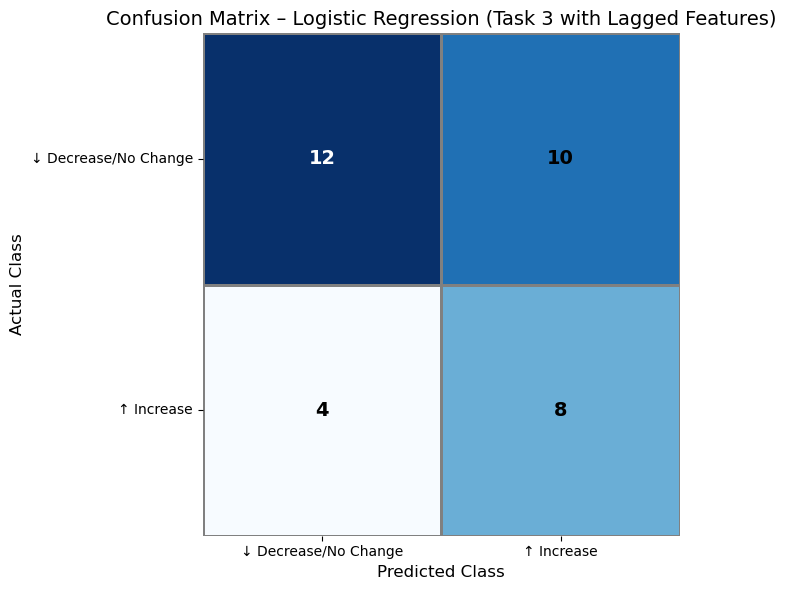

In [26]:
# Computing the confusion matrix
conf_matrix_logreg = confusion_matrix(y_val_task3_lagged_class, y_pred_logreg_lagged, labels=[0, 1])

# Label mapping
labels = ["↓ Decrease/No Change", "↑ Increase"]

# Creating the heatmap
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    conf_matrix_logreg,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    linewidths=1,
    linecolor="gray"
)

# Setting the color for the values
for i in range(conf_matrix_logreg.shape[0]):
    for j in range(conf_matrix_logreg.shape[1]):
        value = conf_matrix_logreg[i, j]
        text_color = "white" if value > 10 else "black"
        ax.text(j + 0.5, i + 0.5, str(value),
                ha="center", va="center",
                color=text_color, fontsize=14, fontweight="bold")

# Labels and title
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Confusion Matrix – Logistic Regression (Task 3 with Lagged Features)", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Notes: 
Logistic Regression Evaluation – Task 3 (Binary Classification)
- Accuracy: 59% of all test cases were correctly classified.
- Precision: 44% of predicted increases were actually increases. This means the model has a moderate false positive rate.
- Recall: 67% of actual increases in homelessness were correctly identified. This is relatively strong and aligns with goal to catch increases.
- F1 Score: 53%, showing a balance that leans more toward recall than precision.

Confusion Matrix Interpretation
- 12 counties correctly predicted as having no increase in homelessness.
- 10 counties that actually decreased were misclassified as increases.
- 8 counties correctly identified as having increased homelessness.
- 4 counties that increased were misclassified as decreases.

This model is more effective at catching increases in homelessness than avoiding false alarms.

<a id="section-4_4"></a>
### 4.4 Cross-sectional temporal splitting: Regression models

#### 4.4.1 Cross-sectional temporal splitting of the imputed lagged dataset into training, validation and testing for regression.

In [242]:
# One-hot encoded + imputed + lagged dataset
# Loading the dataset
model_file_path = "./data/df_task3_onehot_lagged_imputed_20250520.csv"
df_model_task3_onehot_imputed = pd.read_csv(model_file_path)

# Setting the target for Task 3
target_task3 = "pct_change_total_homeless_per_10k"

# Running cross-sectional temporal split
splits_task3_onehot_imputed = cross_sectional_temporal_split(
    df=df_model_task3_onehot_imputed,
    selected_features=selected_features_task3_onehot_imputed,
    target_column=target_task3
)

# Unpacking with task3_onehot_imputed naming convention
# Variables need to be adjusted
X_train_task3_onehot_imputed = splits_task3_onehot_imputed["X_train"]
y_train_task3_onehot_imputed = splits_task3_onehot_imputed["y_train"]
ids_train_task3_onehot_imputed = splits_task3_onehot_imputed["ids_train"]

X_val_task3_onehot_imputed = splits_task3_onehot_imputed["X_val"]
y_val_task3_onehot_imputed = splits_task3_onehot_imputed["y_val"]
val_ids_task3_onehot_imputed = splits_task3_onehot_imputed["ids_val"]

X_test_task3_onehot_imputed = splits_task3_onehot_imputed["X_test"]
y_test_task3_onehot_imputed = splits_task3_onehot_imputed["y_test"]
test_ids_task3_onehot_imputed = splits_task3_onehot_imputed["ids_test"]


Dataset split summary:
Train set: 323 rows, 73 counties
Val set:   25 rows, 25 counties
Test set:  26 rows, 25 counties

Year distributions:
Train years: [2012, 2013, 2014, 2015, 2016]
Val years:   [2017]
Test years:  [2018]


#### 4.4.2 Checking for NaNs in Training, Validation and Test

In [243]:
check_missing_in_splits({
    "X_train": X_train_task3_onehot_imputed,
    "X_val": X_val_task3_onehot_imputed,
    "X_test": X_test_task3_onehot_imputed,
    "y_train": y_train_task3_onehot_imputed,
    "y_val": y_val_task3_onehot_imputed,
    "y_test": y_test_task3_onehot_imputed,
})

X_train: 0 missing values
X_val: 0 missing values
X_test: 0 missing values
y_train: 0 missing values
y_val: 0 missing values
y_test: 0 missing values


#### 4.4.3 Train a regression model

In [215]:
# Fitting the OLS model on the one-hot encoded temporal training data
model_ols_task3_onehot_imputed = LinearRegression()
model_ols_task3_onehot_imputed.fit(X_train_task3_onehot_imputed, y_train_task3_onehot_imputed)

# Checking alignment between feature list and training columns
if list(X_train_task3_onehot_imputed.columns) == selected_features_task3_onehot_imputed:
    # Aligned: use provided feature list
    coefficients_task3_onehot_imputed = pd.DataFrame({
        "Feature": selected_features_task3_onehot_imputed,
        "Coefficient": model_ols_task3_onehot_imputed.coef_
    })
    print("Feature list is aligned with X_train_task3_onehot_imputed columns.")
else:
    # Fallback to X_train column names
    coefficients_task3_onehot_imputed = pd.DataFrame({
        "Feature": X_train_task3_onehot_imputed.columns,
        "Coefficient": model_ols_task3_onehot_imputed.coef_
    })
    print("Feature list misaligned — using X_train_task3_onehot_imputed.columns instead.")

# Displaying sorted coefficients
#print(coefficients_task3_onehot_imputed.sort_values(by="Coefficient", ascending=False))
pd.set_option("display.max_rows", 30)
print(coefficients_task3_onehot_imputed.sort_values(by="Coefficient", ascending=False).round(4))

Feature list is aligned with X_train_task3_onehot_imputed columns.
                                              Feature  Coefficient
8   Percentage_of_Households_with_Cost_Burden_5_ye...       2.2272
1                      CoC_Category_Largely Rural CoC       0.5845
0                      CoC_Category_Largely Rural CoC       0.5845
11         Share_of_Renter_Occupied_Units_5_year_lag1       0.2052
14                                  Poverty Rate_lag1       0.0060
9                    Rental_Vacancy_Rates_5_year_lag1       0.0011
13                       Median Household Income_lag1       0.0000
5                     Median_House_Values_5_year_lag1       0.0000
15                                   Labor Force_lag1       0.0000
7                       Median_Gross_Rent_5_year_lag1      -0.0004
6                             Median_Rent_5_year_lag1      -0.0004
12                             Unemployment Rate_lag1      -0.0171
2                   CoC_Category_Largely Suburban CoC      -0.

#### 4.4.4 Evaluating the regression model

In [216]:
# Predicting using the cross-sectional temporal validation set
y_pred_ols_task3_onehot_imputed = model_ols_task3_onehot_imputed.predict(X_val_task3_onehot_imputed)

# Computing evaluation metrics
r2_ols_task3_onehot_imputed = r2_score(y_val_task3_onehot_imputed, y_pred_ols_task3_onehot_imputed)
rmse_ols_task3_onehot_imputed = np.sqrt(mean_squared_error(y_val_task3_onehot_imputed, y_pred_ols_task3_onehot_imputed))

# Displaying results
print(f"R² Score on Validation Set (One-Hot + lagged + imputed): {r2_ols_task3_onehot_imputed:.4f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set (One-Hot + lagged + imputed): {rmse_ols_task3_onehot_imputed:.4f}")

# showing the mean of the target as a benchmark
baseline_rmse = np.sqrt(mean_squared_error(y_val_task3_onehot_imputed, [y_val_task3_onehot_imputed.mean()] * len(y_val_task3_onehot_imputed)))
print(f"Baseline RMSE (mean-only): {baseline_rmse:.4f}")

R² Score on Validation Set (One-Hot + lagged + imputed): -0.4743
Root Mean Squared Error (RMSE) on Validation Set (One-Hot + lagged + imputed): 0.1864
Baseline RMSE (mean-only): 0.1535


#### 4.4.5 Predicted vs Actual plot for validation set

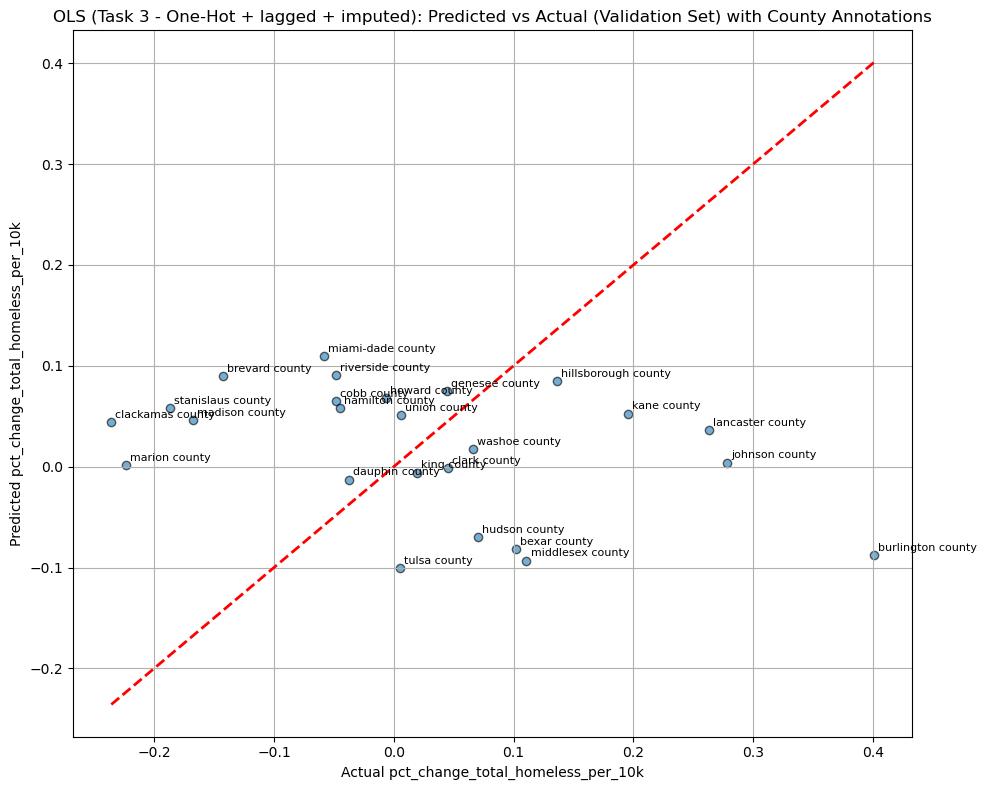

In [217]:
# Creating a scatter plot for Task 3 one-hot + lagged + imputed validation results
plt.figure(figsize=(10, 8))
plt.scatter(y_val_task3_onehot_imputed, y_pred_ols_task3_onehot_imputed, alpha=0.6, edgecolors='k')

# Reference line: perfect prediction
plt.plot(
    [y_val_task3_onehot_imputed.min(), y_val_task3_onehot_imputed.max()],
    [y_val_task3_onehot_imputed.min(), y_val_task3_onehot_imputed.max()],
    color='red', linestyle='--', linewidth=2
)

# Annotating the counties
for i, county in enumerate(val_ids_task3_onehot_imputed["County"]):
    plt.annotate(
        county,
        (y_val_task3_onehot_imputed.iloc[i], y_pred_ols_task3_onehot_imputed[i]),
        textcoords="offset points", xytext=(3, 3), ha='left', fontsize=8
    )

# Labels and title
plt.xlabel("Actual pct_change_total_homeless_per_10k")
plt.ylabel("Predicted pct_change_total_homeless_per_10k")
plt.title("OLS (Task 3 - One-Hot + lagged + imputed): Predicted vs Actual (Validation Set) with County Annotations")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.4.6 Notes: Dataset: One-Hot Encoded + Lagged + Imputed

Goal: Predict pct_change_total_homeless_per_10k

- R² Score: -0.4743
    - Indicates the model performs worse than predicting the mean.
    - This Suggests poor model fit.
- RMSE: 0.1864
- Baseline RMSE (mean-only): 0.1535
    - A naive model that predicts the mean for all observations outperforms the OLS model
- The plot shows that themajority of predicted values are clustered near zero, regardless of the actual value
- The model exhibits systematic bias toward underestimating both positive and negative changes
- Example - Burlington County has the highest actual increase (~0.4), but the model predicts near zero
- The model is regressing heavily to the mean, failing to differentiate counties with large changes from those with small or no changes.

#### 4.4.7 Saving the OLS Regression Model

In [218]:
# Creating the output directory if it doesn't exist
output_dir = "./models/"
os.makedirs(output_dir, exist_ok=True)

# Getting the current date
current_date = datetime.datetime.now().strftime("%Y%m%d")

# Defining the model save path for Task 3 OLS + onehot + imputed + lagged
model_path = os.path.join(output_dir, f"ols_model_task3_onehot_imputed_lagged_{current_date}.pkl")

# Save the trained model
joblib.dump(model_ols_task3_onehot_imputed, model_path)

# Confirm
print(f"OLS model (Task 3 - One-Hot + Lagged + Imputed) saved to: {model_path}")

OLS model (Task 3 - One-Hot + Lagged + Imputed) saved to: ./models/ols_model_task3_onehot_imputed_lagged_20250520.pkl


#### 4.4.8 Train Random Forest model

In [ ]:
# Defining the Random Forest model
rf_model_task3_onehot_imputed = RandomForestRegressor(random_state=42)

# Defining hyperparameter grid
param_dist_rf_onehot_imputed = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized search with cross-validation
random_search_rf_onehot_imputed = RandomizedSearchCV(
    estimator=rf_model_task3_onehot_imputed,
    param_distributions=param_dist_rf_onehot_imputed,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Fitting the model on one-hot encoded training data
random_search_rf_onehot_imputed.fit(X_train_task3_onehot_imputed, y_train_task3_onehot_imputed)

# Retrieve the best model
best_rf_model_task3_onehot_imputed = random_search_rf_onehot_imputed.best_estimator_
print("Best parameters found:")
print(random_search_rf_onehot_imputed.best_params_)

# Displaying feature importances
importances_rf_onehot_imputed = best_rf_model_task3_onehot_imputed.feature_importances_
feature_importance_df_rf_onehot_imputed = pd.DataFrame({
    "Feature": selected_features_task3_onehot_imputed,
    "Importance": importances_rf_onehot_imputed
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (Random Forest - One-Hot + lagged + imputed):")
print(feature_importance_df_rf_onehot_imputed)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Top Feature Importances (Random Forest - One-Hot + lagged + imputed):
                                              Feature  Importance
0                      CoC_Category_Largely Rural CoC    0.198044
1                      CoC_Category_Largely Rural CoC    0.184507
11         Share_of_Renter_Occupied_Units_5_year_lag1    0.111195
6                             Median_Rent_5_year_lag1    0.082965
15                                   Labor Force_lag1    0.081175
5                     Median_House_Values_5_year_lag1    0.073292
7                       Median_Gross_Rent_5_year_lag1    0.072446
9                    Rental_Vacancy_Rates_5_year_lag1    0.047811
8   Percentage_of_Households_with_Cost_Burden_5_ye...    0.041736
14                                  Poverty Rate_lag

#### 4.4.9 Evaluating the Random Forest Model

In [ ]:
# Predicting on the validation set (one-hot)
y_pred_rf_val_task3_onehot_imputed = best_rf_model_task3_onehot_imputed.predict(X_val_task3_onehot_imputed)

# Computing evaluation metrics
r2_rf_val_task3_onehot_imputed = r2_score(y_val_task3_onehot_imputed, y_pred_rf_val_task3_onehot_imputed)
rmse_rf_val_task3_onehot_imputed = np.sqrt(mean_squared_error(y_val_task3_onehot_imputed, y_pred_rf_val_task3_onehot_imputed))

# Displaying results
print(f"\n[Random Forest on Validation Set (One-Hot Encoded + lagged + imputed)]")
print(f"R² Score: {r2_rf_val_task3_onehot_imputed:.4f}")
print(f"RMSE: {rmse_rf_val_task3_onehot_imputed:.4f}")

# Adding baseline RMSE
baseline_rmse_rf = np.sqrt(mean_squared_error(
    y_val_task3_onehot_imputed,
    [y_val_task3_onehot_imputed.mean()] * len(y_val_task3_onehot_imputed)
))
print(f"Baseline RMSE (mean-only): {baseline_rmse_rf:.4f}")


[Random Forest on Validation Set (One-Hot Encoded + lagged + imputed)]
R² Score: -1.1998
RMSE: 0.2276
Baseline RMSE (mean-only): 0.1535


#### 4.4.10 Notes: Dataset One-Hot Encoded + Lagged + Imputed features

Goal: Predict pct_change_total_homeless_per_10k

- R² Score: -1.1998
  - A negative R² means the model is performing worse than simply predicting the mean.
  - An R² of -1.2 indicates substantial error and the model not only fails to explain the variance, it introduces more noise than the baseline.
- RMSE vs. Baseline
  - RMSE (Model): 0.2276
  - Baseline RMSE (Mean Prediction): 0.1535
  - Model makes larger errors than the naive constant prediction
- What could be wrong
  - Low sample size
  - Too many weak or uninformative features

<a id="section-4_5"></a>
### 4.5 Cross-sectional stratified temporal splitting: Classification models

#### 4.5.1 Loading classification dataset and removing duplicates

In [55]:
# Loading the classification modeling dataset
model_file_path = "./data/df_task3_onehot_lagged_imputed_classification_20250604.csv"
df_model_task3_onehot_imputed_classification = pd.read_csv(model_file_path)

# Identifying duplicates based on CoC Number, County, and Year
dup_mask = df_model_task3_onehot_imputed_classification.duplicated(subset=["CoC Number", "County", "Year"], keep="first")
duplicate_rows = df_model_task3_onehot_imputed_classification[dup_mask]

# Reporting number and source of duplicates
num_duplicates = duplicate_rows.shape[0]
print(f"Number of duplicate rows removed: {num_duplicates}")

if num_duplicates > 0:
    print("\nSample of duplicate source rows (CoC Number, County, Year):")
    display(duplicate_rows[["CoC Number", "County", "Year"]].drop_duplicates().head())

# Dropping duplicates and reset index
df_model_task3_onehot_imputed_classification = df_model_task3_onehot_imputed_classification.drop_duplicates(
    subset=["CoC Number", "County", "Year"]
).reset_index(drop=True)

print(f"\nClassification DataFrame shape after deduplication: {df_model_task3_onehot_imputed_classification.shape}")

Number of duplicate rows removed: 29

Sample of duplicate source rows (CoC Number, County, Year):


,CoC Number,County,Year
389,MD-505,baltimore county,2012
393,MD-505,baltimore county,2013
397,MD-505,baltimore county,2014
401,MD-505,baltimore county,2015
405,MD-505,baltimore county,2016



Classification DataFrame shape after deduplication: (1006, 19)


#### 4.5.2 Cross-sectional stratified temporal splitting of the imputed lagged dataset into training, validation and testing for classification

In [56]:
# Setting the classification target for Task 3
target_class_task3 = "target_class"

# Running cross-sectional temporal split for classification
splits_task3_onehot_imputed_class = cross_sectional_temporal_split(
    df=df_model_task3_onehot_imputed_classification,
    selected_features=selected_features_task3_onehot_imputed,
    target_column=target_class_task3
)

# Unpacking the classification splits
X_train_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["X_train"]
y_train_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["y_train"]
ids_train_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["ids_train"]

X_val_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["X_val"]
y_val_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["y_val"]
val_ids_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["ids_val"]

X_test_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["X_test"]
y_test_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["y_test"]
test_ids_task3_onehot_imputed_class = splits_task3_onehot_imputed_class["ids_test"]

# Confirming shapes for sanity check
print("\nX_train shape:", X_train_task3_onehot_imputed_class.shape)
print("y_train shape:", y_train_task3_onehot_imputed_class.shape)

print("X_val shape:", X_val_task3_onehot_imputed_class.shape)
print("y_val shape:", y_val_task3_onehot_imputed_class.shape)


Dataset split summary:
Train set: 445 rows, 73 counties
Val set:   27 rows, 25 counties
Test set:  25 rows, 25 counties

Year distributions:
Train years: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val years:   [2017]
Test years:  [2018]

X_train shape: (445, 14)
y_train shape: (445,)
X_val shape: (27, 14)
y_val shape: (27,)


#### 4.5.3 Standardizing the features for logistic regression only

In [58]:
# Prepare both scaled and unscaled sets
data_task3_inputs = prepare_scaled_and_unscaled_inputs(
    X_train_task3_onehot_imputed_class,
    X_val_task3_onehot_imputed_class,
    X_test_task3_onehot_imputed_class
)

# Use for Logistic Regression
X_train_logit = data_task3_inputs["scaled"]["X_train"]
X_val_logit = data_task3_inputs["scaled"]["X_val"]
X_test_logit = data_task3_inputs["scaled"]["X_test"]

# Use for Random Forest
X_train_rf = data_task3_inputs["unscaled"]["X_train"]
X_val_rf = data_task3_inputs["unscaled"]["X_val"]
X_test_rf = data_task3_inputs["unscaled"]["X_test"]

# Use for XGBoost
X_train_xgb = data_task3_inputs["unscaled"]["X_train"]
X_val_xgb = data_task3_inputs["unscaled"]["X_val"]
X_test_xgb = data_task3_inputs["unscaled"]["X_test"]

#### 4.5.4 Train logistic regression model

In [59]:
# Training logistic regression on the classification dataset
logit_model_task3_onehot_imputed_class = LogisticRegression(
    solver="lbfgs",         # for small datasets
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

y_train_class = y_train_task3_onehot_imputed_class

# Fitting on the scaled classification training set
logit_model_task3_onehot_imputed_class.fit(
    X_train_logit,
    y_train_class  
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### 4.5.5 Predicting and evaluating using the validation set

In [60]:
# Predicting on the validation set (classification)
y_val_pred_logit = logit_model_task3_onehot_imputed_class.predict(X_val_logit)

# Evaluation metrics
accuracy = accuracy_score(y_val_task3_onehot_imputed_class, y_val_pred_logit)
precision = precision_score(y_val_task3_onehot_imputed_class, y_val_pred_logit)
recall = recall_score(y_val_task3_onehot_imputed_class, y_val_pred_logit)
f1 = f1_score(y_val_task3_onehot_imputed_class, y_val_pred_logit)

# Predicted probabilities for ROC/AUC
y_val_proba_logit = logit_model_task3_onehot_imputed_class.predict_proba(X_val_logit)[:, 1]
auc = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_logit)

# Printing results
print("Logistic Regression (One-Hot + Lagged + Imputed – Classification)")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_val_pred_logit))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_val_pred_logit))

Logistic Regression (One-Hot + Lagged + Imputed – Classification)
Accuracy:  0.70
Precision: 0.80
Recall:    0.57
F1 Score:  0.67
AUC:       0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.85      0.73        13
           1       0.80      0.57      0.67        14

    accuracy                           0.70        27
   macro avg       0.72      0.71      0.70        27
weighted avg       0.73      0.70      0.70        27

Confusion Matrix:
[[11  2]
 [ 6  8]]


#### 4.5.6 ROC Curve for logistic regression

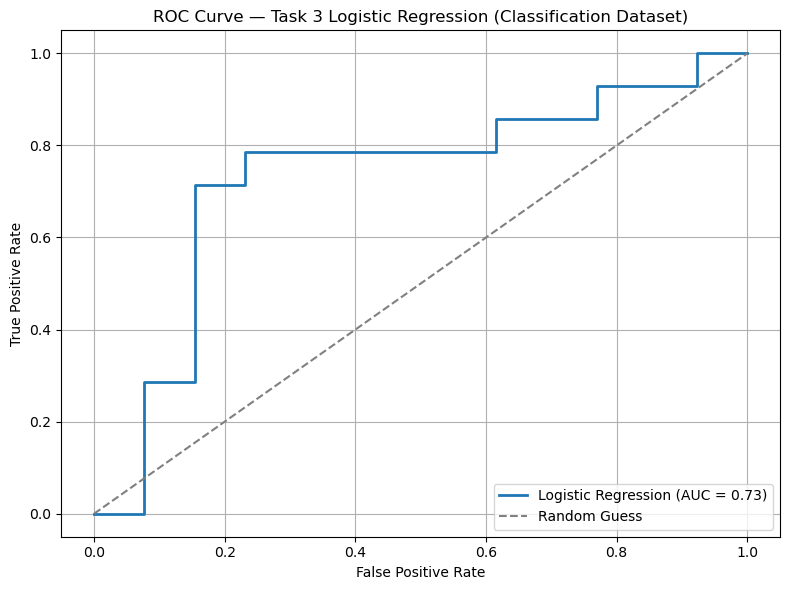

In [61]:
# Predicting probabilities for class 1
y_pred_proba_task3_class = logit_model_task3_onehot_imputed_class.predict_proba(X_val_logit)[:, 1]

# Computing FPR, TPR, and thresholds
fpr_class, tpr_class, thresholds_class = roc_curve(y_val_task3_onehot_imputed_class, y_pred_proba_task3_class)

# Computing AUC
auc_score_class = roc_auc_score(y_val_task3_onehot_imputed_class, y_pred_proba_task3_class)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_class, tpr_class, label=f"Logistic Regression (AUC = {auc_score_class:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Task 3 Logistic Regression (Classification Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.7 Notes: Logistic Regression Evaluation (One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.65**: When the model predicts no increase, it is correct 65% of the time.
  - **Recall = 0.85**: The model correctly identifies 85% of actual no increase cases.
  - **F1 Score = 0.73**: Indicates strong and consistent performance on the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.80**: 80% of predicted increase cases were actually correct — the highest precision observed so far.
  - **Recall = 0.57**: The model captures more than half of actual increases, a significant improvement.
  - **F1 Score = 0.67**: Balanced performance between precision and recall for this key class.

---

##### **Overall Evaluation**
- **Accuracy = 0.70**: A substantial improvement over prior models — 70% of total predictions are correct.
- **AUC = 0.73**: The ROC curve indicates meaningful ability to distinguish between increases and non-increases.
- **Macro Avg F1 = 0.70**, **Weighted Avg F1 = 0.70**: Strong performance across both classes.

---

##### **Conclusion**
This version of logistic regression demonstrates the best performance to date:
- Balanced and accurate predictions across both classes.
- Useful as a baseline classifier for flagging counties at risk of rising homelessness.
- Stratified temporal splitting and including 2010–2011 stabilized generalization and improved model quality.

#### 4.5.8 Extracting and ranking the top 5 features

In [62]:
# Creating DataFrame of feature names and coefficients
logreg_coeff_df = pd.DataFrame({
    "Feature": X_train_task3_onehot_imputed_class.columns,
    "Coefficient": logit_model_task3_onehot_imputed_class.coef_[0]
})

# Computing absolute values for ranking
logreg_coeff_df["abs_coef"] = logreg_coeff_df["Coefficient"].abs()

# Sorting by absolute coefficient magnitude
logreg_coeff_df_sorted = logreg_coeff_df.sort_values(by="abs_coef", ascending=False)

# Extracting top 5 features
top_5_features = logreg_coeff_df_sorted.head(5)

# Displaying result
print("Top 5 features by absolute logistic regression coefficient:")
display(top_5_features)

Top 5 features by absolute logistic regression coefficient:


,Feature,Coefficient,abs_coef
4,Median_Rent_5_year_lag1,-0.962874,0.962874
3,Median_House_Values_5_year_lag1,0.466812,0.466812
6,Percentage_of_Households_with_Cost_Burden_5_ye...,0.349914,0.349914
12,Poverty Rate_lag1,-0.307559,0.307559
11,Median Household Income_lag1,0.296664,0.296664


#### 4.5.9 Refitting logistic regression model

In [63]:
# Getting top 5 feature names
top_features_list = top_5_features["Feature"].tolist()

# Extracting top 5 columns from original (unscaled) feature DataFrames
X_train_top5 = X_train_task3_onehot_imputed_class[top_features_list]
X_val_top5 = X_val_task3_onehot_imputed_class[top_features_list]

# Standardize only the top 5 features
scaler_top5 = StandardScaler()
X_train_top5_logit = scaler_top5.fit_transform(X_train_top5)
X_val_top5_logit = scaler_top5.transform(X_val_top5)

# Defining and fitting logistic regression model on top 5 scaled features
logit_model_top5 = LogisticRegression(
    solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=42
)
logit_model_top5.fit(X_train_top5_logit, y_train_class)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### 4.5.10 Predicting and evaluating logisitc regression model with top 5 features

In [64]:
# Predicting on the validation set using top 5 features
y_val_pred_logit_top5 = logit_model_top5.predict(X_val_top5_logit)

# Evaluation metrics
accuracy = accuracy_score(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5)
precision = precision_score(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5)
recall = recall_score(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5)
f1 = f1_score(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5)

# Predicted probabilities for ROC/AUC
y_val_proba_logit_top5 = logit_model_top5.predict_proba(X_val_top5_logit)[:, 1]
auc = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_logit_top5)

# Printing results
print("Logistic Regression (Top 5 Features – One-Hot + Lagged + Imputed – Classification)")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_val_pred_logit_top5))

Logistic Regression (Top 5 Features – One-Hot + Lagged + Imputed – Classification)
Accuracy:  0.59
Precision: 0.80
Recall:    0.29
F1 Score:  0.42
AUC:       0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69        13
           1       0.80      0.29      0.42        14

    accuracy                           0.59        27
   macro avg       0.67      0.60      0.55        27
weighted avg       0.68      0.59      0.55        27

Confusion Matrix:
[[12  1]
 [10  4]]


#### 4.5.11 ROC curve for logistic regression with top 5 features

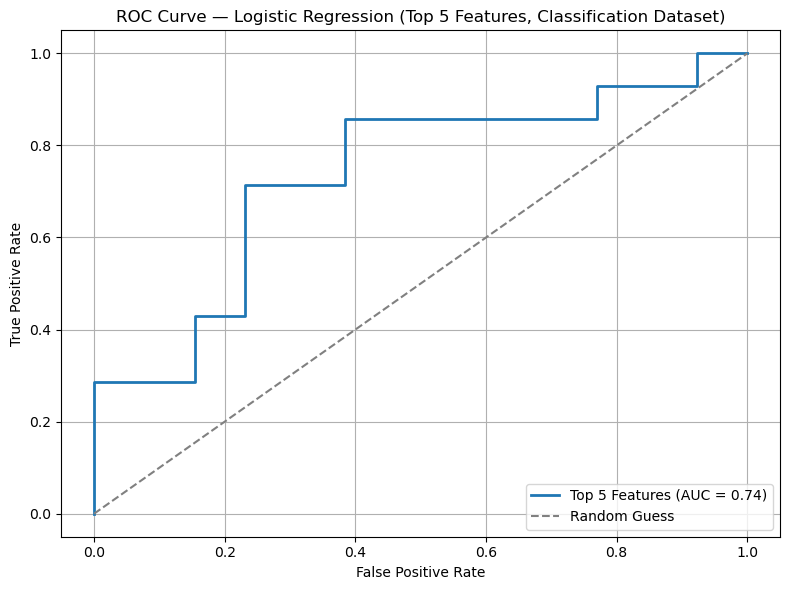

In [65]:
# Predicting probabilities for class 1 using the top-5-feature model
y_pred_proba_top5 = logit_model_top5.predict_proba(X_val_top5_logit)[:, 1]

# Computing FPR, TPR, and thresholds
fpr_top5, tpr_top5, thresholds_top5 = roc_curve(y_val_task3_onehot_imputed_class, y_pred_proba_top5)

# Computing AUC
auc_score_top5 = roc_auc_score(y_val_task3_onehot_imputed_class, y_pred_proba_top5)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_top5, tpr_top5, label=f"Top 5 Features (AUC = {auc_score_top5:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Top 5 Features, Classification Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.12 Notes: Logistic Regression Evaluation (Top 5 Features – One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.55**: When the model predicts no increase, it is correct 55% of the time.
  - **Recall = 0.92**: The model captures nearly all actual no-increase cases (12 out of 13).
  - **F1 Score = 0.69**: Strong performance on the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.80**: 80% of predicted increases were correct.
  - **Recall = 0.29**: The model identified only 4 out of 14 actual increase cases.
  - **F1 Score = 0.42**: Weak recall but strong precision creates a modest F1 score.

---

##### **Overall Evaluation**
- **Accuracy = 0.59**: Slightly better than random, but below logistic regression with all features (70%).
- **AUC = 0.74**: The model is relatively good at ranking increase vs. no-increase cases, even with fewer features.
- **Macro Avg F1 = 0.55**, **Weighted Avg F1 = 0.55**: Moderate overall performance with imbalance between classes.

---

##### **Conclusion**
- The model trained on only the top 5 features maintains **strong precision** and an impressive **AUC (0.74)**, indicating it can **rank cases well** even if raw classification is weaker.
- However, **recall on increases is poor (29%)**, suggesting the model fails to catch many true positives.

#### 4.5.13 Merging CoC, County, and Year info with predictions

In [66]:
# Merging validation predictions with CoC, County, Year info
val_preds_top5_df = val_ids_task3_onehot_imputed_class.copy()
val_preds_top5_df["actual_class"] = y_val_task3_onehot_imputed_class
val_preds_top5_df["predicted_class"] = y_val_pred_logit_top5
val_preds_top5_df["predicted_proba"] = y_val_proba_logit_top5

# Previewing merged validation predictions
display(val_preds_top5_df.head())

,CoC Number,County,Year,actual_class,predicted_class,predicted_proba
0,CA-504,sonoma county,2017,1,0,0.466450
1,CA-511,san joaquin county,2017,1,1,0.517040
2,CA-512,san mateo county,2017,0,0,0.440134
3,CA-603,santa barbara county,2017,0,0,0.426748
4,CA-604,kern county,2017,1,0,0.470576


#### 4.5.14 Train Random Forest classifier

In [71]:
# Define the Random Forest classifier
rf_model_task3_onehot_imputed_clf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Hyperparameter grid for randomized search
param_dist_rf_task3_onehot_imputed_clf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized search with cross-validation
random_search_rf_task3_onehot_imputed_clf = RandomizedSearchCV(
    estimator=rf_model_task3_onehot_imputed_clf,
    param_distributions=param_dist_rf_task3_onehot_imputed_clf,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='roc_auc',
    random_state=42
)

# Fit the classifier on unscaled one-hot + imputed training data
random_search_rf_task3_onehot_imputed_clf.fit(X_train_rf, y_train_class)

# Retrieve the best estimator
best_rf_model_task3_onehot_imputed_clf = random_search_rf_task3_onehot_imputed_clf.best_estimator_
print("Best parameters found:")
print(random_search_rf_task3_onehot_imputed_clf.best_params_)

# Feature importances
importances_rf_task3_onehot_imputed_clf = best_rf_model_task3_onehot_imputed_clf.feature_importances_
feature_importance_df_rf_task3_onehot_imputed_clf = pd.DataFrame({
    "Feature": X_train_rf.columns,
    "Importance": importances_rf_task3_onehot_imputed_clf
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (Random Forest Classifier - One-Hot + Lagged + Imputed):")
display(feature_importance_df_rf_task3_onehot_imputed_clf.head(10))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

Top Feature Importances (Random Forest Classifier - One-Hot + Lagged + Imputed):


,Feature,Importance
4,Median_Rent_5_year_lag1,0.108826
7,Rental_Vacancy_Rates_5_year_lag1,0.107787
5,Median_Gross_Rent_5_year_lag1,0.104070
12,Poverty Rate_lag1,0.103918
11,Median Household Income_lag1,0.101525
3,Median_House_Values_5_year_lag1,0.101181
6,Percentage_of_Households_with_Cost_Burden_5_ye...,0.096903
13,Labor Force_lag1,0.093996
10,Unemployment Rate_lag1,0.081164
9,Share_of_Renter_Occupied_Units_5_year_lag1,0.077649


#### 4.5.15 Predicting and evaluating using the validation set

In [72]:
# Predicting class labels and probabilities using the best classifier
y_val_pred_rf_task3_onehot_imputed_clf = best_rf_model_task3_onehot_imputed_clf.predict(X_val_rf)
y_val_proba_rf_task3_onehot_imputed_clf = best_rf_model_task3_onehot_imputed_clf.predict_proba(X_val_rf)[:, 1]

# Computing evaluation metrics
accuracy = accuracy_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf)
precision = precision_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf)
recall = recall_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf)
f1 = f1_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf)
auc = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_rf_task3_onehot_imputed_clf)

# Displaying results
print("\n[Random Forest Classifier — Task 3 Validation Set (One-Hot + Lagged + Imputed)]")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_val_pred_rf_task3_onehot_imputed_clf))


[Random Forest Classifier — Task 3 Validation Set (One-Hot + Lagged + Imputed)]
Accuracy:  0.5556
Precision: 0.7500
Recall:    0.2143
F1 Score:  0.3333
AUC:       0.5824

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.92      0.67        13
           1       0.75      0.21      0.33        14

    accuracy                           0.56        27
   macro avg       0.64      0.57      0.50        27
weighted avg       0.64      0.56      0.49        27

Confusion Matrix:
[[12  1]
 [11  3]]


#### 4.5.16 ROC Curve for Random Forest Classifier

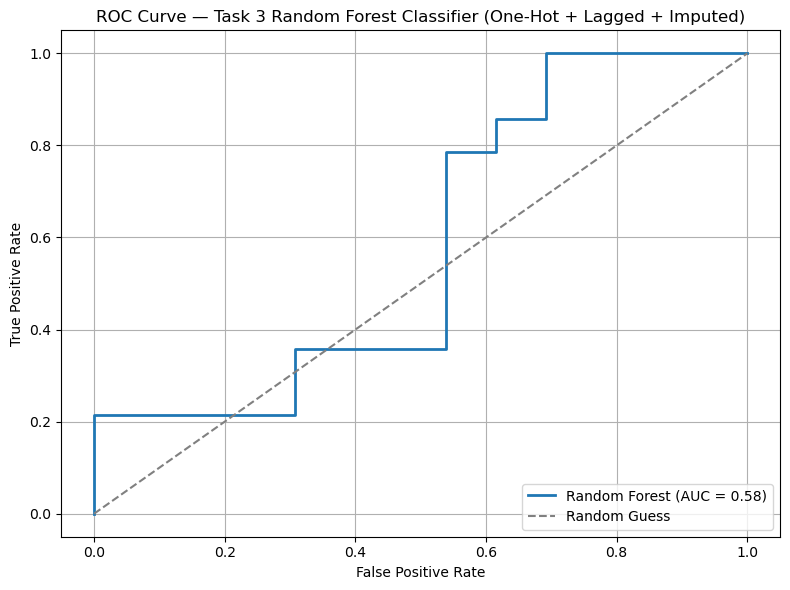

In [73]:
# Getting predicted probabilities for the positive class (increase = 1)
y_val_proba_rf_task3_onehot_imputed_clf = best_rf_model_task3_onehot_imputed_clf.predict_proba(X_val_rf)[:, 1]

# Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_task3_onehot_imputed_class, y_val_proba_rf_task3_onehot_imputed_clf)
auc_score = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_rf_task3_onehot_imputed_clf)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Task 3 Random Forest Classifier (One-Hot + Lagged + Imputed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.17 Notes: Random Forest Classifier – Task 3 (One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.52**: When the model predicts "no increase," it's correct 52% of the time.
  - **Recall = 0.92**: The model captures almost all of the true "no increase" cases.
  - **F1 Score = 0.67**: Indicates strong and reliable performance on the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.75**: High confidence when predicting an increase.
  - **Recall = 0.21**: Low sensitivity — the model only catches 3 out of 14 true increases.
  - **F1 Score = 0.33**: Precision is high, but recall weakness pulls down overall performance.

---

##### **Overall Evaluation**
- **Accuracy = 0.56**: Slightly better than random.
- **AUC = 0.58**: The ROC curve suggests the model has **some** ability to distinguish increases from no-increase cases.
- **Macro Avg F1 = 0.50**, **Weighted Avg F1 = 0.49**: Performance is skewed toward the majority class, with limited generalizability on the minority class.

---

##### **Conclusion**
- The Random Forest classifier is **highly precise but not sensitive**: when it predicts an increase, it’s usually correct — but it misses most true increases.
- The model performs **very well on "no increase" cases**, potentially useful if false positives are costly.
- **Recall on class 1 remains a bottleneck**, despite improved AUC and precision.

#### 4.5.18 Extracting and ranking the top 5 features

In [74]:
# Extracting top 5 features by importance from Random Forest
top_5_features_rf_task3_onehot_imputed_clf = feature_importance_df_rf_task3_onehot_imputed_clf.head(5).copy()

# Displaying results
print("Top 5 Features by Importance from Random Forest Classifier:")
display(top_5_features_rf_task3_onehot_imputed_clf)

# Saving feature names as a list for refitting models
top_features_list_rf_task3_onehot_imputed_clf = top_5_features_rf_task3_onehot_imputed_clf["Feature"].tolist()

Top 5 Features by Importance from Random Forest Classifier:


,Feature,Importance
4,Median_Rent_5_year_lag1,0.108826
7,Rental_Vacancy_Rates_5_year_lag1,0.107787
5,Median_Gross_Rent_5_year_lag1,0.104070
12,Poverty Rate_lag1,0.103918
11,Median Household Income_lag1,0.101525


#### 4.5.19 Refitting the Random Forest model

In [75]:
# Subsetting training and validation data to top 5 features
X_train_top5_rf_task3_onehot_imputed_clf = X_train_rf[top_features_list_rf_task3_onehot_imputed_clf]
X_val_top5_rf_task3_onehot_imputed_clf = X_val_rf[top_features_list_rf_task3_onehot_imputed_clf]

# Define and fit Random Forest classifier using top 5 features
rf_model_top5_task3_onehot_imputed_clf = RandomForestClassifier(
    n_estimators=200,  # from best tuning
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model_top5_task3_onehot_imputed_clf.fit(X_train_top5_rf_task3_onehot_imputed_clf, y_train_class)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

#### 4.5.20 Predicting and evaluating random forest model with top 5 features

In [76]:
# Predicting on validation set using top 5 features
y_val_pred_rf_top5_task3_onehot_imputed_clf = rf_model_top5_task3_onehot_imputed_clf.predict(
    X_val_top5_rf_task3_onehot_imputed_clf
)
y_val_proba_rf_top5_task3_onehot_imputed_clf = rf_model_top5_task3_onehot_imputed_clf.predict_proba(
    X_val_top5_rf_task3_onehot_imputed_clf
)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf)
precision = precision_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf)
recall = recall_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf)
f1 = f1_score(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf)
auc = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_rf_top5_task3_onehot_imputed_clf)

# Printing results
print("Random Forest Classifier Refit (Top 5 Features – One-Hot + Lagged + Imputed)")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_val_pred_rf_top5_task3_onehot_imputed_clf))

Random Forest Classifier Refit (Top 5 Features – One-Hot + Lagged + Imputed)
Accuracy:  0.5185
Precision: 0.6000
Recall:    0.2143
F1 Score:  0.3158
AUC:       0.5989

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.85      0.63        13
           1       0.60      0.21      0.32        14

    accuracy                           0.52        27
   macro avg       0.55      0.53      0.47        27
weighted avg       0.55      0.52      0.47        27

Confusion Matrix:
[[11  2]
 [11  3]]


#### 4.5.21 ROC curve for random forest with top 5 features

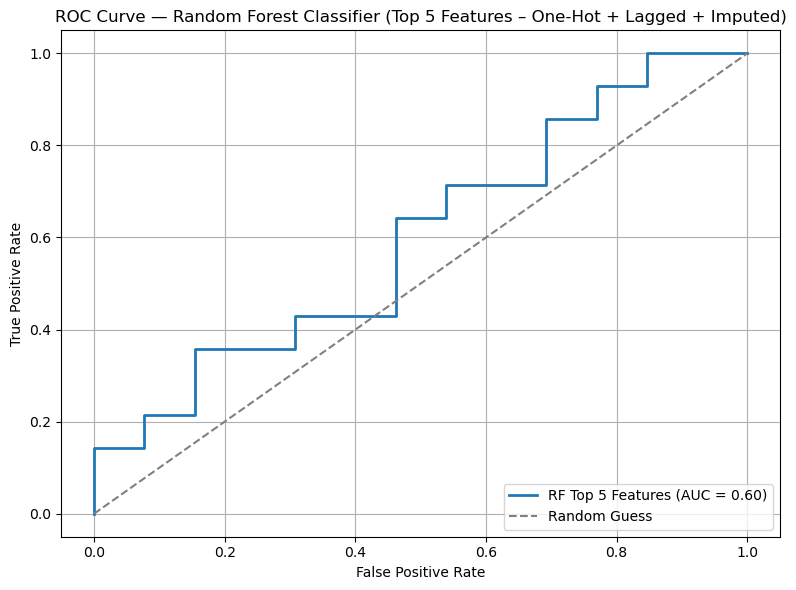

In [77]:
# Getting the predicted probabilities for class 1 (positive class)
y_val_proba_rf_top5_task3_onehot_imputed_clf = rf_model_top5_task3_onehot_imputed_clf.predict_proba(
    X_val_top5_rf_task3_onehot_imputed_clf
)[:, 1]

# Computing ROC curve
fpr_rf_top5, tpr_rf_top5, thresholds_rf_top5 = roc_curve(
    y_val_task3_onehot_imputed_class, y_val_proba_rf_top5_task3_onehot_imputed_clf
)

# Computing AUC score
auc_rf_top5 = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_rf_top5_task3_onehot_imputed_clf)

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_top5, tpr_rf_top5, label=f"RF Top 5 Features (AUC = {auc_rf_top5:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest Classifier (Top 5 Features – One-Hot + Lagged + Imputed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.22 Notes: Random Forest Classifier – Top 5 Features (One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.50**: When predicting no increase, the model is right 50% of the time.
  - **Recall = 0.85**: The model captures 85% of actual no-increase cases.
  - **F1 Score = 0.63**: Good performance on the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.60**: When the model predicts an increase, it’s correct 60% of the time.
  - **Recall = 0.21**: It captures only 3 out of 14 true increase cases.
  - **F1 Score = 0.32**: Moderately low overall performance due to low recall.

---

##### **Overall Evaluation**
- **Accuracy = 0.52**: Slightly better than random.
- **AUC = 0.60**: The ROC curve shows improved class separation, indicating **moderate discriminatory power**.
- **Macro Avg F1 = 0.47**, **Weighted Avg F1 = 0.47**: Reasonable performance balance across classes but skewed toward class 0.

---

##### **Conclusion**
- The refit with the top 5 features improves interpretability and **AUC**, while maintaining a high recall for "no increase" cases.
- However, **recall for increases remains low**, suggesting the model is still not capturing the signal needed to detect those counties reliably.

#### 4.5.23 Merging CoC, County, and Year info with predictions

In [78]:
# Merging predictions with CoC, County, Year info for Random Forest (Top 5 Features)
val_preds_rf_top5_task3_onehot_imputed_clf_df = val_ids_task3_onehot_imputed_class.copy()

# Adding actual class from validation set
val_preds_rf_top5_task3_onehot_imputed_clf_df["actual_class"] = y_val_task3_onehot_imputed_class

# Adding predicted class and predicted probabilities
val_preds_rf_top5_task3_onehot_imputed_clf_df["predicted_class"] = y_val_pred_rf_top5_task3_onehot_imputed_clf
val_preds_rf_top5_task3_onehot_imputed_clf_df["predicted_proba"] = y_val_proba_rf_top5_task3_onehot_imputed_clf

# Previewing the merged DataFrame
display(val_preds_rf_top5_task3_onehot_imputed_clf_df.head())

,CoC Number,County,Year,actual_class,predicted_class,predicted_proba
0,CA-504,sonoma county,2017,1,0,0.433500
1,CA-511,san joaquin county,2017,1,1,0.542641
2,CA-512,san mateo county,2017,0,0,0.085060
3,CA-603,santa barbara county,2017,0,0,0.457225
4,CA-604,kern county,2017,1,1,0.656238


#### 4.5.24 Train XGBoost classifier

In [90]:
# Define the XGBoost classifier
xgb_model_task3_onehot_imputed_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Hyperparameter grid for randomized search
param_dist_xgb_task3_onehot_imputed_clf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2.0]
}

# Preserving original DataFrames and create NumPy arrays only for model fitting
X_train_xgb_array = X_train_xgb.astype(float)
y_train_xgb_array = y_train_class.values.astype(int)

# Randomized search with cross-validation
random_search_xgb_task3_onehot_imputed_clf = RandomizedSearchCV(
    estimator=xgb_model_task3_onehot_imputed_clf,
    param_distributions=param_dist_xgb_task3_onehot_imputed_clf,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring="roc_auc",
    random_state=42
)

# Fit the model
random_search_xgb_task3_onehot_imputed_clf.fit(X_train_xgb_array, y_train_xgb_array)

# Retrieve the best estimator
best_xgb_model_task3_onehot_imputed_clf = random_search_xgb_task3_onehot_imputed_clf.best_estimator_
print("Best parameters found:")
print(random_search_xgb_task3_onehot_imputed_clf.best_params_)

# Feature importances — use column names from the original DataFrame
importances_xgb_task3_onehot_imputed_clf = best_xgb_model_task3_onehot_imputed_clf.feature_importances_
feature_importance_df_xgb_task3_onehot_imputed_clf = pd.DataFrame({
    "Feature": selected_features_task3_onehot_imputed,
    "Importance": importances_xgb_task3_onehot_imputed_clf
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importances (XGBoost Classifier - One-Hot + Lagged + Imputed):")
display(feature_importance_df_xgb_task3_onehot_imputed_clf.head(10))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Top Feature Importances (XGBoost Classifier - One-Hot + Lagged + Imputed):


,Feature,Importance
0,CoC_Category_Largely Rural CoC,0.105932
12,Poverty Rate_lag1,0.104499
1,CoC_Category_Major City CoC,0.081959
6,Percentage_of_Households_with_Cost_Burden_5_ye...,0.081820
3,Median_House_Values_5_year_lag1,0.078967
10,Unemployment Rate_lag1,0.077060
5,Median_Gross_Rent_5_year_lag1,0.075537
7,Rental_Vacancy_Rates_5_year_lag1,0.073912
4,Median_Rent_5_year_lag1,0.068400
13,Labor Force_lag1,0.064966


#### 4.5.25 Predicting and evaluating using the validation set

In [92]:
# Predicting class labels and probabilities using the best XGBoost classifier
y_pred_xgb_task3_onehot_imputed_clf = best_xgb_model_task3_onehot_imputed_clf.predict(X_val_xgb)
y_proba_xgb_task3_onehot_imputed_clf = best_xgb_model_task3_onehot_imputed_clf.predict_proba(X_val_xgb)[:, 1]

# Computing evaluation metrics
accuracy_xgb_task3_onehot_imputed_clf = accuracy_score(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf)
precision_xgb_task3_onehot_imputed_clf = precision_score(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf)
recall_xgb_task3_onehot_imputed_clf = recall_score(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf)
f1_xgb_task3_onehot_imputed_clf = f1_score(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf)
auc_xgb_task3_onehot_imputed_clf = roc_auc_score(y_val_task3_onehot_imputed_class, y_proba_xgb_task3_onehot_imputed_clf)

# Displaying results
print("\n[XGBoost Classifier — Task 3 Validation Set (One-Hot + Lagged + Imputed)]")
print(f"Accuracy:  {accuracy_xgb_task3_onehot_imputed_clf:.4f}")
print(f"Precision: {precision_xgb_task3_onehot_imputed_clf:.4f}")
print(f"Recall:    {recall_xgb_task3_onehot_imputed_clf:.4f}")
print(f"F1 Score:  {f1_xgb_task3_onehot_imputed_clf:.4f}")
print(f"AUC:       {auc_xgb_task3_onehot_imputed_clf:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_pred_xgb_task3_onehot_imputed_clf))


[XGBoost Classifier — Task 3 Validation Set (One-Hot + Lagged + Imputed)]
Accuracy:  0.5185
Precision: 0.6667
Recall:    0.1429
F1 Score:  0.2353
AUC:       0.5934

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.92      0.65        13
           1       0.67      0.14      0.24        14

    accuracy                           0.52        27
   macro avg       0.58      0.53      0.44        27
weighted avg       0.59      0.52      0.43        27

Confusion Matrix:
[[12  1]
 [12  2]]


#### 4.5.26 ROC Curve for XGBoost Classifier

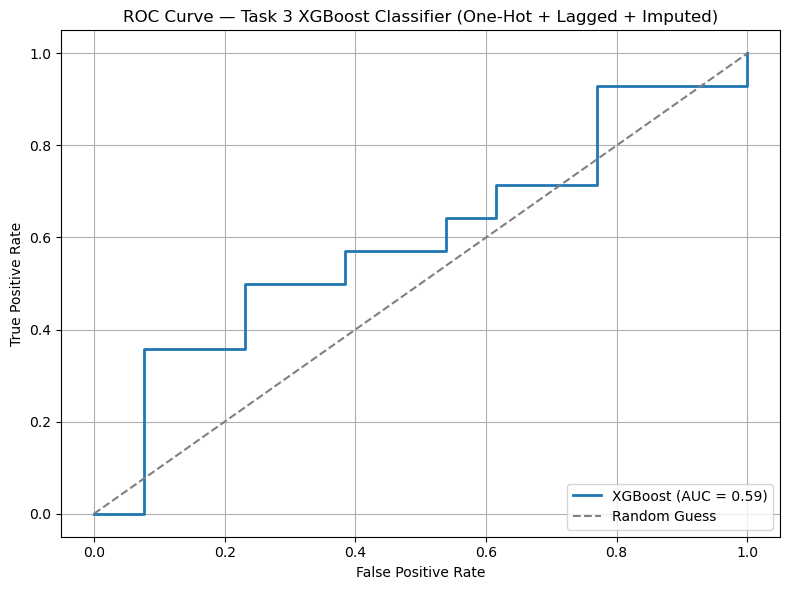

In [93]:
# Getting predicted probabilities for the positive class (increase = 1)
y_val_proba_xgb_task3_onehot_imputed_clf = best_xgb_model_task3_onehot_imputed_clf.predict_proba(X_val_xgb)[:, 1]

# Computing ROC curve and AUC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_val_task3_onehot_imputed_class, y_val_proba_xgb_task3_onehot_imputed_clf)
auc_score_xgb = roc_auc_score(y_val_task3_onehot_imputed_class, y_val_proba_xgb_task3_onehot_imputed_clf)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_score_xgb:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Task 3 XGBoost Classifier (One-Hot + Lagged + Imputed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.27 Notes: XGBoost Classifier – Task 3 (One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.50**: Half of the predicted no-increase cases were correct.
  - **Recall = 0.92**: The model captured nearly all true no-increase cases.
  - **F1 Score = 0.65**: Strong performance on the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.67**: When the model predicts an increase, it is correct two-thirds of the time.
  - **Recall = 0.14**: However, it only identifies 2 of the 14 true increases.
  - **F1 Score = 0.24**: Low due to weak recall.

---

##### **Overall Evaluation**
- **Accuracy = 0.52**: Slightly better than random guessing.
- **AUC = 0.59**: The ROC curve shows mild improvement in class separation compared to earlier models.
- **Macro Avg F1 = 0.44**, **Weighted Avg F1 = 0.43**: Suggests the model is skewed toward the majority class with limited generalizability.

---

##### **Conclusion**
- This XGBoost classifier prioritizes **precision over recall** for increases in homelessness.
- It performs **very well on "no increase" cases** but struggles to detect increases, which are critical for intervention.
- While AUC and precision are stronger than some previous models, **low recall makes it unreliable**.

#### 4.5.28 Extracting and ranking the top 10 features

In [98]:
# Extracting top 5 features by importance for XGBoost
top_10_features_xgb_task3_onehot_imputed_clf = feature_importance_df_xgb_task3_onehot_imputed_clf.head(10).copy()

# Displaying results
print("Top 10 Features by Importance from XGBoost Classifier:")
display(top_10_features_xgb_task3_onehot_imputed_clf)

# Saving list for later model fitting
top_features_list_xgb_task3_onehot_imputed_clf = top_10_features_xgb_task3_onehot_imputed_clf["Feature"].tolist()

Top 10 Features by Importance from XGBoost Classifier:


,Feature,Importance
0,CoC_Category_Largely Rural CoC,0.105932
12,Poverty Rate_lag1,0.104499
1,CoC_Category_Major City CoC,0.081959
6,Percentage_of_Households_with_Cost_Burden_5_ye...,0.081820
3,Median_House_Values_5_year_lag1,0.078967
10,Unemployment Rate_lag1,0.077060
5,Median_Gross_Rent_5_year_lag1,0.075537
7,Rental_Vacancy_Rates_5_year_lag1,0.073912
4,Median_Rent_5_year_lag1,0.068400
13,Labor Force_lag1,0.064966


#### 4.5.29 Refitting the XGBoost model

In [99]:
# Subsetting training and validation data to top 10 XGBoost features
X_train_top10_xgb_task3_onehot_imputed_clf = X_train_task3_onehot_imputed_class[top_features_list_xgb_task3_onehot_imputed_clf]
X_val_top10_xgb_task3_onehot_imputed_clf = X_val_task3_onehot_imputed_class[top_features_list_xgb_task3_onehot_imputed_clf]

# Refitting XGBoost using top 10 features and best parameters from RandomizedSearchCV
xgb_model_top10_task3_onehot_imputed_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    max_depth=7,
    learning_rate=0.01,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42
)

# Fit on reduced feature set
xgb_model_top10_task3_onehot_imputed_clf.fit(
    X_train_top10_xgb_task3_onehot_imputed_clf,
    y_train_task3_onehot_imputed_class
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

#### 4.5.30 Predicting and evaluating XGBoost model with top 10 features

In [100]:
# Predicting on validation set
y_pred_xgb_top10_task3_onehot_imputed_clf = xgb_model_top10_task3_onehot_imputed_clf.predict(X_val_top10_xgb_task3_onehot_imputed_clf)
y_proba_xgb_top10_task3_onehot_imputed_clf = xgb_model_top10_task3_onehot_imputed_clf.predict_proba(X_val_top10_xgb_task3_onehot_imputed_clf)[:, 1]

# Evaluating
accuracy_xgb_top10_task3_onehot_imputed_clf = accuracy_score(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf)
precision_xgb_top10_task3_onehot_imputed_clf = precision_score(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf)
recall_xgb_top10_task3_onehot_imputed_clf = recall_score(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf)
f1_xgb_top10_task3_onehot_imputed_clf = f1_score(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf)
auc_xgb_top10_task3_onehot_imputed_clf = roc_auc_score(y_val_task3_onehot_imputed_class, y_proba_xgb_top10_task3_onehot_imputed_clf)

# Printing results
print("XGBoost Classifier Refit (Top 10 Features – One-Hot + Lagged + Imputed – Classification)")
print(f"Accuracy:  {accuracy_xgb_top10_task3_onehot_imputed_clf:.4f}")
print(f"Precision: {precision_xgb_top10_task3_onehot_imputed_clf:.4f}")
print(f"Recall:    {recall_xgb_top10_task3_onehot_imputed_clf:.4f}")
print(f"F1 Score:  {f1_xgb_top10_task3_onehot_imputed_clf:.4f}")
print(f"AUC:       {auc_xgb_top10_task3_onehot_imputed_clf:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val_task3_onehot_imputed_class, y_pred_xgb_top10_task3_onehot_imputed_clf))

XGBoost Classifier Refit (Top 10 Features – One-Hot + Lagged + Imputed – Classification)
Accuracy:  0.4815
Precision: 0.5000
Recall:    0.0714
F1 Score:  0.1250
AUC:       0.6319

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.92      0.63        13
           1       0.50      0.07      0.12        14

    accuracy                           0.48        27
   macro avg       0.49      0.50      0.38        27
weighted avg       0.49      0.48      0.37        27

Confusion Matrix:
[[12  1]
 [13  1]]


#### 4.5.31 ROC curve for XGBoost with top 10 features

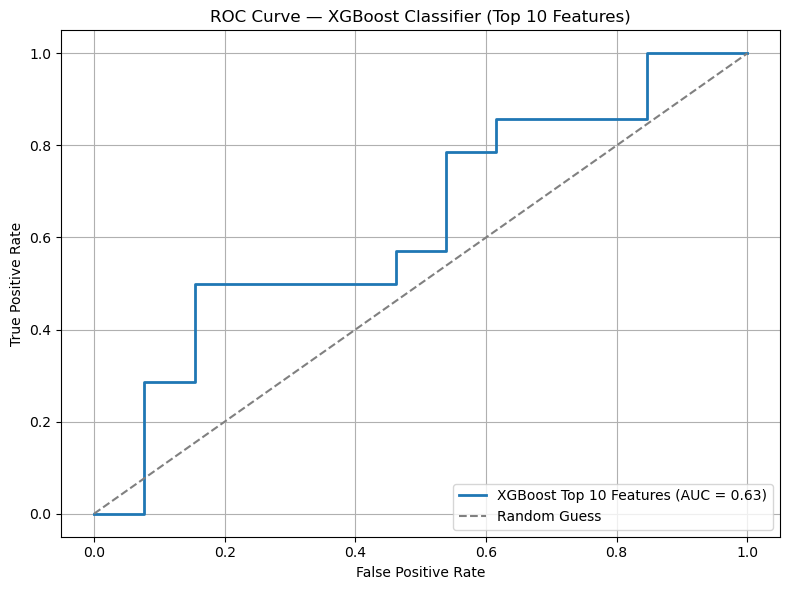

In [101]:
# Getting predicted probabilities for the positive class (top 10 features)
y_pred_proba_xgb_top10_task3_onehot_imputed_clf = xgb_model_top10_task3_onehot_imputed_clf.predict_proba(
    X_val_top10_xgb_task3_onehot_imputed_clf
)[:, 1]

# Computing ROC curve
fpr_xgb_top10, tpr_xgb_top10, thresholds_xgb_top10 = roc_curve(
    y_val_task3_onehot_imputed_class, y_pred_proba_xgb_top10_task3_onehot_imputed_clf
)

# Computing AUC
auc_xgb_top10 = roc_auc_score(y_val_task3_onehot_imputed_class, y_pred_proba_xgb_top10_task3_onehot_imputed_clf)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_top10, tpr_xgb_top10, label=f"XGBoost Top 10 Features (AUC = {auc_xgb_top10:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost Classifier (Top 10 Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.32 Notes: XGBoost Classifier – Top 10 Features (One-Hot + Lagged + Imputed – Classification)  
**Stratified Temporal Split – With 2010 & 2011 Included**

**Goal:** Predict target_class = 1 (increase in homelessness) vs. 0 (no increase)

---

##### **Performance by Class**

- **Class 0: "No Increase"**
  - **Precision = 0.48**: Roughly half of predicted "no increase" cases were correct.
  - **Recall = 0.92**: The model successfully identified nearly all true no-increase cases.
  - **F1 Score = 0.63**: Strong performance in identifying and correctly classifying the majority class.

- **Class 1: "Increase"**
  - **Precision = 0.50**: Of the few times the model predicted an increase, half were correct.
  - **Recall = 0.07**: Only 1 out of 14 actual increases was correctly identified.
  - **F1 Score = 0.12**: Very weak due to poor recall, despite decent precision.

---

##### **Overall Evaluation**
- **Accuracy = 0.48**: Slightly below random guessing.
- **AUC = 0.63**: Indicates **moderate ability to separate the classes** on a probability scale, even if classification is biased.
- **Macro Avg F1 = 0.38**, **Weighted Avg F1 = 0.37**: Reflects class imbalance in model performance.

---

##### **Observation**
- When using **only the top 5 features**, XGBoost **predicted only class 0** — precision, recall, and F1 score for class 1 were all 0.
- This suggests that the top 5 features alone do **not provide enough signal to distinguish increases**, and the model collapses to the majority class.
- Adding more features (top 10) slightly improved AUC and class 1 recall but overall predictive power on increases remains poor.

---

##### **Conclusion**
- The model using the top 10 features improves over the 5-feature version by at least **making some class 1 predictions**, but **recall is still critically low**.
- AUC of 0.63 suggests the model ranks examples somewhat correctly, but the **thresholded predictions are biased toward class 0**.

#### 4.5.33 Merging CoC, County, and Year info with predictions

In [103]:
# Merging predictions with CoC, County, Year info for XGBoost (Top 10 Features)
val_preds_xgb_top10_task3_onehot_imputed_clf_df = val_ids_task3_onehot_imputed_class.copy()

# Adding actual class from validation set
val_preds_xgb_top10_task3_onehot_imputed_clf_df["actual_class"] = y_val_task3_onehot_imputed_class

# Adding predicted class and predicted probabilities from XGBoost top 10 model
val_preds_xgb_top10_task3_onehot_imputed_clf_df["predicted_class"] = y_pred_xgb_top10_task3_onehot_imputed_clf
val_preds_xgb_top10_task3_onehot_imputed_clf_df["predicted_proba"] = y_proba_xgb_top10_task3_onehot_imputed_clf

# Previewing the merged DataFrame
display(val_preds_xgb_top10_task3_onehot_imputed_clf_df.head(10))

,CoC Number,County,Year,actual_class,predicted_class,predicted_proba
0,CA-504,sonoma county,2017,1,1,0.534587
1,CA-511,san joaquin county,2017,1,0,0.394930
2,CA-512,san mateo county,2017,0,0,0.171281
3,CA-603,santa barbara county,2017,0,0,0.270167
4,CA-604,kern county,2017,1,0,0.331355
5,FL-501,hillsborough county,2017,1,0,0.318303
6,FL-513,brevard county,2017,0,0,0.212485
7,FL-606,collier county,2017,1,0,0.331177
8,GA-500,dekalb county,2017,1,0,0.248983
9,GA-500,fulton county,2017,0,0,0.337467


<a id="section-5"></a>
## Section 5 - Fixed Effects and Random Effects

<a id="section-5_1"></a>
### 5.1 Fixed Effects regression

#### 5.1.1 Loading regression dataset and removing duplicates

In [3]:
# Loading the regression modeling dataset
model_file_path_regression = "./data/df_task3_onehot_lagged_imputed_regression_20250604.csv"
df_model_task3_onehot_imputed_regression = pd.read_csv(model_file_path_regression)

# Identifying duplicates based on CoC Number, County, Year
dup_mask = df_model_task3_onehot_imputed_regression.duplicated(
    subset=["CoC Number", "County", "Year"], keep=False  # keep=False shows all duplicates
)
duplicate_rows = df_model_task3_onehot_imputed_regression[dup_mask]

# Reporting if any duplicates found
num_duplicates = duplicate_rows.shape[0]
print(f"Number of potentially duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    print("\nSample of potential duplicates:")
    display(duplicate_rows.sort_values(["CoC Number", "County", "Year"]).head(10))

# Only dropping exact full duplicates
num_exact_dupes = df_model_task3_onehot_imputed_regression.duplicated().sum()
print(f"Number of exact full-row duplicates: {num_exact_dupes}")

if num_exact_dupes > 0:
    df_model_task3_onehot_imputed_regression = df_model_task3_onehot_imputed_regression.drop_duplicates().reset_index(drop=True)
    print(f"Removed {num_exact_dupes} exact duplicates. Final shape: {df_model_task3_onehot_imputed_regression.shape}")
else:
    print("No exact duplicates dropped. Proceeding with full dataset.")

Number of potentially duplicate rows: 42

Sample of potential duplicates:


,CoC Number,County,Year,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,pct_change_total_homeless_per_10k
388,MD-505,baltimore county,2012,0,0,0,269400.0,908.0,1238.0,0.484973,5.7,0.0,0.33,5.5,62407.0,9.6,321393.5,0.000000
389,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
390,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
391,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.140989
392,MD-505,baltimore county,2013,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
393,MD-505,baltimore county,2013,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,0.000000
394,MD-505,baltimore county,2013,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,0.000000
395,MD-505,baltimore county,2013,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,-0.383776
396,MD-505,baltimore county,2014,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,0.000000
397,MD-505,baltimore county,2014,0,0,0,248700.0,982.0,1256.0,0.485478,5.8,0.0,0.34,6.0,68257.0,9.7,441320.0,0.000000


Number of exact full-row duplicates: 8
Removed 8 exact duplicates. Final shape: (1027, 18)


#### 5.1.2 Identifying duplicates

In [4]:
# Counting how many times each key combo appears
dup_key_counts = df_model_task3_onehot_imputed_regression.groupby(["CoC Number", "County", "Year"]).size()
dup_keys = dup_key_counts[dup_key_counts > 1].reset_index(name="Count")

print(f"Number of duplicate keys (CoC/County/Year): {dup_keys.shape[0]}")
display(dup_keys.head())

Number of duplicate keys (CoC/County/Year): 13


,CoC Number,County,Year,Count
0,MD-505,baltimore county,2012,3
1,MD-505,baltimore county,2013,3
2,MD-505,baltimore county,2014,3
3,MD-505,baltimore county,2015,3
4,MD-505,baltimore county,2016,3


#### 5.1.3 Showing a few examples of duplicate entries

In [5]:
# Filtering the original DataFrame for the problematic keys
dup_rows = df_model_task3_onehot_imputed_regression.merge(
    dup_keys[["CoC Number", "County", "Year"]],
    on=["CoC Number", "County", "Year"],
    how="inner"
)

print(f"Total rows with duplicated keys: {dup_rows.shape[0]}")
display(dup_rows.sort_values(["CoC Number", "County", "Year"]).head(10))

Total rows with duplicated keys: 34


,CoC Number,County,Year,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,pct_change_total_homeless_per_10k
0,MD-505,baltimore county,2012,0,0,0,269400.0,908.0,1238.0,0.484973,5.7,0.0,0.33,5.5,62407.0,9.6,321393.5,0.000000
1,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
2,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.140989
3,MD-505,baltimore county,2013,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
4,MD-505,baltimore county,2013,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,0.000000
5,MD-505,baltimore county,2013,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,-0.383776
6,MD-505,baltimore county,2014,0,0,0,253300.0,962.0,1260.0,0.485715,6.0,0.0,0.33,6.8,64795.0,9.6,442142.0,0.000000
7,MD-505,baltimore county,2014,0,0,0,248700.0,982.0,1256.0,0.485478,5.8,0.0,0.34,6.0,68257.0,9.7,441320.0,0.000000
8,MD-505,baltimore county,2014,0,0,0,248700.0,982.0,1256.0,0.485478,5.8,0.0,0.34,6.0,68257.0,9.7,441320.0,0.302693
9,MD-505,baltimore county,2015,0,0,0,248700.0,982.0,1256.0,0.485478,5.8,0.0,0.34,6.0,68257.0,9.7,441320.0,0.000000


#### 5.1.4 Comparing the differences

In [6]:
# Inspect all rows for one duplicated CoC/County/Year combo
example_key = dup_keys.iloc[0][["CoC Number", "County", "Year"]]
example_rows = df_model_task3_onehot_imputed_regression[
    (df_model_task3_onehot_imputed_regression["CoC Number"] == example_key["CoC Number"]) &
    (df_model_task3_onehot_imputed_regression["County"] == example_key["County"]) &
    (df_model_task3_onehot_imputed_regression["Year"] == example_key["Year"])
]

print(f"Comparing rows for: {example_key.to_dict()}")
display(example_rows)

Comparing rows for: {'CoC Number': 'MD-505', 'County': 'baltimore county', 'Year': 2012}


,CoC Number,County,Year,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,pct_change_total_homeless_per_10k
388,MD-505,baltimore county,2012,0,0,0,269400.0,908.0,1238.0,0.484973,5.7,0.0,0.33,5.5,62407.0,9.6,321393.5,0.000000
389,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.000000
390,MD-505,baltimore county,2012,0,0,0,263900.0,943.0,1264.0,0.481551,5.7,0.0,0.34,7.2,62444.0,9.7,440412.0,0.140989


#### 5.1.5 Reloading the regression dataset for aggregation

In [7]:
# Loading the saved regression dataset
model_file_path = "./data/df_task3_onehot_lagged_imputed_regression_20250604.csv"
df_model_task3_onehot_imputed_regression = pd.read_csv(model_file_path)

print("Original shape:", df_model_task3_onehot_imputed_regression.shape)

Original shape: (1035, 18)


#### 5.1.6 Reporting potentially duplicate panel keys

In [8]:
dup_keys = (
    df_model_task3_onehot_imputed_regression
    .groupby(["CoC Number", "County", "Year"])
    .size()
    .reset_index(name="Count")
    .query("Count > 1")
)
print(f"Number of duplicate keys (CoC/County/Year): {dup_keys.shape[0]}")
display(dup_keys.head())

Number of duplicate keys (CoC/County/Year): 13


,CoC Number,County,Year,Count
388,MD-505,baltimore county,2012,4
389,MD-505,baltimore county,2013,4
390,MD-505,baltimore county,2014,4
391,MD-505,baltimore county,2015,4
392,MD-505,baltimore county,2016,4


#### 5.1.7 Removing exact full-row duplicates

In [9]:
num_exact_dupes = df_model_task3_onehot_imputed_regression.duplicated().sum()
print(f"Number of exact full-row duplicates: {num_exact_dupes}")

if num_exact_dupes > 0:
    df_model_task3_onehot_imputed_regression = (
        df_model_task3_onehot_imputed_regression
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print(f"Removed exact duplicates. Final shape: {df_model_task3_onehot_imputed_regression.shape}")
else:
    print("No exact duplicates removed.")

Number of exact full-row duplicates: 8
Removed exact duplicates. Final shape: (1027, 18)


#### 5.1.8 Aggregating by group key

In [10]:
# Defining the grouping keys
group_keys = ["CoC Number", "County", "Year"]

# Performing aggregation — mean of all numeric columns
df_model_task3_onehot_imputed_regression_agg = (
    df_model_task3_onehot_imputed_regression
    .groupby(group_keys, as_index=False)
    .mean(numeric_only=True)
)

# Confirming the shape and preview
print("Aggregated shape (one row per CoC/County/Year):", df_model_task3_onehot_imputed_regression_agg.shape)
display(df_model_task3_onehot_imputed_regression_agg.head())

Aggregated shape (one row per CoC/County/Year): (1006, 18)


,CoC Number,County,Year,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1,pct_change_total_homeless_per_10k
0,AL-501,mobile county,2011,0.0,0.0,1.0,120700.0,513.0,1206.0,0.472663,97.0,0.0,0.32,5.5,39998.0,20.2,321393.5,-0.119891
1,AL-501,mobile county,2012,0.0,0.0,1.0,124100.0,531.0,791.0,0.490373,99.0,0.0,0.32,5.5,42372.0,19.4,321393.5,-0.222666
2,AL-501,mobile county,2013,0.0,0.0,1.0,125400.0,548.0,811.0,0.493205,98.0,0.0,0.33,9.4,39691.0,21.1,188890.0,0.209931
3,AL-501,mobile county,2014,0.0,0.0,1.0,124300.0,561.0,816.0,0.503000,109.0,0.0,0.33,8.7,42944.0,20.0,186932.0,-0.034078
4,AL-501,mobile county,2015,0.0,0.0,1.0,124500.0,576.0,826.0,0.495848,118.0,0.0,0.33,7.7,43642.0,19.3,185640.0,0.079307


#### 5.1.9 Reordering columns

In [11]:
# Reordering columns (ID columns first)
id_cols = ["CoC Number", "County", "Year"]
other_cols = [col for col in df_model_task3_onehot_imputed_regression_agg.columns if col not in id_cols]
df_model_task3_onehot_imputed_regression_agg = df_model_task3_onehot_imputed_regression_agg[id_cols + other_cols]

#### 5.1.10 Saving the cleaned aggregated panel dataset

In [17]:
# Defining the output path for the cleaned and aggregated panel dataset
#current_date = datetime.now().strftime("%Y%m%d")
current_date = datetime.datetime.now().strftime("%Y%m%d")
output_dir = "./data"
output_filename = f"df_task3_onehot_lagged_imputed_regression_panel_{current_date}.csv"
output_path = os.path.join(output_dir, output_filename)

# Saving to CSV
df_model_task3_onehot_imputed_regression_agg.to_csv(output_path, index=False, encoding="utf-8")
print(f"Cleaned panel regression dataset saved to:\n{output_path}")

Cleaned panel regression dataset saved to:
./data\df_task3_onehot_lagged_imputed_regression_panel_20250618.csv


#### 5.1.11 Loading the cleaned panel dataset and setting the panel index

In [12]:
# Loading the cleaned and aggregated panel dataset
panel_file_path = "./data/df_task3_onehot_lagged_imputed_regression_panel_20250618.csv" 
df_model_task3_onehot_imputed_regression_agg = pd.read_csv(panel_file_path)

print("Loaded cleaned panel dataset shape:", df_model_task3_onehot_imputed_regression_agg.shape)

# Setting the panel index (CoC Number and Year) for fixed effects modeling
df_panel = df_model_task3_onehot_imputed_regression_agg.set_index(["CoC Number", "Year"])
df_panel.head()

Loaded cleaned panel dataset shape: (1006, 18)


County  CoC_Category_Largely Rural CoC  \
CoC Number Year                                                  
AL-501     2011  mobile county                             0.0   
           2012  mobile county                             0.0   
           2013  mobile county                             0.0   
           2014  mobile county                             0.0   
           2015  mobile county                             0.0   

                 CoC_Category_Major City CoC  \
CoC Number Year                                
AL-501     2011                          0.0   
           2012                          0.0   
           2013                          0.0   
           2014                          0.0   
           2015                          0.0   

                 CoC_Category_Other Largely Urban CoC  \
CoC Number Year                                         
AL-501     2011                                   1.0   
           2012                                   1.0   
           2013                                   1.0   
           2014                                   1.0   
           2015                                   1.0   

                 Median_House_Values_5_year_lag1  Median_Rent_5_year_lag1  \
CoC Number Year                                                             
AL-501     2011                         120700.0                    513.0   
           2012                         124100.0                    531.0   
           2013                         125400.0                    548.0   
           2014                         124300.0                    561.0   
           2015                         124500.0                    576.0   

                 Median_Gross_Rent_5_year_lag1  \
CoC Number Year                                  
AL-501     2011                         1206.0   
           2012                          791.0   
           2013                          811.0   
           2014                          816.0   
           2015                          826.0   

                 Percentage_of_Households_with_Cost_Burden_5_year_lag1  \
CoC Number Year                                                          
AL-501     2011                                           0.472663       
           2012                                           0.490373       
           2013                                           0.493205       
           2014                                           0.503000       
           2015                                           0.495848       

                 Rental_Vacancy_Rates_5_year_lag1  \
CoC Number Year                                     
AL-501     2011                              97.0   
           2012                              99.0   
           2013                              98.0   
           2014                             109.0   
           2015                             118.0   

                 Share_of_Single_Person_Households_5_year_lag1  \
CoC Number Year                                                  
AL-501     2011                                            0.0   
           2012                                            0.0   
           2013                                            0.0   
           2014                                            0.0   
           2015                                            0.0   

                 Share_of_Renter_Occupied_Units_5_year_lag1  \
CoC Number Year                                               
AL-501     2011                                        0.32   
           2012                                        0.32   
           2013                                        0.33   
           2014                                        0.33   
           2015                                        0.33   

                 Unemployment Rate_lag1  Median Household Income_lag1  \
CoC Number Year                                                 

#### 5.1.12 Defining dependent and independent variables

In [13]:
# Defining the target variable
target = "pct_change_total_homeless_per_10k"

# Excluding ID and target columns from the predictors
predictors = [
    col for col in df_panel.columns
    if col not in ["County", target]
]

# Review and refine predictors
print("Number of predictors:", len(predictors))

Number of predictors: 14


#### 5.1.13 Computing the correlation matrix

In [14]:
# Computing the correlation matrix for predictors
corr_matrix = df_panel[predictors].corr()

# Display the top of the matrix
display(corr_matrix.round(2).head(10))

,CoC_Category_Largely Rural CoC,CoC_Category_Major City CoC,CoC_Category_Other Largely Urban CoC,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,Median_Gross_Rent_5_year_lag1,Percentage_of_Households_with_Cost_Burden_5_year_lag1,Rental_Vacancy_Rates_5_year_lag1,Share_of_Single_Person_Households_5_year_lag1,Share_of_Renter_Occupied_Units_5_year_lag1,Unemployment Rate_lag1,Median Household Income_lag1,Poverty Rate_lag1,Labor Force_lag1
CoC_Category_Largely Rural CoC,1.00,-0.06,-0.05,-0.12,-0.15,-0.17,-0.14,-0.04,0.06,-0.07,0.03,-0.15,0.12,-0.08
CoC_Category_Major City CoC,-0.06,1.00,-0.18,-0.01,-0.05,-0.09,0.04,0.00,-0.01,0.40,0.03,-0.14,0.27,0.39
CoC_Category_Other Largely Urban CoC,-0.05,-0.18,1.00,-0.07,-0.09,-0.15,0.01,0.11,0.02,0.29,-0.02,-0.16,0.25,-0.15
Median_House_Values_5_year_lag1,-0.12,-0.01,-0.07,1.00,0.90,0.80,0.07,-0.15,-0.00,0.11,-0.23,0.75,-0.51,0.12
Median_Rent_5_year_lag1,-0.15,-0.05,-0.09,0.90,1.00,0.88,0.12,-0.11,0.07,0.03,-0.26,0.85,-0.58,0.16
Median_Gross_Rent_5_year_lag1,-0.17,-0.09,-0.15,0.80,0.88,1.00,0.07,-0.18,-0.02,-0.13,-0.21,0.86,-0.63,0.09
Percentage_of_Households_with_Cost_Burden_5_year_lag1,-0.14,0.04,0.01,0.07,0.12,0.07,1.00,0.34,-0.10,0.12,0.35,-0.24,0.35,0.17
Rental_Vacancy_Rates_5_year_lag1,-0.04,0.00,0.11,-0.15,-0.11,-0.18,0.34,1.00,-0.05,0.00,0.23,-0.32,0.37,0.09
Share_of_Single_Person_Households_5_year_lag1,0.06,-0.01,0.02,-0.00,0.07,-0.02,-0.10,-0.05,1.00,0.07,-0.32,0.11,-0.08,0.03
Share_of_Renter_Occupied_Units_5_year_lag1,-0.07,0.40,0.29,0.11,0.03,-0.13,0.12,0.00,0.07,1.00,0.04,-0.26,0.53,0.29


#### 5.1.14 Identify highly correlated pairs

In [15]:
# Flattening the matrix and filtering for high correlations (excluding self-correlations)
high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > 0.9]

print("Highly correlated feature pairs (|correlation| > 0.9):")
display(high_corr_pairs.sort_values(by="Correlation", ascending=False))

Highly correlated feature pairs (|correlation| > 0.9):


,Feature_1,Feature_2,Correlation
36,Median_House_Values_5_year_lag1,Median_Rent_5_year_lag1,0.903524


#### 5.1.15 Dealing with highly correlated pairs

In [16]:
# Dropping house value predictor
redundant_feature = "Median_House_Values_5_year_lag1"
predictors = [col for col in predictors if col != redundant_feature]

print(f"Dropped: {redundant_feature}")
print(f"Number of predictors now: {len(predictors)}")

Dropped: Median_House_Values_5_year_lag1
Number of predictors now: 13


#### 5.1.16 Check for VIF (Variance Inflation Factor)

In [17]:
# Subsetting the predictor matrix (excluding non-numeric columns)
X_vif = df_panel[predictors].select_dtypes(include=["float64", "int64"]).copy()

# Adding a constant for intercept
X_vif_const = add_constant(X_vif)

# Computing VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

# Displaying VIF values sorted by severity (excluding the intercept)
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)
display(vif_data)

,Feature,VIF
11,Median Household Income_lag1,14.454151
4,Median_Rent_5_year_lag1,11.444110
5,Median_Gross_Rent_5_year_lag1,6.613729
12,Poverty Rate_lag1,5.941540
9,Share_of_Renter_Occupied_Units_5_year_lag1,3.316416
6,Percentage_of_Households_with_Cost_Burden_5_ye...,2.531180
7,Rental_Vacancy_Rates_5_year_lag1,1.567663
2,CoC_Category_Major City CoC,1.510145
10,Unemployment Rate_lag1,1.499923
13,Labor Force_lag1,1.350668


#### 5.1.17 Adjusting feature list and recalculating VIF

In [18]:
# Adjusting list of predictors
predictors_revised = [col for col in predictors if col not in [
    "Median_Rent_5_year_lag1",
    "Poverty Rate_lag1"
]]

# Extracting the revised predictor DataFrame
X_revised = df_panel[predictors_revised]

# Adding a constant for VIF calculation
X_revised_const = add_constant(X_revised)

# Calculating VIF
vif_data_revised = pd.DataFrame()
vif_data_revised["Feature"] = X_revised_const.columns
vif_data_revised["VIF"] = [variance_inflation_factor(X_revised_const.values, i)
                           for i in range(X_revised_const.shape[1])]

# Dropping the constant row for clarity
vif_data_revised = vif_data_revised[vif_data_revised["Feature"] != "const"]

# Displaying
print("VIF after dropping collinear features:")
display(vif_data_revised.sort_values(by="VIF", ascending=False))

VIF after dropping collinear features:


,Feature,VIF
10,Median Household Income_lag1,7.260619
4,Median_Gross_Rent_5_year_lag1,5.986214
5,Percentage_of_Households_with_Cost_Burden_5_ye...,1.698547
8,Share_of_Renter_Occupied_Units_5_year_lag1,1.640410
2,CoC_Category_Major City CoC,1.464687
9,Unemployment Rate_lag1,1.461232
11,Labor Force_lag1,1.310103
3,CoC_Category_Other Largely Urban CoC,1.309468
6,Rental_Vacancy_Rates_5_year_lag1,1.267328
7,Share_of_Single_Person_Households_5_year_lag1,1.187042


#### 5.1.18 Fixed Effects regression

In [19]:
# Resetting and setting MultiIndex
df_panel_fe = df_panel.reset_index()
df_panel_fe = df_panel_fe.set_index(["County", "Year"])

# Defining predictors
final_features_fe = [
    'CoC_Category_Largely Rural CoC',
    'CoC_Category_Major City CoC',
    'CoC_Category_Other Largely Urban CoC',
    'Median_Gross_Rent_5_year_lag1',
    'Percentage_of_Households_with_Cost_Burden_5_year_lag1',
    'Rental_Vacancy_Rates_5_year_lag1',
    'Share_of_Single_Person_Households_5_year_lag1',
    'Share_of_Renter_Occupied_Units_5_year_lag1',
    'Unemployment Rate_lag1',
    'Median Household Income_lag1',
    'Labor Force_lag1'
]

# Defining dependent and independent variables
y_fe = df_panel_fe["pct_change_total_homeless_per_10k"]
X_fe = df_panel_fe[final_features_fe]

# Fitting the Fixed Effects model with both entity and time effects
#model_fe = PanelOLS(dependent=y_fe, exog=X_fe, entity_effects=True, time_effects=True)
model_fe = PanelOLS(
    dependent=y_fe,
    exog=X_fe,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results_fe = model_fe.fit()

# Printing the summary
print(results_fe.summary)

                                  PanelOLS Estimation Summary                                  
Dep. Variable:     pct_change_total_homeless_per_10k   R-squared:                        0.0256
Estimator:                                  PanelOLS   R-squared (Between):             -0.2242
No. Observations:                               1006   R-squared (Within):              -0.3392
Date:                               Tue, Jun 24 2025   R-squared (Overall):             -0.4351
Time:                                       18:22:10   Log-likelihood                    266.00
Cov. Estimator:                           Unadjusted                                           
                                                       F-statistic:                      2.8546
Entities:                                        122   P-value                           0.0039
Avg Obs:                                      8.2459   Distribution:                   F(8,868)
Min Obs:                                

C:\Users\amina\AppData\Local\Temp\ipykernel_70036\1078887916.py:34: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

CoC_Category_Largely Rural CoC, Percentage_of_Households_with_Cost_Burden_5_year_lag1, Share_of_Renter_Occupied_Units_5_year_lag1

  results_fe = model_fe.fit()


#### 5.1.19 Extracting fixed effects for visualization

In [23]:
# Getting estimated fixed effects from the model
fe_all = results_fe.estimated_effects

# County (entity) fixed effects: average across years
county_effects = fe_all.groupby(level=0).mean().reset_index()
county_effects.columns = ["County", "FixedEffect"]

# Year (time) fixed effects: average across counties
year_effects = fe_all.groupby(level=1).mean().reset_index()
year_effects.columns = ["Year", "FixedEffect"]

# Previewing
print("County-level Fixed Effects:")
display(county_effects.head())

print("Year-level Fixed Effects:")
display(year_effects.head())

County-level Fixed Effects:


,County,FixedEffect
0,alameda county,-0.042840
1,allegheny county,-0.217658
2,anne arundel county,-0.247020
3,arlington county,-0.324749
4,atlantic county,-0.288013


Year-level Fixed Effects:


,Year,FixedEffect
0,2010,0.964048
1,2011,-0.199838
2,2012,-0.254809
3,2013,-0.252076
4,2014,-0.274332


#### 5.1.20 Plotting county fixed effects for top and bottom 15

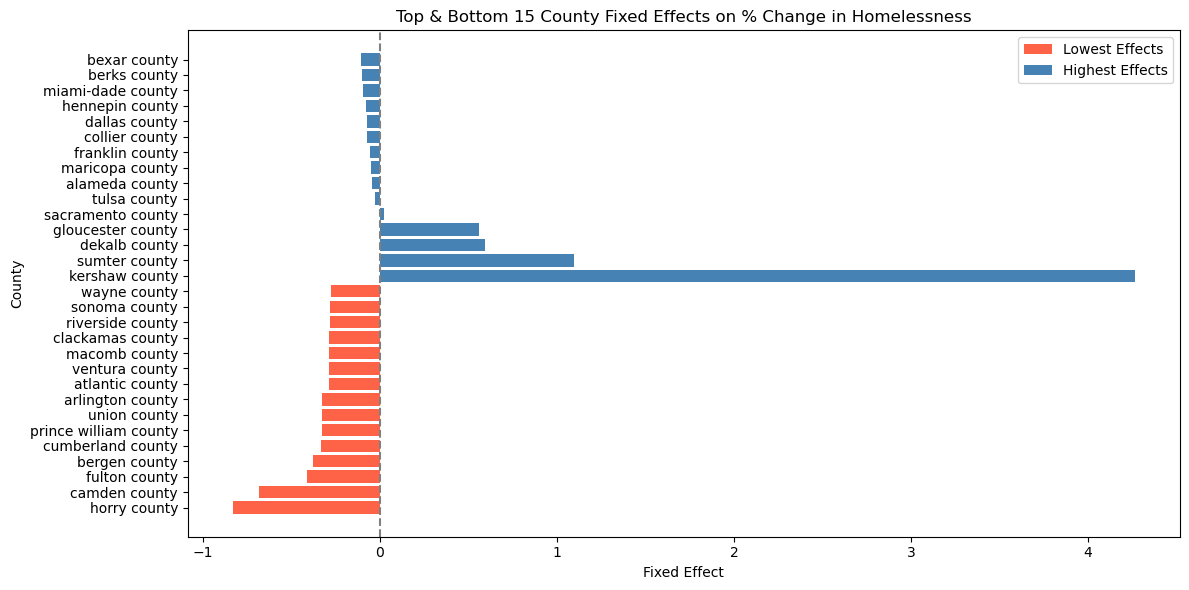

In [24]:
# Sorting and getting the top and bottom 15 counties
top_15 = county_effects.sort_values(by="FixedEffect", ascending=False).head(15)
bottom_15 = county_effects.sort_values(by="FixedEffect", ascending=True).head(15)

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(bottom_15["County"], bottom_15["FixedEffect"], color="tomato", label="Lowest Effects")
plt.barh(top_15["County"], top_15["FixedEffect"], color="steelblue", label="Highest Effects")
plt.axvline(0, color="gray", linestyle="--")
plt.title("Top & Bottom 15 County Fixed Effects on % Change in Homelessness")
plt.xlabel("Fixed Effect")
plt.ylabel("County")
plt.legend()
plt.tight_layout()
plt.show()

##### 5.1.20.1 Summary: Top & Bottom 15 County Fixed Effects

- **Kershaw County** stands out with the **largest positive fixed effect**, indicating it had persistently higher percent changes in homelessness even after controlling for observed predictors and year-specific trends.
- Other counties with **large positive effects** include **Sumter**, **Dekalb**, **Gloucester**, and **Sacramento**. This suggests structural or policy-related factors that are not captured in the current model that may be influencing these outcomes.
- Counties such as **Horry**, **Camden**, and **Fulton** show **strong negative fixed effects**, implying consistently lower homelessness growth than predicted.
- **All fixed effects are relative to the sample mean**: positive effects mean the county experiences higher-than-average changes in homelessness, and negative effects indicate lower-than-average changes.

#### 5.1.21 Analyzing predictors behind the large fixed effects

##### 5.1.21.1 Normalize the predictors

In [30]:
# Resetting index so County becomes a column
df_panel_reset = df_panel.reset_index()

# Selecting the predictors and normalizing
predictor_data = df_panel_reset[["County"] + final_features_fe]
scaler = StandardScaler()
predictor_data_scaled = predictor_data.copy()
predictor_data_scaled[final_features_fe] = scaler.fit_transform(predictor_data[final_features_fe])

##### 5.1.21.2 Computing average values by county

In [31]:
# Grouping by County and computing mean predictor values per county
county_avg_scaled = predictor_data_scaled.groupby("County")[final_features_fe].mean().reset_index()

##### 5.1.21.3 Using the top and bottom counties from fixed effects

In [32]:
# Using top and bottom 15 counties
top_counties = set(top_15["County"])
bottom_counties = set(bottom_15["County"])

# Computing the average across top and bottom groups
top_means = county_avg_scaled[county_avg_scaled["County"].isin(top_counties)].mean(numeric_only=True)
bottom_means = county_avg_scaled[county_avg_scaled["County"].isin(bottom_counties)].mean(numeric_only=True)

# Computing difference (top - bottom)
mean_diff_normalized = (top_means - bottom_means).sort_values()
mean_diff_df = mean_diff_normalized.reset_index()
mean_diff_df.columns = ["Predictor", "MeanDifference"]

##### 5.1.21.4 Plotting the differences

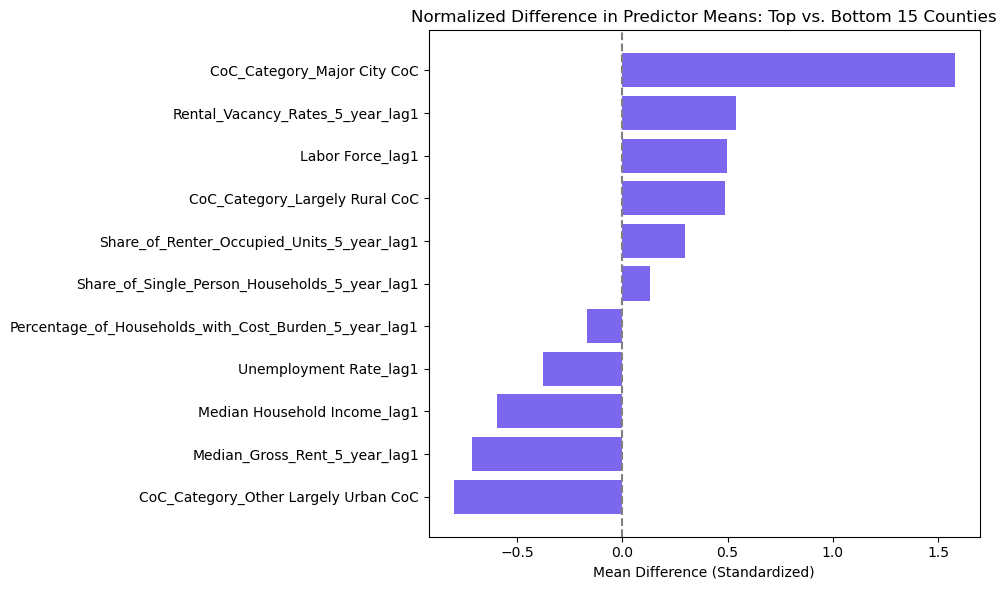

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(mean_diff_df["Predictor"], mean_diff_df["MeanDifference"], color="mediumslateblue")
plt.axvline(0, color="gray", linestyle="--")
plt.title("Normalized Difference in Predictor Means: Top vs. Bottom 15 Counties")
plt.xlabel("Mean Difference (Standardized)")
plt.tight_layout()
plt.show()

##### 5.1.21.5 Summary: Normalized Differences in Predictor Means (Top vs. Bottom Counties)

- **CoC_Category_Major City CoC** stands out with the largest positive difference. This suggests that major city CoCs are disproportionately represented among counties with higher increases in homelessness.
- **Rental Vacancy Rates (lagged)** and **Labor Force size (lagged)** are also higher in high-effect counties. This possibly reflects housing market pressure and population scale.
- **Share of Renters** and **Single-Person Households (lagged)** are moderately elevated in high-effect counties. This supports the hypothesis that renter-heavy and isolated populations may be more vulnerable.
- **Cost burden**, **unemployment**, and **median rent/income** tend to be higher in low-effect counties. This potentially reflects better affordability or protective local conditions.
- **Other Urban CoCs** and **Median Gross Rent** are notably higher in counties with lower homelessness growth. This potentially indicates a nuanced difference between types of urban areas.

##### 5.1.21.6 Plotting year fixed effects

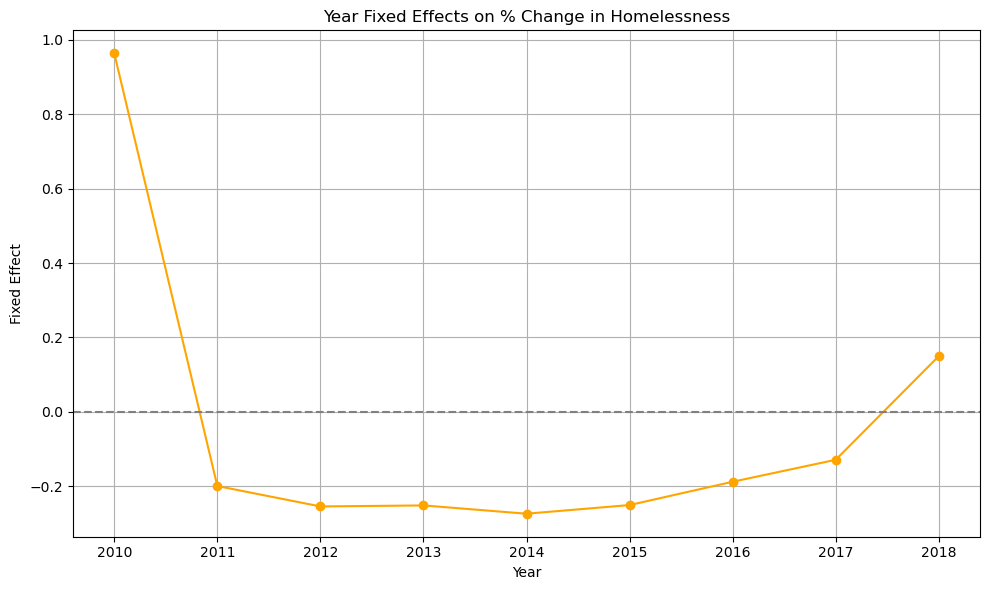

In [34]:
# Sorting year_effects DataFrame by year
year_effects_sorted = year_effects.sort_values("Year")

# Plotting year fixed effects
plt.figure(figsize=(10, 6))
plt.plot(year_effects_sorted["Year"], year_effects_sorted["FixedEffect"], marker='o', linestyle='-', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Year Fixed Effects on % Change in Homelessness")
plt.xlabel("Year")
plt.ylabel("Fixed Effect")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 5.1.21.7 Plotting raw percent change vs year fixed effects

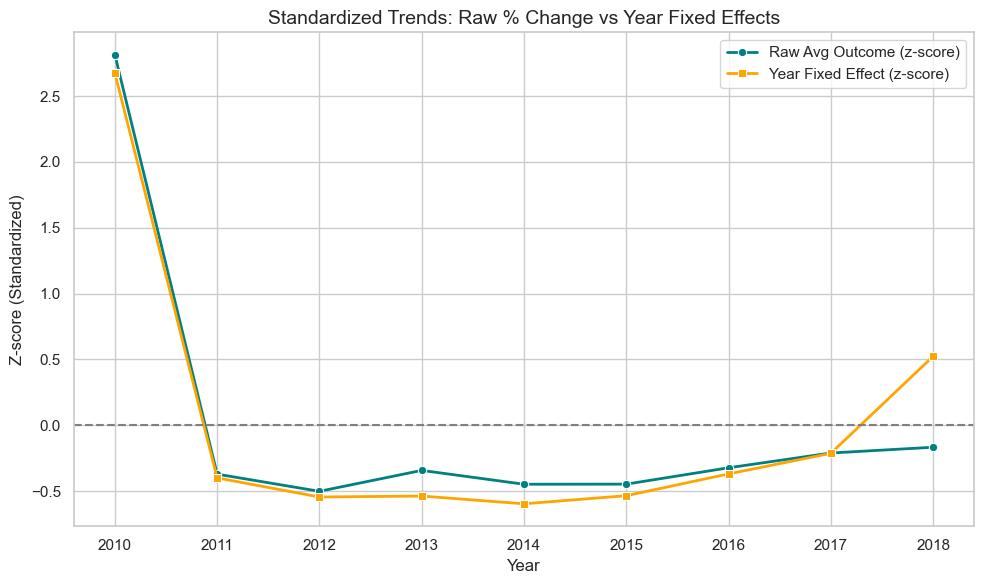

In [40]:
# --- Step 1: Rename columns for clarity ---
yearly_trend = (
    df_panel_fe.reset_index()
    .groupby("Year")["pct_change_total_homeless_per_10k"]
    .mean()
    .reset_index()
    .rename(columns={"pct_change_total_homeless_per_10k": "RawAverage"})
)

year_effects_renamed = year_effects.rename(columns={"FixedEffect": "YearFixedEffect"})

# --- Step 2: Merge the two dataframes ---
year_combined = pd.merge(yearly_trend, year_effects_renamed, on="Year")

# --- Step 3: Standardize both series ---
year_combined["RawAverage_z"] = zscore(year_combined["RawAverage"])
year_combined["YearFixedEffect_z"] = zscore(year_combined["YearFixedEffect"])

# --- Step 4: Plot standardized series ---
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=year_combined, x="Year", y="RawAverage_z", marker="o", label="Raw Avg Outcome (z-score)", color="teal", linewidth=2)
sns.lineplot(data=year_combined, x="Year", y="YearFixedEffect_z", marker="s", label="Year Fixed Effect (z-score)", color="orange", linewidth=2)

plt.axhline(0, color="gray", linestyle="--")
plt.title("Standardized Trends: Raw % Change vs Year Fixed Effects", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Z-score (Standardized)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

##### 5.1.21.8 Summary: Standardized Trends — Raw % Change vs Year Fixed Effects

- The **two lines track closely** over the years, confirming that the **year fixed effects are capturing key variation** in the raw homelessness trend.
- The year **2010 shows a strong positive deviation** in both raw outcomes and fixed effects. This suggests a particularly high percent increase in homelessness that year.
- From **2011 to 2016**, both series remain **consistently negative**, indicating a period of below-average percent change in homelessness after 2010.
- In **2017 and 2018**, both trends shift upward, with **2018 turning positive**. This suggests renewed increases in homelessness consistent across counties.
- The alignment of these two curves suggests that **unobserved time shocks** (e.g., economic, policy, or societal changes) likely played a major role in shaping homelessness trends over time.